# Notebook 02 — Preprocessing

**Goal:** Apply the preprocessing decisions that have been confirmed so far,
to the master dataset produced by Notebook 01, and save a cleaned version
for use in all downstream modeling notebooks.

**Decisions applied here:**
1. **Drop the Heiligendamm site** (51 samples; different salinity regime, sparse coverage).
 
2. **Replace negative NH4 values with 0**.

3. **Document the missing-value strategy** (no transformation here).


**Inputs:**  `data/processed/meta_master.csv`, `otu_16s_master.csv`, `otu_18s_master.csv`
**Outputs:** `data/processed/meta_clean.csv`, `otu_16s_clean.csv`, `otu_18s_clean.csv`

In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path

# Paths (relative to notebooks/ folder)
PROCESSED_DIR = Path("../data/processed")

# Inputs (from Notebook 01)
META_IN   = PROCESSED_DIR / "meta_master.csv"
OTU16_IN  = PROCESSED_DIR / "otu_16s_master.csv"
OTU18_IN  = PROCESSED_DIR / "otu_18s_master.csv"

# Outputs (this notebook)
META_OUT  = PROCESSED_DIR / "meta_clean.csv"
OTU16_OUT = PROCESSED_DIR / "otu_16s_clean.csv"
OTU18_OUT = PROCESSED_DIR / "otu_18s_clean.csv"

print("Inputs exist?")
for p in [META_IN, OTU16_IN, OTU18_IN]:
    print(f"  {p.name}: {p.exists()}")

Inputs exist?
  meta_master.csv: True
  otu_16s_master.csv: True
  otu_18s_master.csv: True


In [ ]:
# Load the master tables produced by Notebook 01
meta     = pd.read_csv(META_IN, index_col=0)
otu_16s  = pd.read_csv(OTU16_IN, index_col=0)
otu_18s  = pd.read_csv(OTU18_IN, index_col=0)

print(f"meta:    {meta.shape}")
print(f"otu_16s: {otu_16s.shape}")
print(f"otu_18s: {otu_18s.shape}")

# Sanity check: row alignment (all three tables must share the same sample order)
assert (meta.index == otu_16s.index).all(), "meta and 16S indices misaligned"
assert (meta.index == otu_18s.index).all(), "meta and 18S indices misaligned"
print("\n✓ All three tables share identical sample order.")
print(meta.columns.tolist())

meta:    (1589, 23)
otu_16s: (1589, 1236)
otu_18s: (1589, 1054)

✓ All three tables share identical sample order.
['location_id', 'day_id', 'cw_id', 'year_id', 'location_name', 'rough_lat_long', 'date', 'PO4', 'NOx', 'NH4', 'NO2', 'NO3', 'temperature', 'salinity', 'Chl_a', 'Phaeo', 'Chl_a_conc', 'f0', 'fa', 'volume', 'time', 'month', 'year_full']


In [12]:
# Inspect site distribution to confirm naming and counts before filtering
print("Samples per site (location_name):")
print(meta['location_name'].value_counts().sort_index())
print(f"\nNumber of unique sites: {meta['location_name'].nunique()}")

Samples per site (location_name):
location_name
Boergerende Strand         110
Diedrichshagen             110
Elmenhorst Strand          109
Heiligendamm                51
Jemnitzschleuse            109
Mittelmole Warnemuende     111
Muehlendamm                109
Neptun-Werft               111
Parkplatz zur Warnow       110
SAB Marina Bramow          109
Schmarl-Dorf / IGA-Park    109
Schwimmhalle Gehlsdorf     111
Stadthafen Rostock         111
Steilkueste Nienhagen      110
Warnemuende Strand         109
Name: count, dtype: int64

Number of unique sites: 15


In [13]:
# --- Apply Decision 1: Drop the Heiligendamm site ---

# Save shapes before for the report
n_before = len(meta)

# Build a boolean mask on meta, then apply the SAME mask to all three tables
keep_mask = meta['location_name'] != 'Heiligendamm'

meta    = meta.loc[keep_mask].copy()
otu_16s = otu_16s.loc[keep_mask].copy()
otu_18s = otu_18s.loc[keep_mask].copy()

# Sanity checks: alignment must still hold after filtering
assert (meta.index == otu_16s.index).all(), "alignment broken after filtering"
assert (meta.index == otu_18s.index).all(), "alignment broken after filtering"
assert 'Heiligendamm' not in meta['location_name'].unique(), "Heiligendamm still present"

# Report
n_after = len(meta)
print(f"Samples before: {n_before}")
print(f"Samples after:  {n_after}")
print(f"Removed:        {n_before - n_after}")
print(f"\nRemaining sites: {meta['location_name'].nunique()}")
print(f"\nNew shapes:")
print(f"  meta:    {meta.shape}")
print(f"  otu_16s: {otu_16s.shape}")
print(f"  otu_18s: {otu_18s.shape}")
print("\n✓ All three tables still aligned.")

Samples before: 1589
Samples after:  1538
Removed:        51

Remaining sites: 14

New shapes:
  meta:    (1538, 23)
  otu_16s: (1538, 1236)
  otu_18s: (1538, 1054)

✓ All three tables still aligned.


In [ ]:
# ---  Replace negative NH4 values with 0 ---

# Inspect BEFORE
nh4_before = meta['NH4']
n_negative = (nh4_before < 0).sum()
n_missing  = nh4_before.isna().sum()

print("NH4 — before correction:")
print(f"  Min:                 {nh4_before.min():.4f}")
print(f"  Max:                 {nh4_before.max():.4f}")
print(f"  Negative values:     {n_negative}")
print(f"  Missing values:      {n_missing}")
print(f"  Non-missing samples: {nh4_before.notna().sum()}")

# Apply the fix: clip lower bound at 0 (NaN values are preserved by clip)
meta['NH4'] = meta['NH4'].clip(lower=0)

# Inspect AFTER
nh4_after = meta['NH4']
print("\nNH4 — after correction:")
print(f"  Min:                 {nh4_after.min():.4f}")
print(f"  Max:                 {nh4_after.max():.4f}")
print(f"  Negative values:     {(nh4_after < 0).sum()}")
print(f"  Missing values:      {nh4_after.isna().sum()}")

# Sanity checks
assert (nh4_after.dropna() >= 0).all(), "negative values still present"
assert nh4_after.isna().sum() == n_missing, "missing-value count changed"

print("\n✓ All negative NH4 values set to 0.")
print("✓ Missing values preserved (not affected).")

NH4 — before correction:
  Min:                 -9.3600
  Max:                 35.0400
  Negative values:     159
  Missing values:      7
  Non-missing samples: 1531

NH4 — after correction:
  Min:                 0.0000
  Max:                 35.0400
  Negative values:     0
  Missing values:      7

✓ All negative NH4 values set to 0.
✓ Missing values preserved (not affected).


In [ ]:
# --- Save the cleaned master tables ---

meta.to_csv(META_OUT)
otu_16s.to_csv(OTU16_OUT)
otu_18s.to_csv(OTU18_OUT)

print("Saved cleaned tables to:", PROCESSED_DIR)
print()
for p in [META_OUT, OTU16_OUT, OTU18_OUT]:
    size_mb = p.stat().st_size / (1024 * 1024)
    print(f"  {p.name:25s}  {size_mb:6.2f} MB")

Saved cleaned tables to: ../data/processed

  meta_clean.csv               0.32 MB
  otu_16s_clean.csv            4.11 MB
  otu_18s_clean.csv            3.40 MB


In [16]:
# --- Round-trip check: reload from disk and verify identity ---
# This guards against silent corruption (e.g., float precision loss, encoding issues,
# index drift) when downstream notebooks load these files.

meta_reloaded    = pd.read_csv(META_OUT,  index_col=0)
otu_16s_reloaded = pd.read_csv(OTU16_OUT, index_col=0)
otu_18s_reloaded = pd.read_csv(OTU18_OUT, index_col=0)

# Shape match
assert meta_reloaded.shape    == meta.shape,    "meta shape changed after round-trip"
assert otu_16s_reloaded.shape == otu_16s.shape, "16S shape changed after round-trip"
assert otu_18s_reloaded.shape == otu_18s.shape, "18S shape changed after round-trip"

# Index match (same samples, same order)
assert (meta_reloaded.index    == meta.index).all(),    "meta index drift"
assert (otu_16s_reloaded.index == otu_16s.index).all(), "16S index drift"
assert (otu_18s_reloaded.index == otu_18s.index).all(), "18S index drift"

# Spot-check the two transformations we applied
assert (meta_reloaded['NH4'].dropna() >= 0).all(), "NH4 has negatives after reload"
assert 'Heiligendamm' not in meta_reloaded['location_name'].unique(), "Heiligendamm reappeared"

print("Round-trip verification:")
print(f"  meta:    {meta_reloaded.shape}  ✓")
print(f"  otu_16s: {otu_16s_reloaded.shape}  ✓")
print(f"  otu_18s: {otu_18s_reloaded.shape}  ✓")
print(f"\n  Sites remaining: {meta_reloaded['location_name'].nunique()} (no Heiligendamm)  ✓")
print(f"  NH4 minimum:     {meta_reloaded['NH4'].min():.4f}  ✓")
print("\n✅ All clean tables saved correctly and load back identically.")
print("   Downstream notebooks can now use *_clean.csv files.")

Round-trip verification:
  meta:    (1538, 23)  ✓
  otu_16s: (1538, 1236)  ✓
  otu_18s: (1538, 1054)  ✓

  Sites remaining: 14 (no Heiligendamm)  ✓
  NH4 minimum:     0.0000  ✓

✅ All clean tables saved correctly and load back identically.
   Downstream notebooks can now use *_clean.csv files.


In [ ]:
# The raw Chl_a column contains 101 missing values and some negative values


# --- Step 4a: clip negative Chl_a to 0 (in place) ---
chla_neg_count = (meta['Chl_a'] < 0).sum()
chla_min_before = meta['Chl_a'].min()
meta['Chl_a'] = meta['Chl_a'].clip(lower=0)

print(f"Chl_a — clipping negative values:")
print(f"  Negative values clipped to 0:  {chla_neg_count}")
print(f"  Min before:                    {chla_min_before:.4f}")
print(f"  Min after:                     {meta['Chl_a'].min():.4f}")

# --- Step 4b: log1p transform as a new column ---
meta['Chl_a_log1p'] = np.log1p(meta['Chl_a'])

chla_log = meta['Chl_a_log1p']
print(f"\nChl_a_log1p — after log1p:")
print(f"  Min:                 {chla_log.min():.4f}")
print(f"  Max:                 {chla_log.max():.4f}")
print(f"  Median:              {chla_log.median():.4f}")
print(f"  Missing values:      {chla_log.isna().sum()}")

# Sanity checks
assert (meta['Chl_a'].dropna() >= 0).all(), "Chl_a still has negatives after clip"
assert (chla_log.dropna() >= 0).all(), "log1p produced negatives (clip must have failed)"
assert chla_log.isna().sum() == 101, "missing values changed"
assert 'Chl_a' in meta.columns, "raw Chl_a column was lost"

print("\n✓ Chl_a negatives clipped to 0.")
print("✓ Chl_a_log1p column added.")
print("✓ Raw Chl_a column preserved (after clipping).")
print("✓ Missing values preserved.")
print("\nNote: This Chl_a clipping decision (extending Theo's NH4 rule)")
print("      should be mentioned to Prof. Lüdtke in the next meeting.")

Chl_a — clipping negative values:
  Negative values clipped to 0:  1
  Min before:                    -0.1490
  Min after:                     0.0000

Chl_a_log1p — after log1p:
  Min:                 0.0000
  Max:                 5.0624
  Median:              0.9321
  Missing values:      101

✓ Chl_a negatives clipped to 0.
✓ Chl_a_log1p column added.
✓ Raw Chl_a column preserved (after clipping).
✓ Missing values preserved.

Note: This Chl_a clipping decision (extending Theo's NH4 rule)
      should be mentioned to Prof. Lüdtke in the next meeting.


In [8]:
import re, os, glob
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
os.makedirs("results", exist_ok=True)

SITE, SAL, LL = "location_name", "salinity", "rough_lat_long"

# --- auto-find & load the metadata CSV (kernel-restart proof, no prior vars needed) ---
SEARCH_DIRS = ["../data", "data", "../data/raw", "."]   # adjust if your data lives elsewhere
need = {SITE, LL, SAL}
meta, src = None, None
for d in SEARCH_DIRS:
    for f in glob.glob(os.path.join(d, "*.csv")):
        try:
            cols = set(pd.read_csv(f, nrows=0).columns)   # read header only (fast)
        except Exception:
            continue
        if need.issubset(cols):
            meta, src = pd.read_csv(f, index_col=0), f
            break
    if meta is not None:
        break
assert meta is not None, f"No metadata CSV with columns {need} found in {SEARCH_DIRS}. Set the path manually."
print("loaded metadata from:", src, "| shape:", meta.shape)

# robust lat/long parser (lat ~54, lon ~12 -> assign by magnitude, order-proof)
def parse_latlon(s):
    nums = re.findall(r"-?\d+\.?\d*", str(s))
    if len(nums) < 2:
        return pd.Series([np.nan, np.nan])
    a, b = float(nums[0]), float(nums[1])
    lat, lon = (a, b) if a > b else (b, a)
    return pd.Series([lat, lon])

# drop Heiligendamm so it matches the 15 modelling sites (no-op if already absent)
m = meta[~meta[SITE].str.contains("eiligendamm", case=False, na=False)].copy()

agg = (m.groupby(SITE)
         .agg(n=(SAL, "size"), mean_sal=(SAL, "mean"), ll=(LL, "first"))
         .reset_index())
agg[["lat", "lon"]] = agg["ll"].apply(parse_latlon)
agg = agg.dropna(subset=["lat", "lon"])

print(agg[[SITE, "lat", "lon", "mean_sal", "n"]].to_string(index=False))

loaded metadata from: ../data/combined_meta_data.csv | shape: (1624, 21)
          location_name       lat       lon  mean_sal   n
     Boergerende Strand 54.151487 11.886362 14.851312 112
         Diedrichshagen 54.177116 12.027456 14.647937 112
      Elmenhorst Strand 54.175490 11.997653 14.632309 112
        Jemnitzschleuse 54.147885 11.868971 14.625266 112
 Mittelmole Warnemuende 54.177916 12.092822 14.666220 112
            Muehlendamm 54.084149 12.151006  0.446798 112
           Neptun-Werft 54.155208 12.092080 13.485564 112
   Parkplatz zur Warnow 54.131595 12.097383 11.443366 112
      SAB Marina Bramow 54.110562 12.093549 11.677599 112
Schmarl-Dorf / IGA-Park 54.136924 12.090755 12.055976 112
 Schwimmhalle Gehlsdorf 54.111366 12.101240 10.874963 112
     Stadthafen Rostock 54.095242 12.119616  8.982148 112
  Steilkueste Nienhagen 54.166663 11.963796 14.723484 112
     Warnemuende Strand 54.182483 12.076302 14.805935 112


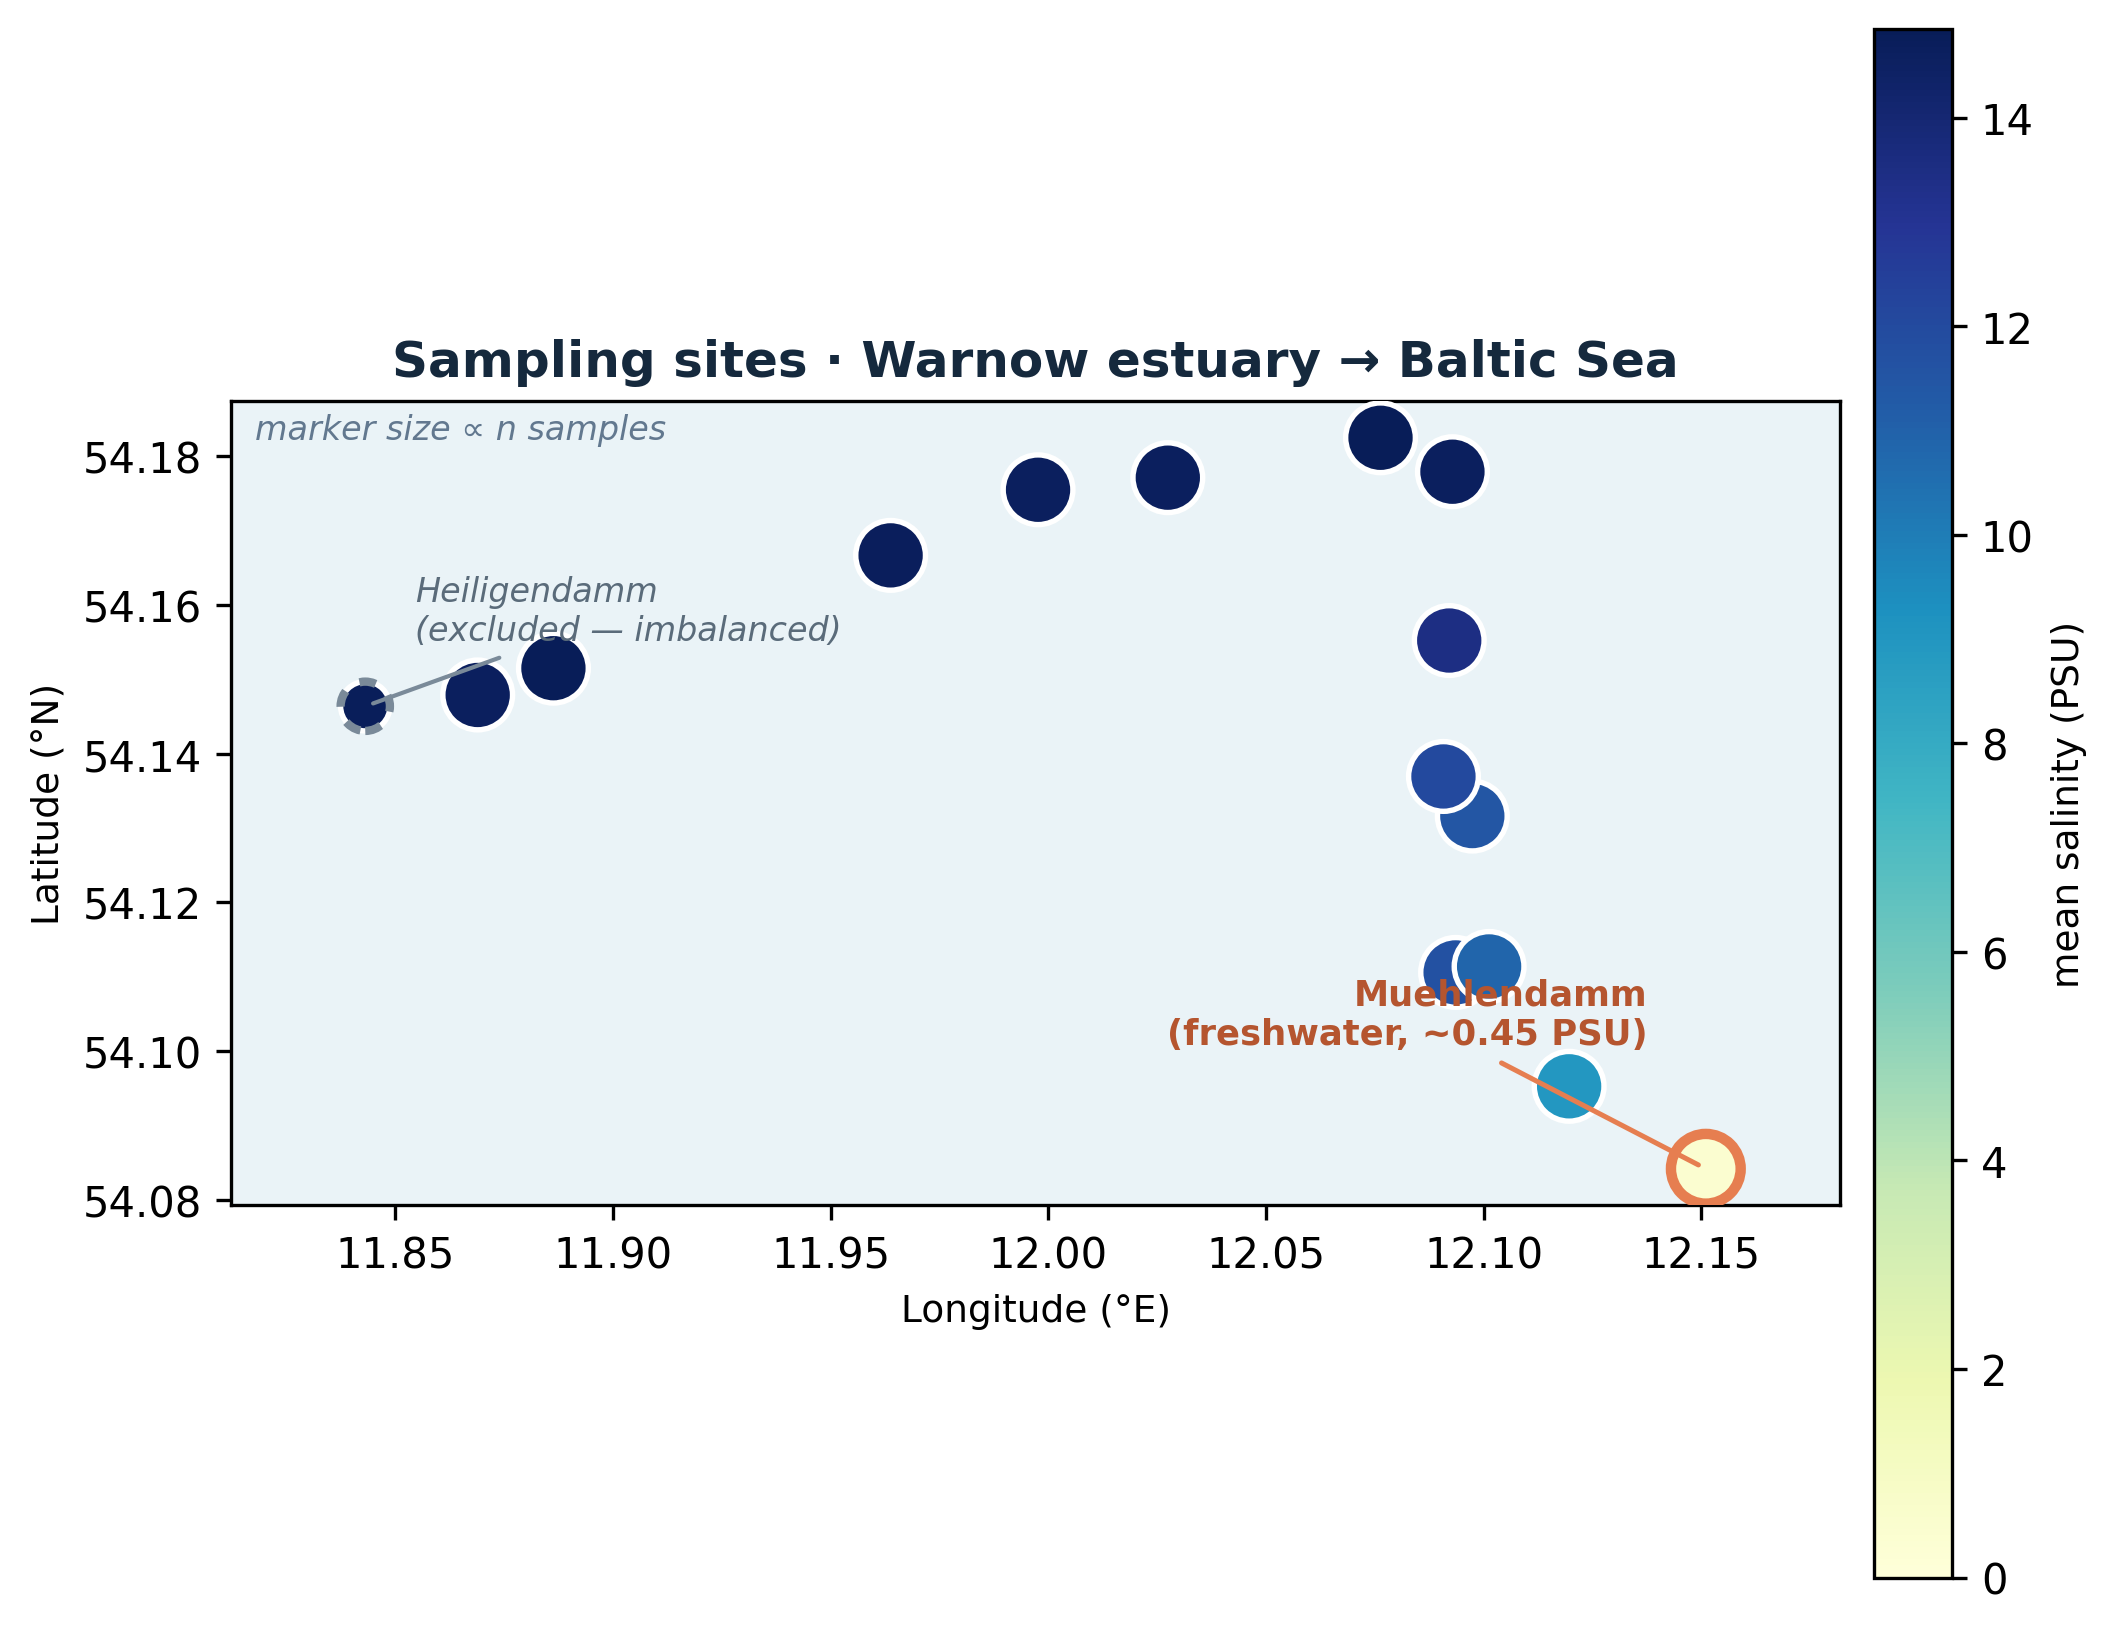

saved -> results/dataset_map.png


In [10]:
SHOW_ALL_15 = True

base = meta if SHOW_ALL_15 else meta[~meta[SITE].str.contains("eiligendamm", case=False, na=False)]
agg = (base.groupby(SITE)
           .agg(n=(SAL, "size"), mean_sal=(SAL, "mean"), ll=(LL, "first"))
           .reset_index())
agg[["lat", "lon"]] = agg["ll"].apply(parse_latlon)
agg = agg.dropna(subset=["lat", "lon"])

fig, ax = plt.subplots(figsize=(7.4, 7), dpi=300)
ax.set_facecolor("#EAF3F7")

sc = ax.scatter(agg["lon"], agg["lat"], c=agg["mean_sal"], cmap="YlGnBu",
                s=agg["n"] * 2.5, edgecolor="white", linewidth=1.3, zorder=3, vmin=0)

# right margin so the Muehlendamm label fits inside
xpad = (agg["lon"].max() - agg["lon"].min()) * 0.10
ax.set_xlim(agg["lon"].min() - xpad, agg["lon"].max() + xpad)

# Muehlendamm (freshwater outlier) -> label up-LEFT to stay in frame
mu = agg[agg[SITE].str.contains("hlendamm", case=False, na=False)]
if len(mu):
    ax.scatter(mu["lon"], mu["lat"], s=mu["n"]*2.5, facecolor="none",
               edgecolor="#E67E50", linewidth=2.5, zorder=4)
    ax.annotate("Muehlendamm\n(freshwater, ~0.45 PSU)",
                (mu["lon"].values[0], mu["lat"].values[0]),
                xytext=(-14, 30), textcoords="offset points", ha="right",
                fontsize=8.5, color="#B5552F", fontweight="bold",
                arrowprops=dict(arrowstyle="-", color="#E67E50", lw=1.2))

# Heiligendamm (excluded) if present
hd = agg[agg[SITE].str.contains("eiligendamm", case=False, na=False)]
if len(hd):
    ax.scatter(hd["lon"], hd["lat"], s=hd["n"]*2.5, facecolor="none",
               edgecolor="#7A8A99", linewidth=2.0, linestyle=(0,(2,2)), zorder=4)
    ax.annotate("Heiligendamm\n(excluded — imbalanced)",
                (hd["lon"].values[0], hd["lat"].values[0]),
                xytext=(12, 16), textcoords="offset points",
                fontsize=8, color="#5A6B7A", fontstyle="italic",
                arrowprops=dict(arrowstyle="-", color="#7A8A99", lw=1.0))

cb = plt.colorbar(sc, ax=ax, fraction=0.045, pad=0.02)
cb.set_label("mean salinity (PSU)", fontsize=9)

ax.set_aspect(1 / np.cos(np.deg2rad(agg["lat"].mean())))
ax.set_xlabel("Longitude (°E)", fontsize=9); ax.set_ylabel("Latitude (°N)", fontsize=9)
ax.set_title("Sampling sites · Warnow estuary → Baltic Sea",
             fontsize=12, fontweight="bold", color="#15293D")
# caption -> top-left corner (no collision)
ax.text(0.015, 0.985, "marker size ∝ n samples", transform=ax.transAxes,
        ha="left", va="top", fontsize=8, color="#62788F", style="italic")

plt.savefig("results/dataset_map.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
print("saved -> results/dataset_map.png")

loaded ASV table: ../data/otus_16s_filtered.csv | shape: (1602, 1236)
zeros: 56.6%   |   features: 1236   |   samples: 1602


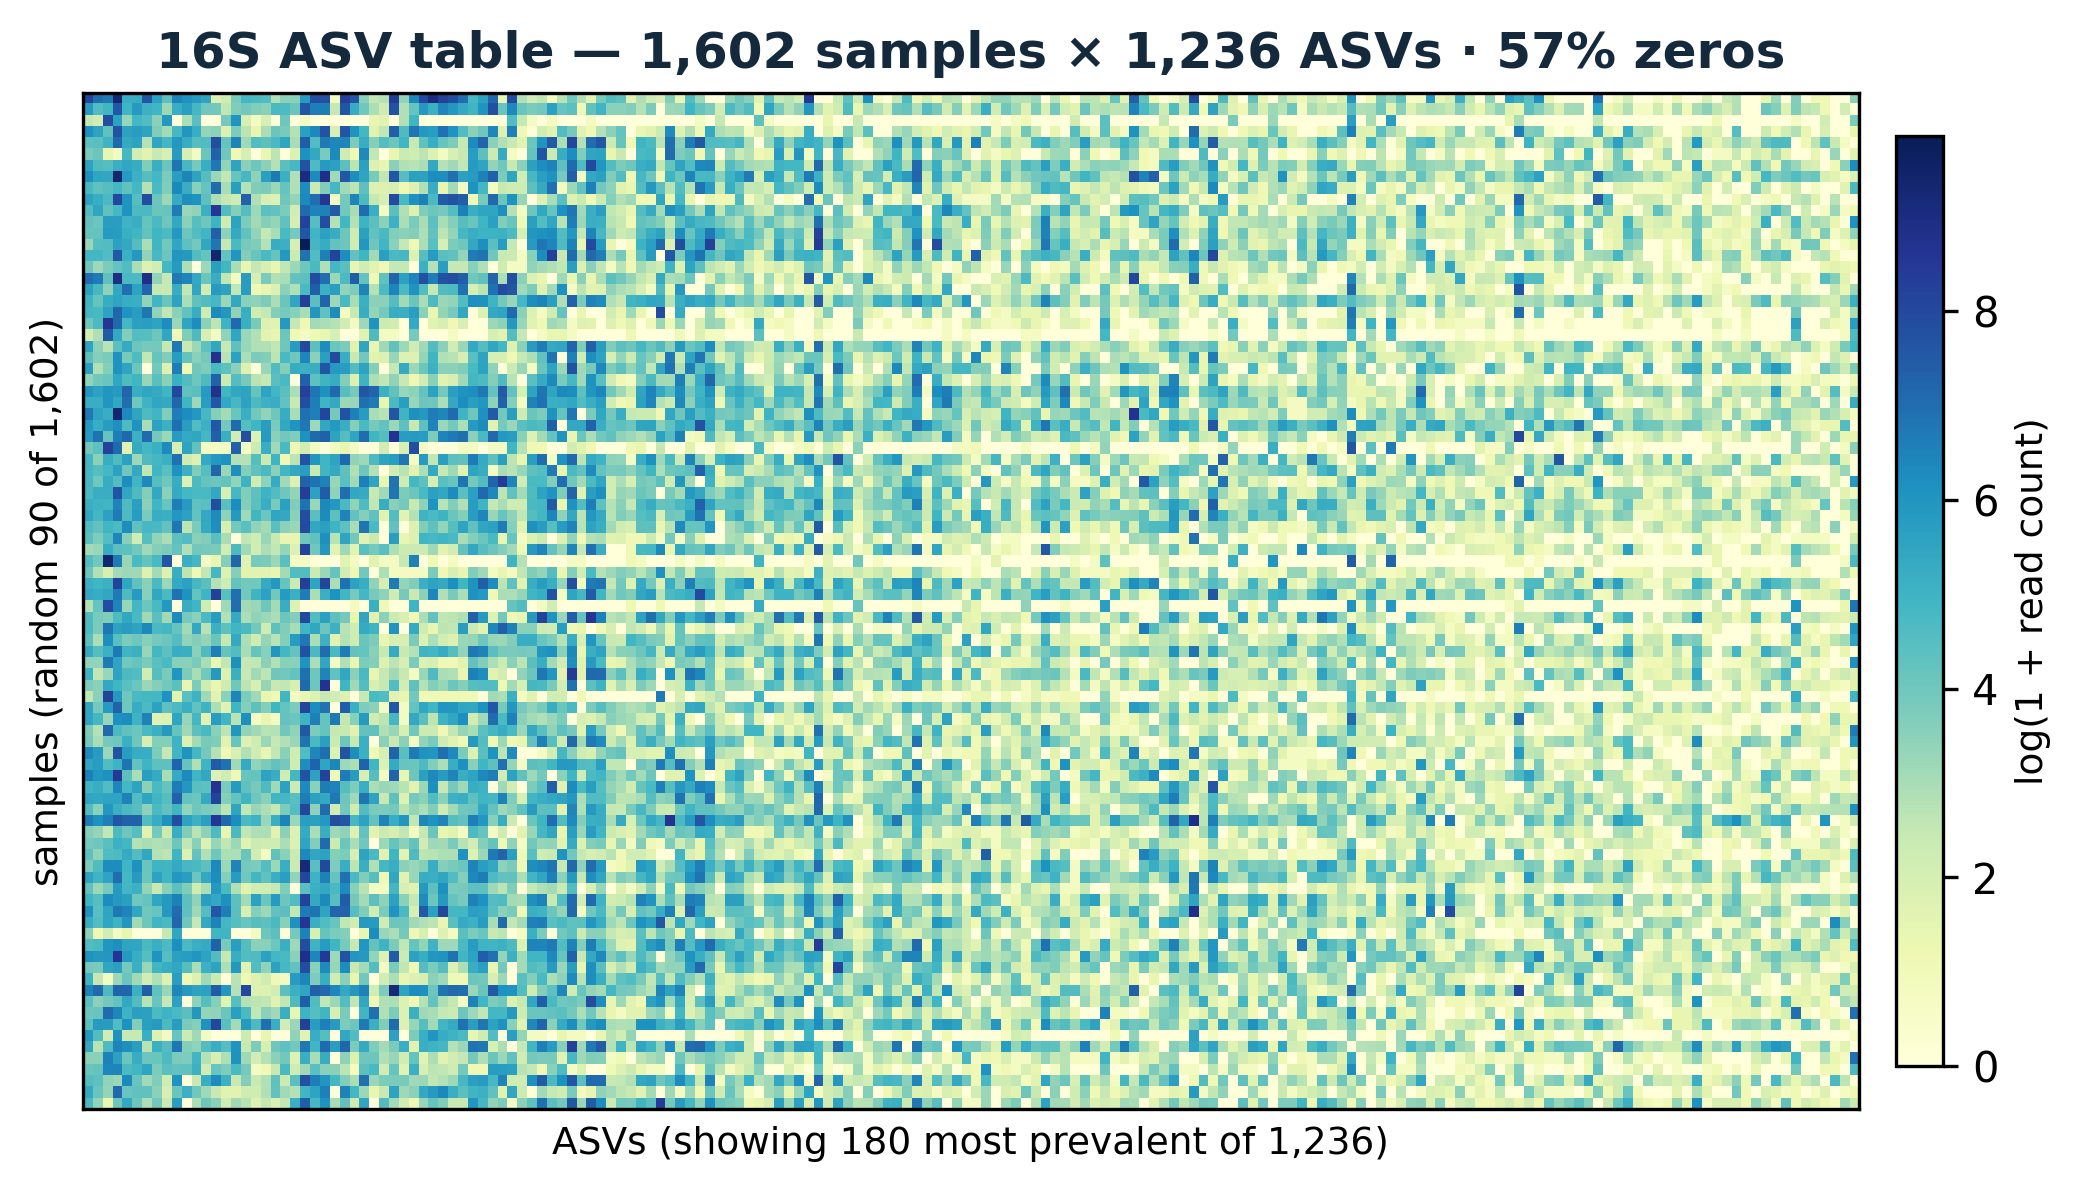

saved -> results/data_heatmap_16s.png


In [11]:
import os, glob
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
os.makedirs("results", exist_ok=True)

SEARCH_DIRS = ["../data", "data", "../data/raw", "."]
TARGET_NCOL = 1236   # 16S table. For 18S put 1054 here.

# --- auto-find the OTU/ASV table (wide numeric matrix closest to TARGET_NCOL cols) ---
cands = []
for d in SEARCH_DIRS:
    for f in glob.glob(os.path.join(d, "*.csv")):
        try:
            nc = len(pd.read_csv(f, nrows=0).columns)
        except Exception:
            continue
        if nc > 800:                       # OTU tables are very wide; metadata is not
            cands.append((abs(nc - TARGET_NCOL), f, nc))
assert cands, f"No wide (>800 col) ASV table found in {SEARCH_DIRS}."
cands.sort()
otu_path = cands[0][1]
otu = pd.read_csv(otu_path, index_col=0).apply(pd.to_numeric, errors="coerce").fillna(0)
print("loaded ASV table:", otu_path, "| shape:", otu.shape)

# --- real sparsity number (use this on the slide) ---
sparsity = (otu.values == 0).mean() * 100
print(f"zeros: {sparsity:.1f}%   |   features: {otu.shape[1]}   |   samples: {otu.shape[0]}")

# --- subsample for a readable heatmap (full table is too big to draw) ---
rng = np.random.default_rng(0)
n_rows = min(90, otu.shape[0])
n_cols = min(180, otu.shape[1])
samp_idx = rng.choice(otu.shape[0], n_rows, replace=False)
prevalence = (otu > 0).mean().sort_values(ascending=False)     # most-present ASVs first
top_asv = prevalence.head(n_cols).index
sub = np.log1p(otu.iloc[samp_idx][top_asv].values)

# --- heatmap ---
fig, ax = plt.subplots(figsize=(8, 4.4), dpi=300)
im = ax.imshow(sub, aspect="auto", cmap="YlGnBu", interpolation="nearest")
cb = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
cb.set_label("log(1 + read count)", fontsize=9)
ax.set_title(f"16S ASV table — {otu.shape[0]:,} samples × {otu.shape[1]:,} ASVs · "
             f"{sparsity:.0f}% zeros",
             fontsize=12, fontweight="bold", color="#15293D")
ax.set_xlabel(f"ASVs (showing {n_cols} most prevalent of {otu.shape[1]:,})", fontsize=9)
ax.set_ylabel(f"samples (random {n_rows} of {otu.shape[0]:,})", fontsize=9)
ax.set_xticks([]); ax.set_yticks([])
plt.savefig("results/data_heatmap_16s.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
print("saved -> results/data_heatmap_16s.png")

table: 1,602 samples x 1,236 ASVs
zeros: 57%
median non-zero ASVs per sample: 548 of 1,236
ASVs present in <5% of samples: 1%


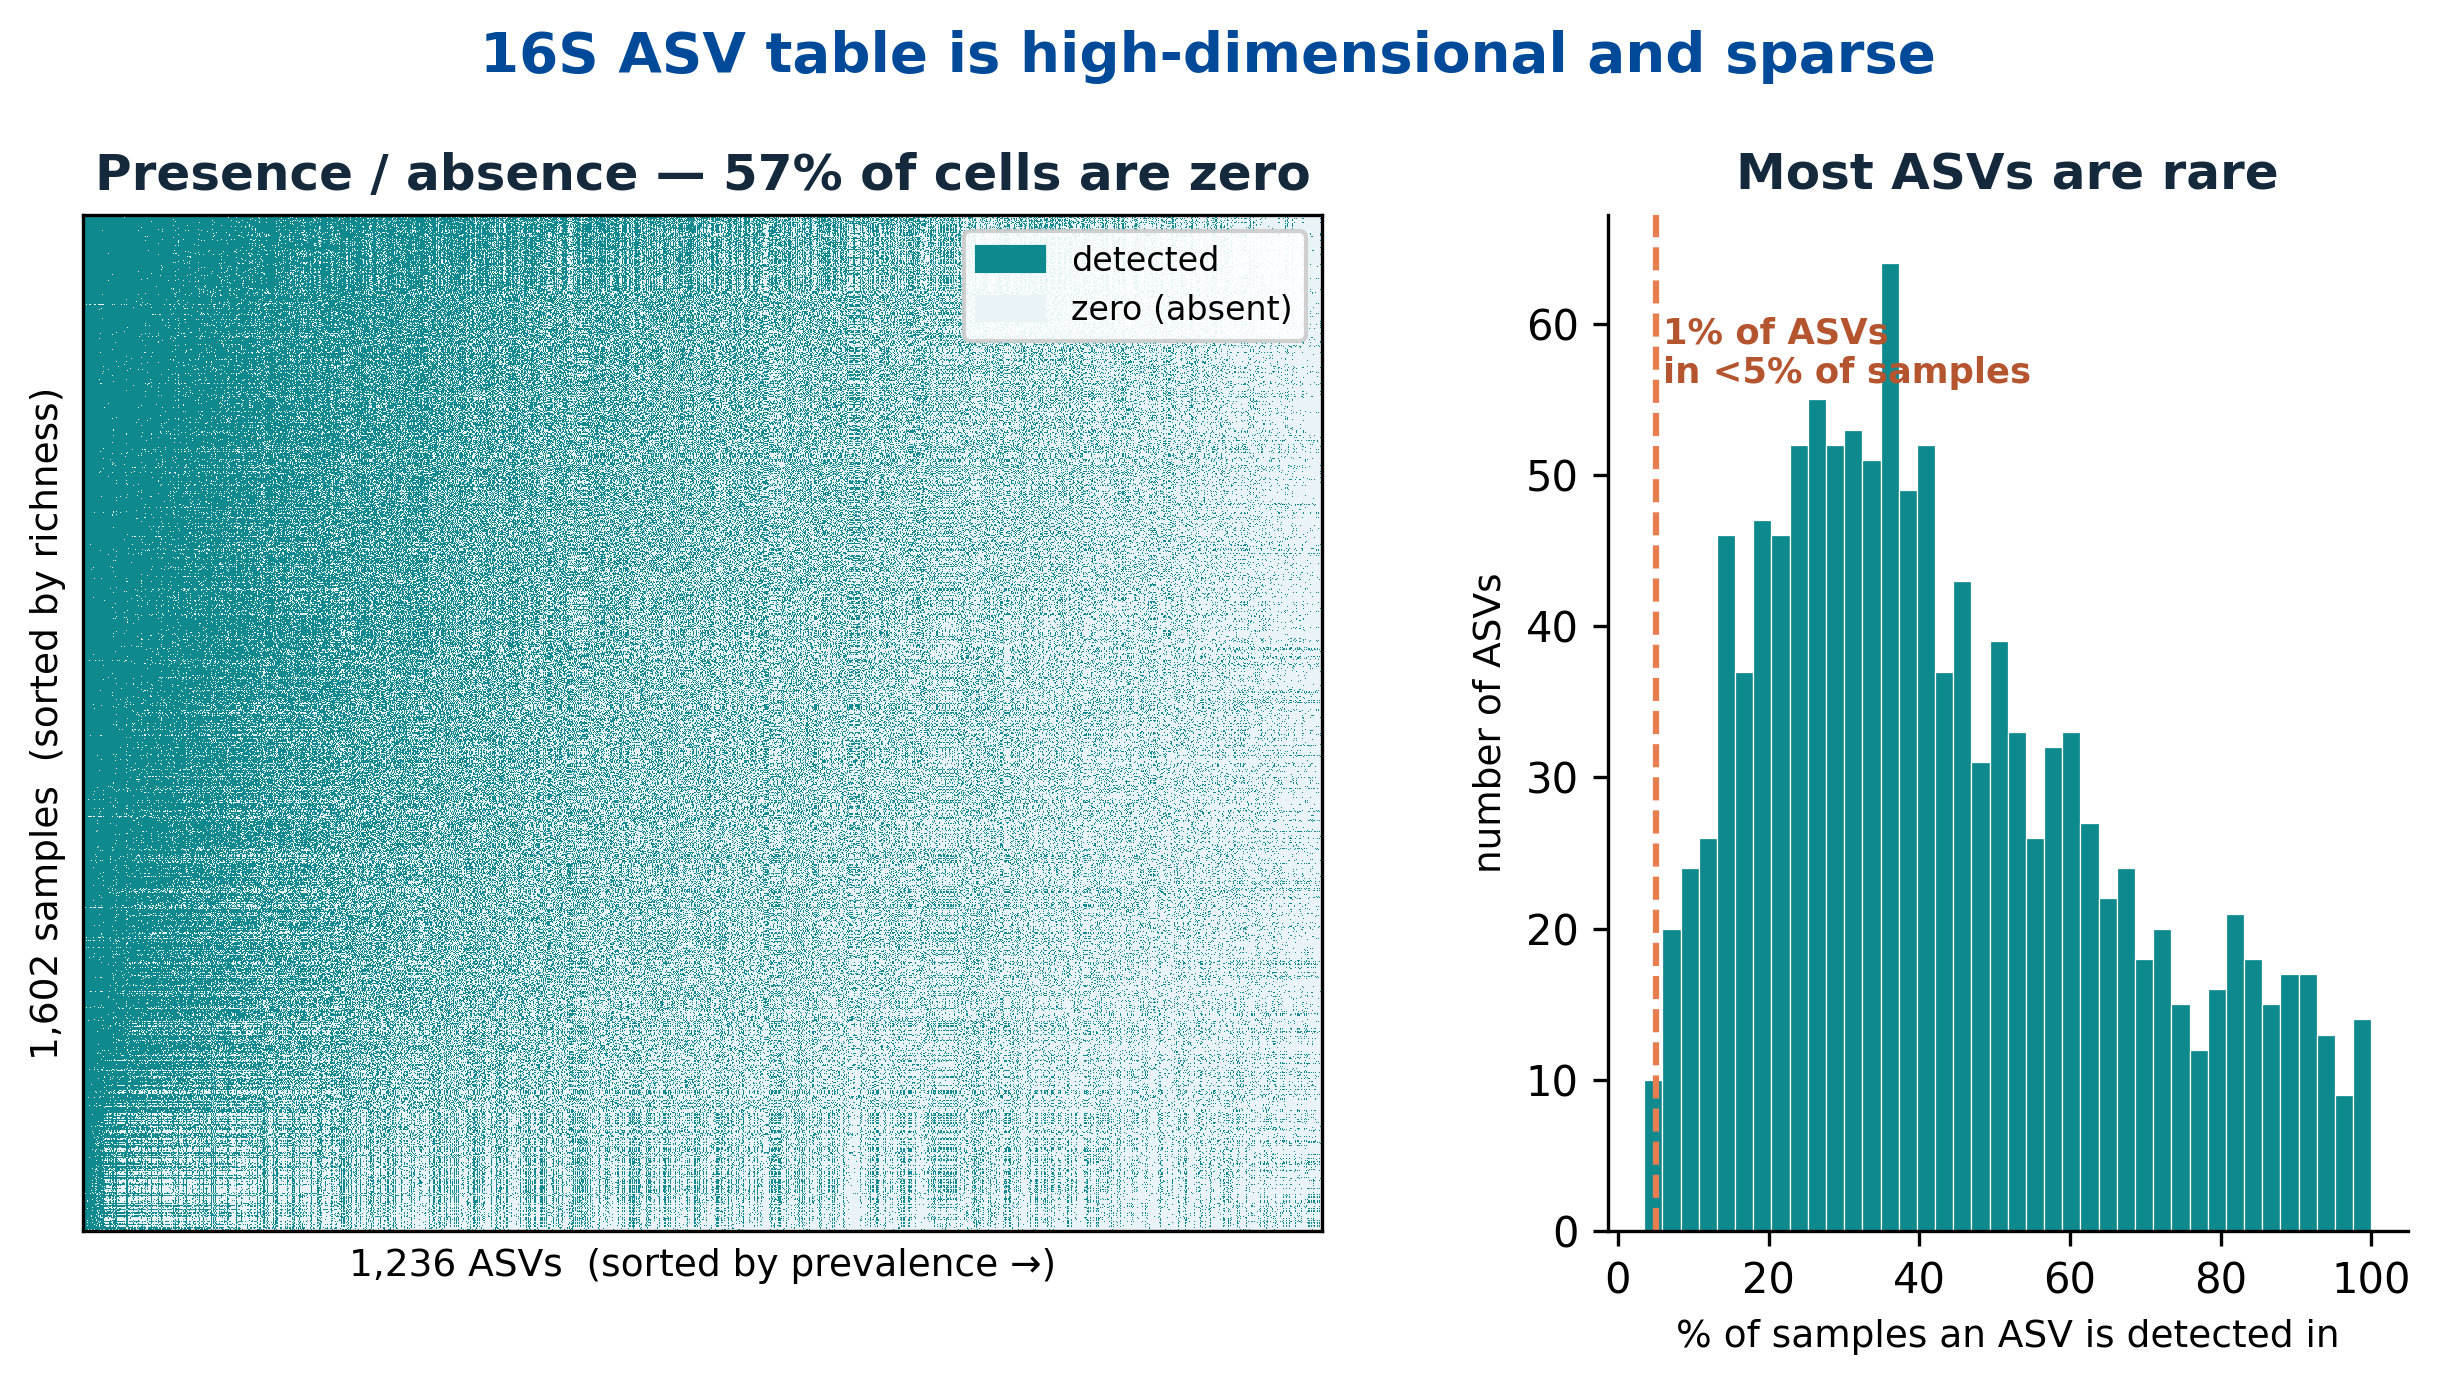

saved -> results/data_sparsity_16s.png


In [12]:
import os, glob
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
os.makedirs("results", exist_ok=True)

SEARCH_DIRS = ["../data", "data", "../data/raw", "."]
TARGET_NCOL = 1236   # 16S. For 18S use 1054.

# --- auto-load the ASV table (restart-proof) ---
cands = []
for d in SEARCH_DIRS:
    for f in glob.glob(os.path.join(d, "*.csv")):
        try: nc = len(pd.read_csv(f, nrows=0).columns)
        except Exception: continue
        if nc > 800: cands.append((abs(nc - TARGET_NCOL), f))
assert cands, f"No wide ASV table found in {SEARCH_DIRS}."
cands.sort(); otu_path = cands[0][1]
otu = pd.read_csv(otu_path, index_col=0).apply(pd.to_numeric, errors="coerce").fillna(0)

# --- real numbers for the slide ---
pres = otu > 0
pct_zero   = (~pres).values.mean() * 100
nz_per_smp = pres.sum(axis=1)
prevalence = pres.mean() * 100                       # % of samples each ASV is in
pct_rare   = (prevalence < 5).mean() * 100           # ASVs seen in <5% of samples
print(f"table: {otu.shape[0]:,} samples x {otu.shape[1]:,} ASVs")
print(f"zeros: {pct_zero:.0f}%")
print(f"median non-zero ASVs per sample: {int(nz_per_smp.median())} of {otu.shape[1]:,}")
print(f"ASVs present in <5% of samples: {pct_rare:.0f}%")

# --- sort by prevalence / richness for a clean nested pattern ---
col_order = prevalence.sort_values(ascending=False).index
row_order = nz_per_smp.sort_values(ascending=False).index
pa = pres.loc[row_order, col_order].values.astype(int)

TEAL, NAVY, INK, SLATE, BG = "#0E8A8F", "#004A99", "#15293D", "#62788F", "#EAF3F7"
fig = plt.figure(figsize=(10, 4.4), dpi=300)
gs = fig.add_gridspec(1, 2, width_ratios=[1.55, 1], wspace=0.28)

# Panel A — presence / absence
axA = fig.add_subplot(gs[0, 0])
axA.imshow(pa, aspect="auto", interpolation="nearest",
           cmap=ListedColormap([BG, TEAL]))
axA.set_title(f"Presence / absence — {pct_zero:.0f}% of cells are zero",
              fontsize=12, fontweight="bold", color=INK)
axA.set_xlabel(f"{otu.shape[1]:,} ASVs  (sorted by prevalence →)", fontsize=9)
axA.set_ylabel(f"{otu.shape[0]:,} samples  (sorted by richness)", fontsize=9)
axA.set_xticks([]); axA.set_yticks([])
# legend
from matplotlib.patches import Patch
axA.legend(handles=[Patch(color=TEAL, label="detected"),
                    Patch(color=BG, label="zero (absent)")],
           loc="upper right", fontsize=8, framealpha=0.9)

# Panel B — ASV prevalence (rare biosphere)
axB = fig.add_subplot(gs[0, 1])
axB.hist(prevalence, bins=40, color=TEAL, edgecolor="white", linewidth=0.3)
axB.axvline(5, color="#E67E50", lw=1.5, ls="--")
axB.text(6, axB.get_ylim()[1]*0.9, f"{pct_rare:.0f}% of ASVs\nin <5% of samples",
         fontsize=8.5, color="#B5552F", fontweight="bold", va="top")
axB.set_title("Most ASVs are rare", fontsize=12, fontweight="bold", color=INK)
axB.set_xlabel("% of samples an ASV is detected in", fontsize=9)
axB.set_ylabel("number of ASVs", fontsize=9)
for sp in ["top", "right"]: axB.spines[sp].set_visible(False)

fig.suptitle("16S ASV table is high-dimensional and sparse",
             fontsize=13.5, fontweight="bold", color=NAVY, y=1.02)
plt.savefig("results/data_sparsity_16s.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
print("saved -> results/data_sparsity_16s.png")

table: 1,602 samples x 1,236 ASVs
zeros: 57%
median non-zero ASVs per sample: 548 of 1,236 (44%)


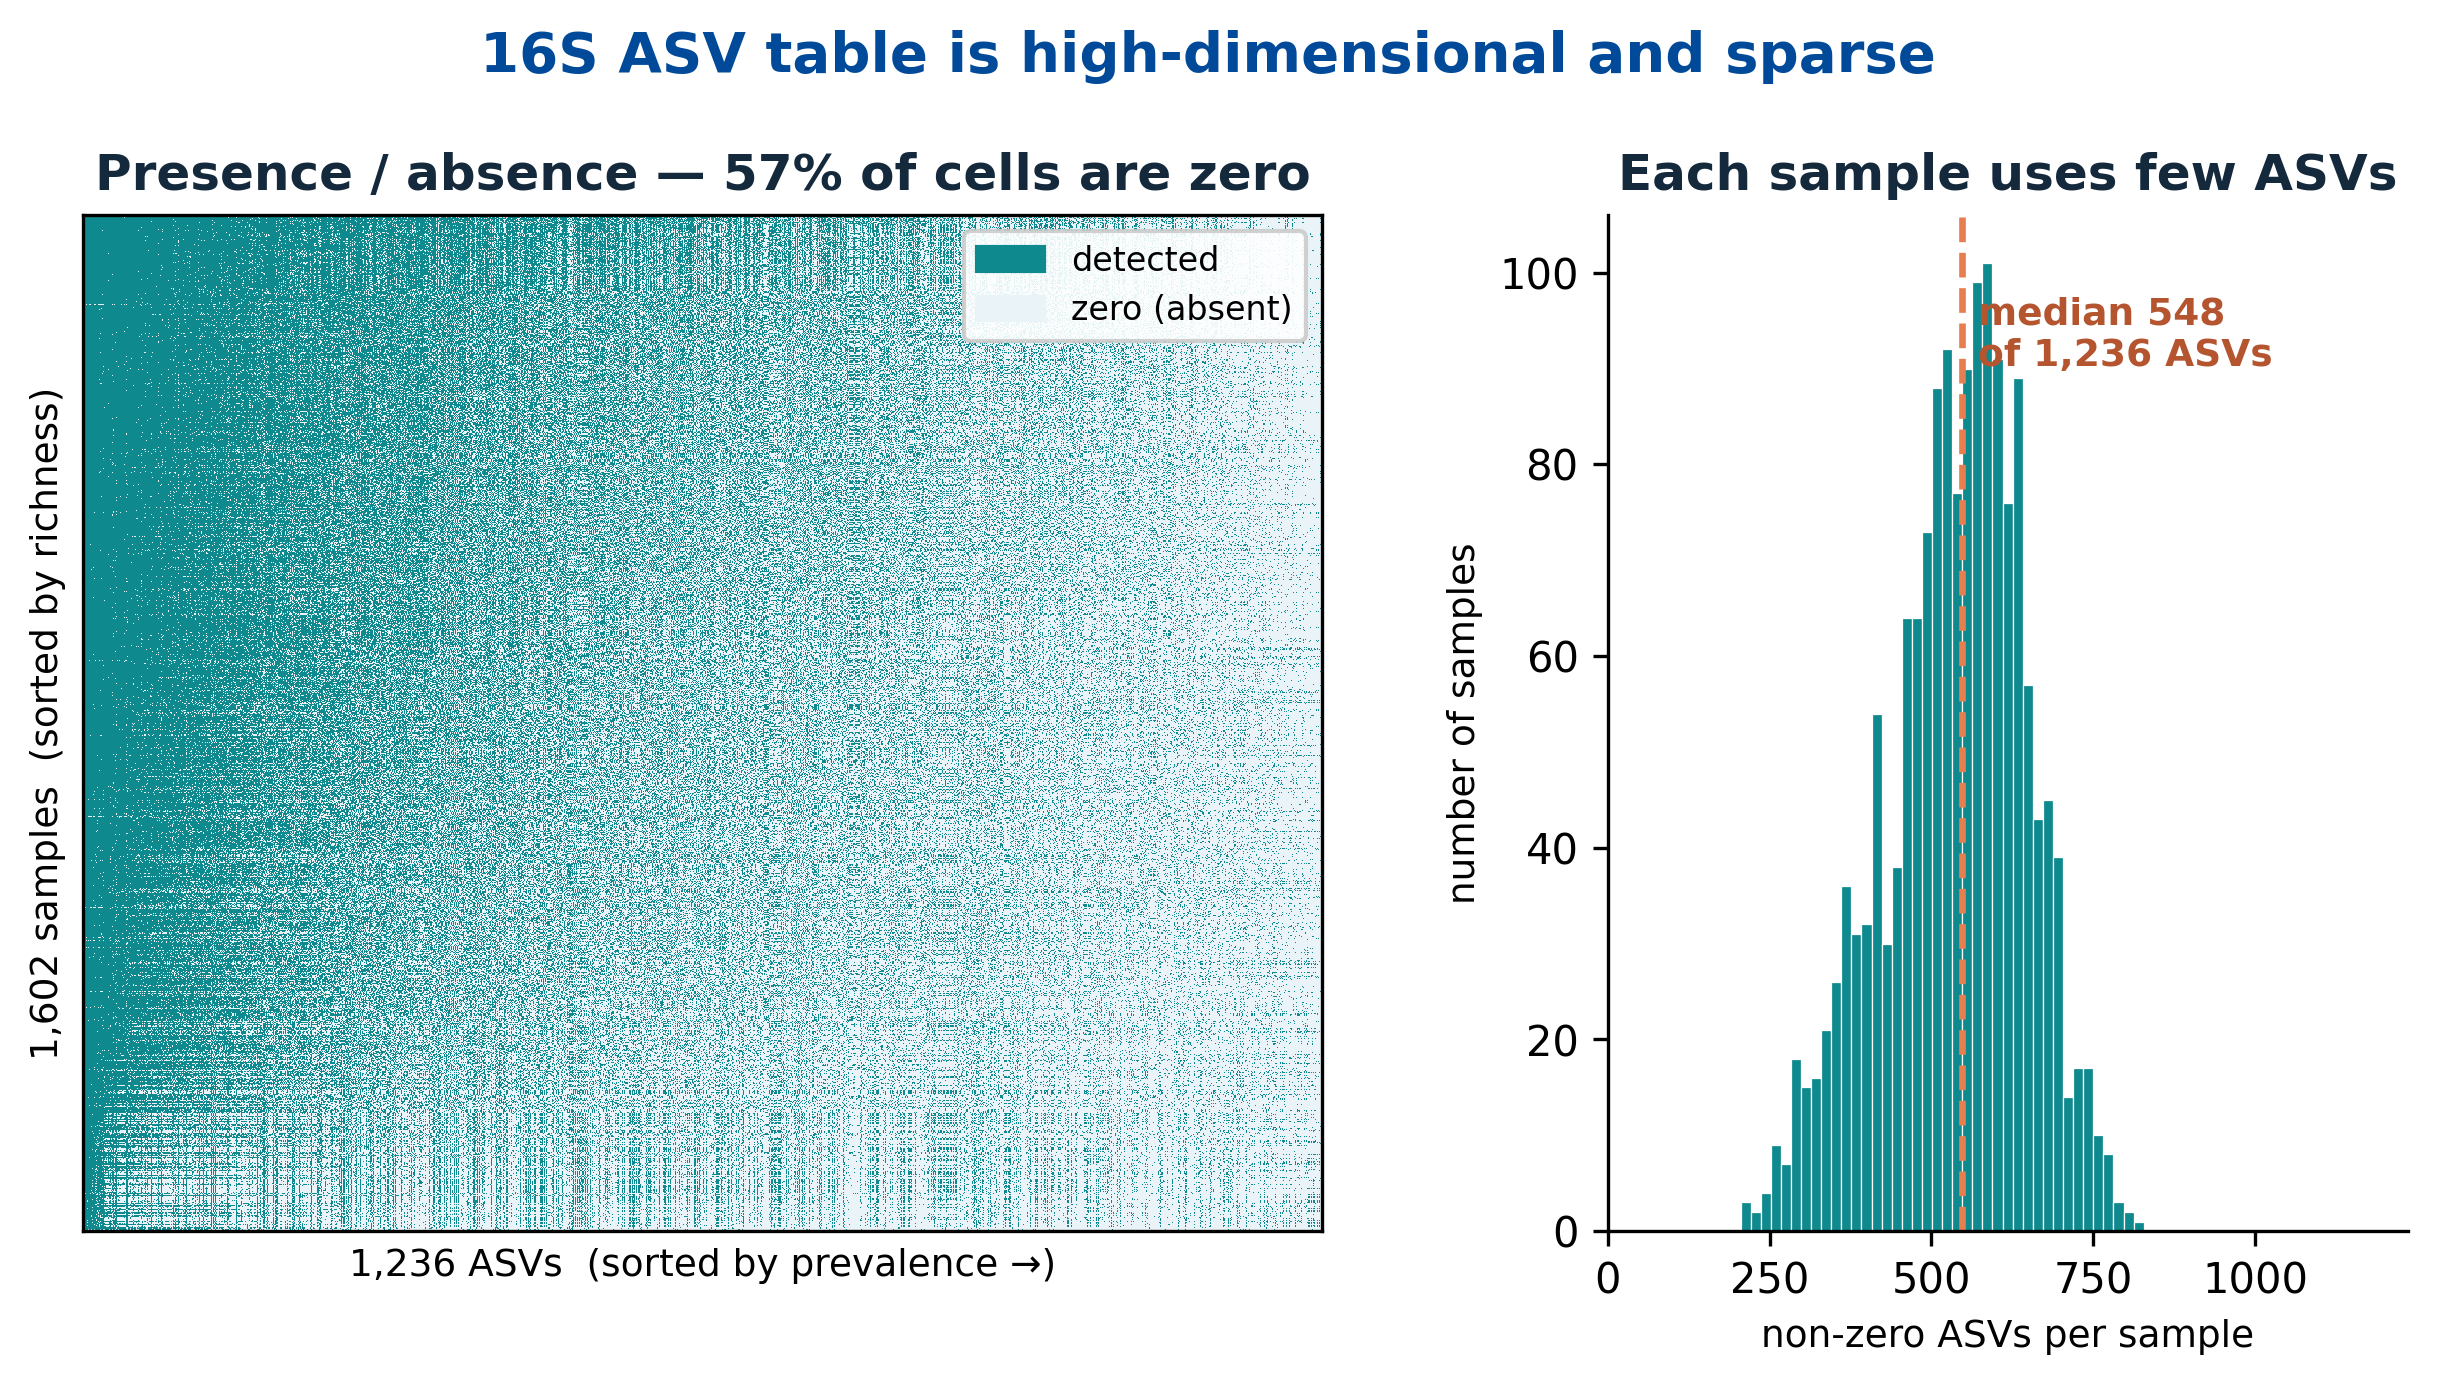

saved -> results/data_sparsity_16s.png


In [13]:
import os, glob
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
os.makedirs("results", exist_ok=True)

SEARCH_DIRS = ["../data", "data", "../data/raw", "."]
TARGET_NCOL = 1236   # 16S. For 18S use 1054.

# --- auto-load the ASV table (restart-proof) ---
cands = []
for d in SEARCH_DIRS:
    for f in glob.glob(os.path.join(d, "*.csv")):
        try: nc = len(pd.read_csv(f, nrows=0).columns)
        except Exception: continue
        if nc > 800: cands.append((abs(nc - TARGET_NCOL), f))
assert cands, f"No wide ASV table found in {SEARCH_DIRS}."
cands.sort(); otu_path = cands[0][1]
otu = pd.read_csv(otu_path, index_col=0).apply(pd.to_numeric, errors="coerce").fillna(0)

# --- real numbers for the slide ---
pres = otu > 0
pct_zero   = (~pres).values.mean() * 100
nz_per_smp = pres.sum(axis=1)
prevalence = pres.mean() * 100
med_nz = int(nz_per_smp.median())
print(f"table: {otu.shape[0]:,} samples x {otu.shape[1]:,} ASVs")
print(f"zeros: {pct_zero:.0f}%")
print(f"median non-zero ASVs per sample: {med_nz} of {otu.shape[1]:,} "
      f"({100*med_nz/otu.shape[1]:.0f}%)")

# --- sort for a clean nested presence pattern ---
col_order = prevalence.sort_values(ascending=False).index
row_order = nz_per_smp.sort_values(ascending=False).index
pa = pres.loc[row_order, col_order].values.astype(int)

TEAL, NAVY, INK, BG = "#0E8A8F", "#004A99", "#15293D", "#EAF3F7"
fig = plt.figure(figsize=(10, 4.4), dpi=300)
gs = fig.add_gridspec(1, 2, width_ratios=[1.55, 1], wspace=0.28)

# Panel A — presence / absence
axA = fig.add_subplot(gs[0, 0])
axA.imshow(pa, aspect="auto", interpolation="nearest", cmap=ListedColormap([BG, TEAL]))
axA.set_title(f"Presence / absence — {pct_zero:.0f}% of cells are zero",
              fontsize=12, fontweight="bold", color=INK)
axA.set_xlabel(f"{otu.shape[1]:,} ASVs  (sorted by prevalence →)", fontsize=9)
axA.set_ylabel(f"{otu.shape[0]:,} samples  (sorted by richness)", fontsize=9)
axA.set_xticks([]); axA.set_yticks([])
axA.legend(handles=[Patch(color=TEAL, label="detected"),
                    Patch(color=BG, label="zero (absent)")],
           loc="upper right", fontsize=8, framealpha=0.9)

# Panel B — non-zero ASVs per sample
axB = fig.add_subplot(gs[0, 1])
axB.hist(nz_per_smp, bins=40, color=TEAL, edgecolor="white", linewidth=0.3)
axB.axvline(med_nz, color="#E67E50", lw=1.6, ls="--")
axB.text(med_nz + otu.shape[1]*0.02, axB.get_ylim()[1]*0.92,
         f"median {med_nz}\nof {otu.shape[1]:,} ASVs",
         fontsize=9, color="#B5552F", fontweight="bold", va="top")
axB.set_title("Each sample uses few ASVs", fontsize=12, fontweight="bold", color=INK)
axB.set_xlabel("non-zero ASVs per sample", fontsize=9)
axB.set_ylabel("number of samples", fontsize=9)
axB.set_xlim(0, otu.shape[1])
for sp in ["top", "right"]: axB.spines[sp].set_visible(False)

fig.suptitle("16S ASV table is high-dimensional and sparse",
             fontsize=13.5, fontweight="bold", color=NAVY, y=1.02)
plt.savefig("results/data_sparsity_16s.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
print("saved -> results/data_sparsity_16s.png")

In [10]:
# ── Section 4.8: final dataset dimensions (self-contained) ────────────────
import pandas as pd

DATA_DIR = "../data/"

meta    = pd.read_csv(DATA_DIR + "combined_meta_data.csv", index_col=0)
otu_16s = pd.read_csv(DATA_DIR + "otus_16s_filtered.csv",  index_col=0)
otu_18s = pd.read_csv(DATA_DIR + "otus_18s_filtered.csv",  index_col=0)

# combined = inner join on sample ID, marker-prefixed columns
common = otu_16s.index.intersection(otu_18s.index)
otu_comb = pd.concat(
    [otu_16s.loc[common].add_prefix('16S_'),
     otu_18s.loc[common].add_prefix('18S_')], axis=1)

INPUTS  = {'16S': otu_16s, '18S': otu_18s, '16S+18S': otu_comb}
TARGETS = ['temperature', 'salinity', 'Chl_a_log1p',
           'Caffeine', 'Metoprolol', 'Atrazine']

print("meta columns:", list(meta.columns), "\n")

print("=== Input configurations ===")
for name, X in INPUTS.items():
    zeros = (X == 0).to_numpy().mean()
    print(f"{name:10s} samples={X.shape[0]:5d}  features={X.shape[1]:5d}  zeros={zeros:6.1%}")

print("\n=== Effective sample size per target x input ===")
print(f"{'input':10s}{'target':16s}{'n':>7s}{'n>0':>8s}")
print("-" * 41)
for name, X in INPUTS.items():
    ids = meta.index.intersection(X.index)
    for t in TARGETS:
        if t not in meta.columns:
            continue
        s  = meta.loc[ids, t]
        n  = int(s.notna().sum())
        nz = int((s.dropna() > 0).sum())
        print(f"{name:10s}{t:16s}{n:7d}{nz:8d}")
    print()

print("=== Sites ===")
site_col = next((c for c in ['site_name', 'site', 'station', 'Site'] if c in meta.columns), None)
print("site column:", site_col)
if site_col:
    print(meta[site_col].value_counts().sort_index().to_string())

meta columns: ['location_id', 'day_id', 'cw_id', 'year_id', 'location_name', 'rough_lat_long', 'date', 'PO4', 'NOx', 'NH4', 'NO2', 'NO3', 'temperature', 'salinity', 'Chl_a', 'Phaeo', 'Chl_a_conc', 'f0', 'fa', 'volume', 'time'] 

=== Input configurations ===
16S        samples= 1602  features= 1236  zeros= 56.6%
18S        samples= 1599  features= 1054  zeros= 74.1%
16S+18S    samples= 1589  features= 2290  zeros= 64.6%

=== Effective sample size per target x input ===
input     target                n     n>0
-----------------------------------------
16S       temperature        1266    1266
16S       salinity           1259    1258

18S       temperature        1267    1267
18S       salinity           1260    1259

16S+18S   temperature        1263    1263
16S+18S   salinity           1256    1255

=== Sites ===
site column: None


In [11]:
# ── Section 4.8 (part 2): targets + sites, corrected column names ─────────
import numpy as np

# Chl_a_log1p is derived, not stored — recreate it as in the pipeline
meta['Chl_a_log1p'] = np.log1p(meta['Chl_a'].clip(lower=0))

ENV_TARGETS = ['temperature', 'salinity', 'Chl_a_log1p']

print("=== Environmental targets: effective n per input ===")
print(f"{'input':10s}{'target':16s}{'n':>7s}")
print("-" * 33)
for name, X in INPUTS.items():
    ids = meta.index.intersection(X.index)
    for t in ENV_TARGETS:
        print(f"{name:10s}{t:16s}{int(meta.loc[ids, t].notna().sum()):7d}")
    print()

print("=== Sites (location_name) ===")
vc = meta['location_name'].value_counts().sort_index()
print(vc.to_string())
print(f"\nn sites = {len(vc)}")

print("\n=== Salinity per site ===")
sal = (meta.groupby('location_name')['salinity']
            .agg(['count', 'mean', 'std', 'min', 'max'])
            .sort_values('mean'))
print(sal.round(2).to_string())

=== Environmental targets: effective n per input ===
input     target                n
---------------------------------
16S       temperature        1266
16S       salinity           1259
16S       Chl_a_log1p        1447

18S       temperature        1267
18S       salinity           1260
18S       Chl_a_log1p        1446

16S+18S   temperature        1263
16S+18S   salinity           1256
16S+18S   Chl_a_log1p        1438

=== Sites (location_name) ===
location_name
Boergerende Strand         112
Diedrichshagen             112
Elmenhorst Strand          112
Heiligendamm                56
Jemnitzschleuse            112
Mittelmole Warnemuende     112
Muehlendamm                112
Neptun-Werft               112
Parkplatz zur Warnow       112
SAB Marina Bramow          112
Schmarl-Dorf / IGA-Park    112
Schwimmhalle Gehlsdorf     112
Stadthafen Rostock         112
Steilkueste Nienhagen      112
Warnemuende Strand         112

n sites = 15

=== Salinity per site ===
                    

In [12]:
# ── Phase 3 targets: sample counts under the zero scheme ──────────────────
hplc = pd.read_csv(DATA_DIR + "hplc_submission.csv", index_col=0)
print("hplc shape:", hplc.shape)
print("columns:", [c for c in hplc.columns if any(
    k in c.lower() for k in ['caffe', 'metopro', 'atraz'])])
print(hplc.head(3).to_string())

hplc shape: (1433, 36)
columns: ['Metoprolol', 'Caffeine', 'Desisopropylatrazine', 'Atrazine']
         2,4-D  MCPA ClofibricAcid Dichlorprop Mecoprop Fenofibrat Metoprolol Propranolol Bentazone Chlorotoluron Isoproturon Terbutryn Diuron Irgarol Sulfamethoxazole  Caffeine Desisopropylatrazine Chloridazone Simazine Propyphenazone Carbamazepine Atrazine Diflufenican_AE_B107137 Terbuthylazine Diclofenac Diflufenican Trimethoprim Metazachlor 4-DHB  BP-4 BP-2 BP-1  UV-P    OC OD_PABA  BP-3
s15T1822  <2.4  <2.9          <1.7        <2.1     <2.2       <2.6      <11.7        <5.6      <1.1          <1.1        <1.9      <3.4   <2.0    <2.8              3.6      11.9                 <1.8         <2.7     #2.0           <3.1          11.3     <1.6                    <2.0           <3.1       <5.3         <1.4          NaN         NaN   NaN   NaN  NaN  NaN  <5.2  14.4     NaN     0
s05M2522  <2.4  <2.9          <1.7        <2.1     <2.2       <2.6      <11.7        <5.6      <1.1          <1.1  

In [13]:
# ── Phase 3 targets under the zero scheme ─────────────────────────────────
import numpy as np

GRADIENT = ['Caffeine', 'Metoprolol', 'Atrazine']

def to_zero_scheme(s):
    """'<x' (below LOD) and '#x' (below LOQ) -> 0; NaN stays NaN; else float."""
    def conv(v):
        if pd.isna(v):
            return np.nan
        v = str(v).strip()
        if v.startswith('<') or v.startswith('#'):
            return 0.0
        try:
            return float(v)
        except ValueError:
            return np.nan
    return s.map(conv)

hplc_z = hplc[GRADIENT].apply(to_zero_scheme)

# align to the metabarcoding samples
ids = meta.index.intersection(hplc_z.index)
print(f"matched samples (meta ∩ hplc): {len(ids)}\n")

print(f"{'target':14s}{'n':>7s}{'n>0':>8s}{'% >0':>8s}")
print("-" * 37)
for c in GRADIENT:
    s  = hplc_z.loc[ids, c]
    n  = int(s.notna().sum())
    nz = int((s.dropna() > 0).sum())
    print(f"{c:14s}{n:7d}{nz:8d}{100*nz/n:7.1f}%")

# per-input effective n for Phase 3
print("\n=== Phase 3: n per target x input ===")
for name, X in INPUTS.items():
    ids2 = meta.index.intersection(X.index).intersection(hplc_z.index)
    for c in GRADIENT:
        print(f"{name:10s}{c:14s}{int(hplc_z.loc[ids2, c].notna().sum()):7d}")
    print()

matched samples (meta ∩ hplc): 1433

target              n     n>0    % >0
-------------------------------------
Caffeine         1300    1300  100.0%
Metoprolol       1302     391   30.0%
Atrazine         1298      57    4.4%

=== Phase 3: n per target x input ===
16S       Caffeine         1294
16S       Metoprolol       1296
16S       Atrazine         1292

18S       Caffeine         1293
18S       Metoprolol       1295
18S       Atrazine         1291

16S+18S   Caffeine         1291
16S+18S   Metoprolol       1293
16S+18S   Atrazine         1289



In [14]:
# lock Phase 3 percentages to the same per-input masks as Table 4.X
for name, X in INPUTS.items():
    ids = meta.index.intersection(X.index).intersection(hplc_z.index)
    print(f"--- {name} ---")
    for c in GRADIENT:
        s  = hplc_z.loc[ids, c]
        n  = int(s.notna().sum())
        nz = int((s.dropna() > 0).sum())
        print(f"  {c:12s} n={n:5d}  n>0={nz:5d}  {100*nz/n:5.1f}%")

--- 16S ---
  Caffeine     n= 1294  n>0= 1294  100.0%
  Metoprolol   n= 1296  n>0=  387   29.9%
  Atrazine     n= 1292  n>0=   57    4.4%
--- 18S ---
  Caffeine     n= 1293  n>0= 1293  100.0%
  Metoprolol   n= 1295  n>0=  388   30.0%
  Atrazine     n= 1291  n>0=   57    4.4%
--- 16S+18S ---
  Caffeine     n= 1291  n>0= 1291  100.0%
  Metoprolol   n= 1293  n>0=  387   29.9%
  Atrazine     n= 1289  n>0=   57    4.4%


In [15]:
# Does the HPLC file actually contain Heiligendamm samples?
ids_h = meta.index.intersection(hplc.index)
print(meta.loc[ids_h, 'location_name'].value_counts().sort_index().to_string())
print("\nn sites in HPLC subset:", meta.loc[ids_h, 'location_name'].nunique())

location_name
Boergerende Strand         104
Diedrichshagen             103
Elmenhorst Strand          105
Jemnitzschleuse            103
Mittelmole Warnemuende     102
Muehlendamm                103
Neptun-Werft                99
Parkplatz zur Warnow       101
SAB Marina Bramow          102
Schmarl-Dorf / IGA-Park    101
Schwimmhalle Gehlsdorf     101
Stadthafen Rostock         103
Steilkueste Nienhagen      103
Warnemuende Strand         103

n sites in HPLC subset: 14


In [16]:
print(len(hplc.columns), "columns")
print(sorted(hplc.columns))

36 columns
['2,4-D', '4-DHB', 'Atrazine', 'BP-1', 'BP-2', 'BP-3', 'BP-4', 'Bentazone', 'Caffeine', 'Carbamazepine', 'Chloridazone', 'Chlorotoluron', 'ClofibricAcid', 'Desisopropylatrazine', 'Dichlorprop', 'Diclofenac', 'Diflufenican', 'Diflufenican_AE_B107137', 'Diuron', 'Fenofibrat', 'Irgarol', 'Isoproturon', 'MCPA', 'Mecoprop', 'Metazachlor', 'Metoprolol', 'OC', 'OD_PABA', 'Propranolol', 'Propyphenazone', 'Simazine', 'Sulfamethoxazole', 'Terbuthylazine', 'Terbutryn', 'Trimethoprim', 'UV-P']


In [17]:
ids16 = meta.index.intersection(otu_16s.index)
h = meta.loc[ids16, 'location_name'] == 'Heiligendamm'
print(f"16S total={len(ids16)}, Heiligendamm={h.sum()}, without={len(ids16)-h.sum()}")

16S total=1602, Heiligendamm=51, without=1551


In [18]:
import inspect, sys
sys.path.append('../src')
from cv_strategies import leave_one_site_out
print(inspect.getsource(leave_one_site_out))

def leave_one_site_out(meta, site_col='location_name'):
    """
    Leave-one-site-out CV — each fold uses all samples from exactly one site
    as test, and all samples from the remaining sites as training.

    This answers: "Does the model generalise to a sampling location it has
    never seen?" — the most demanding test of spatial generalisation.

    With 14 sites (after Heiligendamm removal), this returns 14 folds.

    Parameters
    ----------
    meta : pandas.DataFrame
    site_col : str, default 'location_name'

    Returns
    -------
    list of (train_idx, test_idx) tuples, length = number of unique sites.
    """
    sites = sorted(meta[site_col].unique())
    splits = []
    for site in sites:
        test_mask = (meta[site_col] == site).values
        test_idx = np.where(test_mask)[0]
        train_idx = np.where(~test_mask)[0]
        splits.append((train_idx, test_idx))
    return splits



In [19]:
!grep -rn "Heiligendamm" ../notebooks/*.ipynb ../src/*.py 2>/dev/null | head -20

Ambiguous output redirect.


In [20]:
splits = leave_one_site_out(meta)
print("folds from raw meta:", len(splits))
print("sites:", sorted(meta['location_name'].unique()))

folds from raw meta: 15
sites: ['Boergerende Strand', 'Diedrichshagen', 'Elmenhorst Strand', 'Heiligendamm', 'Jemnitzschleuse', 'Mittelmole Warnemuende', 'Muehlendamm', 'Neptun-Werft', 'Parkplatz zur Warnow', 'SAB Marina Bramow', 'Schmarl-Dorf / IGA-Park', 'Schwimmhalle Gehlsdorf', 'Stadthafen Rostock', 'Steilkueste Nienhagen', 'Warnemuende Strand']


In [21]:
import subprocess
out = subprocess.run(
    "grep -rn Heiligendamm ../notebooks ../src",
    shell=True, capture_output=True, text=True, executable="/bin/bash")
print(out.stdout[:4000] or "no match")

../notebooks/01_data_exploration.ipynb:99:       "      <td>Heiligendamm</td>\n",
../notebooks/01_data_exploration.ipynb:123:       "      <td>Heiligendamm</td>\n",
../notebooks/01_data_exploration.ipynb:147:       "      <td>Heiligendamm</td>\n",
../notebooks/01_data_exploration.ipynb:171:       "      <td>Heiligendamm</td>\n",
../notebooks/01_data_exploration.ipynb:195:       "      <td>Heiligendamm</td>\n",
../notebooks/01_data_exploration.ipynb:220:       "s01X0123            1      X      1       23  Heiligendamm   \n",
../notebooks/01_data_exploration.ipynb:221:       "s01X0223            1      X      2       23  Heiligendamm   \n",
../notebooks/01_data_exploration.ipynb:222:       "s01X0323            1      X      3       23  Heiligendamm   \n",
../notebooks/01_data_exploration.ipynb:223:       "s01X0423            1      X      4       23  Heiligendamm   \n",
../notebooks/01_data_exploration.ipynb:224:       "s01X0523            1      X      5       23  Heiligendamm   \n",
.

In [22]:
import glob, os
print("files in ../data/:")
for f in sorted(glob.glob('../data/*.csv')):
    print(" ", os.path.basename(f))

files in ../data/:
  collected_algae_data.csv
  collected_bacteria_data.csv
  combined_meta_data.csv
  hplc_submission.csv
  otus_16s_filtered.csv
  otus_16s_full.csv
  otus_18s_filtered.csv
  otus_18s_full.csv
  taxonomy_16s.csv
  taxonomy_18s.csv


In [23]:
import json
nb = json.load(open('../notebooks/01_data_exploration.ipynb'))
for i, c in enumerate(nb['cells']):
    src = ''.join(c['source'])
    if 'Heiligendamm' in src and c['cell_type'] == 'code':
        print(f"--- cell {i} ---\n{src}\n")

--- cell 15 ---
print("Samples per location:")
loc_counts = meta_master.groupby(['location_id', 'location_name']).size()
print(loc_counts)
print()
print(f"Total locations: {meta_master['location_id'].nunique()}")
print(f"Min samples per site: {loc_counts.min()}")
print(f"Max samples per site: {loc_counts.max()}")

# Heiligendamm has only 51 samples, and it's a more open-Baltic site compared to the other brackish Warnow sites.
#  Should I keep it as is, drop it for balance, or stratify by site during CV?



In [24]:
# rebuild Table 4.8 on the actual modelling master (Heiligendamm excluded)
import numpy as np
meta_m = meta[meta['location_name'] != 'Heiligendamm'].copy()
meta_m['Chl_a_log1p'] = np.log1p(meta_m['Chl_a'].clip(lower=0))

print("n sites:", meta_m['location_name'].nunique())

print("\n=== Input configurations (Heiligendamm excluded) ===")
for name, X in INPUTS.items():
    ids = meta_m.index.intersection(X.index)
    Xs = X.loc[ids]
    print(f"{name:10s} samples={len(ids):5d}  features={Xs.shape[1]:5d}  "
          f"zeros={(Xs==0).to_numpy().mean():6.1%}")

print("\n=== n per target x input ===")
for name, X in INPUTS.items():
    ids = meta_m.index.intersection(X.index)
    for t in ['temperature','salinity','Chl_a_log1p']:
        print(f"{name:10s}{t:14s}{int(meta_m.loc[ids,t].notna().sum()):7d}")
    ids2 = ids.intersection(hplc_z.index)
    for c in GRADIENT:
        s = hplc_z.loc[ids2, c]
        n, nz = int(s.notna().sum()), int((s.dropna()>0).sum())
        print(f"{name:10s}{c:14s}{n:7d}  n>0={nz:5d}  {100*nz/n:5.1f}%")
    print()

print("=== brackish salinity range (13 sites, excl. Muehlendamm) ===")
sal = meta_m.groupby('location_name')['salinity'].mean().drop('Muehlendamm')
print(f"{sal.min():.2f} – {sal.max():.2f} PSU")

n sites: 14

=== Input configurations (Heiligendamm excluded) ===
16S        samples= 1551  features= 1236  zeros= 56.5%
18S        samples= 1546  features= 1054  zeros= 74.1%
16S+18S    samples= 1538  features= 2290  zeros= 64.6%

=== n per target x input ===
16S       temperature      1226
16S       salinity         1220
16S       Chl_a_log1p      1446
16S       Caffeine         1294  n>0= 1294  100.0%
16S       Metoprolol       1296  n>0=  387   29.9%
16S       Atrazine         1292  n>0=   57    4.4%

18S       temperature      1227
18S       salinity         1221
18S       Chl_a_log1p      1445
18S       Caffeine         1293  n>0= 1293  100.0%
18S       Metoprolol       1295  n>0=  388   30.0%
18S       Atrazine         1291  n>0=   57    4.4%

16S+18S   temperature      1223
16S+18S   salinity         1217
16S+18S   Chl_a_log1p      1437
16S+18S   Caffeine         1291  n>0= 1291  100.0%
16S+18S   Metoprolol       1293  n>0=  387   29.9%
16S+18S   Atrazine         1289  n>0=   5

In [25]:
h = meta[meta['location_name'] == 'Heiligendamm']
print("Heiligendamm rows in meta:", len(h))
for t in ['temperature', 'salinity', 'Chl_a']:
    print(f"  {t:12s} non-missing = {h[t].notna().sum()}")

# and: does Chl_a exceed the 16S base sample count?
ids = meta[meta['location_name'] != 'Heiligendamm'].index.intersection(otu_16s.index)
print("\n16S base samples:", len(ids))
print("Chl_a non-missing among them:", meta.loc[ids, 'Chl_a'].notna().sum())

Heiligendamm rows in meta: 56
  temperature  non-missing = 40
  salinity     non-missing = 39
  Chl_a        non-missing = 1

16S base samples: 1551
Chl_a non-missing among them: 1446


saved ✓


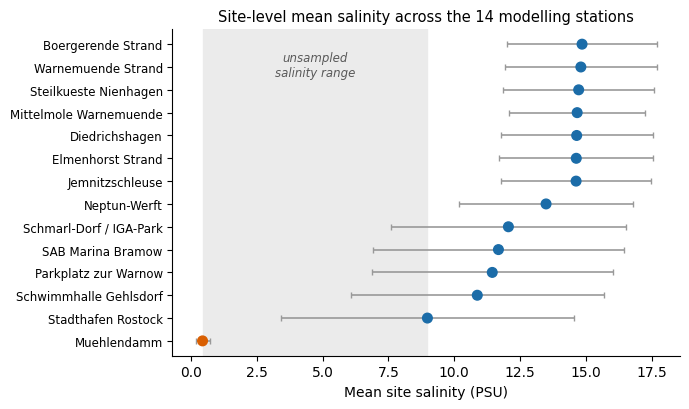

In [1]:
# ── FIG 4.x: per-site salinity — the Muehlendamm gap ─────────────────────
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR, OUT = "../data/", Path("../results")
meta = pd.read_csv(DATA_DIR + "combined_meta_data.csv", index_col=0)
meta = meta[meta['location_name'] != 'Heiligendamm']

stats = (meta.groupby('location_name')['salinity']
             .agg(['mean', 'std']).sort_values('mean'))

fig, ax = plt.subplots(figsize=(7.0, 4.2))
colors = ['#d95f02' if s < 2 else '#1b6ca8' for s in stats['mean']]
ax.errorbar(stats['mean'], range(len(stats)), xerr=stats['std'],
            fmt='none', ecolor='0.6', elinewidth=1.2, capsize=2.5, zorder=1)
ax.scatter(stats['mean'], range(len(stats)), c=colors, s=48, zorder=2)

ax.axvspan(0.45, 8.98, color='0.92', zorder=0)
ax.text((0.45+8.98)/2, len(stats)-1.3, 'unsampled\nsalinity range',
        ha='center', va='top', fontsize=8.5, color='0.35', style='italic')

ax.set_yticks(range(len(stats)))
ax.set_yticklabels(stats.index, fontsize=8.5)
ax.set_xlabel('Mean site salinity (PSU)', fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
ax.set_title('Site-level mean salinity across the 14 modelling stations',
             fontsize=10.5)
fig.tight_layout()
for ext in ('png', 'pdf'):
    fig.savefig(OUT / f'fig_data_salinity_per_site.{ext}',
                dpi=300, bbox_inches='tight')
print("saved ✓")

saved ✓


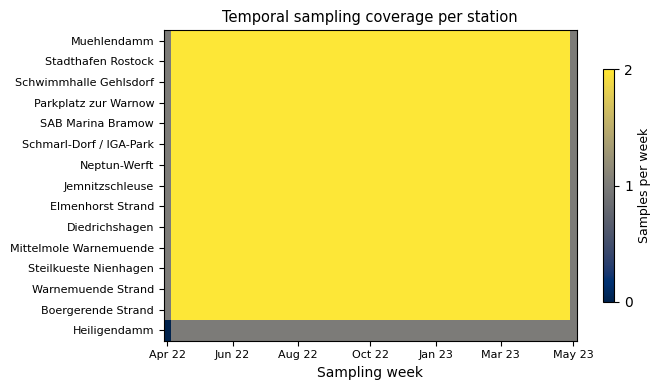

In [2]:
# ── FIG 4.x: temporal sampling coverage (all 15 sites) ───────────────────
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR, OUT = "../data/", Path("../results")
meta = pd.read_csv(DATA_DIR + "combined_meta_data.csv", index_col=0)
meta['date'] = pd.to_datetime(meta['date'])
meta['week'] = meta['date'].dt.to_period('W').dt.start_time

# order: Muehlendamm first (site 1) … Heiligendamm last
order = (meta.groupby('location_name')['salinity'].mean()
             .sort_values().index.tolist())
order = [s for s in order if s != 'Heiligendamm'] + ['Heiligendamm']

counts = (meta.groupby(['location_name', 'week']).size()
              .unstack(fill_value=0).reindex(order))

fig, ax = plt.subplots(figsize=(7.0, 4.0))
im = ax.imshow(counts.values, aspect='auto', cmap='cividis',
               vmin=0, vmax=2, interpolation='nearest')
ax.set_yticks(range(len(order)))
ax.set_yticklabels(order, fontsize=8)
xt = np.linspace(0, counts.shape[1]-1, 7).astype(int)
ax.set_xticks(xt)
ax.set_xticklabels([counts.columns[i].strftime('%b %y') for i in xt],
                   fontsize=8)
ax.set_xlabel('Sampling week', fontsize=10)
cbar = fig.colorbar(im, ax=ax, ticks=[0, 1, 2], shrink=0.75)
cbar.set_label('Samples per week', fontsize=9)
ax.set_title('Temporal sampling coverage per station', fontsize=10.5)
fig.tight_layout()
for ext in ('png', 'pdf'):
    fig.savefig(OUT / f'fig_data_sampling_coverage.{ext}',
                dpi=300, bbox_inches='tight')
print("saved ✓")

saved ✓


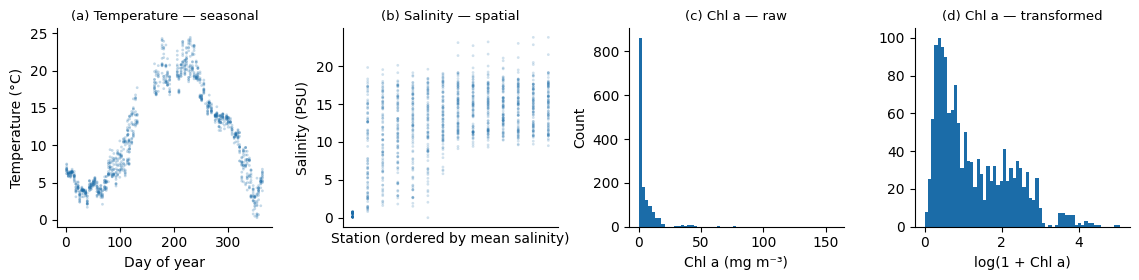

In [3]:
# ── FIG 4.x: target structure + log1p justification ──────────────────────
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR, OUT = "../data/", Path("../results")
meta = pd.read_csv(DATA_DIR + "combined_meta_data.csv", index_col=0)
meta = meta[meta['location_name'] != 'Heiligendamm']
meta['date'] = pd.to_datetime(meta['date'])
meta['doy']  = meta['date'].dt.dayofyear

fig, axes = plt.subplots(1, 4, figsize=(11.5, 2.9))

axes[0].scatter(meta['doy'], meta['temperature'], s=4, alpha=0.25,
                c='#1b6ca8', edgecolors='none')
axes[0].set(xlabel='Day of year', ylabel='Temperature (°C)',
            title='(a) Temperature — seasonal')

order = meta.groupby('location_name')['salinity'].mean().sort_values().index
pos = {s: i for i, s in enumerate(order)}
axes[1].scatter(meta['location_name'].map(pos), meta['salinity'],
                s=4, alpha=0.2, c='#1b6ca8', edgecolors='none')
axes[1].set(xlabel='Station (ordered by mean salinity)',
            ylabel='Salinity (PSU)', title='(b) Salinity — spatial')
axes[1].set_xticks([])

axes[2].hist(meta['Chl_a'].dropna(), bins=60, color='#1b6ca8')
axes[2].set(xlabel='Chl a (mg m⁻³)', ylabel='Count',
            title='(c) Chl a — raw')

axes[3].hist(np.log1p(meta['Chl_a'].clip(lower=0).dropna()),
             bins=60, color='#1b6ca8')
axes[3].set(xlabel='log(1 + Chl a)', title='(d) Chl a — transformed')

for ax in axes:
    ax.spines[['top', 'right']].set_visible(False)
    ax.title.set_fontsize(9.5)
fig.tight_layout()
for ext in ('png', 'pdf'):
    fig.savefig(OUT / f'fig_data_target_structure.{ext}',
                dpi=300, bbox_inches='tight')
print("saved ✓")

saved ✓


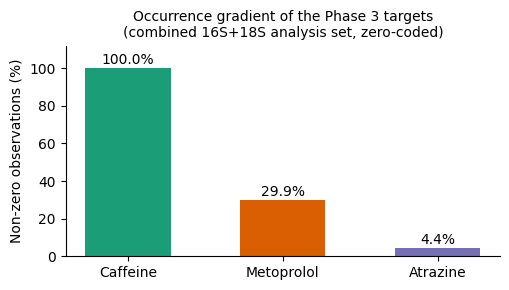

In [4]:
# ── FIG 4.x: Phase 3 occurrence gradient ─────────────────────────────────
import matplotlib.pyplot as plt
from pathlib import Path
OUT = Path("../results")

targets = ['Caffeine', 'Metoprolol', 'Atrazine']
nonzero = [100.0, 29.9, 4.4]   # combined 16S+18S set (Section 4.6)

fig, ax = plt.subplots(figsize=(5.2, 3.0))
bars = ax.bar(targets, nonzero, color=['#1b9e77', '#d95f02', '#7570b3'],
              width=0.55)
for b, v in zip(bars, nonzero):
    ax.text(b.get_x() + b.get_width()/2, v + 2, f'{v:.1f}%',
            ha='center', fontsize=10)
ax.set_ylabel('Non-zero observations (%)', fontsize=10)
ax.set_ylim(0, 112)
ax.spines[['top', 'right']].set_visible(False)
ax.set_title('Occurrence gradient of the Phase 3 targets\n'
             '(combined 16S+18S analysis set, zero-coded)', fontsize=10)
fig.tight_layout()
for ext in ('png', 'pdf'):
    fig.savefig(OUT / f'fig_data_phase3_gradient.{ext}',
                dpi=300, bbox_inches='tight')
print("saved ✓")

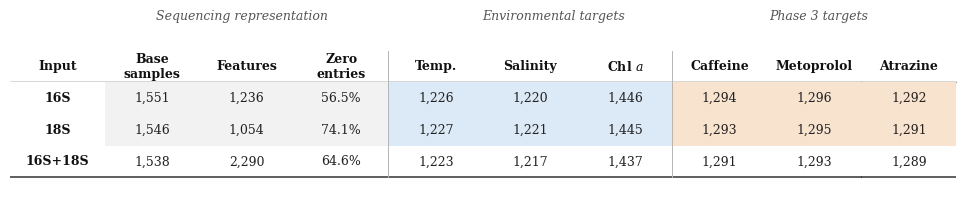

Saved:
  ../results/table_4_1_dataset_dimensions.png
  ../results/table_4_1_dataset_dimensions.pdf


In [ ]:
# ── TABLE 4.1: Final dataset dimensions ────────────────────────────────────

import matplotlib.pyplot as plt
from matplotlib import font_manager
from pathlib import Path


# Output directory

OUT = Path("../results")
OUT.mkdir(parents=True, exist_ok=True)


# Data — LOCKED final values

rows = [
    ["16S",     "1,551", "1,236", "56.5%", "1,226", "1,220", "1,446",
     "1,294", "1,296", "1,292"],

    ["18S",     "1,546", "1,054", "74.1%", "1,227", "1,221", "1,445",
     "1,293", "1,295", "1,291"],

    ["16S+18S", "1,538", "2,290", "64.6%", "1,223", "1,217", "1,437",
     "1,291", "1,293", "1,289"],
]

cols = [
    "Input",
    "Base\nsamples",
    "Features",
    "Zero\nentries",
    "Temp.",
    "Salinity",
    r"Chl $a$",
    "Caffeine",
    "Metoprolol",
    "Atrazine",
]


# Column groups
GROUPS = {
    "seq": (1, 3),
    "env": (4, 6),
    "ph3": (7, 9),
}

# Pale fills with different luminance.
BAND = {
    "seq": "#F2F2F2",   
    "env": "#DCEAF7",   
    "ph3": "#F8E3CF",   
}


available_fonts = {f.name for f in font_manager.fontManager.ttflist}

if "Times New Roman" in available_fonts:
    FONT_FAMILY = "Times New Roman"
else:
    FONT_FAMILY = "DejaVu Serif"

plt.rcParams.update({
    "font.family": FONT_FAMILY,
    "mathtext.fontset": "dejavuserif",
    "pdf.fonttype": 42,   # editable text in PDF where possible
    "ps.fonttype": 42,
})


# Figure

fig, ax = plt.subplots(figsize=(9.6, 2.05))
ax.axis("off")

table = ax.table(
    cellText=rows,
    colLabels=cols,
    cellLoc="center",
    colLoc="center",
    loc="center",
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.0, 1.72)

n_data_rows = len(rows)
last_row = n_data_rows                # because header is row 0
n_cols = len(cols)


# Cell styling

for (r, c), cell in table.get_celld().items():

    # Remove default box/grid
    cell.set_linewidth(0)
    cell.set_edgecolor("#333333")

    # HEADER ROW
    if r == 0:
        cell.set_facecolor("#FFFFFF")
        cell.set_text_props(
            weight="bold",
            color="#111111",
            fontsize=9,
        )
        cell.visible_edges = "B"
        cell.set_linewidth(1.0)

    # DATA ROWS
    else:
        # Group background bands
        if GROUPS["seq"][0] <= c <= GROUPS["seq"][1]:
            cell.set_facecolor(BAND["seq"])

        elif GROUPS["env"][0] <= c <= GROUPS["env"][1]:
            cell.set_facecolor(BAND["env"])

        elif GROUPS["ph3"][0] <= c <= GROUPS["ph3"][1]:
            cell.set_facecolor(BAND["ph3"])

        else:
            cell.set_facecolor("#FFFFFF")

        # Bold row labels
        if c == 0:
            cell.set_text_props(
                weight="bold",
                color="#111111",
            )
        else:
            cell.set_text_props(
                color="#222222",
            )

    # Bottom rule under final data row
    if r == last_row:
        cell.visible_edges = "B"
        cell.set_linewidth(1.1)


fig.canvas.draw()

# Right edge of column 3 (Zero entries)
cell_c3 = table[(1, 3)]
x_sep_1 = cell_c3.get_x() + cell_c3.get_width()

# Right edge of column 6 (Chl a)
cell_c6 = table[(1, 6)]
x_sep_2 = cell_c6.get_x() + cell_c6.get_width()

# Table vertical extent
header_cell = table[(0, 0)]
bottom_cell = table[(last_row, 0)]

y_top = header_cell.get_y() + header_cell.get_height()
y_bottom = bottom_cell.get_y()

for x in (x_sep_1, x_sep_2):
    ax.plot(
        [x, x],
        [y_bottom, y_top],
        transform=ax.transAxes,
        color="#B5B5B5",
        linewidth=0.7,
        zorder=10,
    )


# Group labels above table

group_labels = [
    ("Sequencing representation", 0.245),
    ("Environmental targets",     0.575),
    ("Phase 3 targets",           0.855),
]

for label, x in group_labels:
    ax.text(
        x,
        1.025,
        label,
        transform=ax.transAxes,
        ha="center",
        va="bottom",
        fontsize=9,
        fontstyle="italic",
        color="#555555",
    )


# Layout and export


# Layout and export

fig.tight_layout(pad=0.5)

png_path = OUT / "table_4_1_dataset_dimensions.png"
pdf_path = OUT / "table_4_1_dataset_dimensions.pdf"

fig.savefig(
    png_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

fig.savefig(
    pdf_path,
    bbox_inches="tight",
    facecolor="white",
)


plt.show()

plt.close(fig)

print("Saved:")
print(f"  {png_path}")
print(f"  {pdf_path}")

In [6]:
import pandas as pd
meta = pd.read_csv("../data/combined_meta_data.csv", index_col=0)
print(meta[['location_name', 'rough_lat_long']].drop_duplicates().to_string())

                    location_name                            rough_lat_long
s01X0123             Heiligendamm   [54.146365304126505, 11.84315003147121]
s02M0123          Jemnitzschleuse  [54.147885248440694, 11.868971110779253]
s03M0123       Boergerende Strand  [54.151487171879495, 11.886362440876928]
s04M0123    Steilkueste Nienhagen    [54.16666302011663, 11.96379623399444]
s05M0123        Elmenhorst Strand   [54.17548962669349, 11.997652914250816]
s06M0123           Diedrichshagen   [54.17711573457156, 12.027456126500924]
s07M0123       Warnemuende Strand    [54.18248279516584, 12.07630235764034]
s08M0123              Muehlendamm    [54.0841494398656, 12.151006424457755]
s09M0123       Stadthafen Rostock   [54.09524210575433, 12.119615984047451]
s10M0123        SAB Marina Bramow    [54.11056226317913, 12.09354886530469]
s11M0123   Schwimmhalle Gehlsdorf   [54.11136613529305, 12.101239525632657]
s12M0123     Parkplatz zur Warnow   [54.13159491098976, 12.097383290174285]
s13M0123  Sc

saved ✓


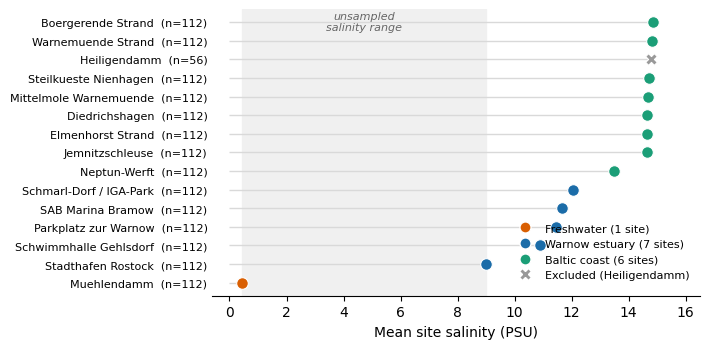

In [7]:
# ── FIG 4.1: schematic transect of the study design ──────────────────────
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path

DATA_DIR, OUT = "../data/", Path("../results")
meta = pd.read_csv(DATA_DIR + "combined_meta_data.csv", index_col=0)

stats = (meta.groupby('location_name')
              .agg(sal=('salinity', 'mean'), n=('salinity', 'size'))
              .sort_values('sal'))

def regime(name, sal):
    if name == 'Heiligendamm':      return 'excluded'
    if sal < 2:                     return 'freshwater'
    if sal < 13:                    return 'estuary'
    return 'coastal'

stats['regime'] = [regime(i, s) for i, s in zip(stats.index, stats['sal'])]
COL = {'freshwater': '#d95f02', 'estuary': '#1b6ca8',
       'coastal': '#1b9e77', 'excluded': '#999999'}

fig, ax = plt.subplots(figsize=(7.2, 3.6))
y = np.arange(len(stats))

ax.axvspan(0.45, 8.98, color='0.94', zorder=0)
ax.hlines(y, 0, stats['sal'], color='0.85', lw=1.0, zorder=1)
for reg in COL:
    m = stats['regime'] == reg
    ax.scatter(stats.loc[m, 'sal'], y[m], s=70, c=COL[reg],
               marker='X' if reg == 'excluded' else 'o',
               edgecolors='white', linewidths=0.8, zorder=3)

ax.text((0.45 + 8.98) / 2, len(stats) - 0.4, 'unsampled\nsalinity range',
        ha='center', va='top', fontsize=8, color='0.4', style='italic')

ax.set_yticks(y)
ax.set_yticklabels([f'{i}  (n={int(n)})' for i, n in
                    zip(stats.index, stats['n'])], fontsize=8)
ax.set_xlabel('Mean site salinity (PSU)', fontsize=10)
ax.set_xlim(-0.6, 16.5)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.tick_params(axis='y', length=0)

handles = [Line2D([], [], marker='o', ls='', mfc=COL[k], mec='white',
                  ms=8, label=v) for k, v in
           [('freshwater', 'Freshwater (1 site)'),
            ('estuary', 'Warnow estuary (7 sites)'),
            ('coastal', 'Baltic coast (6 sites)')]]
handles.append(Line2D([], [], marker='X', ls='', mfc=COL['excluded'],
                      mec='white', ms=9, label='Excluded (Heiligendamm)'))
ax.legend(handles=handles, fontsize=8, frameon=False,
          loc='lower right', bbox_to_anchor=(1.0, 0.02))

fig.tight_layout()
for ext in ('png', 'pdf'):
    fig.savefig(OUT / f'fig_4_1_transect.{ext}', dpi=300, bbox_inches='tight')
print("saved ✓")

saved ✓


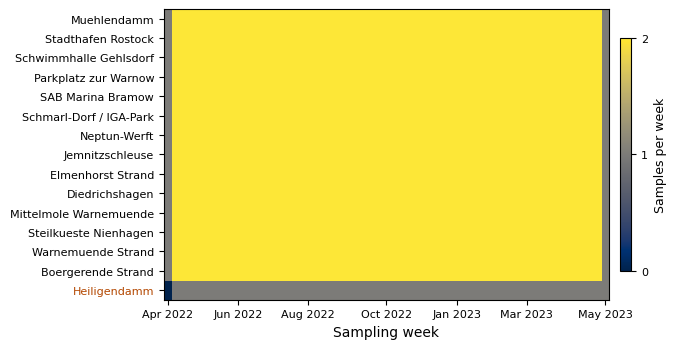

In [8]:
# ── FIG 4.2: temporal sampling coverage ──────────────────────────────────
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR, OUT = "../data/", Path("../results")
meta = pd.read_csv(DATA_DIR + "combined_meta_data.csv", index_col=0)
meta['date'] = pd.to_datetime(meta['date'])
meta['week'] = meta['date'].dt.to_period('W').dt.start_time

order = meta.groupby('location_name')['salinity'].mean().sort_values().index
order = [s for s in order if s != 'Heiligendamm'] + ['Heiligendamm']
counts = (meta.groupby(['location_name', 'week']).size()
              .unstack(fill_value=0).reindex(order))

fig, ax = plt.subplots(figsize=(7.2, 3.6))
im = ax.imshow(counts.values, aspect='auto', cmap='cividis',
               vmin=0, vmax=2, interpolation='nearest')
ax.set_yticks(range(len(order)))
ax.set_yticklabels(order, fontsize=8)
ax.get_yticklabels()[-1].set_color('#b34700')      # highlight Heiligendamm

xt = np.linspace(0, counts.shape[1] - 1, 7).astype(int)
ax.set_xticks(xt)
ax.set_xticklabels([counts.columns[i].strftime('%b %Y') for i in xt],
                   fontsize=8, rotation=0)
ax.set_xlabel('Sampling week', fontsize=10)
cb = fig.colorbar(im, ax=ax, ticks=[0, 1, 2], shrink=0.8, pad=0.02)
cb.set_label('Samples per week', fontsize=9)
cb.ax.tick_params(labelsize=8)

fig.tight_layout()
for ext in ('png', 'pdf'):
    fig.savefig(OUT / f'fig_4_2_coverage.{ext}', dpi=300, bbox_inches='tight')
print("saved ✓")

saved ✓


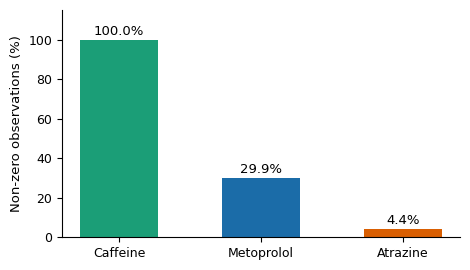

In [9]:
# ── FIG 4.3: Phase 3 occurrence gradient ─────────────────────────────────
import matplotlib.pyplot as plt
from pathlib import Path
OUT = Path("../results")

t = ['Caffeine', 'Metoprolol', 'Atrazine']
v = [100.0, 29.9, 4.4]

fig, ax = plt.subplots(figsize=(4.8, 2.8))
bars = ax.bar(t, v, color=['#1b9e77', '#1b6ca8', '#d95f02'], width=0.55)
for b, val in zip(bars, v):
    ax.text(b.get_x() + b.get_width()/2, val + 2.5, f'{val:.1f}%',
            ha='center', fontsize=9.5)
ax.set_ylabel('Non-zero observations (%)', fontsize=9.5)
ax.set_ylim(0, 115)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(labelsize=9)

fig.tight_layout()
for ext in ('png', 'pdf'):
    fig.savefig(OUT / f'fig_4_3_phase3_gradient.{ext}',
                dpi=300, bbox_inches='tight')
print("saved ✓")

                           sal    n      regime
location_name                                  
Muehlendamm               0.45  112  freshwater
Stadthafen Rostock        9.05  111     estuary
Schwimmhalle Gehlsdorf   10.86  111     estuary
Parkplatz zur Warnow     11.44  111     estuary
SAB Marina Bramow        11.68  111     estuary
Schmarl-Dorf / IGA-Park  12.15  110     estuary
Neptun-Werft             13.49  111     coastal
Jemnitzschleuse          14.61  109     coastal
Elmenhorst Strand        14.64  111     coastal
Diedrichshagen           14.66  111     coastal
Mittelmole Warnemuende   14.67  112     coastal
Steilkueste Nienhagen    14.70  110     coastal
Heiligendamm             14.79   51    excluded
Warnemuende Strand       14.85  111     coastal
Boergerende Strand       14.85  110     coastal


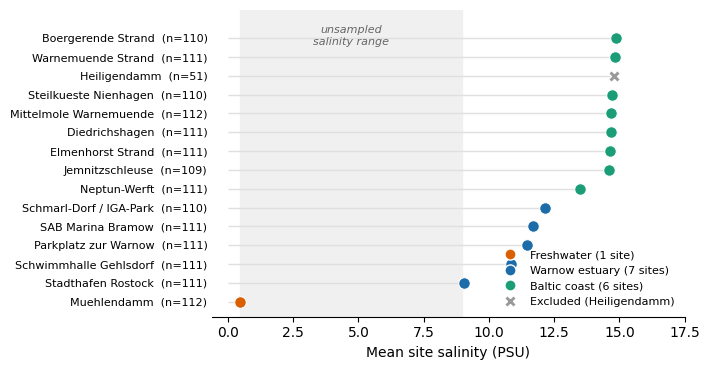

In [10]:
# ── FIG 4.1: schematic transect (corrected sample counts) ────────────────
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path

DATA_DIR, OUT = "../data/", Path("../results")
meta    = pd.read_csv(DATA_DIR + "combined_meta_data.csv", index_col=0)
otu_16s = pd.read_csv(DATA_DIR + "otus_16s_filtered.csv", index_col=0)

# count only samples that actually enter the 16S modelling matrix
ids = meta.index.intersection(otu_16s.index)
m   = meta.loc[ids]

stats = (m.groupby('location_name')
          .agg(sal=('salinity', 'mean'), n=('salinity', 'size'))
          .sort_values('sal'))

REG = {}
for name, sal in zip(stats.index, stats['sal']):
    if name == 'Heiligendamm': REG[name] = 'excluded'
    elif sal < 2:              REG[name] = 'freshwater'
    elif sal < 13:             REG[name] = 'estuary'
    else:                      REG[name] = 'coastal'
stats['regime'] = [REG[i] for i in stats.index]

COL = {'freshwater': '#d95f02', 'estuary': '#1b6ca8',
       'coastal': '#1b9e77', 'excluded': '#999999'}

fig, ax = plt.subplots(figsize=(7.2, 3.8))
y = np.arange(len(stats))

ax.axvspan(0.45, 8.98, color='0.94', zorder=0)
ax.hlines(y, 0, stats['sal'], color='0.88', lw=1.0, zorder=1)

for reg, col in COL.items():
    sel = (stats['regime'] == reg).values
    ax.scatter(stats['sal'].values[sel], y[sel], s=70, c=col,
               marker='X' if reg == 'excluded' else 'o',
               edgecolors='white', linewidths=0.8, zorder=3)

ax.text((0.45 + 8.98) / 2, len(stats) - 0.3, 'unsampled\nsalinity range',
        ha='center', va='top', fontsize=8, color='0.4', style='italic')

ax.set_yticks(y)
ax.set_yticklabels([f'{i}  (n={int(n)})' for i, n in
                    zip(stats.index, stats['n'])], fontsize=8)
ax.set_xlabel('Mean site salinity (PSU)', fontsize=10)
ax.set_xlim(-0.6, 17.5)
ax.set_ylim(-0.8, len(stats) + 0.5)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.tick_params(axis='y', length=0)

handles = [Line2D([], [], marker='o', ls='', mfc=COL[k], mec='white', ms=8,
                  label=v) for k, v in
           [('freshwater', 'Freshwater (1 site)'),
            ('estuary', 'Warnow estuary (7 sites)'),
            ('coastal', 'Baltic coast (6 sites)')]]
handles.append(Line2D([], [], marker='X', ls='', mfc=COL['excluded'],
                       mec='white', ms=9, label='Excluded (Heiligendamm)'))
ax.legend(handles=handles, fontsize=8, frameon=False, loc='lower right')

fig.tight_layout()
for ext in ('png', 'pdf'):
    fig.savefig(OUT / f'fig_4_1_transect.{ext}', dpi=300, bbox_inches='tight')
print(stats.round(2).to_string())

saved ✓


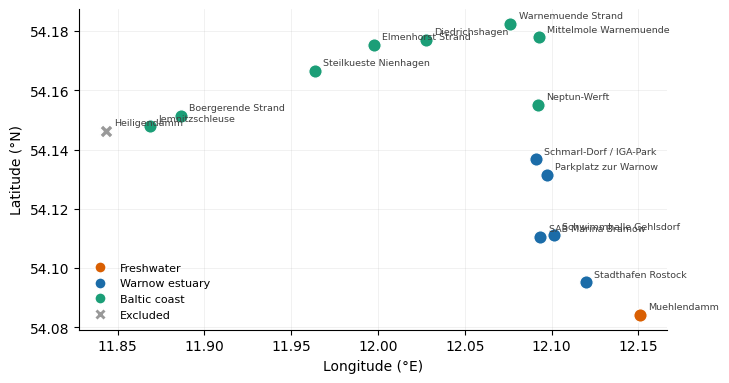

In [11]:
# ── FIG 4.1b: station map from coordinates ───────────────────────────────
import pandas as pd, numpy as np, matplotlib.pyplot as plt, ast
from matplotlib.lines import Line2D
from pathlib import Path

DATA_DIR, OUT = "../data/", Path("../results")
meta = pd.read_csv(DATA_DIR + "combined_meta_data.csv", index_col=0)

coords = (meta[['location_name', 'rough_lat_long']]
          .drop_duplicates('location_name').set_index('location_name'))
coords['lat'] = coords['rough_lat_long'].apply(lambda s: ast.literal_eval(s)[0])
coords['lon'] = coords['rough_lat_long'].apply(lambda s: ast.literal_eval(s)[1])
sal = meta.groupby('location_name')['salinity'].mean()
coords['sal'] = sal

def reg(n, s):
    if n == 'Heiligendamm': return 'excluded'
    if s < 2:  return 'freshwater'
    if s < 13: return 'estuary'
    return 'coastal'
coords['regime'] = [reg(i, s) for i, s in zip(coords.index, coords['sal'])]

COL = {'freshwater': '#d95f02', 'estuary': '#1b6ca8',
       'coastal': '#1b9e77', 'excluded': '#999999'}

fig, ax = plt.subplots(figsize=(7.4, 4.4))
for r, c in COL.items():
    sel = coords['regime'] == r
    ax.scatter(coords.loc[sel, 'lon'], coords.loc[sel, 'lat'],
               s=95, c=c, marker='X' if r == 'excluded' else 'o',
               edgecolors='white', linewidths=1.0, zorder=3)

for name, row in coords.iterrows():
    ax.annotate(name, (row['lon'], row['lat']),
                textcoords='offset points', xytext=(6, 4),
                fontsize=6.8, color='0.25')

ax.set_xlabel('Longitude (°E)', fontsize=10)
ax.set_ylabel('Latitude (°N)', fontsize=10)
ax.grid(alpha=0.25, lw=0.5)
ax.set_aspect(1 / np.cos(np.deg2rad(54.13)))   # correct aspect at this latitude
ax.spines[['top', 'right']].set_visible(False)

handles = [Line2D([], [], marker='o', ls='', mfc=COL[k], mec='white', ms=8,
                  label=v) for k, v in
           [('freshwater', 'Freshwater'), ('estuary', 'Warnow estuary'),
            ('coastal', 'Baltic coast')]]
handles.append(Line2D([], [], marker='X', ls='', mfc=COL['excluded'],
                       mec='white', ms=9, label='Excluded'))
ax.legend(handles=handles, fontsize=8, frameon=False, loc='lower left')

fig.tight_layout()
for ext in ('png', 'pdf'):
    fig.savefig(OUT / f'fig_4_1b_map.{ext}', dpi=300, bbox_inches='tight')
print("saved ✓")

In [2]:
# === CHAPTER 5 VERIFICATION, part 2 — locate files first, then run checks 2–5 ===
import sys, re
import pandas as pd
import numpy as np
from pathlib import Path

ROOT = Path('/mnt/data/home/tv2414/tabpfn_project')
sys.path.insert(0, str(ROOT))

def find_one(pattern):
    hits = sorted(ROOT.rglob(pattern))
    hits = [h for h in hits if '.ipynb_checkpoints' not in str(h)]
    print(f'  {pattern:28s} -> {[str(h.relative_to(ROOT)) for h in hits] or "NOT FOUND"}')
    return hits[0] if hits else None

print('=' * 70); print('LOCATING FILES'); print('=' * 70)
META = find_one('combined_meta_data.csv')
O16  = find_one('otus_16s_filtered.csv')
O18  = find_one('otus_18s_filtered.csv')

# ---------------------------------------------------------------- CHECK 2
print('\n' + '=' * 70)
print('CHECK 2 — temporal_holdout boundary date (row-based, Phases 1/2)')
print('=' * 70)
import inspect
from src import cv_strategies
print('--- temporal_holdout source, so we replicate it exactly ---')
print(inspect.getsource(cv_strategies.temporal_holdout))

meta = pd.read_csv(META)
date_cols = [c for c in meta.columns if 'date' in c.lower()]
print(f'date-like columns: {date_cols}')
dc = date_cols[0]
meta[dc] = pd.to_datetime(meta[dc], errors='coerce')
order = meta[dc].dropna().sort_values().reset_index(drop=True)
n = len(order)
split_row = int(np.floor(n * 0.8))
print(f'rows with date        : {n}')
print(f'last train row date   : {order.iloc[split_row-1].date()}')
print(f'first test row date   : {order.iloc[split_row].date()}')
print(f'boundary date shared  : {order.iloc[split_row-1].date() == order.iloc[split_row].date()}')
print('NOTE: this uses raw metadata rows incl. Heiligendamm; if the split module')
print('      is applied to the merged master (14 sites), the date may differ by a')
print('      few days — compare with the source printed above and re-run on the')
print('      merged master if needed.')

# ---------------------------------------------------------------- CHECK 3
print('\n' + '=' * 70)
print('CHECK 3 — sample counts per input configuration')
print('=' * 70)
t16 = pd.read_csv(O16, index_col=0); t18 = pd.read_csv(O18, index_col=0)
print(f'16S file shape: {t16.shape}   18S file shape: {t18.shape}')
print('(orientation: check which axis is samples; expected 1,551 / 1,546 / 1,538')
print(' after Heiligendamm exclusion — see Chapter 4 Table 4.1)')

# ---------------------------------------------------------------- CHECK 4
print('\n' + '=' * 70)
print('CHECK 4 — Phase 2 leakage-audit artefacts in results/')
print('=' * 70)
hits = [p for p in (ROOT / 'results').glob('*')
        if re.search(r'leak|audit|shuffle', p.name, re.I)]
if hits:
    for h in hits:
        print(f'\n--- {h.name} ---')
        try:    print(pd.read_csv(h).head(20).to_string(index=False))
        except Exception: print(h.read_text(errors="ignore")[:800])
else:
    print('no leak/audit/shuffle files in results/ -> take the numbers')
    print('(978 fit-context rows; real vs shuffled R²) from the audit notebook output.')

# ---------------------------------------------------------------- CHECK 5
print('\n' + '=' * 70)
print('CHECK 5 — Hellinger / NMDS / UMAP usage across notebooks')
print('=' * 70)
for nb in sorted((ROOT / 'notebooks').glob('*.ipynb')):
    txt = nb.read_text(errors='ignore')
    found = sorted({kw for kw in ['hellinger', 'nmds', 'umap'] if kw in txt.lower()})
    if found:
        print(f'  {nb.name}: {found}')
print('-> keep Section 5.4 as 2x2 PCA/t-SNE unless these appear in final Ch.7 figures.')

LOCATING FILES
  combined_meta_data.csv       -> ['data/combined_meta_data.csv']
  otus_16s_filtered.csv        -> ['data/otus_16s_filtered.csv']
  otus_18s_filtered.csv        -> ['data/otus_18s_filtered.csv']

CHECK 2 — temporal_holdout boundary date (row-based, Phases 1/2)
--- temporal_holdout source, so we replicate it exactly ---
def temporal_holdout(meta, test_fraction=0.2, date_col='date'):
    """
    Single temporal split — the most chronologically recent `test_fraction`
    of samples becomes the test set; the older samples are training.

    This answers the question: "Does the model generalise to future time?"
    It is the most realistic split given the 13-month dataset.

    Parameters
    ----------
    meta : pandas.DataFrame
        Pre-filtered metadata (only rows with non-missing target).
    test_fraction : float, default 0.2
        Fraction of samples (sorted by date) used as test.
    date_col : str, default 'date'

    Returns
    -------
    list with a single 

In [6]:
# === STRUCTURE DUMP — no guessing, no exceptions ===
import pandas as pd
from pathlib import Path
ROOT = Path('/mnt/data/home/tv2414/tabpfn_project')

meta = pd.read_csv(ROOT / 'data' / 'combined_meta_data.csv')
o16  = pd.read_csv(ROOT / 'data' / 'otus_16s_filtered.csv', index_col=0)

print('META shape:', meta.shape)
print('\n--- every column: name | dtype | n_unique | 3 example values ---')
for c in meta.columns:
    ex = meta[c].dropna().unique()[:3]
    print(f'{c:28s} | {str(meta[c].dtype):8s} | {meta[c].nunique():5d} | {list(ex)}')

print('\n--- OTU table ---')
print('shape:', o16.shape)
print('index[:3]:', list(o16.index[:3]))
print('columns[:3]:', list(o16.columns[:3]))

META shape: (1624, 22)

--- every column: name | dtype | n_unique | 3 example values ---
Unnamed: 0                   | str      |  1624 | ['s01X0123', 's01X0223', 's01X0323']
location_id                  | int64    |    15 | [np.int64(1), np.int64(2), np.int64(3)]
day_id                       | str      |     3 | ['X', 'M', 'T']
cw_id                        | int64    |    52 | [np.int64(1), np.int64(2), np.int64(3)]
year_id                      | int64    |     2 | [np.int64(23), np.int64(22)]
location_name                | str      |    15 | ['Heiligendamm', 'Jemnitzschleuse', 'Boergerende Strand']
rough_lat_long               | str      |    15 | ['[54.146365304126505, 11.84315003147121]', '[54.147885248440694, 11.868971110779253]', '[54.151487171879495, 11.886362440876928]']
date                         | str      |   168 | ['2023-01-03', '2023-01-10', '2023-01-17']
PO4                          | float64  |   210 | [np.float64(0.03), np.float64(0.74), np.float64(0.52)]
NOx        

In [7]:
# === FINAL VERIFICATION — real column names, no guessing ===
import sys, pandas as pd, numpy as np
from pathlib import Path
ROOT = Path('/mnt/data/home/tv2414/tabpfn_project'); sys.path.insert(0, str(ROOT))
from src.cv_strategies import temporal_holdout

meta = pd.read_csv(ROOT / 'data' / 'combined_meta_data.csv').rename(columns={'Unnamed: 0': 'sample_id'})
o16  = pd.read_csv(ROOT / 'data' / 'otus_16s_filtered.csv', index_col=0)
o18  = pd.read_csv(ROOT / 'data' / 'otus_18s_filtered.csv', index_col=0)

# ---------- sample counts per configuration ----------
print('=' * 66); print('SAMPLE COUNTS'); print('=' * 66)
ids16, ids18 = set(o16.index), set(o18.index)
hd = set(meta.loc[meta.location_name.str.contains('Heiligendamm', case=False), 'sample_id'])
print(f'raw 16S file rows            : {len(ids16)}')
print(f'raw 18S file rows            : {len(ids18)}')
print(f'16S minus Heiligendamm       : {len(ids16 - hd)}   (expect 1,551)')
print(f'18S minus Heiligendamm       : {len(ids18 - hd)}   (expect 1,546)')
print(f'combined (16S ∩ 18S) minus HD: {len(ids16 & ids18 - hd)}   (expect 1,538)')
print(f'Heiligendamm rows in 16S     : {len(ids16 & hd)}   (expect 51)')
print(f'active stations              : {meta.loc[~meta.location_name.str.contains("Heiligendamm", case=False), "location_name"].nunique()}')

# ---------- which Chl column, and the negative value ----------
print('\n' + '=' * 66); print('CHLOROPHYLL COLUMN'); print('=' * 66)
for c in ['Chl_a', 'Chl_a_conc']:
    s = meta[c]
    print(f'{c:12s} min={s.min():.4f}  max={s.max():.2f}  n_negative={(s < 0).sum()}  n_nan={s.isna().sum()}')
print('-> the column with exactly one negative value (~ -0.149) is the one log1p was applied to')

# ---------- temporal_holdout boundary, per target, on the real modelling master ----------
print('\n' + '=' * 66); print('TEMPORAL_HOLDOUT BOUNDARY (Phases 1/2)'); print('=' * 66)
master = meta[meta.sample_id.isin(ids16 - hd)].copy()
print(f'16S modelling master rows: {len(master)}')
for name in ['temperature', 'salinity', 'Chl_a']:
    sub = master[master[name].notna()].reset_index(drop=True)
    (tr, te), = temporal_holdout(sub, test_fraction=0.2, date_col='date')
    d = pd.to_datetime(sub['date'])
    lt, ft = d.iloc[tr].max().date(), d.iloc[te].min().date()
    n_shared = (d.dt.date == ft).sum() if lt == ft else 0
    print(f'{name:12s} n={len(sub):4d} | last train {lt} | first test {ft} | '
          f'boundary date split: {lt == ft} ({n_shared} samples on that date)')

# ---------- ordination methods actually used ----------
print('\n' + '=' * 66); print('HELLINGER / NMDS / UMAP IN NOTEBOOKS'); print('=' * 66)
for nb in sorted((ROOT / 'notebooks').glob('*.ipynb')):
    txt = nb.read_text(errors='ignore').lower()
    found = sorted({k for k in ['hellinger', 'nmds', 'umap'] if k in txt})
    if found: print(f'  {nb.name}: {found}')

# ---------- hyperparameter grids as implemented ----------
print('\n' + '=' * 66); print('HYPERPARAMETER GRIDS IN src/'); print('=' * 66)
import re
for f in ['lasso_evaluator.py', 'random_forest_evaluator.py', 'xgboost_evaluator.py']:
    p = ROOT / 'src' / f
    if not p.exists(): print(f'  !! {f} not found'); continue
    txt = p.read_text(); print(f'\n--- {f} ---')
    for m in re.finditer(r'((?:PARAM_GRID|param_grid|GRID)\s*=\s*\{[^}]*\})', txt): print(m.group(1))
    for m in re.finditer(r'(LassoCV|RidgeCV|XGBRegressor|RandomForestRegressor)\([^)]*\)', txt): print(m.group(0))

SAMPLE COUNTS
raw 16S file rows            : 1602
raw 18S file rows            : 1599
16S minus Heiligendamm       : 1551   (expect 1,551)
18S minus Heiligendamm       : 1546   (expect 1,546)
combined (16S ∩ 18S) minus HD: 1538   (expect 1,538)
Heiligendamm rows in 16S     : 51   (expect 51)
active stations              : 14

CHLOROPHYLL COLUMN
Chl_a        min=-0.1490  max=156.96  n_negative=1  n_nan=163
Chl_a_conc   min=0.0390  max=158.28  n_negative=0  n_nan=163
-> the column with exactly one negative value (~ -0.149) is the one log1p was applied to

TEMPORAL_HOLDOUT BOUNDARY (Phases 1/2)
16S modelling master rows: 1551
temperature  n=1226 | last train 2023-02-23 | first test 2023-02-23 | boundary date split: True (14 samples on that date)
salinity     n=1220 | last train 2023-02-23 | first test 2023-02-23 | boundary date split: True (14 samples on that date)
Chl_a        n=1446 | last train 2023-02-27 | first test 2023-02-27 | boundary date split: True (14 samples on that date)

HE

In [8]:
# === which ordination figures actually exist as final outputs? ===
from pathlib import Path
import re
ROOT = Path('/mnt/data/home/tv2414/tabpfn_project')
pats = ['pca', 'tsne', 't_sne', 'umap', 'nmds', 'ordination', 'embed']
for d in ['results', 'figures', 'outputs']:
    p = ROOT / d
    if not p.exists(): continue
    print(f'--- {d}/ ---')
    for f in sorted(p.rglob('*')):
        if f.suffix.lower() in ('.png', '.pdf') and any(k in f.name.lower() for k in pats):
            print(' ', f.relative_to(ROOT))


--- results/ ---
  results/phase2_nmds_16s.png
  results/phase2_ordination_emb_vs_raw_temperature_16S.png
  results/phase2_ordination_salinity_16S.png
  results/phase2_ordination_temperature_16S.png
  results/phase2_taxonomy_tsne_temperature_16S.png
  results/phase2_taxonomy_tsne_temperature_18S.png


In [9]:
# === was Hellinger applied before PCA of the raw data? ===
import json, re
from pathlib import Path
ROOT = Path('/mnt/data/home/tv2414/tabpfn_project')
for name in ['13_phase2_clean.ipynb', '11_phase2_embeddings.ipynb']:
    p = ROOT / 'notebooks' / name
    if not p.exists(): continue
    nb = json.loads(p.read_text(errors='ignore'))
    print(f'\n========== {name} ==========')
    for i, c in enumerate(nb['cells']):
        src = ''.join(c.get('source', []))
        if 'hellinger' in src.lower():
            print(f'--- cell {i} ---')
            for line in src.splitlines():
                if re.search(r'hellinger|sqrt|PCA|pca', line): print('   ', line.strip())


========== 13_phase2_clean.ipynb ==========
--- cell 19 ---
    # Raw counts get a Hellinger transform first (sqrt of relative abundance),
    def hellinger(counts):
    return np.sqrt(counts / tot)
    raw     = hellinger(INPUT_TABLES[EMB_INP].loc[ix].to_numpy(dtype=np.float32))
    C_pca, evr = ordinate(X_in, 'pca')
    panel(axes[0, col], C_pca, colour, f'PCA — {src}',
    print(f'{src:22s}  PCA var: PC1 {100*evr[0]:.1f}%  PC2 {100*evr[1]:.1f}%  '

========== 11_phase2_embeddings.ipynb ==========
--- cell 8 ---
    from sklearn.decomposition import PCA
    def hellinger(counts):
    """Hellinger transform: sqrt of row-normalised counts.
    Standard pre-PCA transform in microbial ecology — keeps raw-data ordination
    return np.sqrt(arr / rs)
    red = TSNE(n_components=2, perplexity=30, init='pca', random_state=seed)
    elif method == 'pca':
    red = PCA(n_components=2, random_state=seed)
--- cell 9 ---
    raw = hellinger(otu_16s.loc[ix].to_numpy())
    coords_raw = embed_2d(r

In [10]:
# === CHAPTER 5 — EMPIRICAL CHECKS: LOSO aggregation, autocorrelation code, blocked boundaries ===
import sys, re, json, inspect
import pandas as pd, numpy as np
from pathlib import Path
ROOT = Path('/mnt/data/home/tv2414/tabpfn_project'); sys.path.insert(0, str(ROOT))
R = ROOT / 'results'

# ---------------------------------------------------------------- 1A. what do the evaluators store?
print('=' * 72); print('1A. AGGREGATION AS IMPLEMENTED IN src/ EVALUATORS'); print('=' * 72)
for f in sorted((ROOT / 'src').glob('*evaluator*.py')):
    txt = f.read_text()
    hits = [l.strip() for l in txt.splitlines()
            if re.search(r'\b(mean|median|nanmean|nanmedian)\b', l) and re.search(r'r2|R2|score|metric', l, re.I)]
    print(f'\n--- {f.name} ---')
    for h in hits[:12]: print('   ', h)

# ---------------------------------------------------------------- 1B. what do the stored Phase 1 CSVs contain?
print('\n' + '=' * 72); print('1B. PHASE 1 RESULT FILES — columns and LOSO salinity rows'); print('=' * 72)
for f in sorted(R.glob('phase1_*.csv')):
    df = pd.read_csv(f)
    agg_cols = [c for c in df.columns if re.search(r'mean|median|pooled|r2', c, re.I)]
    print(f'\n--- {f.name}  shape={df.shape}')
    print('    columns:', list(df.columns))
    strat_col = next((c for c in df.columns if 'strateg' in c.lower()), None)
    tgt_col   = next((c for c in df.columns if 'target'  in c.lower()), None)
    if strat_col and tgt_col:
        m = df[df[strat_col].astype(str).str.contains('site', case=False) &
               df[tgt_col].astype(str).str.contains('sal', case=False)]
        if len(m): print(m[[c for c in df.columns if c in agg_cols + [strat_col, tgt_col] or 'input' in c.lower() or 'model' in c.lower()]].round(3).to_string(index=False))

# ---------------------------------------------------------------- 1C. recompute from fold-level data if it exists
print('\n' + '=' * 72); print('1C. FOLD-LEVEL LOSO SALINITY: mean vs median vs 13-brackish'); print('=' * 72)
fold_files = [f for f in R.glob('*.csv') if re.search(r'fold|per_site|persite|loso', f.name, re.I)]
print('candidate fold-level files:', [f.name for f in fold_files] or 'NONE')
for f in fold_files:
    df = pd.read_csv(f)
    site_c = next((c for c in df.columns if re.search(r'site|station|location|fold', c, re.I)), None)
    r2_c   = next((c for c in df.columns if re.fullmatch(r'r2|R2|r2_score', c)), None)
    tgt_c  = next((c for c in df.columns if 'target' in c.lower()), None)
    if not (site_c and r2_c): continue
    sub = df[df[tgt_c].astype(str).str.contains('sal', case=False)] if tgt_c else df
    if not len(sub): continue
    print(f'\n--- {f.name} ---')
    grp = [c for c in ['model', 'input'] if c in sub.columns]
    for key, g in (sub.groupby(grp) if grp else [(('all',), sub)]):
        r2 = g[r2_c].to_numpy(float)
        is_mu = g[site_c].astype(str).str.contains('uehlendamm|ühlendamm|Muehl', case=False, regex=True)
        print(f'  {key}: n_folds={len(r2)}  mean={np.mean(r2):+.3f}  median={np.median(r2):+.3f}  '
              f'mean_13brackish={np.mean(r2[~is_mu]):+.3f}  median_13brackish={np.median(r2[~is_mu]):+.3f}  '
              f'Muehlendamm={r2[is_mu][0] if is_mu.any() else "n/a"}')

# ---------------------------------------------------------------- 2. autocorrelation code
print('\n' + '=' * 72); print('2. AUTOCORRELATION — how lag-1 rho is actually aggregated'); print('=' * 72)
nb = ROOT / 'notebooks' / '15_temporal_autocorrelation_all_targets.ipynb'
cells = json.loads(nb.read_text(errors='ignore'))['cells']
for i, c in enumerate(cells):
    src = ''.join(c.get('source', []))
    if 'spearman' in src.lower() and ('lag' in src.lower() or 'rho' in src.lower()):
        print(f'--- cell {i} ---')
        for l in src.splitlines():
            if re.search(r'median|mean|TOL|tol|gap|min_pairs|min_distinct|groupby|spearman', l): print('   ', l.rstrip())
        break

# ---------------------------------------------------------------- 3. blocked CV boundaries
print('\n' + '=' * 72); print('3. TEMPORAL_BLOCKED_KFOLD — do block boundaries split a date?'); print('=' * 72)
from src.cv_strategies import temporal_blocked_kfold
print(inspect.getsource(temporal_blocked_kfold))
meta = pd.read_csv(ROOT/'data'/'combined_meta_data.csv').rename(columns={'Unnamed: 0':'sample_id'})
o16  = pd.read_csv(ROOT/'data'/'otus_16s_filtered.csv', index_col=0)
hd = set(meta.loc[meta.location_name.str.contains('Heiligendamm', case=False), 'sample_id'])
master = meta[meta.sample_id.isin(set(o16.index) - hd)].copy()
sub = master[master['temperature'].notna()].reset_index(drop=True)
d = pd.to_datetime(sub['date'])
splits = temporal_blocked_kfold(sub, n_splits=5, date_col='date') if 'n_splits' in inspect.signature(temporal_blocked_kfold).parameters else temporal_blocked_kfold(sub, date_col='date')
for k, (tr, te) in enumerate(splits, 1):
    te_dates = set(d.iloc[te].dt.date); tr_dates = set(d.iloc[tr].dt.date)
    shared = te_dates & tr_dates
    print(f'block {k}: test {min(te_dates)} .. {max(te_dates)} | n_test={len(te)} | shared dates with train: {len(shared)} {sorted(shared) if shared else ""}')

1A. AGGREGATION AS IMPLEMENTED IN src/ EVALUATORS

--- lasso_evaluator.py ---
    'r2_mean':         float(np.mean(fold_r2)),

--- random_forest_evaluator.py ---
    # Summary metrics (mean ± std across folds)
    'r2_mean':    float(np.mean(fold_r2)),

--- tabpfn_evaluator.py ---
    'r2_mean':          float(np.mean(fold_r2)),

--- xgboost_evaluator.py ---
    'r2_mean':          float(np.mean(fold_r2)),

1B. PHASE 1 RESULT FILES — columns and LOSO salinity rows

--- phase1_baselines_3targets_16s.csv  shape=(7, 10)
    columns: ['model', 'target', 'transform', 'n_samples', 'r2_mean', 'r2_std', 'mae_mean', 'mae_std', 'rmse_mean', 'rmse_std']

--- phase1_comparison_lasso_vs_xgboost.csv  shape=(54, 21)
    columns: ['strategy', 'input', 'target', 'n_folds', 'n_samples', 'n_features', 'r2_mean', 'r2_std', 'mae_mean', 'mae_std', 'rmse_mean', 'rmse_std', 'alpha_mean', 'n_selected_mean', 'total_time', 'model', 'target_display', 'log_target', 'best_max_depth_mode', 'best_lr_mode', 'best_n_es

In [11]:
import json, re
from pathlib import Path
nb = Path('/mnt/data/home/tv2414/tabpfn_project/notebooks/15_temporal_autocorrelation_all_targets.ipynb')
for i, c in enumerate(json.loads(nb.read_text(errors='ignore'))['cells']):
    s = ''.join(c.get('source', []))
    if 'lag1' in s.lower() or 'lag_1' in s.lower() or 'lag-1' in s.lower():
        print(f'--- cell {i} ---'); print(s[:1500]); print()

--- cell 0 ---
# Temporal autocorrelation of all six targets

**Purpose.** Quantify how quickly each target changes over time, independently
of any predictive model. Requested by Prof. Lüdtke (meeting 2026-07-29) as a
model-free measure of how hard the forecasting task is for each target.

**Targets (6).** Phase 1: Temperature, Salinity, Chlorophyll a.
Phase 3: Caffeine, Metoprolol, Atrazine (`zero` censoring scheme).

**Design.**
- Autocorrelation computed *within each site*, then aggregated across sites.
- Lags defined in sampling steps (k = 1, 2, 3), matching the forecasting horizons.
- Both Pearson and Spearman reported; Spearman is the primary statistic for the
  sparse censored targets.

**Outputs.** Per-target time-series plots by site, an autocorrelation table,
and a scatter of lag-1 autocorrelation against best forecasting R².

**Note.** This notebook is standalone and rebuilds all inputs from disk. It does
not depend on the state of the Phase 1 or Phase 3 notebooks.

--- cell

In [12]:
import re
from pathlib import Path
ROOT = Path('/mnt/data/home/tv2414/tabpfn_project')
for f in list(ROOT.glob('notebooks/1[4-6]*.ipynb')) + list(ROOT.glob('src/*.py')):
    txt = f.read_text(errors='ignore')
    hits = [l.strip() for l in txt.splitlines()
            if re.search(r'(MAX_GAP|max_gap|TOL\s*=|GAP_TOL|gap\s*<=|gap\s*<)', l)]
    if hits:
        print(f'--- {f.name} ---')
        for h in dict.fromkeys(hits): print('   ', h[:120])

--- 14_phase3_hplc.ipynb ---
    "site                          n  span_days  median_gap  max_gap\n",
    "print(f\"{'site':<26s}{'n':>5s}{'span_days':>11s}{'median_gap':>12s}{'max_gap':>9s}\")\n",
--- 15_temporal_autocorrelation_all_targets.ipynb ---
    "TOL          = {1: 5, 2: 8, 3: 12}   # max real day-gap allowed per lag k\n",
    "            m = ~np.isnan(y0) & ~np.isnan(y1) & (gap <= TOL[k])\n",
    "            m = (~np.isnan(y0) & ~np.isnan(y1) & (gap <= TOL[k]) & (y0 > 0) & (y1 > 0))\n",
    "        m = ~np.isnan(y0) & ~np.isnan(y1) & (gap <= TOL[1])\n",
    "        m   = ~np.isnan(y0) & ~np.isnan(y1) & (gap <= TOL[1])\n",
    "        m = (~np.isnan(y0) & ~np.isnan(y1) & (gap <= TOL[k])\n",
    "            m &= (gap <= TOL[k])\n",


In [13]:
import json, re
from pathlib import Path
ROOT = Path('/mnt/data/home/tv2414/tabpfn_project')
for name in ['14_phase3_hplc.ipynb', '14_tabpfn_hplc.ipynb']:
    p = ROOT / 'notebooks' / name
    if not p.exists(): continue
    cells = json.loads(p.read_text(errors='ignore'))['cells']
    print(f'\n========== {name} ==========')
    for i, c in enumerate(cells):
        s = ''.join(c.get('source', []))
        # cells that build lagged pairs
        if re.search(r'shift\(|t\+k|t_plus|horizon|lagged|make_pairs|build_pairs', s) and \
           re.search(r'gap|days|Timedelta|diff\(', s):
            print(f'--- cell {i} ---')
            for l in s.splitlines():
                if re.search(r'gap|days|Timedelta|shift\(|diff\(|<=|>=|drop|mask|horizon', l):
                    print('   ', l.rstrip()[:130])


========== 14_phase3_hplc.ipynb ==========
--- cell 11 ---
    print(f"{'site':<26s}{'n':>5s}{'span_days':>11s}{'median_gap':>12s}{'max_gap':>9s}")
    gaps_all = []
        d = g['date'].dropna().sort_values()
        gaps = d.diff().dt.days.dropna()
        gaps_all.append(gaps)
        span = (d.max() - d.min()).days
        print(f'{site:<26s}{len(d):>5d}{span:>11d}{gaps.median():>12.1f}{gaps.max():>9.0f}')
    allg = pd.concat(gaps_all)
    print(f'\nOverall gap distribution (days between consecutive samples per site):')
    print(f'  gaps ≤ 4 days : {100*(allg<=4).mean():.0f}%   '
    print(f'  gaps 5–10 days: {100*((allg>4)&(allg<=10)).mean():.0f}%   (weekly-ish)')
    print(f'  gaps > 14 days: {100*(allg>14).mean():.0f}%   (broken continuity)')
            s = g.sort_values('date')[c].dropna()
            if len(s) >= 10:
--- cell 12 ---
    #   row i+k (target). k counts SAMPLING STEPS (~4 days each), not calendar days.
    #   A max-gap guard drops pairs where the real time 

True 283458


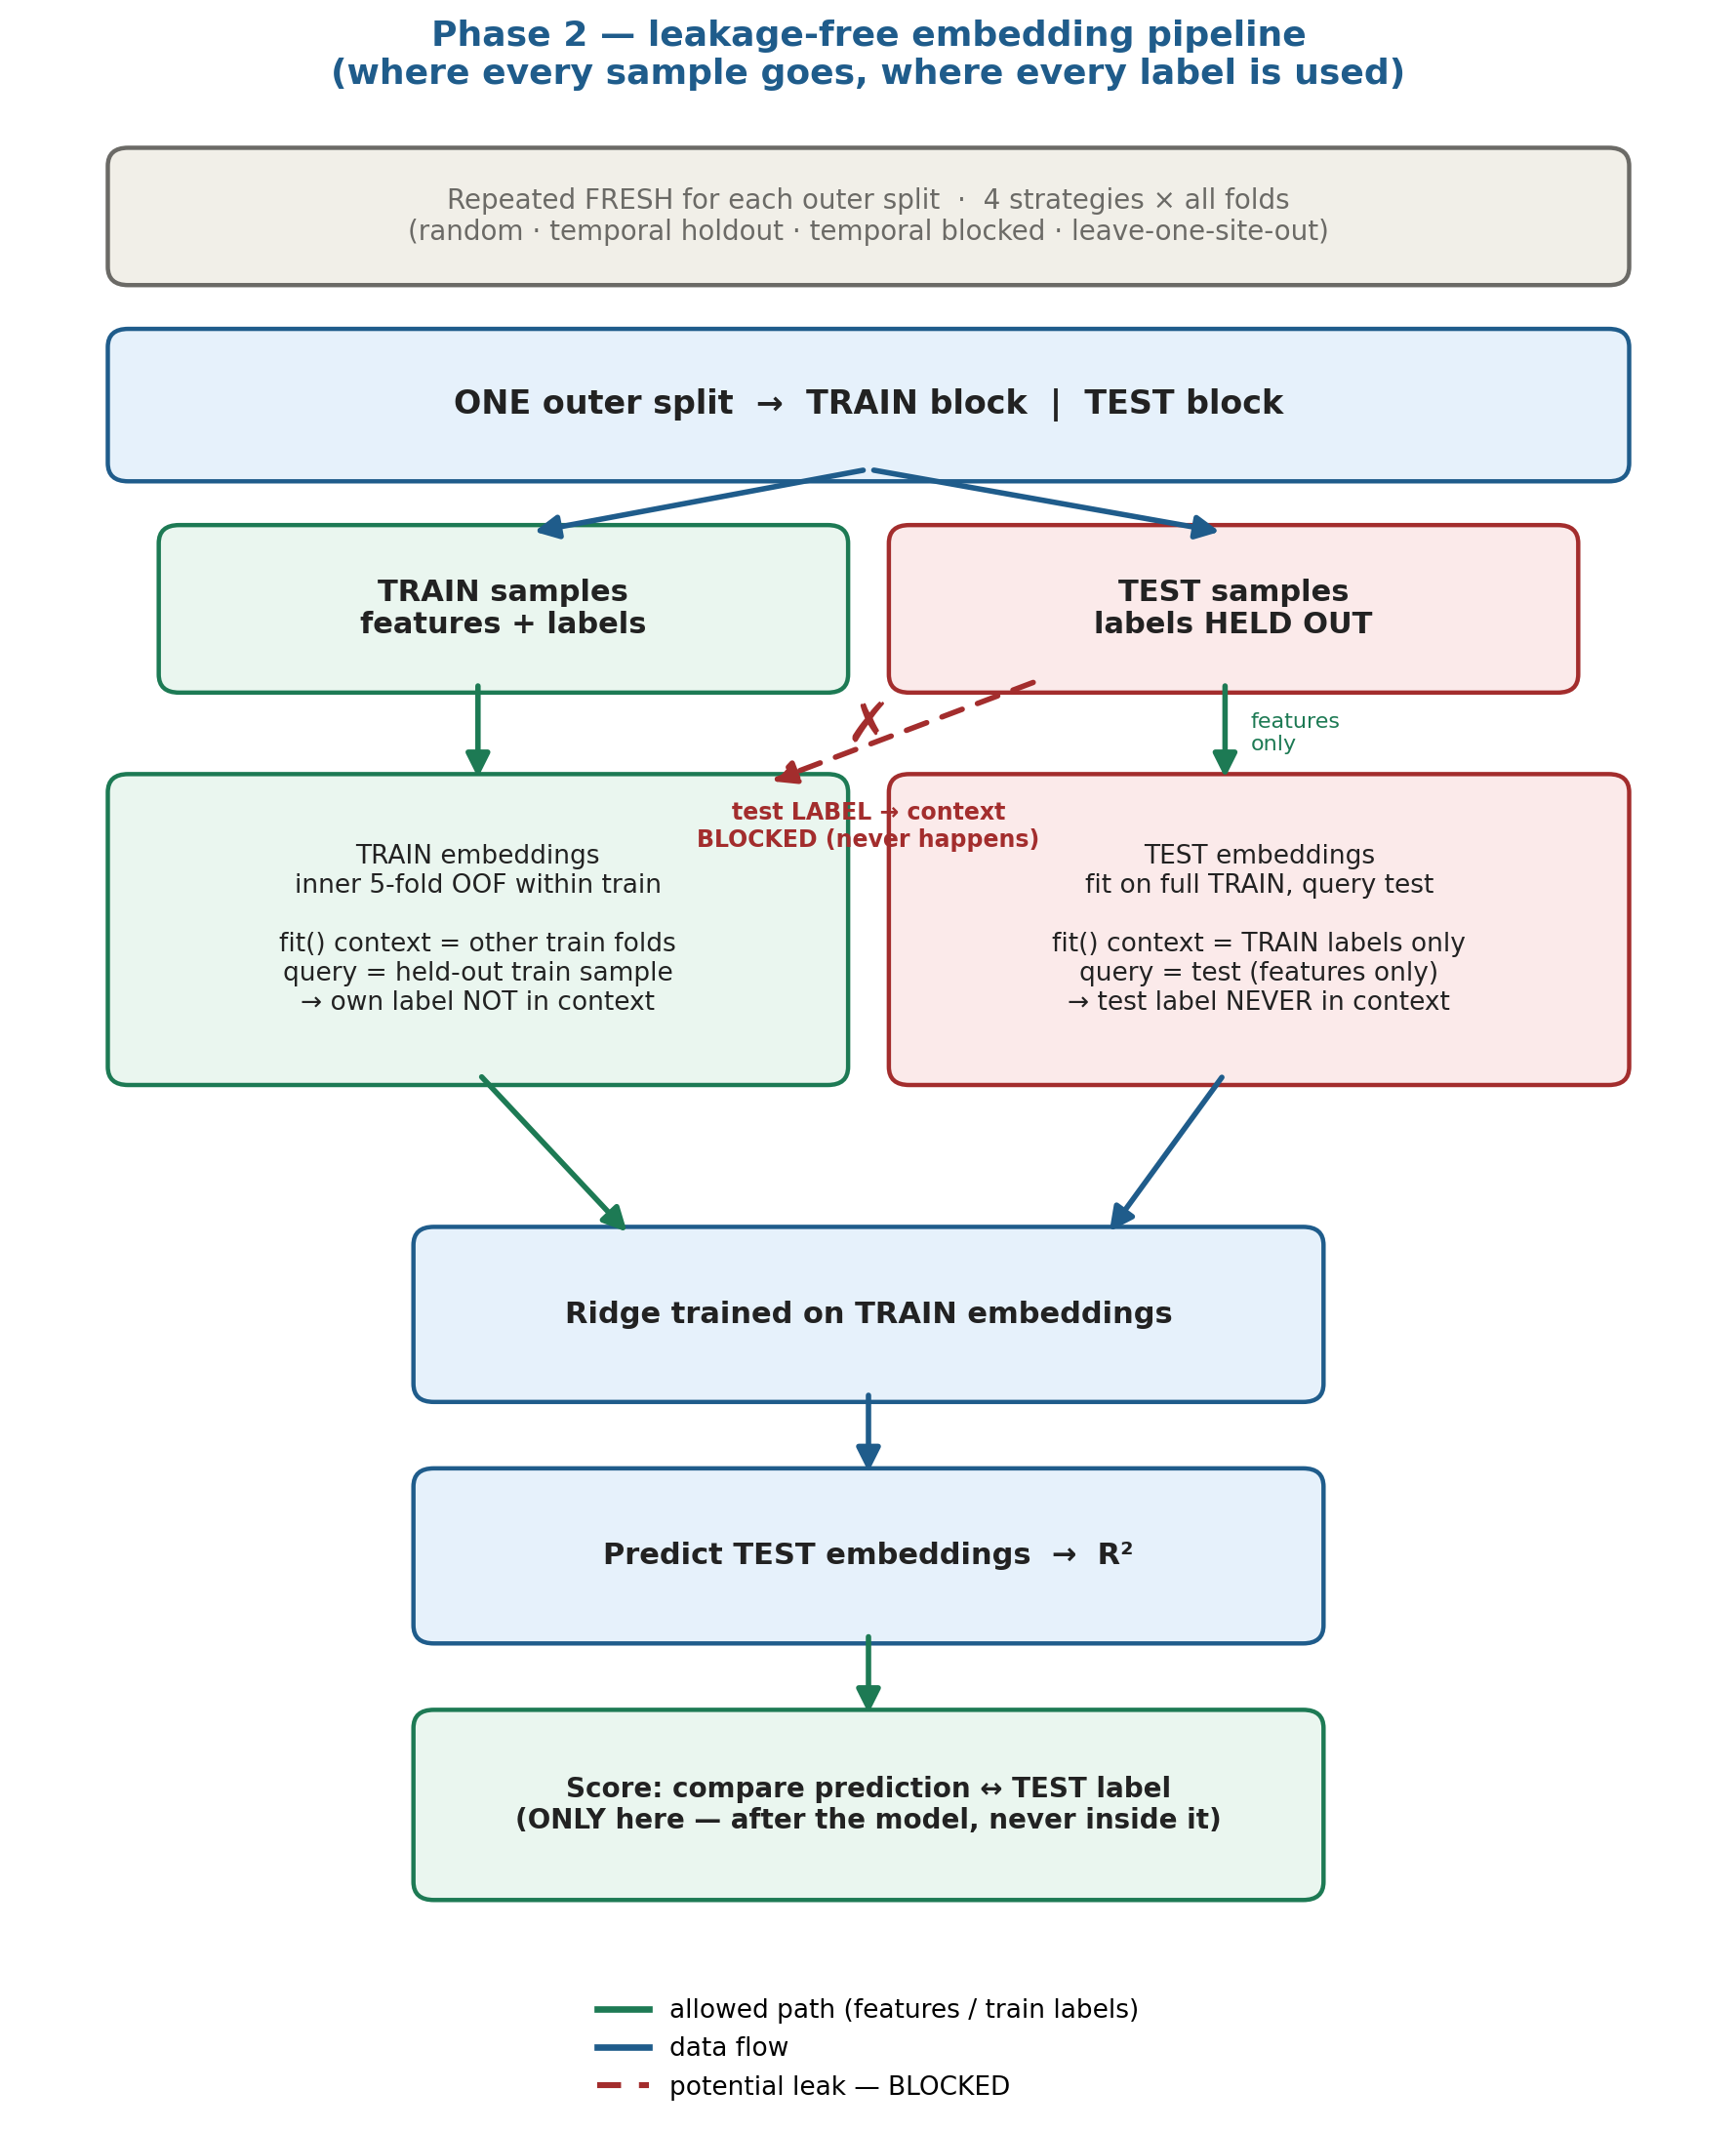

In [14]:
from pathlib import Path
R = Path('/mnt/data/home/tv2414/tabpfn_project/results')
f = R / 'phase2_leakage_dataflow.png'
print(f.exists(), f.stat().st_size if f.exists() else '')
from IPython.display import Image, display
if f.exists(): display(Image(str(f)))

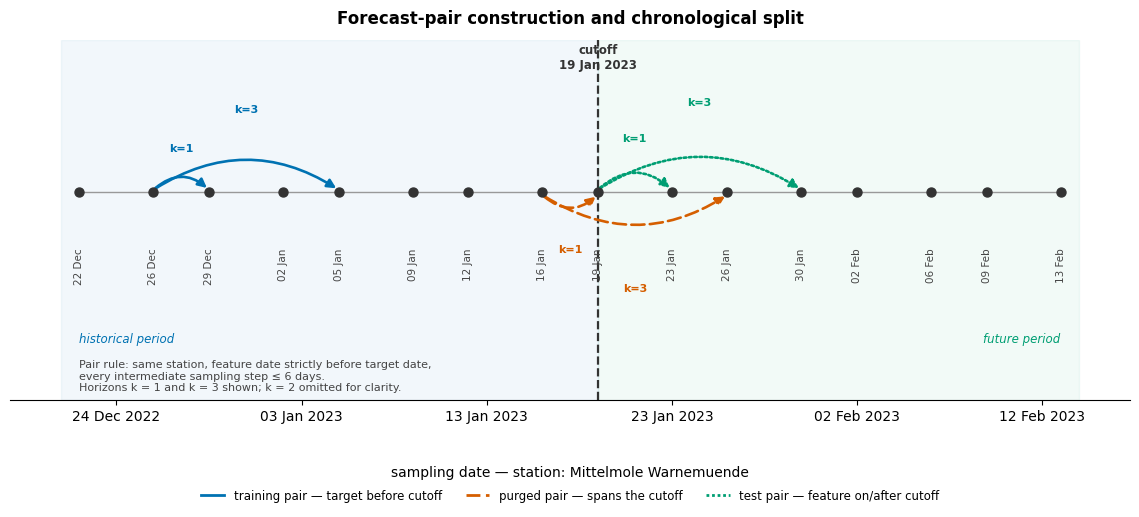

saved -> fig5_4_forecast_pairs.png / .pdf   station: Mittelmole Warnemuende


In [5]:
# === FIGURE 5.4 — forecast-pair construction and chronological split (FINAL) ===
#   Self-contained; reads real sampling dates from disk.
#   Okabe-Ito palette + redundant linestyle encoding (colourblind- and B/W-safe).
#   Horizons k=1 and k=3 shown; k=2 omitted for legibility.
import numpy as np, pandas as pd
import matplotlib as mpl, matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import FancyArrowPatch
from matplotlib.lines import Line2D
from pathlib import Path

ROOT = Path('/mnt/data/home/tv2414/tabpfn_project'); R = ROOT / 'results'
mpl.rcParams.update({'font.size': 10, 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.spines.left': False})

CUT, MAX_STEP = pd.Timestamp('2023-01-19'), 6
C  = {'train':'#0072B2', 'test':'#009E73', 'purge':'#D55E00', 'cut':'#333333'}
LS = {'train':'-', 'test':(0,(1,1)), 'purge':(0,(5,2))}

# ---------------------------------------------------------------- data
meta = pd.read_csv(ROOT/'data'/'processed'/'meta_clean.csv', index_col=0)
meta['date'] = pd.to_datetime(meta['date'])
cand = meta.groupby('location_name')['date'].agg(['min','max','count'])
site = cand[(cand['min']<CUT)&(cand['max']>CUT)].sort_values('count',ascending=False).index[0]

g = meta[meta.location_name==site].sort_values('date').drop_duplicates('date').reset_index(drop=True)
i_cut = int((g['date'] < CUT).sum())
g = g.iloc[max(0,i_cut-8): i_cut+8].reset_index(drop=True)
i_cut = int((g['date'] < CUT).sum())          # index of first test-eligible date
dnum = mdates.date2num(g['date'].dt.to_pydatetime())
xcut = mdates.date2num(CUT)

# ---------------------------------------------------------------- canvas
fig, ax = plt.subplots(figsize=(11.5, 5.4))
ax.axvspan(dnum[0]-1, xcut, color=C['train'], alpha=0.05, zorder=0)
ax.axvspan(xcut, dnum[-1]+1, color=C['test'],  alpha=0.05, zorder=0)
ax.axvline(xcut, color=C['cut'], ls='--', lw=1.6, zorder=1)
ax.text(xcut, 2.85, 'cutoff\n19 Jan 2023', ha='center', va='bottom',
        fontsize=8.5, fontweight='bold', color=C['cut'])

ax.plot(dnum, [0]*len(dnum), color='#999999', lw=1, zorder=1)
ax.scatter(dnum, [0]*len(dnum), s=42, color='#333333', zorder=5)
for x, d in zip(dnum, g['date']):
    ax.annotate(d.strftime('%d %b'), (x, 0), rotation=90, va='top', ha='center',
                fontsize=7.5, xytext=(0, -40), textcoords='offset points', color='#444444')

# ---------------------------------------------------------------- arcs
def arc(i, k, cls, rad, below=False):
    """One feature->target pair. below=True draws under the timeline."""
    j = i + k
    if i < 0 or j >= len(dnum): return
    steps = np.diff(g['date'].to_numpy()[i:j+1]).astype('timedelta64[D]').astype(int)
    if not (steps <= MAX_STEP).all(): return          # the real pairing rule
    sgn = 1 if below else -1
    y0  = -0.06 if below else 0.06
    ax.add_patch(FancyArrowPatch((dnum[i], y0), (dnum[j], y0),
                 connectionstyle=f"arc3,rad={sgn*rad}", arrowstyle='-|>',
                 mutation_scale=13, lw=1.9, color=C[cls], ls=LS[cls], zorder=4))
    apex = rad * abs(dnum[j] - dnum[i]) / 2
    ylab = (-apex - 0.55) if below else (apex + 0.25)
    ax.text((dnum[i]+dnum[j])/2, ylab, f'k={k}', ha='center',
            va='top' if below else 'bottom',
            fontsize=8, color=C[cls], fontweight='bold', zorder=6)

RAD = {1: 0.45, 3: 0.32}
for k in (1, 3):
    arc(i_cut-7, k, 'train', RAD[k])                 # target date < cutoff
    arc(i_cut,   k, 'test',  RAD[k])                 # feature date >= cutoff
    arc(i_cut-1, k, 'purge', RAD[k], below=True)     # spans the cutoff

# ---------------------------------------------------------------- annotations
ax.text(dnum[0],  -3.55, 'historical period', ha='left',  fontsize=8.5,
        color=C['train'], style='italic')
ax.text(dnum[-1], -3.55, 'future period',     ha='right', fontsize=8.5,
        color=C['test'],  style='italic')
ax.text(dnum[0],  -3.95, 'Pair rule: same station, feature date strictly before target date,\n'
                         'every intermediate sampling step ≤ 6 days.\n'
                         'Horizons k = 1 and k = 3 shown; k = 2 omitted for clarity.',
        fontsize=8, color='#444444', va='top')

ax.set_ylim(-4.9, 3.6); ax.set_yticks([])
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %Y'))
ax.set_xlabel(f'sampling date — station: {site}', labelpad=30)

leg = [Line2D([0],[0], color=C['train'], lw=2, ls=LS['train'],
              label='training pair — target before cutoff'),
       Line2D([0],[0], color=C['purge'], lw=2, ls=LS['purge'],
              label='purged pair — spans the cutoff'),
       Line2D([0],[0], color=C['test'],  lw=2, ls=LS['test'],
              label='test pair — feature on/after cutoff')]
ax.legend(handles=leg, loc='upper center', bbox_to_anchor=(0.5, -0.22), ncol=3,
          fontsize=8.5, frameon=False)
ax.set_title('Forecast-pair construction and chronological split', fontweight='bold', pad=12)

plt.tight_layout()
for ext in ('png', 'pdf'):
    plt.savefig(R / f'fig5_4_forecast_pairs.{ext}', dpi=200, bbox_inches='tight')
plt.show()
print('saved -> fig5_4_forecast_pairs.png / .pdf   station:', site)

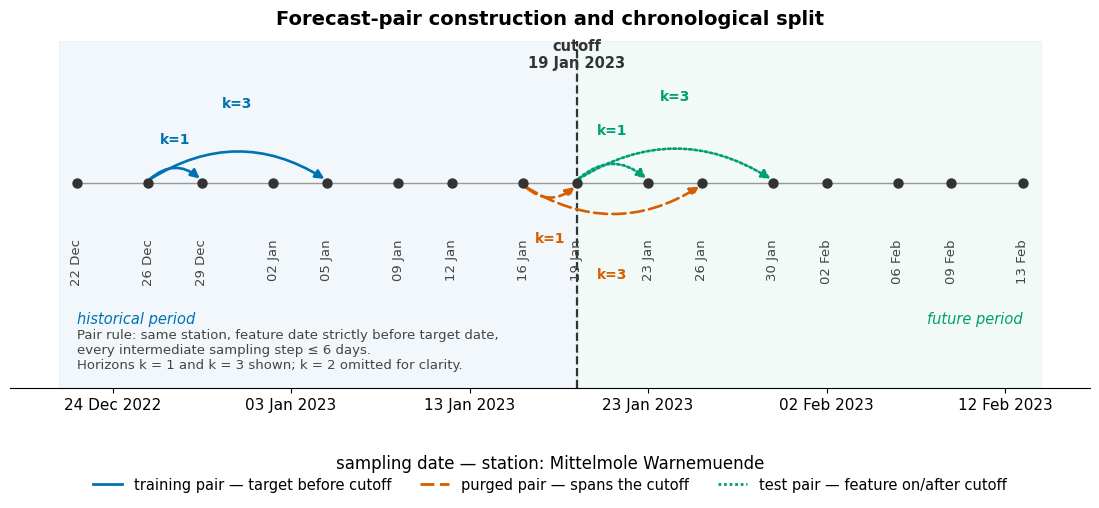

saved -> fig5_4_forecast_pairs.png / .pdf   station: Mittelmole Warnemuende


In [6]:
# === FIGURE 5.4 — forecast-pair construction and chronological split (FINAL) ===
#   Self-contained; reads real sampling dates from disk.
#   Okabe-Ito palette + redundant linestyle encoding (colourblind- and B/W-safe).
#   Horizons k=1 and k=3 shown; k=2 omitted for legibility.

import numpy as np, pandas as pd
import matplotlib as mpl, matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import FancyArrowPatch
from matplotlib.lines import Line2D
from pathlib import Path

ROOT = Path('/mnt/data/home/tv2414/tabpfn_project'); R = ROOT / 'results'

# ONLY FONT SIZES CHANGED
mpl.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 10.5,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.spines.left': False
})

CUT, MAX_STEP = pd.Timestamp('2023-01-19'), 6
C  = {'train':'#0072B2', 'test':'#009E73', 'purge':'#D55E00', 'cut':'#333333'}
LS = {'train':'-', 'test':(0,(1,1)), 'purge':(0,(5,2))}

# ---------------------------------------------------------------- data
meta = pd.read_csv(ROOT/'data'/'processed'/'meta_clean.csv').rename(

    columns={'Unnamed: 0':'sample_id'}
)
meta['date'] = pd.to_datetime(meta['date'])
meta = meta[~meta.location_name.str.contains('Heiligendamm', case=False)]

cand = meta.groupby('location_name')['date'].agg(['min','max','count'])

site = cand[
    (cand['min'] < CUT) & (cand['max'] > CUT)
].sort_values('count', ascending=False).index[0]

g = (
    meta[meta.location_name == site]
    .sort_values('date')
    .drop_duplicates('date')
    .reset_index(drop=True)
)

i_cut = int((g['date'] < CUT).sum())

g = g.iloc[max(0, i_cut-8): i_cut+8].reset_index(drop=True)

i_cut = int((g['date'] < CUT).sum())  # index of first test-eligible date

dnum = mdates.date2num(g['date'].dt.to_pydatetime())
xcut = mdates.date2num(CUT)

# ---------------------------------------------------------------- canvas
fig, ax = plt.subplots(figsize=(11.5, 5.4))

ax.axvspan(
    dnum[0]-1,
    xcut,
    color=C['train'],
    alpha=0.05,
    zorder=0
)

ax.axvspan(
    xcut,
    dnum[-1]+1,
    color=C['test'],
    alpha=0.05,
    zorder=0
)

ax.axvline(
    xcut,
    color=C['cut'],
    ls='--',
    lw=1.6,
    zorder=1
)

ax.text(
    xcut,
    2.85,
    'cutoff\n19 Jan 2023',
    ha='center',
    va='bottom',
    fontsize=10.5,          # was 8.5
    fontweight='bold',
    color=C['cut']
)

ax.plot(
    dnum,
    [0]*len(dnum),
    color='#999999',
    lw=1,
    zorder=1
)

ax.scatter(
    dnum,
    [0]*len(dnum),
    s=42,
    color='#333333',
    zorder=5
)

for x, d in zip(dnum, g['date']):
    ax.annotate(
        d.strftime('%d %b'),
        (x, 0),
        rotation=90,
        va='top',
        ha='center',
        fontsize=9.5,       # was 7.5
        xytext=(0, -40),
        textcoords='offset points',
        color='#444444'
    )

# ---------------------------------------------------------------- arcs
def arc(i, k, cls, rad, below=False):
    """One feature->target pair. below=True draws under the timeline."""

    j = i + k

    if i < 0 or j >= len(dnum):
        return

    steps = (
        np.diff(g['date'].to_numpy()[i:j+1])
        .astype('timedelta64[D]')
        .astype(int)
    )

    if not (steps <= MAX_STEP).all():
        return  # the real pairing rule

    sgn = 1 if below else -1
    y0  = -0.06 if below else 0.06

    ax.add_patch(
        FancyArrowPatch(
            (dnum[i], y0),
            (dnum[j], y0),
            connectionstyle=f"arc3,rad={sgn*rad}",
            arrowstyle='-|>',
            mutation_scale=13,
            lw=1.9,
            color=C[cls],
            ls=LS[cls],
            zorder=4
        )
    )

    apex = rad * abs(dnum[j] - dnum[i]) / 2
    ylab = (-apex - 0.55) if below else (apex + 0.25)

    ax.text(
        (dnum[i]+dnum[j])/2,
        ylab,
        f'k={k}',
        ha='center',
        va='top' if below else 'bottom',
        fontsize=10,        # was 8
        color=C[cls],
        fontweight='bold',
        zorder=6
    )

RAD = {
    1: 0.45,
    3: 0.32
}

for k in (1, 3):

    arc(
        i_cut-7,
        k,
        'train',
        RAD[k]
    )  # target date < cutoff

    arc(
        i_cut,
        k,
        'test',
        RAD[k]
    )  # feature date >= cutoff

    arc(
        i_cut-1,
        k,
        'purge',
        RAD[k],
        below=True
    )  # spans the cutoff

# ---------------------------------------------------------------- annotations
ax.text(
    dnum[0],
    -3.55,
    'historical period',
    ha='left',
    fontsize=10.5,          # was 8.5
    color=C['train'],
    style='italic'
)

ax.text(
    dnum[-1],
    -3.55,
    'future period',
    ha='right',
    fontsize=10.5,          # was 8.5
    color=C['test'],
    style='italic'
)

ax.text(
    dnum[0],
    -3.70,
    'Pair rule: same station, feature date strictly before target date,\n'
    'every intermediate sampling step ≤ 6 days.\n'
    'Horizons k = 1 and k = 3 shown; k = 2 omitted for clarity.',
    fontsize=9.5,           # was 8
    color='#444444',
    va='top'
)

ax.set_ylim(-5.2, 3.6)
ax.set_yticks([])

ax.xaxis.set_major_formatter(
    mdates.DateFormatter('%d %b %Y')
)

ax.set_xlabel(
    f'sampling date — station: {site}',
    labelpad=30,
    fontsize=12
)

leg = [
    Line2D(
        [0], [0],
        color=C['train'],
        lw=2,
        ls=LS['train'],
        label='training pair — target before cutoff'
    ),

    Line2D(
        [0], [0],
        color=C['purge'],
        lw=2,
        ls=LS['purge'],
        label='purged pair — spans the cutoff'
    ),

    Line2D(
        [0], [0],
        color=C['test'],
        lw=2,
        ls=LS['test'],
        label='test pair — feature on/after cutoff'
    )
]

ax.legend(
    handles=leg,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.22),
    ncol=3,
    fontsize=10.5,          # was 8.5
    frameon=False
)

ax.set_title(
    'Forecast-pair construction and chronological split',
    fontweight='bold',
    fontsize=14,            # explicitly larger
    pad=12
)

plt.tight_layout()

for ext in ('png', 'pdf'):
    plt.savefig(
        R / f'fig5_4_forecast_pairs.{ext}',
        dpi=200,
        bbox_inches='tight'
    )

plt.show()

print(
    'saved -> fig5_4_forecast_pairs.png / .pdf   station:',
    site
)

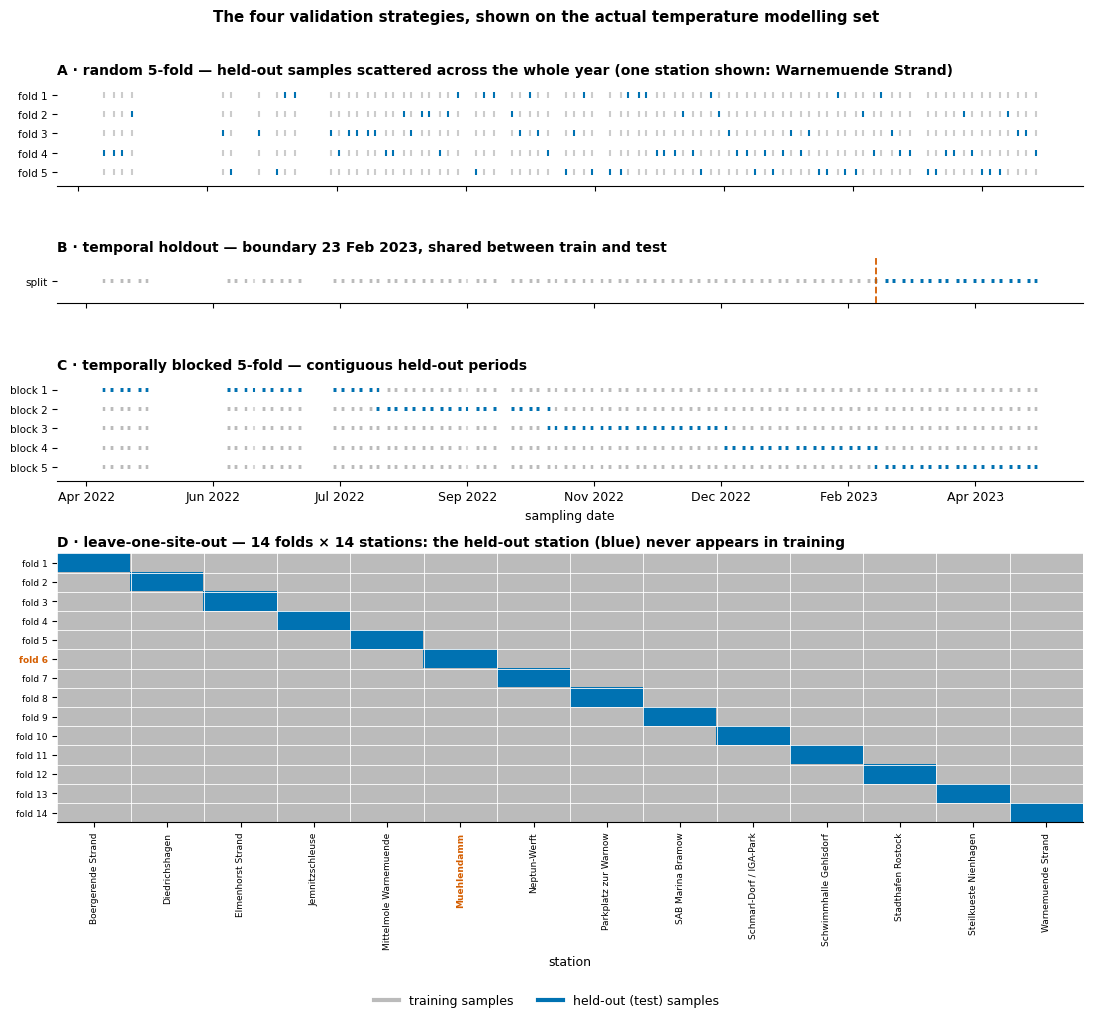

n=1226  holdout boundary 2023-02-23  |  A=5  B=1  C=5  D=14 folds


In [16]:
# === FIGURE 5.2 — the four validation strategies (COMPLETE, single cell) ===
#   Panels A–C on the time axis; panel D as a fold x station matrix.
#   Okabe-Ito palette. Reads real splits from src/cv_strategies.
import sys, numpy as np, pandas as pd
import matplotlib as mpl, matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
from matplotlib.colors import ListedColormap
from pathlib import Path
from sklearn.model_selection import KFold

ROOT = Path('/mnt/data/home/tv2414/tabpfn_project'); sys.path.insert(0, str(ROOT))
R = ROOT / 'results'
from src import cv_strategies as cvs

mpl.rcParams.update({'font.size': 9, 'axes.spines.top': False, 'axes.spines.right': False})
TR, TE, CUTC = '#BBBBBB', '#0072B2', '#D55E00'

# ---------------------------------------------------------------- data
meta = pd.read_csv(ROOT/'data'/'combined_meta_data.csv').rename(columns={'Unnamed: 0':'sample_id'})
meta['date'] = pd.to_datetime(meta['date'])
o16 = pd.read_csv(ROOT/'data'/'otus_16s_filtered.csv', index_col=0)
hd  = set(meta.loc[meta.location_name.str.contains('Heiligendamm', case=False), 'sample_id'])
master = meta[meta.sample_id.isin(set(o16.index) - hd)]
sub = master[master['temperature'].notna()].sort_values('date').reset_index(drop=True)
n = len(sub); d = pd.to_datetime(sub['date']); x = mdates.date2num(d.dt.to_pydatetime())
sites = sorted(sub['location_name'].unique()); k = len(sites)

def try_call(fn, *variants):
    if fn is None: return None
    for kw in variants:
        try:
            out = fn(**kw)
            if out is not None and len(out): return list(out)
        except Exception: continue
    return None

A = try_call(getattr(cvs,'random_kfold',None), dict(n_samples=n, n_folds=5)) \
    or list(KFold(n_splits=5, shuffle=True, random_state=42).split(np.arange(n)))
B = try_call(getattr(cvs,'temporal_holdout',None), dict(meta=sub, test_fraction=0.2, date_col='date'))
C = try_call(getattr(cvs,'temporal_blocked_kfold',None), dict(meta=sub, n_folds=5, date_col='date'))

# ---------------------------------------------------------------- figure
fig, axes = plt.subplots(4, 1, figsize=(11, 10),
                         gridspec_kw={'height_ratios': [1.4, 0.6, 1.4, 3.6]})

def style(ax, nrows, labels, title, fs=7.5):
    ax.set_yticks(range(nrows)); ax.set_yticklabels(labels, fontsize=fs)
    ax.set_ylim(-0.7, nrows-0.3); ax.invert_yaxis()
    ax.set_title(title, fontsize=10, fontweight='bold', loc='left', pad=5)
    ax.tick_params(axis='x', labelbottom=False)

# ---- A: random 5-fold, one station shown so the scatter is visible
REF = 'Warnemuende Strand'
idx_ref = np.where((sub['location_name'] == REF).to_numpy())[0]
for row, (tr, te) in enumerate(A):
    tr_r = np.intersect1d(np.asarray(tr), idx_ref); te_r = np.intersect1d(np.asarray(te), idx_ref)
    axes[0].scatter(x[tr_r], [row]*len(tr_r), s=16, color=TR, marker='|', alpha=.75)
    axes[0].scatter(x[te_r], [row]*len(te_r), s=16, color=TE, marker='|')
style(axes[0], len(A), [f'fold {i}' for i in range(1, len(A)+1)],
      f'A · random 5-fold — held-out samples scattered across the whole year '
      f'(one station shown: {REF})')

# ---- B: temporal holdout
tr, te = np.asarray(B[0][0]), np.asarray(B[0][1]); bnd = d.iloc[te].min()
axes[1].scatter(x[tr], [0]*len(tr), s=6, color=TR, marker='|', alpha=.6)
axes[1].scatter(x[te], [0]*len(te), s=6, color=TE, marker='|')
axes[1].axvline(mdates.date2num(bnd), color=CUTC, ls='--', lw=1.3, zorder=3)
style(axes[1], 1, ['split'],
      f'B · temporal holdout — boundary {bnd:%d %b %Y}, shared between train and test')

# ---- C: temporally blocked 5-fold
for row, (tr_, te_) in enumerate(C):
    tr_ = np.asarray(tr_); te_ = np.asarray(te_)
    axes[2].scatter(x[tr_], [row]*len(tr_), s=6, color=TR, marker='|', alpha=.6)
    axes[2].scatter(x[te_], [row]*len(te_), s=6, color=TE, marker='|')
style(axes[2], len(C), [f'block {i}' for i in range(1, len(C)+1)],
      'C · temporally blocked 5-fold — contiguous held-out periods')

# ---- D: LOSO as a fold x station matrix (space, not time)
ax = axes[3]
M = np.zeros((k, k)); np.fill_diagonal(M, 1)          # 1 = held out
ax.imshow(M, cmap=ListedColormap([TR, TE]), aspect='auto', vmin=0, vmax=1)
ax.set_xticks(range(k)); ax.set_xticklabels(sites, rotation=90, fontsize=6.5)
ax.set_yticks(range(k)); ax.set_yticklabels([f'fold {i}' for i in range(1, k+1)], fontsize=6.5)
for i in range(k+1):
    ax.axhline(i-0.5, color='white', lw=0.6); ax.axvline(i-0.5, color='white', lw=0.6)
mu = [i for i, s in enumerate(sites) if 'ehlendamm' in s]
if mu:
    ax.get_xticklabels()[mu[0]].set_color(CUTC); ax.get_xticklabels()[mu[0]].set_fontweight('bold')
    ax.get_yticklabels()[mu[0]].set_color(CUTC); ax.get_yticklabels()[mu[0]].set_fontweight('bold')
ax.set_title('D · leave-one-site-out — 14 folds × 14 stations: the held-out station (blue) '
             'never appears in training', fontsize=10, fontweight='bold', loc='left', pad=5)
ax.set_xlabel('station'); ax.tick_params(axis='x', labelbottom=True)

# ---- shared x-label for the time panels
axes[2].set_xlabel('')
for a in (axes[0], axes[1], axes[2]):
    a.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[2].tick_params(axis='x', labelbottom=True)
axes[2].set_xlabel('sampling date')

fig.legend(handles=[Line2D([0],[0], color=TR, lw=3, label='training samples'),
                    Line2D([0],[0], color=TE, lw=3, label='held-out (test) samples')],
           loc='lower center', ncol=2, frameon=False, fontsize=9, bbox_to_anchor=(0.5, -0.012))
fig.suptitle('The four validation strategies, shown on the actual temperature modelling set',
             fontweight='bold', y=0.997)
plt.tight_layout(rect=[0, 0.025, 1, 0.985])
for ext in ('png', 'pdf'):
    plt.savefig(R / f'fig5_2_validation_strategies.{ext}', dpi=200, bbox_inches='tight')
plt.show()

print(f'n={n}  holdout boundary {bnd:%Y-%m-%d}  |  A={len(A)}  B={len(B)}  C={len(C)}  D={k} folds')

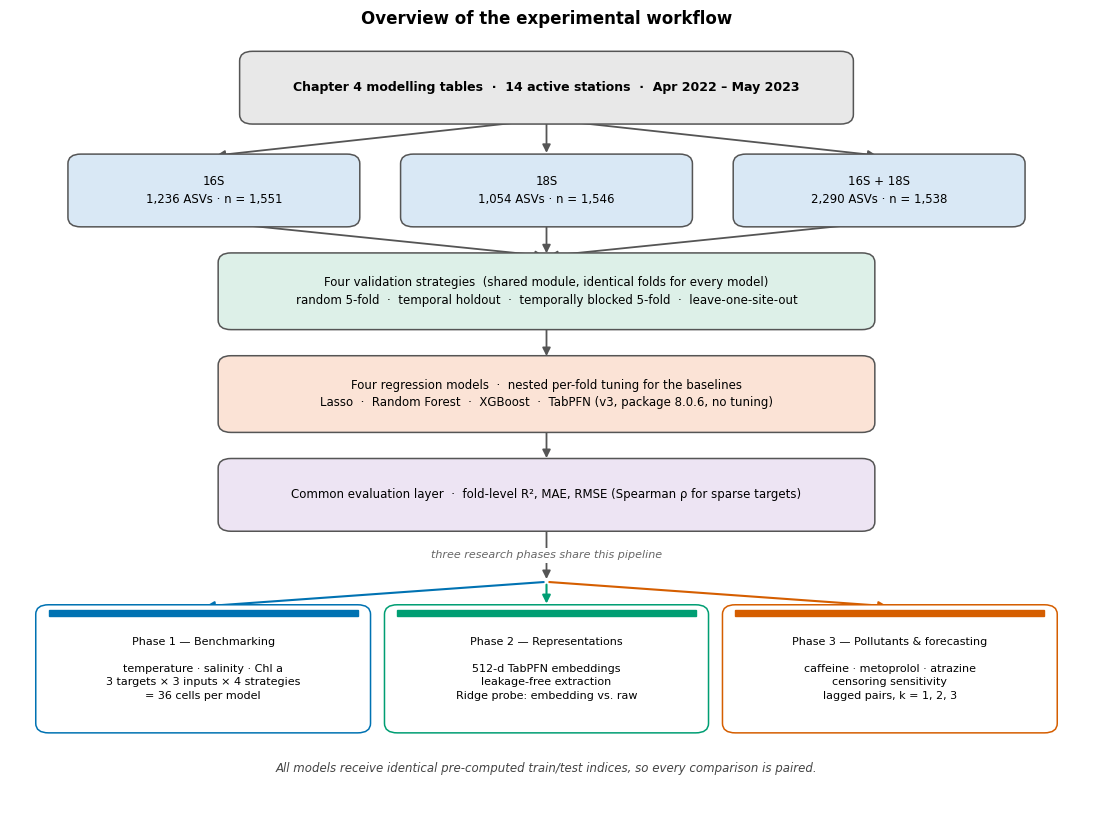

saved -> fig5_1_workflow.png / .pdf


In [18]:
# === FIGURE 5.1 — overview of the experimental workflow ===
#   Pure schematic (no data). Okabe-Ito palette, colourblind- and B/W-safe.
import matplotlib as mpl, matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from pathlib import Path

R = Path('/mnt/data/home/tv2414/tabpfn_project/results')
mpl.rcParams.update({'font.size': 9})

C = {'data':'#E8E8E8', 'input':'#D9E8F5', 'valid':'#DDF0E8',
     'model':'#FBE3D6', 'eval':'#EDE4F3', 'edge':'#555555',
     'p1':'#0072B2', 'p2':'#009E73', 'p3':'#D55E00'}

fig, ax = plt.subplots(figsize=(11, 8.4))
ax.set_xlim(0, 100); ax.set_ylim(0, 100); ax.axis('off')

def box(x, y, w, h, text, fc, fs=8.5, bold=False, ec=None):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle='round,pad=0.6,rounding_size=1.2',
                                fc=fc, ec=ec or C['edge'], lw=1.1, zorder=2))
    ax.text(x+w/2, y+h/2, text, ha='center', va='center', fontsize=fs, zorder=3,
            fontweight='bold' if bold else 'normal', linespacing=1.45)

def arrow(x1, y1, x2, y2, color=None, lw=1.3, style='-|>'):
    ax.add_patch(FancyArrowPatch((x1, y1), (x2, y2), arrowstyle=style, mutation_scale=12,
                                 color=color or C['edge'], lw=lw, zorder=1,
                                 shrinkA=2, shrinkB=2))

# ---------------------------------------------------------------- 1. data
box(22, 89, 56, 8, 'Chapter 4 modelling tables  ·  14 active stations  ·  Apr 2022 – May 2023',
    C['data'], fs=9, bold=True)

# ---------------------------------------------------------------- 2. inputs
box(6, 76, 26, 8, '16S\n1,236 ASVs · n = 1,551', C['input'])
box(37, 76, 26, 8, '18S\n1,054 ASVs · n = 1,546', C['input'])
box(68, 76, 26, 8, '16S + 18S\n2,290 ASVs · n = 1,538', C['input'])
for cx in (19, 50, 81):
    arrow(50, 89, cx, 84.4)

# ---------------------------------------------------------------- 3. validation
box(20, 63, 60, 8.5,
    'Four validation strategies  (shared module, identical folds for every model)\n'
    'random 5-fold  ·  temporal holdout  ·  temporally blocked 5-fold  ·  leave-one-site-out',
    C['valid'], fs=8.5)
for cx in (19, 50, 81):
    arrow(cx, 76, 50, 71.7)

# ---------------------------------------------------------------- 4. models
box(20, 50, 60, 8.5,
    'Four regression models  ·  nested per-fold tuning for the baselines\n'
    'Lasso  ·  Random Forest  ·  XGBoost  ·  TabPFN (v3, package 8.0.6, no tuning)',
    C['model'], fs=8.5)
arrow(50, 63, 50, 58.7)

# ---------------------------------------------------------------- 5. evaluation
box(20, 37.5, 60, 8,
    'Common evaluation layer  ·  fold-level R², MAE, RMSE (Spearman ρ for sparse targets)',
    C['eval'], fs=8.5)
arrow(50, 50, 50, 45.8)

# ---------------------------------------------------------------- 6. phases
arrow(50, 37.5, 50, 30.5)
ax.text(50, 33.2, 'three research phases share this pipeline',
        ha='center', va='bottom', fontsize=8, style='italic', color='#666666',
        bbox=dict(fc='white', ec='none', pad=2), zorder=5)

box(3, 12, 30, 15,
    'Phase 1 — Benchmarking\n\n'
    'temperature · salinity · Chl a\n'
    '3 targets × 3 inputs × 4 strategies\n'
    '= 36 cells per model',
    'white', fs=8, ec=C['p1'])
box(35.5, 12, 29, 15,
    'Phase 2 — Representations\n\n'
    '512-d TabPFN embeddings\n'
    'leakage-free extraction\n'
    'Ridge probe: embedding vs. raw',
    'white', fs=8, ec=C['p2'])
box(67, 12, 30, 15,
    'Phase 3 — Pollutants & forecasting\n\n'
    'caffeine · metoprolol · atrazine\n'
    'censoring sensitivity\n'
    'lagged pairs, k = 1, 2, 3',
    'white', fs=8, ec=C['p3'])
for cx, col in ((18, C['p1']), (50, C['p2']), (82, C['p3'])):
    arrow(50, 30.5, cx, 27.4, color=col, lw=1.5)

# phase colour bars
for x0, w, col in ((3, 30, C['p1']), (35.5, 29, C['p2']), (67, 30, C['p3'])):
    ax.add_patch(plt.Rectangle((x0+0.6, 26.2), w-1.2, 0.7, color=col, zorder=4))

# ---------------------------------------------------------------- 7. note
ax.text(50, 6.5,
        'All models receive identical pre-computed train/test indices, so every comparison is paired.',
        ha='center', fontsize=8.5, style='italic', color='#444444')

ax.set_title('Overview of the experimental workflow', fontsize=12, fontweight='bold', pad=6)
plt.tight_layout()
for ext in ('png', 'pdf'):
    plt.savefig(R / f'fig5_1_workflow.{ext}', dpi=200, bbox_inches='tight')
plt.show()
print('saved -> fig5_1_workflow.png / .pdf')

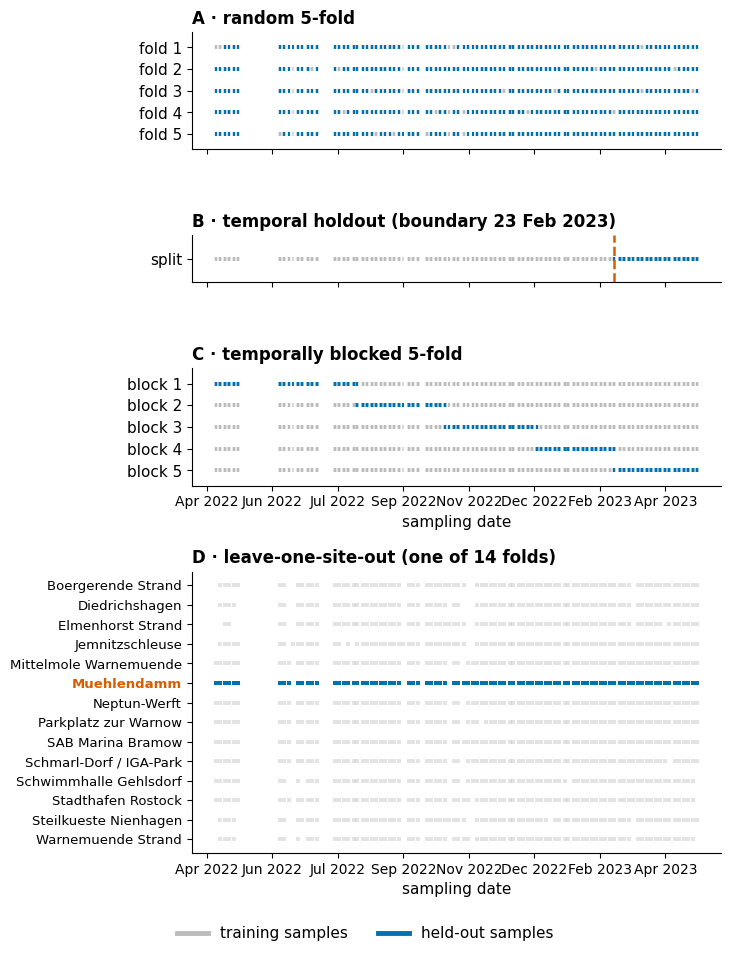

saved · n=1226 · boundary 2023-02-23


In [5]:
# === FIGURE 5.1 — the four validation strategies (LARGER TEXT for print) ===
import sys, numpy as np, pandas as pd
import matplotlib as mpl, matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
from pathlib import Path
from sklearn.model_selection import KFold

ROOT = Path('/mnt/data/home/tv2414/tabpfn_project'); sys.path.insert(0, str(ROOT))
R = ROOT / 'results'
from src import cv_strategies as cvs

# larger base font + narrower canvas => text stays legible at \textwidth
mpl.rcParams.update({'font.size': 13, 'axes.spines.top': False, 'axes.spines.right': False})
TR, TE, CUTC = '#BBBBBB', '#0072B2', '#D55E00'

# ---------------- data ----------------
meta = pd.read_csv(ROOT/'data'/'combined_meta_data.csv').rename(columns={'Unnamed: 0':'sample_id'})
meta['date'] = pd.to_datetime(meta['date'])
o16 = pd.read_csv(ROOT/'data'/'otus_16s_filtered.csv', index_col=0)
hd  = set(meta.loc[meta.location_name.str.contains('Heiligendamm', case=False), 'sample_id'])
master = meta[meta.sample_id.isin(set(o16.index) - hd)]
sub = master[master['temperature'].notna()].sort_values('date').reset_index(drop=True)
n = len(sub); d = pd.to_datetime(sub['date']); x = mdates.date2num(d.dt.to_pydatetime())
sites = sorted(sub['location_name'].unique()); k = len(sites)
site_row = {s: i for i, s in enumerate(sites)}
rows_all = sub['location_name'].map(site_row).to_numpy()

def try_call(fn, *variants):
    if fn is None: return None
    for kw in variants:
        try:
            out = fn(**kw)
            if out is not None and len(out): return list(out)
        except Exception: continue
    return None

A = try_call(getattr(cvs,'random_kfold',None), dict(n_samples=n, n_folds=5)) \
    or list(KFold(n_splits=5, shuffle=True, random_state=42).split(np.arange(n)))
B = try_call(getattr(cvs,'temporal_holdout',None), dict(meta=sub, test_fraction=0.2, date_col='date'))
C = try_call(getattr(cvs,'temporal_blocked_kfold',None), dict(meta=sub, n_folds=5, date_col='date'))
D = try_call(getattr(cvs,'leave_one_site_out',None),
             dict(meta=sub, site_col='location_name'), dict(meta=sub))
if D is None:
    D = [(np.where(rows_all != r)[0], np.where(rows_all == r)[0]) for r in range(k)]

# ---------------- figure (narrow + tall) ----------------
fig, axes = plt.subplots(4, 1, figsize=(7.5, 9.5),
                         gridspec_kw={'height_ratios': [1.25, 0.5, 1.25, 3.0]})

def style(ax, nrows, labels, title, fs=11):
    ax.set_yticks(range(nrows)); ax.set_yticklabels(labels, fontsize=fs)
    ax.set_ylim(-0.7, nrows-0.3); ax.invert_yaxis()
    ax.set_title(title, fontsize=12, fontweight='bold', loc='left', pad=6)
    ax.tick_params(axis='x', labelbottom=False, labelsize=11)

def strip(ax, splits, s_tr=9, s_te=9):
    for row, (tr, te) in enumerate(splits):
        tr = np.asarray(tr); te = np.asarray(te)
        ax.scatter(x[tr], [row]*len(tr), s=s_tr, color=TR, marker='|', alpha=.55)
        ax.scatter(x[te], [row]*len(te), s=s_te, color=TE, marker='|')

# --- A: random 5-fold
strip(axes[0], A)
style(axes[0], len(A), [f'fold {i}' for i in range(1, len(A)+1)],
      'A · random 5-fold')

# --- B: temporal holdout
strip(axes[1], B)
bnd = d.iloc[np.asarray(B[0][1])].min()
axes[1].axvline(mdates.date2num(bnd), color=CUTC, ls='--', lw=1.8, zorder=3)
style(axes[1], 1, ['split'], f'B · temporal holdout (boundary {bnd:%d %b %Y})')

# --- C: temporally blocked 5-fold
strip(axes[2], C)
style(axes[2], len(C), [f'block {i}' for i in range(1, len(C)+1)],
      'C · temporally blocked 5-fold')
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[2].tick_params(axis='x', labelbottom=True, labelsize=10, rotation=0)
axes[2].set_xlabel('sampling date', fontsize=11)

# --- D: LOSO, one representative fold in time x station space
mu_name = next(s for s in sites if 'ehlendamm' in s)
mu_fold = next(i for i, (tr, te) in enumerate(D)
               if sub['location_name'].iloc[np.asarray(te)[0]] == mu_name)
tr, te = np.asarray(D[mu_fold][0]), np.asarray(D[mu_fold][1])
ax = axes[3]
ax.scatter(x[tr], rows_all[tr], s=9, color=TR, marker='s', alpha=.40, linewidths=0)
ax.scatter(x[te], rows_all[te], s=12, color=TE, marker='s', linewidths=0)
ax.set_yticks(range(k)); ax.set_yticklabels(sites, fontsize=9.5)
ax.get_yticklabels()[site_row[mu_name]].set_color(CUTC)
ax.get_yticklabels()[site_row[mu_name]].set_fontweight('bold')
ax.set_ylim(-0.7, k-0.3); ax.invert_yaxis()
ax.set_title('D · leave-one-site-out (one of 14 folds)',
             fontsize=12, fontweight='bold', loc='left', pad=6)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.tick_params(axis='x', labelsize=10)
ax.set_xlabel('sampling date', fontsize=11)

fig.legend(handles=[Line2D([0],[0], color=TR, lw=3.5, label='training samples'),
                    Line2D([0],[0], color=TE, lw=3.5, label='held-out samples')],
           loc='lower center', ncol=2, frameon=False, fontsize=11,
           bbox_to_anchor=(0.5, -0.015))
plt.tight_layout(rect=[0, 0.025, 1, 1])
for ext in ('png', 'pdf'):
    plt.savefig(R / f'fig5_1_validation_strategies.{ext}', dpi=300, bbox_inches='tight')
plt.show()
print(f'saved · n={n} · boundary {bnd:%Y-%m-%d}')

In [20]:
# === locate the code that produced phase2_leakage_dataflow.png ===
import json, re
from pathlib import Path
ROOT = Path('/mnt/data/home/tv2414/tabpfn_project')

needles = ['leakage_dataflow', 'BLOCKED', 'never happens', 'labels HELD OUT',
           'leakage-free embedding pipeline']

for f in sorted(list(ROOT.glob('notebooks/*.ipynb')) + list(ROOT.glob('src/*.py')) + list(ROOT.glob('*.py'))):
    txt = f.read_text(errors='ignore')
    if any(nd in txt for nd in needles):
        print(f'\n===== {f.relative_to(ROOT)} =====')
        if f.suffix == '.ipynb':
            for i, c in enumerate(json.loads(txt)['cells']):
                s = ''.join(c.get('source', []))
                if any(nd in s for nd in needles):
                    print(f'--- cell {i} ({len(s)} chars) ---')
                    print(s[:400], '...' if len(s) > 400 else '')
        else:
            print('  (python file — grep hit)')


===== _all_nb.py =====
  (python file — grep hit)

===== notebooks/02_preprocessing.ipynb =====
--- cell 46 (5142 chars) ---
# === CHAPTER 5 — EMPIRICAL CHECKS: LOSO aggregation, autocorrelation code, blocked boundaries ===
import sys, re, json, inspect
import pandas as pd, numpy as np
from pathlib import Path
ROOT = Path('/mnt/data/home/tv2414/tabpfn_project'); sys.path.insert(0, str(ROOT))
R = ROOT / 'results'

# ---------------------------------------------------------------- 1A. what do the evaluators store?
print(' ...
--- cell 50 (258 chars) ---
from pathlib import Path
R = Path('/mnt/data/home/tv2414/tabpfn_project/results')
f = R / 'phase2_leakage_dataflow.png'
print(f.exists(), f.stat().st_size if f.exists() else '')
from IPython.display import Image, display
if f.exists(): display(Image(str(f))) 

===== notebooks/11_phase2_embeddings.ipynb =====
--- cell 57 (4527 chars) ---
# ===== Data-flow & leakage diagram (for Monday meeting) =====
import matplotlib.pyplot as plt
from ma

In [21]:
import json
from pathlib import Path
nb = Path('/mnt/data/home/tv2414/tabpfn_project/notebooks/11_phase2_embeddings.ipynb')
cells = json.loads(nb.read_text(errors='ignore'))['cells']
print(''.join(cells[57].get('source', [])))

# ===== Data-flow & leakage diagram (for Monday meeting) =====
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from matplotlib.lines import Line2D
from pathlib import Path

BLUE   = '#1F5C8B'; LIGHT = '#E6F1FB'; GREEN = '#1D7A54'
RED    = '#A32D2D'; GRAY  = '#6b6a66'; INK = '#222222'

fig, ax = plt.subplots(figsize=(9, 11))
ax.set_xlim(0, 10); ax.set_ylim(0, 13); ax.axis('off')

def box(x, y, w, h, text, fill=LIGHT, edge=BLUE, tcol=INK, fs=11, bold=False):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.08,rounding_size=0.12",
                                fc=fill, ec=edge, lw=1.6))
    ax.text(x + w/2, y + h/2, text, ha='center', va='center', fontsize=fs,
            color=tcol, fontweight='bold' if bold else 'normal', wrap=True)

def arrow(x1, y1, x2, y2, color=GREEN, style='-', lw=2.0):
    ax.add_patch(FancyArrowPatch((x1, y1), (x2, y2), arrowstyle='-|>', mutation_scale=18,
                                 color=c

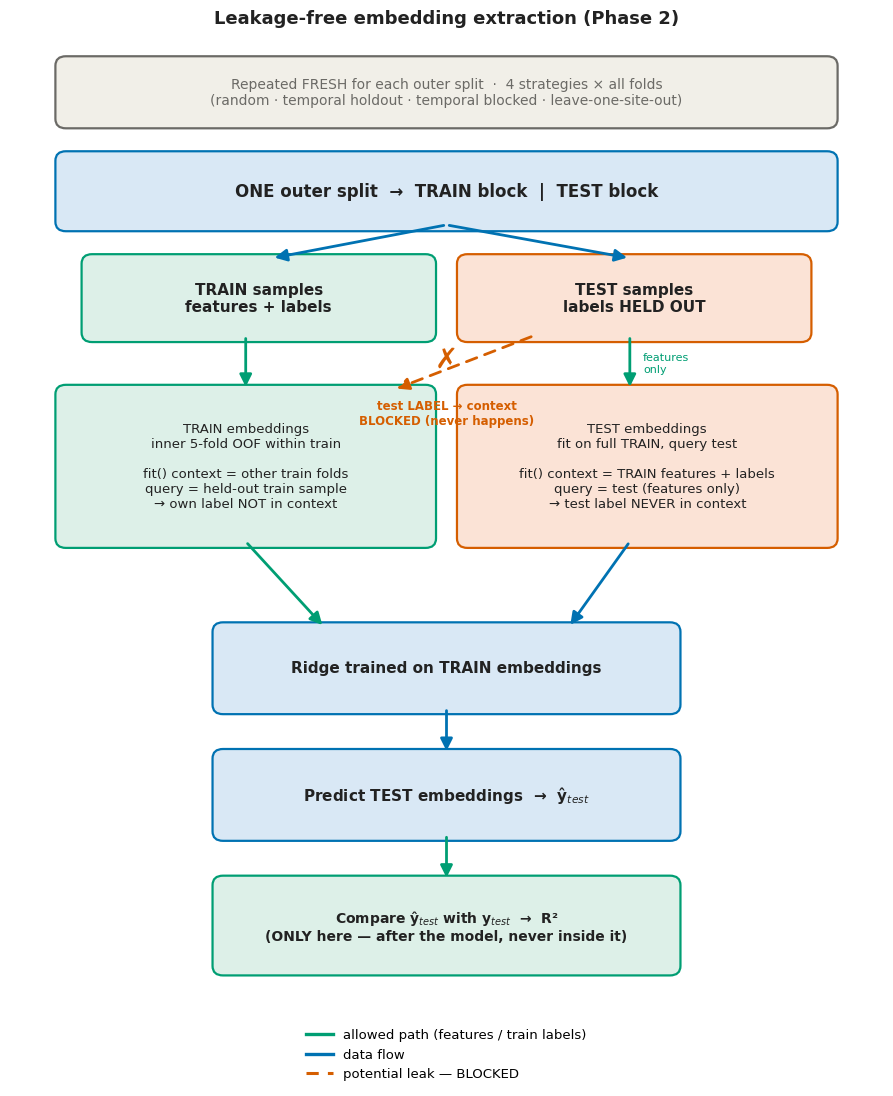

saved -> /mnt/data/home/tv2414/tabpfn_project/results/fig5_3_leakage_dataflow.png


In [24]:
# ===== FIGURE 5.3 — leakage-free Phase 2 embedding extraction =====
#   Okabe-Ito palette (matches Figures 5.1, 5.2, 5.4); redundant linestyle encoding.
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from matplotlib.lines import Line2D
from pathlib import Path

# Okabe-Ito, consistent with the other Chapter 5 figures
BLUE  = '#0072B2'; LIGHT = '#D9E8F5'
GREEN = '#009E73'; LGREEN = '#DDF0E8'
RED   = '#D55E00'; LRED   = '#FBE3D6'
GRAY  = '#6b6a66'; INK    = '#222222'

fig, ax = plt.subplots(figsize=(9, 11))
ax.set_xlim(0, 10); ax.set_ylim(0, 13); ax.axis('off')

def box(x, y, w, h, text, fill=LIGHT, edge=BLUE, tcol=INK, fs=11, bold=False):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.08,rounding_size=0.12",
                                fc=fill, ec=edge, lw=1.6))
    ax.text(x + w/2, y + h/2, text, ha='center', va='center', fontsize=fs,
            color=tcol, fontweight='bold' if bold else 'normal', wrap=True)

def arrow(x1, y1, x2, y2, color=GREEN, style='-', lw=2.0):
    ax.add_patch(FancyArrowPatch((x1, y1), (x2, y2), arrowstyle='-|>', mutation_scale=18,
                                 color=color, lw=lw, linestyle=style, connectionstyle="arc3,rad=0"))

# --- top banner: repeated per strategy ---
box(0.6, 12.0, 8.8, 0.75,
    'Repeated FRESH for each outer split  ·  4 strategies × all folds\n'
    '(random · temporal holdout · temporal blocked · leave-one-site-out)',
    fill='#F1EFE8', edge=GRAY, tcol=GRAY, fs=10)

# --- outer split ---
box(0.6, 10.7, 8.8, 0.85, 'ONE outer split  →  TRAIN block  |  TEST block',
    fill=LIGHT, edge=BLUE, fs=12, bold=True)

# TRAIN and TEST source boxes
box(0.9, 9.3, 3.9, 0.95, 'TRAIN samples\nfeatures + labels', fill=LGREEN, edge=GREEN, fs=11, bold=True)
box(5.2, 9.3, 3.9, 0.95, 'TEST samples\nlabels HELD OUT',   fill=LRED,  edge=RED,   fs=11, bold=True)
arrow(5.0, 10.7, 3.0, 10.28, color=BLUE)
arrow(5.0, 10.7, 7.1, 10.28, color=BLUE)

# --- embedding stage ---
box(0.6, 6.7, 4.2, 1.9,
    'TRAIN embeddings\ninner 5-fold OOF within train\n\n'
    'fit() context = other train folds\nquery = held-out train sample\n→ own label NOT in context',
    fill=LGREEN, edge=GREEN, fs=9.5)
box(5.2, 6.7, 4.2, 1.9,
    'TEST embeddings\nfit on full TRAIN, query test\n\n'
    'fit() context = TRAIN features + labels\nquery = test (features only)\n→ test label NEVER in context',
    fill=LRED, edge=RED, fs=9.5)

arrow(2.7, 9.3, 2.7, 8.62, color=GREEN)
arrow(7.1, 9.3, 7.1, 8.62, color=GREEN)
ax.text(7.25, 8.95, 'features\nonly', ha='left', va='center', fontsize=8, color=GREEN)

# --- the blocked leakage path ---
arrow(6.0, 9.3, 4.4, 8.62, color=RED, style=(0,(4,3)), lw=2.0)
ax.text(5.0, 9.0, '✗', ha='center', va='center', fontsize=20, color=RED, fontweight='bold')
ax.text(5.0, 8.5, 'test LABEL → context\nBLOCKED (never happens)', ha='center', va='top',
        fontsize=8.5, color=RED, fontweight='bold')

# --- downstream Ridge ---
box(2.4, 4.6, 5.2, 1.0, 'Ridge trained on TRAIN embeddings', fill=LIGHT, edge=BLUE, fs=11, bold=True)
arrow(2.7, 6.7, 3.6, 5.62, color=GREEN)
arrow(7.1, 6.7, 6.4, 5.62, color=BLUE)

box(2.4, 3.0, 5.2, 1.0, 'Predict TEST embeddings  →  ŷ$_{test}$',
    fill=LIGHT, edge=BLUE, fs=11, bold=True)
arrow(5.0, 4.6, 5.0, 4.02, color=BLUE)

# --- scoring: the only place a test label appears ---
box(2.4, 1.3, 5.2, 1.1,
    'Compare ŷ$_{test}$ with y$_{test}$  →  R²\n(ONLY here — after the model, never inside it)',
    fill=LGREEN, edge=GREEN, fs=10, bold=True)
arrow(5.0, 3.0, 5.0, 2.42, color=GREEN)

# --- legend ---
legend_elems = [
    Line2D([0],[0], color=GREEN, lw=2.4, label='allowed path (features / train labels)'),
    Line2D([0],[0], color=BLUE,  lw=2.4, label='data flow'),
    Line2D([0],[0], color=RED,   lw=2.2, linestyle=(0,(4,3)), label='potential leak — BLOCKED'),
]
ax.legend(handles=legend_elems, loc='lower center', bbox_to_anchor=(0.5, -0.02),
          ncol=1, frameon=False, fontsize=9.5)

ax.set_title('Leakage-free embedding extraction (Phase 2)',
             fontsize=13, fontweight='bold', color=INK, pad=14)

plt.tight_layout()
out = Path('/mnt/data/home/tv2414/tabpfn_project/results/fig5_3_leakage_dataflow.png')
fig.savefig(out, dpi=200, bbox_inches='tight', facecolor='white')
fig.savefig(out.with_suffix('.pdf'), bbox_inches='tight', facecolor='white')
plt.show()
print('saved ->', out)

In [25]:
# ── CELL 1: verify Table 6.2 — full grid, win counts, tie cells, margins ────
import pandas as pd
from pathlib import Path

RESULTS = Path('../results')
df = pd.read_csv(RESULTS / 'phase1_final_comparison_table_v3.csv')
print('shape:', df.shape)
print('columns:', list(df.columns))

models = ['Lasso', 'RF', 'XGBoost', 'TabPFN']
df[models] = df[models].apply(pd.to_numeric, errors='coerce')

# winner per cell and TabPFN margin over best baseline
df['winner'] = df[models].idxmax(axis=1)
df['tabpfn_margin'] = df['TabPFN'] - df[['Lasso', 'RF', 'XGBoost']].max(axis=1)

print('\n=== Win counts (out of 36) ===')
print(df['winner'].value_counts().to_string())

non_wins = df[df['winner'] != 'TabPFN']
print(f'\n=== Cells where TabPFN is NOT best ({len(non_wins)}) ===')
print(non_wins[['Target', 'Input', 'Strategy', 'XGBoost', 'TabPFN',
                'winner', 'tabpfn_margin']].to_string(index=False))

print('\n=== Margin summary over all 36 cells ===')
print(f"mean   TabPFN margin: {df['tabpfn_margin'].mean():+.4f}")
print(f"median TabPFN margin: {df['tabpfn_margin'].median():+.4f}")

print('\n=== Mean ΔR² (TabPFN − best baseline) per strategy ===')
per_strat = df.groupby('Strategy')['tabpfn_margin'].agg(['mean', 'median', 'count'])
print(per_strat.round(4).to_string())

print('\n=== Wins per strategy ===')
print(df.groupby('Strategy')['winner']
        .apply(lambda s: (s == 'TabPFN').sum()).to_string())

# degenerate salinity LOSO cells (all models negative)
best_r2 = df[models].max(axis=1)
degen = df[best_r2 < 0]
print(f'\n=== Degenerate cells (best R² < 0): {len(degen)} ===')
print(degen[['Target', 'Input', 'Strategy', 'TabPFN']].to_string(index=False))

# excluding degenerate cells
informative = df[best_r2 >= 0]
wins_inf = (informative['winner'] == 'TabPFN').sum()
print(f'\nTabPFN best in {wins_inf}/{len(informative)} informative cells')

shape: (36, 8)
columns: ['Target', 'Input', 'Strategy', 'Lasso', 'RF', 'XGBoost', 'TabPFN', 'Best']

=== Win counts (out of 36) ===
winner
TabPFN     34
XGBoost     2

=== Cells where TabPFN is NOT best (2) ===
       Target   Input Strategy  XGBoost  TabPFN  winner  tabpfn_margin
     salinity     16S  Holdout   0.9251  0.9247 XGBoost        -0.0004
Chl_a (log1p) 16S+18S  Blocked   0.6642  0.6625 XGBoost        -0.0017

=== Margin summary over all 36 cells ===
mean   TabPFN margin: +1.3193
median TabPFN margin: +0.0298

=== Mean ΔR² (TabPFN − best baseline) per strategy ===
            mean  median  count
Strategy                       
Blocked   0.2816  0.0305      9
Holdout   0.1180  0.0328      9
LOSO      4.8562  0.0641      9
Random    0.0214  0.0195      9

=== Wins per strategy ===
Strategy
Blocked    8
Holdout    8
LOSO       9
Random     9

=== Degenerate cells (best R² < 0): 3 ===
  Target   Input Strategy   TabPFN
salinity     16S     LOSO  -8.2956
salinity     18S     LOSO

In [26]:
# ── CELL 2: verify Table 6.4 — cross-metric consistency (R², MAE, RMSE) ────
import pandas as pd
from pathlib import Path

RESULTS = Path('../results')

# per-model long-format result files (adjust names if different)
files = {
    'Lasso'  : 'phase1_lasso_3targets_3inputs_4strategies.csv',
    'RF'     : 'phase1_rf_3targets_3inputs_4strategies.csv',
    'XGBoost': 'phase1_xgboost_3targets_3inputs_4strategies.csv',
    'TabPFN' : 'phase1_tabpfn_v3_3targets_3inputs_4strategies.csv',
}
for k, f in files.items():
    p = RESULTS / f
    print(f'{k:8s} exists={p.exists()}  {f}')

print('\n--- available phase1 CSVs in results/ ---')
for p in sorted(RESULTS.glob('phase1*.csv')):
    print(' ', p.name)

# peek at the schema of one file to learn column names
first_existing = next((RESULTS / f for f in files.values() if (RESULTS / f).exists()), None)
if first_existing is not None:
    tmp = pd.read_csv(first_existing)
    print(f'\nSchema of {first_existing.name}:  shape={tmp.shape}')
    print('columns:', list(tmp.columns))
    print(tmp.head(3).to_string(index=False))

Lasso    exists=True  phase1_lasso_3targets_3inputs_4strategies.csv
RF       exists=False  phase1_rf_3targets_3inputs_4strategies.csv
XGBoost  exists=True  phase1_xgboost_3targets_3inputs_4strategies.csv
TabPFN   exists=True  phase1_tabpfn_v3_3targets_3inputs_4strategies.csv

--- available phase1 CSVs in results/ ---
  phase1_baselines_3targets_16s.csv
  phase1_comparison_lasso_vs_xgboost.csv
  phase1_final_comparison_table_v3.csv
  phase1_forecasting_shared_mask_splitB.csv
  phase1_four_model_comparison.csv
  phase1_full_metrics_appendix.csv
  phase1_lasso_3newstrategies.csv
  phase1_lasso_3targets_16s.csv
  phase1_lasso_3targets_3inputs.csv
  phase1_lasso_3targets_3inputs_4strategies.csv
  phase1_lasso_3targets_3inputs_with_alpha.csv
  phase1_lasso_loso_robust_stats.csv
  phase1_lasso_vs_xgboost_final.csv
  phase1_random_forest_3targets_3inputs_4strategies.csv
  phase1_tabpfn_3targets_3inputs_4strategies.csv
  phase1_tabpfn_v26_3targets_3inputs_4strategies.csv
  phase1_tabpfn_v3_3tar

In [27]:
# ── CELL 3: load all four per-model result files, harmonise labels, audit NaNs ──
import pandas as pd
from pathlib import Path

RESULTS = Path('../results')
files = {
    'Lasso'  : 'phase1_lasso_3targets_3inputs_4strategies.csv',
    'RF'     : 'phase1_random_forest_3targets_3inputs_4strategies.csv',
    'XGBoost': 'phase1_xgboost_3targets_3inputs_4strategies.csv',
    'TabPFN' : 'phase1_tabpfn_v3_3targets_3inputs_4strategies.csv',
}

frames = []
for model, fname in files.items():
    d = pd.read_csv(RESULTS / fname)
    print(f'{model:8s} shape={d.shape}')
    print(f'   columns: {list(d.columns)}')
    tcol = 'target' if 'target' in d.columns else 'target_name'
    keep = d[[tcol, 'input', 'strategy', 'r2_mean', 'mae_mean', 'rmse_mean']].copy()
    keep = keep.rename(columns={tcol: 'target'})
    keep['model'] = model
    frames.append(keep)

long = pd.concat(frames, ignore_index=True)

# harmonise target labels (known mismatch: 'Chl_a (log1p)' vs 'Chl_a_log1p')
long['target'] = long['target'].replace({'Chl_a (log1p)': 'Chl_a_log1p'})

print('\n=== label audit ===')
print('targets   :', sorted(long['target'].unique()))
print('inputs    :', sorted(long['input'].unique()))
print('strategies:', sorted(long['strategy'].unique()))
print('rows per model:', long.groupby('model').size().to_dict())

print('\n=== missing-metric audit (how many of 36 rows are NaN per model/metric) ===')
nan_audit = long.groupby('model')[['r2_mean', 'mae_mean', 'rmse_mean']].apply(
    lambda g: g.isna().sum())
print(nan_audit.to_string())

print('\n=== rows with any NaN metric ===')
bad = long[long[['r2_mean', 'mae_mean', 'rmse_mean']].isna().any(axis=1)]
print(bad.to_string(index=False))

long.to_csv(RESULTS / 'ch6_verify_long_metrics.csv', index=False)
print(f'\nsaved -> {RESULTS / "ch6_verify_long_metrics.csv"}  ({len(long)} rows, expect 144)')

Lasso    shape=(36, 15)
   columns: ['strategy', 'input', 'target', 'n_folds', 'n_samples', 'n_features', 'r2_mean', 'r2_std', 'mae_mean', 'mae_std', 'rmse_mean', 'rmse_std', 'alpha_mean', 'n_selected_mean', 'total_time']
RF       shape=(36, 18)
   columns: ['target_display', 'target', 'input', 'strategy', 'log_target', 'n_samples', 'n_features', 'n_folds', 'r2_mean', 'r2_std', 'mae_mean', 'mae_std', 'rmse_mean', 'rmse_std', 'best_n_est_mode', 'best_max_depth_mode', 'best_min_samples_leaf_mode', 'total_time']
XGBoost  shape=(36, 18)
   columns: ['target_display', 'target', 'input', 'strategy', 'log_target', 'n_samples', 'n_features', 'n_folds', 'r2_mean', 'r2_std', 'mae_mean', 'mae_std', 'rmse_mean', 'rmse_std', 'best_max_depth_mode', 'best_lr_mode', 'best_n_est_mode', 'total_time']
TabPFN   shape=(36, 18)
   columns: ['target_display', 'target', 'input', 'strategy', 'log_target', 'n_samples', 'n_features', 'n_folds', 'r2_mean', 'r2_std', 'mae_mean', 'mae_std', 'rmse_mean', 'rmse_std',

In [28]:
# ── CELL 4: verify Table 6.4 — per-cell winner under R², MAE, RMSE ──────────
import pandas as pd
from pathlib import Path

RESULTS = Path('../results')
long = pd.read_csv(RESULTS / 'ch6_verify_long_metrics.csv')

def winners(metric, higher_is_better):
    w = long.pivot_table(index=['target', 'input', 'strategy'],
                         columns='model', values=metric)
    w = w[['Lasso', 'RF', 'XGBoost', 'TabPFN']]
    if higher_is_better:
        w['winner'] = w.idxmax(axis=1)
        w['tabpfn_margin'] = w['TabPFN'] - w[['Lasso', 'RF', 'XGBoost']].max(axis=1)
    else:
        w['winner'] = w.idxmin(axis=1)
        w['tabpfn_margin'] = w[['Lasso', 'RF', 'XGBoost']].min(axis=1) - w['TabPFN']
    return w

for metric, hib in [('r2_mean', True), ('mae_mean', False), ('rmse_mean', False)]:
    w = winners(metric, hib)
    n_cells = w['winner'].notna().sum()
    n_tab = (w['winner'] == 'TabPFN').sum()
    print('=' * 72)
    print(f'  {metric}  ({"higher" if hib else "lower"} is better)'
          f'  — TabPFN best in {n_tab} / {n_cells} cells')
    print('=' * 72)
    print(f'  mean   margin: {w["tabpfn_margin"].mean():+.4f}')
    print(f'  median margin: {w["tabpfn_margin"].median():+.4f}')
    print('  full win counts:', w['winner'].value_counts().to_dict())
    lost = w[w['winner'] != 'TabPFN']
    if len(lost):
        print(f'\n  Cells NOT won by TabPFN ({len(lost)}):')
        print(lost[['Lasso', 'RF', 'XGBoost', 'TabPFN',
                    'winner', 'tabpfn_margin']].round(4).to_string())
    print()

# how many cells does Lasso have a valid RMSE for (documentation of the gap)
rmse_pivot = long.pivot_table(index=['target', 'input', 'strategy'],
                              columns='model', values='rmse_mean')
print('RMSE availability per model:', rmse_pivot.notna().sum().to_dict())

  r2_mean  (higher is better)  — TabPFN best in 34 / 36 cells
  mean   margin: +1.3193
  median margin: +0.0298
  full win counts: {'TabPFN': 34, 'XGBoost': 2}

  Cells NOT won by TabPFN (2):
model                                        Lasso      RF  XGBoost  TabPFN   winner  tabpfn_margin
target      input   strategy                                                                       
Chl_a_log1p 16S+18S temporal_blocked_kfold -6.7183  0.6460   0.6642  0.6625  XGBoost        -0.0017
salinity    16S     temporal_holdout        0.4462  0.9204   0.9251  0.9247  XGBoost        -0.0004

  mae_mean  (lower is better)  — TabPFN best in 35 / 36 cells
  mean   margin: +0.2514
  median margin: +0.2085
  full win counts: {'TabPFN': 35, 'XGBoost': 1}

  Cells NOT won by TabPFN (1):
model                            Lasso     RF  XGBoost  TabPFN   winner  tabpfn_margin
target   input strategy                                                               
salinity 16S   temporal_holdout  2.347  0

In [29]:
# ── CELL 5: verify quoted per-cell numbers (targets, inputs, temperature MAE) ──
import pandas as pd
from pathlib import Path

RESULTS = Path('../results')
long = pd.read_csv(RESULTS / 'ch6_verify_long_metrics.csv')

# (a) headline cell: temperature x 16S x random_kfold
print('=== (a) temperature x 16S x random_kfold ===')
a = long[(long.target == 'temperature') & (long.input == '16S') &
         (long.strategy == 'random_kfold')]
print(a[['model', 'r2_mean', 'mae_mean', 'rmse_mean']].round(4).to_string(index=False))

# (b) TabPFN R2 range per target under random_kfold (all inputs)
print('\n=== (b) random_kfold: R2 range per target, per model ===')
b = long[long.strategy == 'random_kfold']
print(b.pivot_table(index='target', columns='model', values='r2_mean',
                    aggfunc=['min', 'max']).round(4).to_string())

# (c) input effect for TabPFN: R2 per input, per target, per strategy
print('\n=== (c) TabPFN R2 by input (rows) — is 16S >= 16S+18S ? ===')
c = long[long.model == 'TabPFN'].pivot_table(
    index=['target', 'strategy'], columns='input', values='r2_mean')
c = c[['16S', '18S', '16S+18S']]
c['16S_minus_combined'] = c['16S'] - c['16S+18S']
print(c.round(4).to_string())
print(f"\n16S >= 16S+18S in {(c['16S_minus_combined'] >= 0).sum()} / {len(c)} "
      f"TabPFN cells; mean diff = {c['16S_minus_combined'].mean():+.4f}")

# (d) Chl_a LOSO across models
print('\n=== (d) Chl_a_log1p x LOSO — all models, all inputs ===')
d = long[(long.target == 'Chl_a_log1p') & (long.strategy == 'leave_one_site_out')]
print(d.pivot_table(index='input', columns='model', values='r2_mean').round(4).to_string())

# (e) temperature under temporal_blocked — the divergence cell
print('\n=== (e) temperature x temporal_blocked_kfold — all models ===')
e = long[(long.target == 'temperature') & (long.strategy == 'temporal_blocked_kfold')]
print(e.pivot_table(index='input', columns='model', values='r2_mean').round(4).to_string())

# (f) salinity LOSO — all models (degenerate cells)
print('\n=== (f) salinity x LOSO — all models ===')
f = long[(long.target == 'salinity') & (long.strategy == 'leave_one_site_out')]
print(f.pivot_table(index='input', columns='model', values='r2_mean').round(4).to_string())

=== (a) temperature x 16S x random_kfold ===
  model  r2_mean  mae_mean  rmse_mean
  Lasso   0.6746     2.578        NaN
     RF   0.9662     0.815      1.147
XGBoost   0.9687     0.814      1.105
 TabPFN   0.9852     0.565      0.763

=== (b) random_kfold: R2 range per target, per model ===
                min                             max                        
model         Lasso      RF  TabPFN XGBoost   Lasso      RF  TabPFN XGBoost
target                                                                     
Chl_a_log1p  0.4641  0.7544  0.7828  0.7533  0.6654  0.7682  0.7937  0.7731
salinity     0.6971  0.9167  0.9530  0.9265  0.8038  0.9505  0.9706  0.9521
temperature  0.6746  0.9584  0.9850  0.9637  0.8368  0.9707  0.9863  0.9725

=== (c) TabPFN R2 by input (rows) — is 16S >= 16S+18S ? ===
input                                  16S      18S  16S+18S  16S_minus_combined
target      strategy                                                            
Chl_a_log1p leave_one_site_o

In [30]:
# ── CELL 6: locate per-site / per-fold LOSO outputs for salinity ────────────
from pathlib import Path
import pandas as pd

RESULTS = Path('../results')
print('--- candidate per-site / per-fold files ---')
for p in sorted(RESULTS.glob('*.csv')):
    n = p.name.lower()
    if any(k in n for k in ['site', 'fold', 'loso', 'muehlendamm', 'pred']):
        print(' ', p.name)

print('\n--- all CSVs (for reference) ---')
for p in sorted(RESULTS.glob('*.csv')):
    print(' ', p.name)

--- candidate per-site / per-fold files ---
  forecast_window_regime_persite.csv
  hplc_metoprolol_loso_persite.csv
  loso_salinity_per_site_rf.csv
  phase1_lasso_loso_robust_stats.csv
  phase3_metoprolol_loso_persite.csv
  phase3_random_kfold_dates.csv
  temporal_autocorr_per_site.csv

--- all CSVs (for reference) ---
  baselines_modelfree_decomposition.csv
  ch6_verify_long_metrics.csv
  chapter8_master_forecasting_table.csv
  deploy_now_sanity_all_targets.csv
  forecast_window_regime_check.csv
  forecast_window_regime_persite.csv
  forecasting_train_test_sizes.csv
  hplc_metoprolol_loso_persite.csv
  hplc_spearman_focus.csv
  hplc_tabpfn_v3_3targets_3inputs_4strategies.csv
  loso_salinity_per_site_rf.csv
  persistence_baseline_six_targets.csv
  phase1_baselines_3targets_16s.csv
  phase1_comparison_lasso_vs_xgboost.csv
  phase1_final_comparison_table_v3.csv
  phase1_forecasting_shared_mask_splitB.csv
  phase1_four_model_comparison.csv
  phase1_full_metrics_appendix.csv
  phase1_lasso

In [31]:
# ── CELL 7: inspect the two existing LOSO per-site / robust-stat files ──────
import pandas as pd
from pathlib import Path

RESULTS = Path('../results')

for fname in ['loso_salinity_per_site_rf.csv', 'phase1_lasso_loso_robust_stats.csv']:
    p = RESULTS / fname
    d = pd.read_csv(p)
    print('=' * 72)
    print(f'{fname}   shape={d.shape}')
    print('columns:', list(d.columns))
    print(d.to_string(index=False))
    print()

loso_salinity_per_site_rf.csv   shape=(14, 10)
columns: ['fold', 'site_id', 'n_test', 'salinity_mean', 'salinity_std', 'site_name', 'r2_16S', 'r2_18S', 'r2_16S+18S', 'r2_worst']
 fold  site_id  n_test  salinity_mean  salinity_std               site_name    r2_16S    r2_18S  r2_16S+18S  r2_worst
    6        8      90       0.446798      0.266014             Muehlendamm -379.7682 -852.1834   -430.5415 -852.1834
    5       15      88      14.643825      2.596178  Mittelmole Warnemuende    0.5890    0.5803      0.5843    0.5803
    2        6      84      14.659829      2.904260          Diedrichshagen    0.8836    0.6739      0.8530    0.6739
    4        2      88      14.607042      2.844812         Jemnitzschleuse    0.8650    0.7595      0.8568    0.7595
    3        5      82      14.679071      2.929565       Elmenhorst Strand    0.8864    0.7613      0.9126    0.7613
   14        7      84      14.845407      2.879894      Warnemuende Strand    0.9127    0.7992      0.9046    0.7

In [2]:
# ── CELL 8b: locate the canonical data files ────────────────────────────────
from pathlib import Path

PROJ = Path('/mnt/data/home/tv2414/tabpfn_project')

print('--- top level of project ---')
for p in sorted(PROJ.iterdir()):
    print(('DIR  ' if p.is_dir() else 'FILE '), p.name)

print('\n--- data/ tree (2 levels) ---')
data = PROJ / 'data'
if data.exists():
    for p in sorted(data.rglob('*')):
        if p.is_file() and p.suffix in {'.csv', '.tsv', '.parquet'}:
            print(' ', p.relative_to(PROJ), f'({p.stat().st_size/1e6:.1f} MB)')
else:
    print('  no data/ directory')

print('\n--- searching whole project for the canonical names ---')
for name in ['combined_meta_data.csv', 'otus_16s_filtered.csv',
             'otus_18s_filtered.csv', 'hplc_submission.csv']:
    hits = list(PROJ.rglob(name))
    print(f'{name:28s} -> {[str(h.relative_to(PROJ)) for h in hits] or "NOT FOUND"}')

--- top level of project ---
DIR   .git
FILE  .gitignore
FILE  README.md
FILE  _all_nb.py
FILE  _dumpall.py
FILE  conda_v26_freeze.txt
DIR   data
FILE  env_v26_freeze.txt
FILE  environment.yml
DIR   notebooks
DIR   old_scripts
DIR   results
DIR   resultscd
DIR   src

--- data/ tree (2 levels) ---
  data/collected_algae_data.csv (0.3 MB)
  data/collected_bacteria_data.csv (0.3 MB)
  data/combined_meta_data.csv (0.3 MB)
  data/hplc_submission.csv (0.2 MB)
  data/otus_16s_filtered.csv (4.5 MB)
  data/otus_16s_full.csv (239.4 MB)
  data/otus_18s_filtered.csv (3.7 MB)
  data/otus_18s_full.csv (113.8 MB)
  data/processed/meta_clean.csv (0.3 MB)
  data/processed/meta_master.csv (0.3 MB)
  data/processed/otu_16s_clean.csv (4.3 MB)
  data/processed/otu_16s_master.csv (4.5 MB)
  data/processed/otu_18s_clean.csv (3.6 MB)
  data/processed/otu_18s_master.csv (3.7 MB)
  data/taxonomy_16s.csv (18.2 MB)
  data/taxonomy_18s.csv (7.8 MB)

--- searching whole project for the canonical names ---
combined_

In [3]:
# ── CELL 8c: recover the exact data-loading recipe used in Phase 1 ──────────
import json
from pathlib import Path

PROJ = Path('/mnt/data/home/tv2414/tabpfn_project')

# 1) what does cv_strategies expect? (signature + site column name)
print('=' * 72)
print('src/cv_strategies.py — function signatures')
print('=' * 72)
src = (PROJ / 'src/cv_strategies.py').read_text()
for line in src.splitlines():
    if line.strip().startswith('def ') or 'site' in line.lower() and 'def' not in line:
        print(line)

# 2) find the cell in notebook 10 (TabPFN v3) that builds `merged`
print('\n' + '=' * 72)
print('notebook 10 — cells that read the canonical CSVs')
print('=' * 72)
nbs = sorted(PROJ.glob('notebooks/10*.ipynb'))
print('notebook files:', [n.name for n in nbs])
if nbs:
    nb = json.load(open(nbs[0]))
    for i, cell in enumerate(nb['cells']):
        if cell['cell_type'] != 'code':
            continue
        s = ''.join(cell['source'])
        if any(k in s for k in ['combined_meta_data', 'otus_16s_filtered',
                                'Heiligendamm', 'Chl_a_log1p']):
            print(f'\n----- cell [{i}] -----')
            print(s[:2500])

src/cv_strategies.py — function signatures
def random_kfold(n_samples, n_folds=5, random_seed=42):
def temporal_holdout(meta, test_fraction=0.2, date_col='date'):
def temporal_blocked_kfold(meta, n_folds=5, date_col='date'):
def leave_one_site_out(meta, site_col='location_name'):
    Leave-one-site-out CV — each fold uses all samples from exactly one site
    as test, and all samples from the remaining sites as training.
    With 14 sites (after Heiligendamm removal), this returns 14 folds.
    list of (train_idx, test_idx) tuples, length = number of unique sites.
    sites = sorted(meta[site_col].unique())
    for site in sites:
        test_mask = (meta[site_col] == site).values

notebook 10 — cells that read the canonical CSVs
notebook files: ['10_tabpfn_evaluation_strategies_v3.ipynb']

----- cell [3] -----
# Load all cleaned tables produced by Notebook 02 (with log1p applied)
PROCESSED_DIR = Path("../data/processed")

meta    = pd.read_csv(PROCESSED_DIR / "meta_clean.csv",    inde

In [4]:
# ── CELL 9: recorded modal hyperparameters for the two cells we will re-run ──
import pandas as pd
from pathlib import Path

RESULTS = Path('../results')

rf  = pd.read_csv(RESULTS / 'phase1_random_forest_3targets_3inputs_4strategies.csv')
xgb = pd.read_csv(RESULTS / 'phase1_xgboost_3targets_3inputs_4strategies.csv')
las = pd.read_csv(RESULTS / 'phase1_lasso_3targets_3inputs_4strategies.csv')

def pick(d, target, strategy, inp='16S'):
    t = d['target'].astype(str).str.replace('Chl_a (log1p)', 'Chl_a_log1p', regex=False)
    return d[(t == target) & (d['input'] == inp) & (d['strategy'] == strategy)]

for tgt, strat in [('salinity', 'leave_one_site_out'),
                   ('temperature', 'random_kfold')]:
    print('=' * 72)
    print(f'{tgt} × 16S × {strat}')
    print('=' * 72)
    print('RF     :', pick(rf, tgt, strat)[
        ['r2_mean', 'mae_mean', 'rmse_mean', 'n_folds',
         'best_n_est_mode', 'best_max_depth_mode',
         'best_min_samples_leaf_mode']].to_string(index=False))
    print('XGBoost:', pick(xgb, tgt, strat)[
        ['r2_mean', 'mae_mean', 'rmse_mean', 'n_folds',
         'best_max_depth_mode', 'best_lr_mode', 'best_n_est_mode']].to_string(index=False))
    print('Lasso  :', pick(las, tgt, strat)[
        ['r2_mean', 'mae_mean', 'rmse_mean', 'n_folds',
         'alpha_mean', 'n_selected_mean']].to_string(index=False))
    print()

# also: how long did TabPFN take on these cells (to size the re-run)?
tab = pd.read_csv(RESULTS / 'phase1_tabpfn_v3_3targets_3inputs_4strategies.csv')
print('TabPFN v3 runtime (seconds) for 16S cells:')
print(tab[tab['input'] == '16S'][
    ['target', 'strategy', 'n_folds', 'r2_mean', 'mae_mean',
     'rmse_mean', 'total_time']].to_string(index=False))

salinity × 16S × leave_one_site_out
RF     :  r2_mean  mae_mean  rmse_mean  n_folds  best_n_est_mode  best_max_depth_mode  best_min_samples_leaf_mode
-26.3063     1.044      1.419       14              500                  NaN                           1
XGBoost:  r2_mean  mae_mean  rmse_mean  n_folds  best_max_depth_mode  best_lr_mode  best_n_est_mode
-21.9691     0.982      1.337       14                    3          0.05              500
Lasso  :  r2_mean  mae_mean  rmse_mean  n_folds  alpha_mean  n_selected_mean
-44.4136      1.95      2.592       14      0.0678            148.9

temperature × 16S × random_kfold
RF     :  r2_mean  mae_mean  rmse_mean  n_folds  best_n_est_mode  best_max_depth_mode  best_min_samples_leaf_mode
  0.9662     0.815      1.147        5              200                 20.0                           1
XGBoost:  r2_mean  mae_mean  rmse_mean  n_folds  best_max_depth_mode  best_lr_mode  best_n_est_mode
  0.9687     0.814      1.105        5                  

In [5]:
# ── CELL 10: reproduce salinity×16S×LOSO and temperature×16S×random with
#             saved per-fold predictions (all 4 models). Writes to disk.
import sys, time, warnings
import numpy as np, pandas as pd
from pathlib import Path
warnings.filterwarnings('ignore')

PROJ = Path('/mnt/data/home/tv2414/tabpfn_project')
sys.path.insert(0, str(PROJ / 'src'))
RESULTS = PROJ / 'results'
PROC = PROJ / 'data/processed'

from cv_strategies import leave_one_site_out, random_kfold
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
from tabpfn import TabPFNRegressor

RANDOM_SEED = 42

meta   = pd.read_csv(PROC / 'meta_clean.csv',    index_col=0)
otu16  = pd.read_csv(PROC / 'otu_16s_clean.csv', index_col=0)
assert (meta.index == otu16.index).all()
print(f'meta {meta.shape} · otu16 {otu16.shape} · sites {meta["location_name"].nunique()}')

# recorded modal hyperparameters (from CELL 9)
HP = {
    ('salinity', 'leave_one_site_out'): dict(
        rf=dict(n_estimators=500, max_depth=None, min_samples_leaf=1),
        xgb=dict(max_depth=3, learning_rate=0.05, n_estimators=500),
        lasso=dict(alpha=0.0678)),
    ('temperature', 'random_kfold'): dict(
        rf=dict(n_estimators=200, max_depth=20, min_samples_leaf=1),
        xgb=dict(max_depth=3, learning_rate=0.1, n_estimators=500),
        lasso=dict(alpha=0.1489)),
}

def fit_predict(model_name, Xtr, ytr, Xte, hp):
    if model_name == 'Lasso':
        m = Lasso(alpha=hp['lasso']['alpha'], max_iter=10000, random_state=RANDOM_SEED)
    elif model_name == 'RF':
        m = RandomForestRegressor(**hp['rf'], random_state=RANDOM_SEED, n_jobs=-1)
    elif model_name == 'XGBoost':
        m = XGBRegressor(**hp['xgb'], device='cuda', tree_method='hist',
                         random_state=RANDOM_SEED, verbosity=0)
    elif model_name == 'TabPFN':
        m = TabPFNRegressor(device='cuda', random_state=RANDOM_SEED,
                            ignore_pretraining_limits=True)
    m.fit(Xtr, ytr)
    return m.predict(Xte)

rows, preds = [], []
X_all = otu16.values

for (target_col, strategy) in [('salinity', 'leave_one_site_out'),
                               ('temperature', 'random_kfold')]:
    valid = meta[target_col].notna().values
    meta_v = meta[valid].reset_index(drop=True)
    X, y = X_all[valid], meta[target_col].values[valid]
    splits = (leave_one_site_out(meta_v) if strategy == 'leave_one_site_out'
              else random_kfold(n_samples=len(meta_v), n_folds=5, random_seed=RANDOM_SEED))
    hp = HP[(target_col, strategy)]
    print(f'\n### {target_col} × 16S × {strategy}: n={len(y)}, folds={len(splits)}')

    for model_name in ['Lasso', 'RF', 'XGBoost', 'TabPFN']:
        t0 = time.time()
        for k, (tr, te) in enumerate(splits):
            yp = fit_predict(model_name, X[tr], y[tr], X[te], hp)
            site = (meta_v['location_name'].iloc[te].mode()[0]
                    if strategy == 'leave_one_site_out' else f'fold{k}')
            rows.append(dict(target=target_col, strategy=strategy, model=model_name,
                             fold=k, site=site, n_test=len(te),
                             y_test_mean=float(np.mean(y[te])),
                             r2=r2_score(y[te], yp),
                             mae=mean_absolute_error(y[te], yp),
                             rmse=float(np.sqrt(mean_squared_error(y[te], yp)))))
            preds.append(pd.DataFrame(dict(target=target_col, strategy=strategy,
                                           model=model_name, fold=k, site=site,
                                           y_true=y[te], y_pred=yp)))
        print(f'   {model_name:8s} done in {time.time()-t0:6.1f}s')

per_fold = pd.DataFrame(rows)
pred_df  = pd.concat(preds, ignore_index=True)
per_fold.to_csv(RESULTS / 'ch6_perfold_metrics.csv', index=False)
pred_df.to_csv(RESULTS / 'ch6_predictions.csv', index=False)

print('\n=== reproduction check: mean R2 per model vs locked CSV values ===')
print(per_fold.groupby(['target', 'strategy', 'model'])[['r2', 'mae', 'rmse']]
      .mean().round(4).to_string())
print(f'\nsaved -> ch6_perfold_metrics.csv ({len(per_fold)} rows), '
      f'ch6_predictions.csv ({len(pred_df)} rows)')

meta (1538, 24) · otu16 (1538, 1236) · sites 14

### salinity × 16S × leave_one_site_out: n=1217, folds=14
   Lasso    done in   55.8s
   RF       done in  117.4s
   XGBoost  done in    6.4s
   TabPFN   done in   36.4s

### temperature × 16S × random_kfold: n=1223, folds=5
   Lasso    done in   16.0s
   RF       done in   15.7s
   XGBoost  done in    2.1s
   TabPFN   done in   11.6s

=== reproduction check: mean R2 per model vs locked CSV values ===
                                              r2     mae    rmse
target      strategy           model                            
salinity    leave_one_site_out Lasso   -646.8657  4.3000  7.0381
                               RF       -26.3252  1.0421  1.4188
                               TabPFN    -8.2956  0.6739  0.9746
                               XGBoost  -25.6154  1.0155  1.3556
temperature random_kfold       Lasso     -0.2595  3.8601  6.9706
                               RF         0.9660  0.8137  1.1486
                          

In [6]:
# ── CELL 11: redo ONLY Lasso with proper inner LassoCV, patch the saved files ──
import sys, time, warnings
import numpy as np, pandas as pd
from pathlib import Path
warnings.filterwarnings('ignore')

PROJ = Path('/mnt/data/home/tv2414/tabpfn_project')
sys.path.insert(0, str(PROJ / 'src'))
RESULTS = PROJ / 'results'
PROC = PROJ / 'data/processed'

from cv_strategies import leave_one_site_out, random_kfold
from sklearn.linear_model import LassoCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

RANDOM_SEED = 42
meta  = pd.read_csv(PROC / 'meta_clean.csv',    index_col=0)
otu16 = pd.read_csv(PROC / 'otu_16s_clean.csv', index_col=0)
X_all = otu16.values

rows, preds = [], []
for target_col, strategy in [('salinity', 'leave_one_site_out'),
                             ('temperature', 'random_kfold')]:
    valid  = meta[target_col].notna().values
    meta_v = meta[valid].reset_index(drop=True)
    X, y = X_all[valid], meta[target_col].values[valid]
    splits = (leave_one_site_out(meta_v) if strategy == 'leave_one_site_out'
              else random_kfold(n_samples=len(meta_v), n_folds=5, random_seed=RANDOM_SEED))
    t0 = time.time()
    for k, (tr, te) in enumerate(splits):
        m = LassoCV(cv=5, random_state=RANDOM_SEED, max_iter=5000, n_jobs=-1)
        m.fit(X[tr], y[tr])
        yp = m.predict(X[te])
        site = (meta_v['location_name'].iloc[te].mode()[0]
                if strategy == 'leave_one_site_out' else f'fold{k}')
        rows.append(dict(target=target_col, strategy=strategy, model='Lasso',
                         fold=k, site=site, n_test=len(te),
                         y_test_mean=float(np.mean(y[te])),
                         r2=r2_score(y[te], yp), mae=mean_absolute_error(y[te], yp),
                         rmse=float(np.sqrt(mean_squared_error(y[te], yp))),
                         alpha=float(m.alpha_)))
        preds.append(pd.DataFrame(dict(target=target_col, strategy=strategy,
                                       model='Lasso', fold=k, site=site,
                                       y_true=y[te], y_pred=yp)))
    print(f'{target_col} × {strategy}: LassoCV done in {time.time()-t0:.1f}s')

lasso_folds = pd.DataFrame(rows)
lasso_preds = pd.concat(preds, ignore_index=True)

print('\n=== LassoCV reproduction vs locked CSV ===')
print(lasso_folds.groupby(['target', 'strategy'])[['r2', 'mae', 'rmse', 'alpha']]
      .mean().round(4).to_string())
print('   locked: salinity·LOSO r2=-44.4136 mae=1.950 rmse=2.592 | '
      'temperature·random r2=0.6746 mae=2.578')

# patch: replace the bad fixed-alpha Lasso rows in the saved files
pf = pd.read_csv(RESULTS / 'ch6_perfold_metrics.csv')
pd_ = pd.read_csv(RESULTS / 'ch6_predictions.csv')
pf = pd.concat([pf[pf.model != 'Lasso'], lasso_folds], ignore_index=True)
pd_ = pd.concat([pd_[pd_.model != 'Lasso'], lasso_preds], ignore_index=True)
pf.to_csv(RESULTS / 'ch6_perfold_metrics.csv', index=False)
pd_.to_csv(RESULTS / 'ch6_predictions.csv', index=False)
print(f'\npatched -> ch6_perfold_metrics.csv ({len(pf)} rows), '
      f'ch6_predictions.csv ({len(pd_)} rows)')

salinity × leave_one_site_out: LassoCV done in 31.9s
temperature × random_kfold: LassoCV done in 9.9s

=== LassoCV reproduction vs locked CSV ===
                                     r2     mae    rmse    alpha
target      strategy                                            
salinity    leave_one_site_out -56.8342  1.9677  2.7677   8.5090
temperature random_kfold         0.6623  2.5778  3.6189  11.1679
   locked: salinity·LOSO r2=-44.4136 mae=1.950 rmse=2.592 | temperature·random r2=0.6746 mae=2.578

patched -> ch6_perfold_metrics.csv (76 rows), ch6_predictions.csv (9760 rows)


In [7]:
# ── CELL 12: Muehlendamm fold, brackish median, unphysical predictions ──────
import pandas as pd, numpy as np
from pathlib import Path

RESULTS = Path('../results')
pf = pd.read_csv(RESULTS / 'ch6_perfold_metrics.csv')
pr = pd.read_csv(RESULTS / 'ch6_predictions.csv')

sal = pf[(pf.target == 'salinity') & (pf.strategy == 'leave_one_site_out')]

print('=== (1) per-site R2 for salinity x 16S x LOSO, all four models ===')
piv = sal.pivot_table(index=['site', 'y_test_mean'], columns='model', values='r2')
piv = piv[['Lasso', 'RF', 'XGBoost', 'TabPFN']].sort_values('y_test_mean')
print(piv.round(3).to_string())

print('\n=== (2) Muehlendamm fold — R2, MAE, RMSE per model ===')
mu = sal[sal.site.str.contains('uehlendamm', case=False, na=False)]
print(mu[['model', 'site', 'n_test', 'y_test_mean', 'r2', 'mae', 'rmse']]
      .round(3).to_string(index=False))

print('\n=== (3) aggregate over 14 sites vs median over 13 brackish sites ===')
brack = sal[~sal.site.str.contains('uehlendamm', case=False, na=False)]
agg = pd.DataFrame({
    'mean_R2_all14':   sal.groupby('model')['r2'].mean(),
    'median_R2_all14': sal.groupby('model')['r2'].median(),
    'median_R2_brackish13': brack.groupby('model')['r2'].median(),
    'mean_R2_brackish13':   brack.groupby('model')['r2'].mean(),
    'n_sites_R2_negative':  sal.groupby('model')['r2'].apply(lambda s: (s < 0).sum()),
})
print(agg.loc[['Lasso', 'RF', 'XGBoost', 'TabPFN']].round(3).to_string())

print('\n=== (4) unphysical salinity predictions outside [0, 35] PSU ===')
sp = pr[(pr.target == 'salinity') & (pr.strategy == 'leave_one_site_out')]
for scope, d in [('Muehlendamm fold', sp[sp.site.str.contains('uehlendamm', case=False, na=False)]),
                 ('all 14 folds', sp)]:
    print(f'\n  -- {scope} --')
    for m in ['Lasso', 'RF', 'XGBoost', 'TabPFN']:
        s = d[d.model == m]['y_pred']
        bad = ((s < 0) | (s > 35)).sum()
        print(f'   {m:8s} n={len(s):5d}  outside[0,35]={bad:4d} ({100*bad/max(len(s),1):5.1f}%)'
              f'  min={s.min():10.2f}  max={s.max():10.2f}')

print('\n=== (5) Muehlendamm prediction distribution (the Fig. 6.5 story) ===')
mup = sp[sp.site.str.contains('uehlendamm', case=False, na=False)]
print(f"observed salinity: min={mup['y_true'].min():.3f} max={mup['y_true'].max():.3f} "
      f"mean={mup['y_true'].mean():.3f}")
print(mup.groupby('model')['y_pred'].describe()[
    ['min', '25%', '50%', '75%', 'max']].round(2).to_string())

=== (1) per-site R2 for salinity x 16S x LOSO, all four models ===
model                                  Lasso       RF  XGBoost   TabPFN
site                    y_test_mean                                    
Muehlendamm             0.446798    -802.082 -380.034 -370.266 -128.299
Stadthafen Rostock      9.051683       0.597    0.877    0.911    0.942
Schwimmhalle Gehlsdorf  10.855660      0.699    0.966    0.965    0.978
Parkplatz zur Warnow    11.440450      0.746    0.957    0.950    0.973
SAB Marina Bramow       11.677599      0.715    0.901    0.899    0.916
Schmarl-Dorf / IGA-Park 12.151399      0.777    0.926    0.926    0.950
Neptun-Werft            13.485564      0.406    0.917    0.916    0.954
Jemnitzschleuse         14.607042      0.472    0.864    0.833    0.911
Mittelmole Warnemuende  14.643825      0.480    0.589    0.629    0.690
Diedrichshagen          14.659829      0.137    0.884    0.901    0.971
Elmenhorst Strand       14.679071      0.466    0.887    0.932    0.9

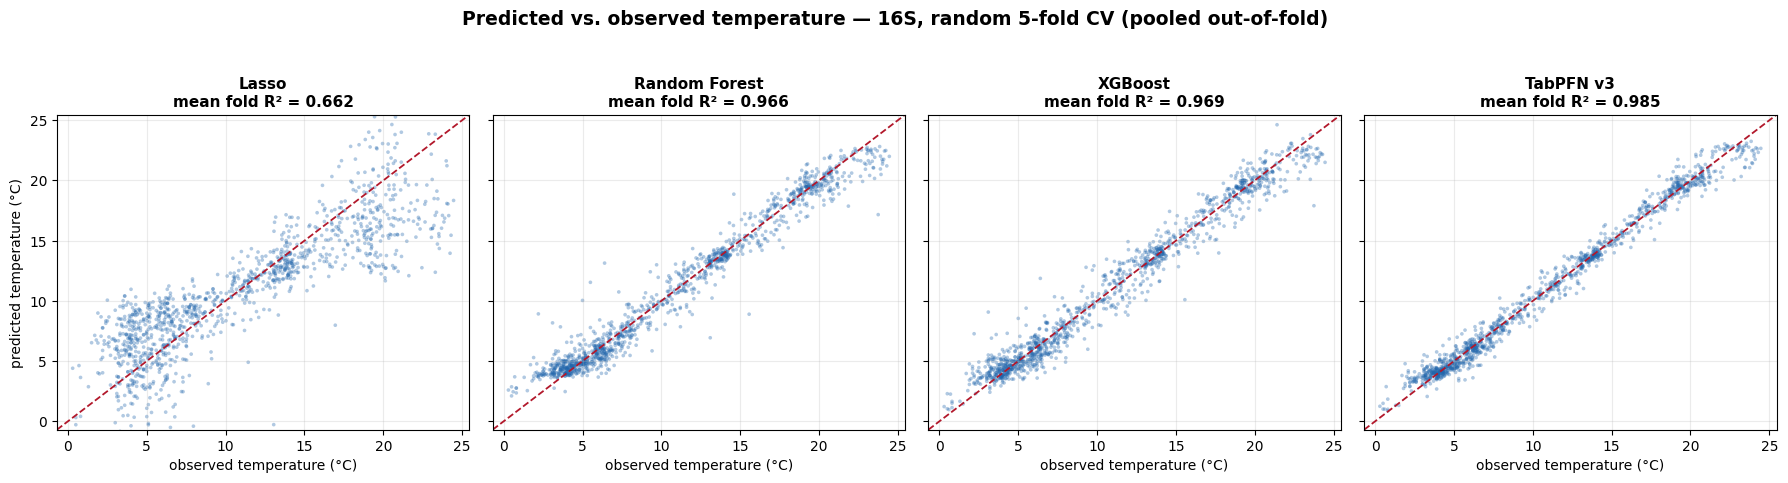

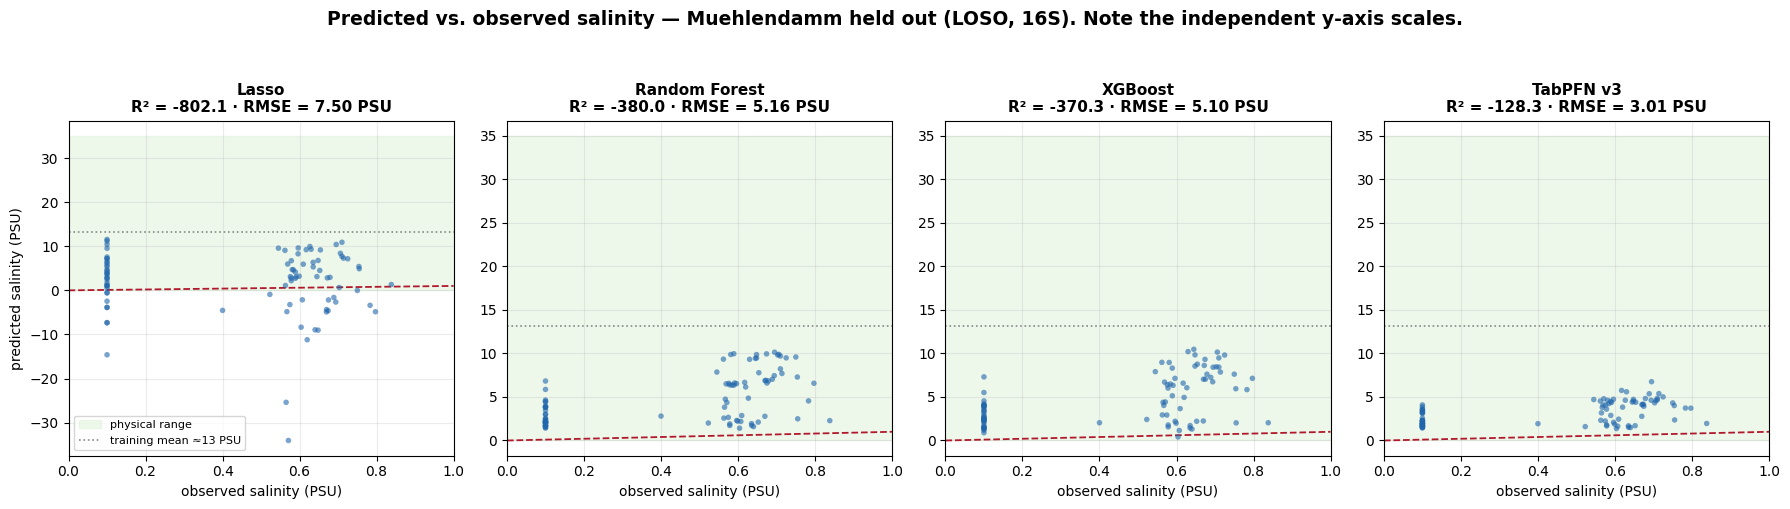


=== total_time (s) summed over the 36-cell grid, per model ===
  Lasso      7.70 h  (    27731 s)   cells missing timing: 9
  RF        16.10 h  (    57955 s)   cells missing timing: 0
  XGBoost    4.00 h  (    14395 s)   cells missing timing: 0
  TabPFN     0.17 h  (      610 s)   cells missing timing: 0

saved figures -> ch6_fig64_*.pdf, ch6_fig65_*.pdf


In [8]:
# ── CELL 13: build Figures 6.4 & 6.5 from ch6_predictions.csv + runtime table ──
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from pathlib import Path

RESULTS = Path('../results')
pr = pd.read_csv(RESULTS / 'ch6_predictions.csv')
pf = pd.read_csv(RESULTS / 'ch6_perfold_metrics.csv')
ORDER = ['Lasso', 'RF', 'XGBoost', 'TabPFN']
TITLE = {'Lasso': 'Lasso', 'RF': 'Random Forest', 'XGBoost': 'XGBoost', 'TabPFN': 'TabPFN v3'}

# ---------- Figure 6.4: temperature x 16S x random 5-fold ----------
d = pr[(pr.target == 'temperature') & (pr.strategy == 'random_kfold')]
fig, axes = plt.subplots(1, 4, figsize=(18, 4.6), sharex=True, sharey=True)
lo, hi = d.y_true.min() - 1, d.y_true.max() + 1
for ax, m in zip(axes, ORDER):
    s = d[d.model == m]
    r2 = pf[(pf.target == 'temperature') & (pf.strategy == 'random_kfold') &
            (pf.model == m)]['r2'].mean()
    ax.scatter(s.y_true, s.y_pred, s=7, alpha=.35, color='#2166ac', edgecolors='none')
    ax.plot([lo, hi], [lo, hi], '--', color='#b2182b', lw=1.3)
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ax.set_title(f'{TITLE[m]}\nmean fold R² = {r2:.3f}', fontweight='bold', fontsize=11)
    ax.set_xlabel('observed temperature (°C)')
    ax.grid(alpha=.25)
axes[0].set_ylabel('predicted temperature (°C)')
fig.suptitle('Predicted vs. observed temperature — 16S, random 5-fold CV (pooled out-of-fold)',
             fontweight='bold', fontsize=13.5, y=1.04)
fig.tight_layout()
for ext in ['png', 'pdf']:
    fig.savefig(RESULTS / f'ch6_fig64_pred_vs_true_temperature_16S_random.{ext}',
                dpi=300, bbox_inches='tight')
plt.show()

# ---------- Figure 6.5: salinity LOSO, Muehlendamm fold (independent y-axes) ----------
d = pr[(pr.target == 'salinity') & (pr.strategy == 'leave_one_site_out') &
       (pr.site.str.contains('uehlendamm', case=False, na=False))]
fig, axes = plt.subplots(1, 4, figsize=(18, 4.8))
for ax, m in zip(axes, ORDER):
    s = d[d.model == m]
    row = pf[(pf.target == 'salinity') & (pf.strategy == 'leave_one_site_out') &
             (pf.model == m) & (pf.site.str.contains('uehlendamm', case=False, na=False))].iloc[0]
    ax.axhspan(0, 35, color='#d9f0d3', alpha=.45, zorder=0, label='physical range')
    ax.axhline(13.2, color='#888888', ls=':', lw=1.2, zorder=1, label='training mean ≈13 PSU')
    ax.scatter(s.y_true, s.y_pred, s=16, alpha=.6, color='#2166ac',
               edgecolors='none', zorder=3)
    ax.plot([0, 1], [0, 1], '--', color='#b2182b', lw=1.3, zorder=2)
    ax.set_xlim(0, 1)
    ax.set_title(f'{TITLE[m]}\nR² = {row.r2:.1f} · RMSE = {row.rmse:.2f} PSU',
                 fontweight='bold', fontsize=11)
    ax.set_xlabel('observed salinity (PSU)')
    ax.grid(alpha=.25)
axes[0].set_ylabel('predicted salinity (PSU)')
axes[0].legend(fontsize=8, loc='lower left')
fig.suptitle('Predicted vs. observed salinity — Muehlendamm held out (LOSO, 16S). '
             'Note the independent y-axis scales.', fontweight='bold', fontsize=13.5, y=1.05)
fig.tight_layout()
for ext in ['png', 'pdf']:
    fig.savefig(RESULTS / f'ch6_fig65_pred_vs_true_salinity_muehlendamm.{ext}',
                dpi=300, bbox_inches='tight')
plt.show()

# ---------- runtime comparison over the full 36-cell grid ----------
print('\n=== total_time (s) summed over the 36-cell grid, per model ===')
files = {'Lasso': 'phase1_lasso_3targets_3inputs_4strategies.csv',
         'RF': 'phase1_random_forest_3targets_3inputs_4strategies.csv',
         'XGBoost': 'phase1_xgboost_3targets_3inputs_4strategies.csv',
         'TabPFN': 'phase1_tabpfn_v3_3targets_3inputs_4strategies.csv'}
for m, f in files.items():
    d = pd.read_csv(RESULTS / f)
    tot = d['total_time'].sum(skipna=True)
    n_na = d['total_time'].isna().sum()
    print(f'  {m:8s} {tot/3600:6.2f} h  ({tot:9.0f} s)   cells missing timing: {n_na}')
print('\nsaved figures -> ch6_fig64_*.pdf, ch6_fig65_*.pdf')

In [9]:
# ── CELL 14: final claims — pairwise comparisons and quoted ranges ──────────
import pandas as pd
from pathlib import Path

RESULTS = Path('../results')
long = pd.read_csv(RESULTS / 'ch6_verify_long_metrics.csv')
w = long.pivot_table(index=['target', 'input', 'strategy'],
                     columns='model', values='r2_mean')

print('=== (1) TabPFN vs each baseline, pairwise over 36 cells ===')
for b in ['Lasso', 'RF', 'XGBoost']:
    d = w['TabPFN'] - w[b]
    print(f'  vs {b:8s}: TabPFN higher in {(d>0).sum():2d}/36 · '
          f'mean Δ={d.mean():+9.3f} · median Δ={d.median():+.4f}')

print('\n=== (2) RF vs XGBoost pairwise (claim: 14 XGB / 5 RF / 17 tie) ===')
d = w['XGBoost'] - w['RF']
print(f'  XGBoost higher: {(d > 0.005).sum()} · RF higher: {(d < -0.005).sum()} · '
      f'|Δ|<=0.005 (tie): {(d.abs() <= 0.005).sum()}')
both_pos = w[(w['RF'] > 0) & (w['XGBoost'] > 0)]
print(f'  cells where both positive: {len(both_pos)}/36 · '
      f'mean Δ there = {(both_pos["XGBoost"]-both_pos["RF"]).mean():+.4f}')

print('\n=== (3) Lasso failure ranges quoted in the text ===')
las = long[long.model == 'Lasso']
for tgt, strats, label in [
        ('temperature', ['temporal_holdout', 'temporal_blocked_kfold'], 'temperature × temporal'),
        ('salinity', ['leave_one_site_out'], 'salinity × LOSO'),
        ('Chl_a_log1p', ['temporal_blocked_kfold'], 'Chl_a × blocked')]:
    s = las[(las.target == tgt) & (las.strategy.isin(strats))]['r2_mean']
    print(f'  {label:24s}: min={s.min():10.2f}  max={s.max():10.2f}')

print('\n=== (4) TabPFN worst R2 anywhere except salinity-LOSO ===')
t = long[(long.model == 'TabPFN') &
         ~((long.target == 'salinity') & (long.strategy == 'leave_one_site_out'))]
print(t.nsmallest(4, 'r2_mean')[['target', 'input', 'strategy', 'r2_mean']].to_string(index=False))

print('\n=== (5) Chl_a LOSO — does the text claim "8 of 14 sites" hold? ===')
rs = pd.read_csv(RESULTS / 'phase1_lasso_loso_robust_stats.csv')
print(rs[rs.target.str.contains('Chl')][
    ['target', 'input', 'r2_median_all', 'n_sites_r2_negative']].to_string(index=False))
print('  NOTE: this file contains Lasso only — the claim must be attributed to Lasso.')

=== (1) TabPFN vs each baseline, pairwise over 36 cells ===
  vs Lasso   : TabPFN higher in 36/36 · mean Δ= +118.469 · median Δ=+2.3925
  vs RF      : TabPFN higher in 36/36 · mean Δ=   +1.790 · median Δ=+0.0367
  vs XGBoost : TabPFN higher in 34/36 · mean Δ=   +1.332 · median Δ=+0.0326

=== (2) RF vs XGBoost pairwise (claim: 14 XGB / 5 RF / 17 tie) ===
  XGBoost higher: 20 · RF higher: 7 · |Δ|<=0.005 (tie): 9
  cells where both positive: 30/36 · mean Δ there = +0.0051

=== (3) Lasso failure ranges quoted in the text ===
  temperature × temporal  : min=   -400.44  max=    -16.32
  salinity × LOSO         : min=  -1728.62  max=    -44.41
  Chl_a × blocked         : min=    -55.53  max=     -6.72

=== (4) TabPFN worst R2 anywhere except salinity-LOSO ===
     target   input               strategy  r2_mean
Chl_a_log1p     16S     leave_one_site_out   0.3998
Chl_a_log1p     18S     leave_one_site_out   0.4144
Chl_a_log1p 16S+18S     leave_one_site_out   0.4238
temperature     16S temporal_

In [ ]:
# Discovery cell — locate the actual paths.
from pathlib import Path

ROOT = Path('/mnt/data/home/tv2414/tabpfn_project')

print('=== top-level of project root ===')
for p in sorted(ROOT.iterdir()):
    print('  ', 'DIR ' if p.is_dir() else 'FILE', p.name)

print('\n=== every otus_*.csv anywhere under root ===')
for p in sorted(ROOT.rglob('otus_*.csv')):
    print('  ', p)

print('\n=== every emb_*.npz anywhere under root ===')
for p in sorted(ROOT.rglob('emb_*.npz')):
    print('  ', p)

print('\n=== phase2 result CSVs ===')
for p in sorted(ROOT.rglob('phase2*.csv')):
    print('  ', p)

=== top-level of project root ===
   DIR  .git
   FILE .gitignore
   FILE README.md
   FILE _all_nb.py
   FILE _dumpall.py
   FILE conda_v26_freeze.txt
   DIR  data
   FILE env_v26_freeze.txt
   FILE environment.yml
   DIR  notebooks
   DIR  old_scripts
   DIR  results
   DIR  resultscd
   DIR  src

=== every otus_*.csv anywhere under root ===
   /mnt/data/home/tv2414/tabpfn_project/data/otus_16s_filtered.csv
   /mnt/data/home/tv2414/tabpfn_project/data/otus_16s_full.csv
   /mnt/data/home/tv2414/tabpfn_project/data/otus_18s_filtered.csv
   /mnt/data/home/tv2414/tabpfn_project/data/otus_18s_full.csv

=== every emb_*.npz anywhere under root ===
   /mnt/data/home/tv2414/tabpfn_project/results/embeddings/emb_Chl_a_log1p_16S.npz
   /mnt/data/home/tv2414/tabpfn_project/results/embeddings/emb_Chl_a_log1p_16S_18S.npz
   /mnt/data/home/tv2414/tabpfn_project/results/embeddings/emb_Chl_a_log1p_18S.npz
   /mnt/data/home/tv2414/tabpfn_project/results/embeddings/emb_salinity_16S.npz
   /mnt/data/hom

In [ ]:
# Chapter 7 fill-in numbers — corrected paths.
# (1) PCA explained variance: raw ASV vs embedding
# (2) broad search for any ablation output
import numpy as np, pandas as pd
from pathlib import Path
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

ROOT    = Path('/mnt/data/home/tv2414/tabpfn_project')
DATA    = ROOT / 'data'
RESULTS = ROOT / 'results'
EMB     = RESULTS / 'embeddings'

# ---------- (1) PCA explained variance ----------
otu16 = pd.read_csv(DATA / 'otus_16s_filtered.csv', index_col=0)
print('raw 16S shape:', otu16.shape)

E = np.load(EMB / 'emb_temperature_16S.npz')
print('npz keys:', list(E.keys()))
emb = E[list(E.keys())[0]]
print('embedding shape:', emb.shape)

# align sample count if the two differ (embedding is the reference)
if otu16.shape[0] != emb.shape[0]:
    print(f'!! row mismatch: raw={otu16.shape[0]} emb={emb.shape[0]} '
          f'-- check orientation of the OTU table')

def evr(X, label):
    Z = StandardScaler().fit_transform(X)
    p = PCA(n_components=2, random_state=42).fit(Z)
    r = p.explained_variance_ratio_ * 100
    print(f'{label:12s}: PC1 = {r[0]:5.1f}%   PC2 = {r[1]:5.1f}%   '
          f'(PC1+PC2 = {r.sum():5.1f}%)')
    return r

print('\n--- PCA explained variance (temperature-conditioned, 16S) ---')
evr(otu16.values, 'raw ASV')
evr(emb,          'embedding')

# ---------- (2) hunt for ablation results anywhere ----------
print('\n--- searching for ablation outputs across the whole project ---')
hits = set()
for pat in ['*abl*', '*inner*', '*sensitiv*', '*oof*', '*fold_count*', '*nfold*']:
    for p in ROOT.rglob(pat):
        if p.is_file() and p.suffix in {'.csv', '.png', '.pdf', '.json'}:
            hits.add(p)
if hits:
    for p in sorted(hits):
        print('  ', p)
else:
    print('   (nothing found)')

# what columns does the main quant file actually have?
df = pd.read_csv(RESULTS / 'phase2_downstream_emb_vs_raw.csv')
print('\n--- phase2_downstream_emb_vs_raw.csv ---')
print('shape:', df.shape)
print('columns:', list(df.columns))
for c in df.columns:
    if df[c].dtype == object and df[c].nunique() <= 12:
        print(f'  {c}: {sorted(df[c].unique())}')

raw 16S shape: (1602, 1236)
npz keys: ['emb', 'index']
embedding shape: (1223, 512)
!! row mismatch: raw=1602 emb=1223 -- check orientation of the OTU table

--- PCA explained variance (temperature-conditioned, 16S) ---
raw ASV     : PC1 =   9.4%   PC2 =   5.4%   (PC1+PC2 =  14.9%)
embedding   : PC1 =  27.2%   PC2 =  20.4%   (PC1+PC2 =  47.6%)

--- searching for ablation outputs across the whole project ---
   /mnt/data/home/tv2414/tabpfn_project/results/chapter8_master_forecasting_table.csv
   /mnt/data/home/tv2414/tabpfn_project/results/chapter8_master_table_styled.png
   /mnt/data/home/tv2414/tabpfn_project/results/chapter8_master_table_styled_v2.png
   /mnt/data/home/tv2414/tabpfn_project/results/phase1_final_comparison_table_v3.csv
   /mnt/data/home/tv2414/tabpfn_project/results/phase1_final_comparison_table_v3.pdf
   /mnt/data/home/tv2414/tabpfn_project/results/phase1_final_comparison_table_v3.png
   /mnt/data/home/tv2414/tabpfn_project/results/phase1_winner_grid.pdf
   /mnt/data

In [ ]:
# Aligned PCA — raw ASV restricted to the exact samples
# present in the embedding, so both projections use the
# same n and the same samples.
import numpy as np, pandas as pd
from pathlib import Path
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

ROOT = Path('/mnt/data/home/tv2414/tabpfn_project')
E = np.load(ROOT / 'results/embeddings/emb_temperature_16S.npz', allow_pickle=True)
emb, idx = E['emb'], E['index']
print('emb:', emb.shape, '| index dtype:', idx.dtype, '| first 3:', idx[:3])

otu16 = pd.read_csv(ROOT / 'data/otus_16s_filtered.csv', index_col=0)
print('raw index first 3:', list(otu16.index[:3]))

# try aligning by label; fall back to positional if index is integer positions
try:
    raw_aligned = otu16.loc[idx]
    mode = 'label-based'
except KeyError:
    raw_aligned = otu16.iloc[idx.astype(int)]
    mode = 'positional'
print(f'alignment: {mode} -> raw_aligned {raw_aligned.shape}')
assert raw_aligned.shape[0] == emb.shape[0], 'alignment failed'

def evr(X, label):
    p = PCA(n_components=2, random_state=42).fit(StandardScaler().fit_transform(X))
    r = p.explained_variance_ratio_ * 100
    print(f'{label:16s} PC1 = {r[0]:5.1f}%  PC2 = {r[1]:5.1f}%  sum = {r.sum():5.1f}%')

print('\n--- ALIGNED PCA (temperature-conditioned, 16S, n=%d) ---' % emb.shape[0])
evr(raw_aligned.values, 'raw ASV')
evr(emb,                'embedding')

emb: (1223, 512) | index dtype: object | first 3: ['s02M0123' 's02M0223' 's02M0323']
raw index first 3: ['s02T1622', 's03T1622', 's04T1622']
alignment: label-based -> raw_aligned (1223, 1236)

--- ALIGNED PCA (temperature-conditioned, 16S, n=1223) ---
raw ASV          PC1 =  10.1%  PC2 =   5.7%  sum =  15.8%
embedding        PC1 =  27.2%  PC2 =  20.4%  sum =  47.6%


In [ ]:
# Section 7.6 (option B) — sensitivity analyses that the
# existing data actually supports.
#   (i)  input invariance: 16S vs 18S vs 16S+18S
#   (ii) fold-level stability of the embedding advantage
#   (iii) win-rate at fold level (the "98%" claim)

import pandas as pd
from pathlib import Path

RESULTS = Path('/mnt/data/home/tv2414/tabpfn_project/results')
df = pd.read_csv(RESULTS / 'phase2_downstream_emb_vs_raw.csv')
print('features values:', sorted(df.features.unique()))
print('models        :', sorted(df.model.unique()))
print('strategies    :', sorted(df.strategy.unique()))

d = df[df.model.str.lower().str.contains('ridge')]

# (i) input invariance — median R2 per input, embedding only
print('\n--- (i) input invariance (embedding, Ridge, median R2) ---')
emb = d[d.features.str.lower().str.contains('emb')]
print(emb.pivot_table(index='input', columns='strategy',
                      values='r2', aggfunc='median').round(3))

# (ii) fold-level spread of the embedding advantage
key = ['target', 'input', 'strategy', 'fold']
raw = d[~d.features.str.lower().str.contains('emb')]
m = emb.merge(raw, on=key, suffixes=('_emb', '_raw'))
m['delta'] = m.r2_emb - m.r2_raw
print('\n--- (ii) per-fold delta (emb - raw) by strategy ---')
print(m.groupby('strategy').delta.describe()[['count','min','50%','max']].round(3))

# (iii) fold-level win rate
print('\n--- (iii) fold-level win rate ---')
print(f'embedding wins {(m.delta > 0).sum()} / {len(m)} folds '
      f'= {(m.delta > 0).mean()*100:.1f}%')
print(m.groupby('strategy').apply(
    lambda g: pd.Series({'wins': (g.delta > 0).sum(), 'n': len(g),
                         'pct': round((g.delta > 0).mean()*100, 1)})))

features values: ['embedding', 'raw']
models        : ['knn', 'ridge']
strategies    : ['leave_one_site_out', 'random_kfold', 'temporal_blocked_kfold', 'temporal_holdout']

--- (i) input invariance (embedding, Ridge, median R2) ---
strategy  leave_one_site_out  random_kfold  temporal_blocked_kfold  \
input                                                                
16S                    0.945         0.968                   0.708   
16S+18S                0.946         0.970                   0.756   
18S                    0.905         0.954                   0.748   

strategy  temporal_holdout  
input                       
16S                  0.813  
16S+18S              0.852  
18S                  0.845  

--- (ii) per-fold delta (emb - raw) by strategy ---
                        count    min     50%         max
strategy                                                
leave_one_site_out      126.0  0.022   0.348   28062.169
random_kfold             45.0  0.035   0.151    

In [2]:
# ── continuation: markdown + Phase 3 + salinity checks (no tabulate) ─────
def to_md(df):
    cols = list(df.columns)
    head = "| " + " | ".join(cols) + " |"
    sep  = "| " + " | ".join(["---:" if i else "---" for i, _ in enumerate(cols)]) + " |"
    body = ["| " + " | ".join(str(v) for v in row) + " |"
            for row in df.itertuples(index=False)]
    return "\n".join([head, sep] + body)

print("--- markdown (paste-ready) ---")
print(to_md(tbl))

print("\n--- Phase 3 non-zero counts (text of Section 4.6) ---")
for name, X in INPUTS.items():
    ids = meta.index.intersection(X.index).intersection(hplc_z.index)
    out = []
    for c in GRADIENT:
        s  = hplc_z.loc[ids, c]
        n  = int(s.notna().sum()); nz = int((s.dropna() > 0).sum())
        out.append(f"{c} {nz}/{n} ({100*nz/n:.1f}%)")
    print(f"  {name:9s} " + " | ".join(out))

m  = meta.loc[keep_ids]
mu = m[m['location_name'] == 'Muehlendamm']['salinity'].dropna()
others = (m[m['location_name'] != 'Muehlendamm']
            .groupby('location_name')['salinity'].mean())
print("\n--- Section 4.5 salinity claims ---")
print(f"  Muehlendamm: {mu.mean():.2f} ± {mu.std():.2f} PSU, n={len(mu)}")
print(f"  Other 13 sites, mean site salinity: "
      f"{others.min():.2f} – {others.max():.2f} PSU  (n_sites={len(others)})")
print(f"  Sites in modelling set: {m['location_name'].nunique()}")

--- markdown (paste-ready) ---
| Input | Base samples | Features | Zero entries | Temp. | Salinity | Chl a | Caffeine | Metoprolol | Atrazine |
| --- | ---: | ---: | ---: | ---: | ---: | ---: | ---: | ---: | ---: |
| 16S | 1551 | 1236 | 56.5% | 1226 | 1220 | 1446 | 1294 | 1296 | 1292 |
| 18S | 1546 | 1054 | 74.1% | 1227 | 1221 | 1445 | 1293 | 1295 | 1291 |
| 16S+18S | 1538 | 2290 | 64.6% | 1223 | 1217 | 1437 | 1291 | 1293 | 1289 |

--- Phase 3 non-zero counts (text of Section 4.6) ---
  16S       Caffeine 1294/1294 (100.0%) | Metoprolol 387/1296 (29.9%) | Atrazine 57/1292 (4.4%)
  18S       Caffeine 1293/1293 (100.0%) | Metoprolol 388/1295 (30.0%) | Atrazine 57/1291 (4.4%)
  16S+18S   Caffeine 1291/1291 (100.0%) | Metoprolol 387/1293 (29.9%) | Atrazine 57/1289 (4.4%)

--- Section 4.5 salinity claims ---
  Muehlendamm: 0.45 ± 0.27 PSU, n=90
  Other 13 sites, mean site salinity: 8.98 – 14.85 PSU  (n_sites=13)
  Sites in modelling set: 14


In [3]:
import pandas as pd
meta = pd.read_csv("../data/combined_meta_data.csv", index_col=0)
c = meta['Chl_a'].dropna()
print(f"n={len(c)}  min={c.min():.4f}  n_zero={(c==0).sum()}  n_neg={(c<0).sum()}")

n=1461  min=-0.1490  n_zero=0  n_neg=1


In [4]:
chl = meta.loc[meta["Chl_a"].notna(), ["Chl_a"]]

print(chl.nsmallest(10, "Chl_a"))

             Chl_a
s10T1922 -0.149015
s06M2622  0.004967
s15T1223  0.019788
s06T1822  0.044705
s13T3822  0.049672
s04M0723  0.055632
s04T0323  0.079475
s06M2522  0.084442
s02M0223  0.094376
s02M3422  0.099344


In [5]:
neg = meta[meta["Chl_a"] < 0]

print(neg)

          location_id day_id  cw_id  year_id      location_name  \
s10T1922           10      T     19       22  SAB Marina Bramow   

                                  rough_lat_long        date   PO4   NOx  \
s10T1922  [54.11056226317913, 12.09354886530469]  2022-05-12  0.09  7.64   

           NH4  ...  NO3  temperature   salinity     Chl_a      Phaeo  \
s10T1922  0.77  ...  7.4    13.322912  12.954542 -0.149015  21.885394   

          Chl_a_conc     f0     fa  volume      time  
s10T1922   11.265084  474.0  477.0   500.0  11:13:03  

[1 rows x 21 columns]


In [6]:
import subprocess
out = subprocess.run(
    "grep -rn 'log1p\\|Chl_a' ../src/*.py ../notebooks/*.ipynb | grep -i 'clip\\|log1p' | head -20",
    shell=True, capture_output=True, text=True, executable="/bin/bash")
print(out.stdout or "no match")

../src/lasso_evaluator.py:34:        If log_target=True, the *raw* column name is passed and log1p is applied
../src/lasso_evaluator.py:36:        'Chl_a_log1p' and leave log_target=False.
../src/lasso_evaluator.py:50:        Apply np.log1p to the target before fitting. Metrics are reported
../src/lasso_evaluator.py:64:        y = np.log1p(y)
../src/lasso_evaluator.py:67:    target_label = target_name + (" (log1p)" if log_target else "")
../src/random_forest_evaluator.py:68:        Column name in `meta` to predict (e.g. 'temperature', 'Chl_a_log1p').
../src/random_forest_evaluator.py:82:        Apply np.log1p to the target before fitting. Metrics are then on
../src/random_forest_evaluator.py:93:    target_label = f"{target_name}{' (log1p)' if log_target else ''}"
../src/random_forest_evaluator.py:97:    y_all = np.log1p(y_raw) if log_target else y_raw
../src/tabpfn_evaluator.py:94:        Column name in `meta` (e.g. 'temperature', 'Chl_a_log1p').
../src/tabpfn_evaluator.py:108:        

In [7]:
import json
nb = json.load(open('../notebooks/02_preprocessing.ipynb'))
for c in nb['cells']:
    src = ''.join(c['source'])
    if 'clip' in src and 'Chl_a' in src:
        print(src)

# --- Apply Decision 4: Clip negative Chl_a to 0, then apply log1p ---
#
# The raw Chl_a column contains 101 missing values and some negative values
# (min = -0.149), which is physically impossible for a concentration.
# These follow the same pattern as NH4: measurement near the detection limit
# plus post-measurement calibration → small artefactual negatives.
# Applying the same logic Dr. Sperlea confirmed for NH4: clip to 0.
# This decision will be reported to Prof. Lüdtke in the next supervision meeting.
#
# Then apply log1p, per Prof. Lüdtke's approval in the May 2026 meeting
# (only Chl_a is log-transformed for now; nutrients await empirical evidence).

# --- Step 4a: clip negative Chl_a to 0 (in place) ---
chla_neg_count = (meta['Chl_a'] < 0).sum()
chla_min_before = meta['Chl_a'].min()
meta['Chl_a'] = meta['Chl_a'].clip(lower=0)

print(f"Chl_a — clipping negative values:")
print(f"  Negative values clipped to 0:  {chla_neg_count}")
print(f"  Min before:                    {chla_m

In [1]:
# === VERIFY §5.2 — every number and string against src/ ===
import re, inspect, sys
from pathlib import Path
ROOT = Path('/mnt/data/home/tv2414/tabpfn_project'); sys.path.insert(0, str(ROOT))

for f in ['lasso_evaluator.py', 'random_forest_evaluator.py',
          'xgboost_evaluator.py', 'tabpfn_evaluator.py']:
    p = ROOT / 'src' / f
    if not p.exists():
        print(f'!! {f} NOT FOUND'); continue
    txt = p.read_text()
    print('=' * 68); print(f)
    print('=' * 68)
    # full estimator instantiations
    for m in re.finditer(
        r'(LassoCV|RandomForestRegressor|XGBRegressor|TabPFNRegressor|GridSearchCV)\s*\((?:[^()]|\([^()]*\))*\)', txt):
        print(m.group(0)); print('-' * 40)
    # param grids in full
    for m in re.finditer(r'((?:PARAM_GRID|param_grid|GRID)\s*=\s*\{[^}]*\})', txt):
        print(m.group(1)); print('-' * 40)
    # scaler / pipeline
    for l in txt.splitlines():
        if re.search(r'StandardScaler|Pipeline|make_pipeline|\bcv\s*=|n_jobs|random_state|RANDOM_SEED\s*=', l):
            print('   ', l.strip()[:110])

lasso_evaluator.py
LassoCV (controls only the inner-CV alpha selection)
----------------------------------------
LassoCV(cv=5,
                               random_state=random_seed,
                               max_iter=10_000,
                               n_jobs=-1)
----------------------------------------
    from sklearn.preprocessing import StandardScaler
    from sklearn.pipeline import Pipeline
    Run a (StandardScaler -> LassoCV) pipeline using a pre-computed list of splits.
    pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso',  LassoCV(cv=5,
    random_state=random_seed,
    n_jobs=-1)),
random_forest_evaluator.py
GridSearchCV(cv=5)
----------------------------------------
RandomForestRegressor(
        random_state=random_seed,
        n_jobs=-1,
        bootstrap=True,
    )
----------------------------------------
GridSearchCV(
            estimator=_make_rf(random_seed),
            param_grid=RF_PARAM_GRID,
            cv=5,
            scoring='r2',

In [2]:
import sys, numpy as np, pandas as pd
from pathlib import Path
ROOT = Path('/mnt/data/home/tv2414/tabpfn_project'); sys.path.insert(0, str(ROOT))
from src.cv_strategies import temporal_blocked_kfold

meta = pd.read_csv(ROOT/'data'/'combined_meta_data.csv').rename(columns={'Unnamed: 0':'sample_id'})
meta['date'] = pd.to_datetime(meta['date'])
o16 = pd.read_csv(ROOT/'data'/'otus_16s_filtered.csv', index_col=0)
hd  = set(meta.loc[meta.location_name.str.contains('Heiligendamm', case=False), 'sample_id'])
sub = (meta[meta.sample_id.isin(set(o16.index)-hd) & meta['temperature'].notna()]
         .sort_values('date').reset_index(drop=True))
d = pd.to_datetime(sub['date'])
for i, (tr, te) in enumerate(temporal_blocked_kfold(sub, n_folds=5, date_col='date'), 1):
    dd = d.iloc[np.asarray(te)]
    days = (dd.max()-dd.min()).days
    print(f'block {i}: n={len(te):4d}  {dd.min():%d %b %Y} .. {dd.max():%d %b %Y}  '
          f'span={days:3d} days ({days/30.44:.1f} months)')

block 1: n= 246  25 Apr 2022 .. 11 Aug 2022  span=108 days (3.5 months)
block 2: n= 245  11 Aug 2022 .. 17 Oct 2022  span= 67 days (2.2 months)
block 3: n= 245  17 Oct 2022 .. 26 Dec 2022  span= 70 days (2.3 months)
block 4: n= 245  26 Dec 2022 .. 23 Feb 2023  span= 59 days (1.9 months)
block 5: n= 245  23 Feb 2023 .. 27 Apr 2023  span= 63 days (2.1 months)


In [3]:
import sys, numpy as np, pandas as pd
from pathlib import Path
ROOT = Path('/mnt/data/home/tv2414/tabpfn_project'); sys.path.insert(0, str(ROOT))
from src.cv_strategies import temporal_blocked_kfold

meta = pd.read_csv(ROOT/'data'/'combined_meta_data.csv').rename(columns={'Unnamed: 0':'sample_id'})
meta['date'] = pd.to_datetime(meta['date'])
o16 = pd.read_csv(ROOT/'data'/'otus_16s_filtered.csv', index_col=0)
hd  = set(meta.loc[meta.location_name.str.contains('Heiligendamm', case=False), 'sample_id'])
master = meta[meta.sample_id.isin(set(o16.index) - hd)]

for tgt in ['temperature', 'salinity', 'Chl_a']:
    sub = master[master[tgt].notna()].sort_values('date').reset_index(drop=True)
    d = pd.to_datetime(sub['date'])
    sizes, shared, spans = [], [], []
    for tr, te in temporal_blocked_kfold(sub, n_folds=5, date_col='date'):
        te = np.asarray(te); tr = np.asarray(tr)
        td, rd = set(d.iloc[te].dt.date), set(d.iloc[tr].dt.date)
        sizes.append(len(te)); shared.append(len(td & rd))
        spans.append((d.iloc[te].max()-d.iloc[te].min()).days)
    print(f'{tgt:12s} n={len(sub):4d} sizes={sizes} shared={shared} spans={spans}')

temperature  n=1226 sizes=[246, 245, 245, 245, 245] shared=[1, 2, 2, 2, 1] spans=[108, 67, 70, 59, 63]
salinity     n=1220 sizes=[244, 244, 244, 244, 244] shared=[0, 1, 2, 2, 1] spans=[105, 67, 70, 59, 63]
Chl_a        n=1446 sizes=[290, 289, 289, 289, 289] shared=[1, 2, 2, 2, 1] spans=[74, 73, 88, 77, 77]


In [6]:
import json, re
from pathlib import Path
ROOT = Path('/mnt/data/home/tv2414/tabpfn_project')

def flat(x):
    if x is None: return ''
    if isinstance(x, str): return x
    if isinstance(x, list): return ''.join(flat(i) for i in x)
    return str(x)

def out_text(out):
    parts = [flat(out.get('text'))]
    d = out.get('data')
    if isinstance(d, dict):
        parts.append(flat(d.get('text/plain')))
    parts.append(flat(out.get('ename'))); parts.append(flat(out.get('evalue')))
    return ''.join(parts)

PAT = re.compile(r'978|shuffl|permut|0\.984|-0\.049|leak', re.I)

for p in sorted(ROOT.glob('notebooks/*.ipynb')):
    if '.ipynb_checkpoints' in str(p): continue
    try: nb = json.loads(p.read_text(errors='ignore'))
    except Exception: continue
    for i, c in enumerate(nb.get('cells', [])):
        src = flat(c.get('source'))
        outs = ''.join(out_text(o) for o in c.get('outputs', []))
        if PAT.search(src) or PAT.search(outs):
            print(f'\n{"="*68}\n{p.name}  ·  cell {i}\n{"="*68}')
            if PAT.search(src):
                print('--- SOURCE ---')
                print(src[:1100])
            if PAT.search(outs):
                print('--- OUTPUT ---')
                print(outs[:900])


02_first_baseline.ipynb  ·  cell 11
--- SOURCE ---
# Split data into training (80%) and test (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_SEED,
    shuffle=True
)

# Sanity checks
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")

print(f"\nTrain target statistics:")
print(f"  mean: {y_train.mean():.2f}, std: {y_train.std():.2f}")
print(f"  min:  {y_train.min():.2f}, max: {y_train.max():.2f}")

print(f"\nTest target statistics:")
print(f"  mean: {y_test.mean():.2f}, std: {y_test.std():.2f}")
print(f"  min:  {y_test.min():.2f}, max: {y_test.max():.2f}")

02_first_baseline.ipynb  ·  cell 17
--- SOURCE ---
## Step 8 — 5-Fold Cross-Validation (per proposal)

The 80/20 split gave us a single number (R² = 0.967). The proposal requires
**5-fold cross-validation** for proper performance estimation. This will:

1

In [ ]:
import numpy as np, pandas as pd
from pathlib import Path
ROOT = Path('/mnt/data/home/tv2414/tabpfn_project')
meta = pd.read_csv(ROOT/'data'/'processed'/'meta_clean.csv').rename(columns={'Unnamed: 0':'sample_id'})
meta['date'] = pd.to_datetime(meta['date'])
CUT, MAX_STEP = pd.Timestamp('2023-01-19'), 6
m = meta.sort_values(['location_id','date']).drop_duplicates(['location_id','date'])
for k in (1,2,3):
    tr, te, purged = [], [], 0
    for _, g in m.groupby('location_id'):
        d = g['date'].to_numpy()
        for i in range(len(d)-k):
            steps = np.diff(d[i:i+k+1]).astype('timedelta64[D]').astype(int)
            if not (steps <= MAX_STEP).all(): continue
            f, t = pd.Timestamp(d[i]), pd.Timestamp(d[i+k])
            if t < CUT: tr.append((f,t))
            elif f >= CUT: te.append((f,t))
            else: purged += 1
    print(f'k={k}: n_train={len(tr)} n_test={len(te)} purged={purged} | '
          f'max train target={max(t for _,t in tr).date()} | '
          f'min test feature={min(f for f,_ in te).date()}')

k=1: n_train=1058 n_test=429 purged=14 | max train target=2023-01-16 | min test feature=2023-01-19
k=2: n_train=1034 n_test=406 purged=28 | max train target=2023-01-16 | min test feature=2023-01-19
k=3: n_train=1010 n_test=386 purged=42 | max train target=2023-01-16 | min test feature=2023-01-19


In [8]:
print(m['date'].nunique(), m['date'].min().date(), m['date'].max().date())

112 2022-04-21 2023-05-15


In [10]:
# === VERIFY §5.6.2 — baselines, shared mask, skill definition ===
import json, re
from pathlib import Path
ROOT = Path('/mnt/data/home/tv2414/tabpfn_project')

# 1. how are the three baselines actually computed?
print('='*70); print('1. BASELINE IMPLEMENTATIONS'); print('='*70)
for name in ['14_tabpfn_hplc.ipynb', '14_phase3_hplc.ipynb']:
    p = ROOT/'notebooks'/name
    if not p.exists(): continue
    for i, c in enumerate(json.loads(p.read_text(errors='ignore'))['cells']):
        s = ''.join(c.get('source', []))
        if re.search(r'site_mean|site-mean|global_mean|persist', s, re.I):
            hits = [l for l in s.splitlines()
                    if re.search(r'site_mean|global_mean|persist|y_now|skill|best_baseline|0\.03', l, re.I)]
            if hits:
                print(f'\n--- {name} cell {i} ---')
                for h in dict.fromkeys(hits)[:25] if False else list(dict.fromkeys(hits))[:25]:
                    print('   ', h.strip()[:120])

# 2. shared-mask construction
print('\n'+'='*70); print('2. SHARED MASK'); print('='*70)
p = ROOT/'notebooks'/'14_tabpfn_hplc.ipynb'
for i, c in enumerate(json.loads(p.read_text(errors='ignore'))['cells']):
    s = ''.join(c.get('source', []))
    if 'shared_mask_frames' in s or 'need_now' in s:
        print(f'--- cell {i} ---')
        for l in s.splitlines():
            if re.search(r'need_now|notna|isfinite|ok_tr|ok_te|mask|def _mask', l):
                print('   ', l.strip()[:120])
        break

# 3. skill / 0.03 threshold and which baseline is the reference
print('\n'+'='*70); print('3. SKILL SCORE + 0.03 THRESHOLD'); print('='*70)
import pandas as pd
f = ROOT/'results'/'phase1_tabpfn_vs_modelfree_baselines.csv'
if f.exists():
    df = pd.read_csv(f)
    print('columns:', list(df.columns))
    print(df.head(12).to_string(index=False))
    print('\nbest_baseline value counts:')
    print(df['best_baseline'].value_counts().to_string())

1. BASELINE IMPLEMENTATIONS

--- 14_tabpfn_hplc.ipynb cell 2 ---
    # ---- persist predictions if available ----

--- 14_tabpfn_hplc.ipynb cell 7 ---
    y_now = meta_f.loc[f, target_col].to_numpy(dtype=float)
    ok &= np.isfinite(y_now)
    y_now_te = meta_f.loc[f_te, target_col].to_numpy(dtype=float)
    return frames, len(t_tr), len(t_te), y_now_te, y_fut_te
    def persistence_metrics(y_fut, y_now):
    m = dict(r2=np.nan, mae=mean_absolute_error(y_fut, y_now),
    rmse=np.sqrt(mean_squared_error(y_fut, y_now)), rho=np.nan)
    m['r2'] = r2_score(y_fut, y_now)
    m['rho'] = spearmanr(y_fut, y_now).correlation
    frames, n_tr, n_te, y_now_te, y_fut_te = shared_mask_frames(c, k)
    per = persistence_metrics(y_fut_te, y_now_te)
    f'persistence R²={per["r2"]:+.3f} MAE={per["mae"]:.3f} ──')

--- 14_tabpfn_hplc.ipynb cell 8 ---
    # We need site_mean / global_mean, computed on the SAME test pairs as fc1.
    frames, n_tr, n_te, y_now_te, y_fut_te = shared_mask_frames(c, k)
    # 

In [ ]:
import json, re
import pandas as pd
from pathlib import Path
ROOT = Path('/mnt/data/home/tv2414/tabpfn_project')

# 1. آیا در کد محاسبه شده؟
print('='*70); print('1. PEARSON IN NOTEBOOK CODE'); print('='*70)
for p in sorted(ROOT.glob('notebooks/*.ipynb')):
    if '.ipynb_checkpoints' in str(p): continue
    nb = json.loads(p.read_text(errors='ignore'))
    for i, c in enumerate(nb.get('cells', [])):
        src = ''.join(c.get('source', []))
        if re.search(r'pearson', src, re.I):
            hits = [l.strip() for l in src.splitlines() if re.search(r'pearson', l, re.I)]
            print(f'\n--- {p.name} cell {i} ---')
            for h in hits[:8]: print('   ', h[:120])

# 2. آیا در فایل‌های نتیجه ستون دارد؟
print('\n'+'='*70); print('2. PEARSON COLUMNS IN results/'); print('='*70)
found = False
for f in sorted((ROOT/'results').glob('*.csv')):
    try: cols = pd.read_csv(f, nrows=0).columns.tolist()
    except Exception: continue
    hits = [c for c in cols if re.search(r'pearson|\bpear|rho_p|r_p\b', str(c), re.I)]
    if hits:
        found = True
        print(f'  {f.name}: {hits}')
print('  (none)' if not found else '')

# 3. جدول autocorrelation چه ستون‌هایی دارد؟
print('\n'+'='*70); print('3. AUTOCORRELATION RESULT FILES'); print('='*70)
for f in sorted((ROOT/'results').glob('*')):
    if re.search(r'autocorr|temporal_autocorr', f.name, re.I):
        print(f'\n--- {f.name} ---')
        if f.suffix == '.csv':
            df = pd.read_csv(f)
            print('columns:', list(df.columns))
            print(df.head(8).to_string(index=False))
        else:
            print('  (non-csv file)')

1. PEARSON IN NOTEBOOK CODE

--- 09_missingness_check.ipynb cell 3 ---
    axA.text(0.995, 0.93, "temperature & salinity missing\nidentically (Pearson r = 1.00)",

--- 15_temporal_autocorrelation_all_targets.ipynb cell 0 ---
    - Both Pearson and Spearman reported; Spearman is the primary statistic for the

--- 15_temporal_autocorrelation_all_targets.ipynb cell 5 ---
    from scipy.stats import pearsonr, spearmanr
    'pearson': np.nan, 'spearman': np.nan, 'usable': False}
    rec['pearson']  = pearsonr(a, b)[0]
    pearson_med=('pearson', 'median'),
    pearson_q1=('pearson', lambda s: s.quantile(.25)),
    pearson_q3=('pearson', lambda s: s.quantile(.75)),
    print('\n=== Pearson autocorrelation · median over sites ===')
    print(summary.pivot(index='target', columns='k', values='pearson_med')

--- 15_temporal_autocorrelation_all_targets.ipynb cell 6 ---
    from scipy.stats import pearsonr, spearmanr
    phi = pearsonr(d0.astype(float), d1.astype(float))[0]
    'pearson':  pearso

In [12]:
import pandas as pd
from pathlib import Path
R = Path('/mnt/data/home/tv2414/tabpfn_project/results')
s = pd.read_csv(R/'temporal_autocorr_summary.csv')
print(sorted(s['target'].unique()))
print(s[s.k==1][['target','spearman_med','pearson_med','n_sites','n_pairs']].to_string(index=False))

['Atrazine', 'Caffeine', 'Chl_a', 'Metoprolol', 'salinity', 'temperature']
     target  spearman_med  pearson_med  n_sites  n_pairs
temperature      0.958225     0.979054       14     1103
   salinity      0.765553     0.688733       14     1091
      Chl_a      0.386637     0.182943       14     1361
   Caffeine      0.487452     0.377734       14     1185
 Metoprolol      0.430597     0.366776        9      757
   Atrazine      0.306641     0.295848        5      432


In [13]:
import pandas as pd
from pathlib import Path
R = Path('/mnt/data/home/tv2414/tabpfn_project/results')
p = pd.read_csv(R/'temporal_autocorr_per_site.csv')
print('total dropped by gap filter, per target x lag:')
print(p.groupby(['target','k'])[['n_pairs','n_dropped_gap']].sum().to_string())
print('\nrows where the filter actually removed something:',
      (p.n_dropped_gap > 0).sum(), 'of', len(p))

total dropped by gap filter, per target x lag:
               n_pairs  n_dropped_gap
target      k                        
Atrazine    1     1181             10
            2     1124             21
            3     1052             32
Caffeine    1     1185             10
            2     1128             21
            3     1056             32
Chl_a       1     1361             16
            2     1328             31
            3     1285             48
Metoprolol  1     1189             10
            2     1130             21
            3     1058             32
salinity    1     1091              6
            2     1040             12
            3      999             20
temperature 1     1103              6
            2     1046             13
            3     1010             21

rows where the filter actually removed something: 168 of 252


In [14]:
import sklearn, xgboost, tabpfn, torch, sys
print('python  ', sys.version.split()[0])
print('sklearn ', sklearn.__version__)
print('xgboost ', xgboost.__version__)
print('tabpfn  ', tabpfn.__version__)
print('torch   ', torch.__version__, '| cuda', torch.version.cuda)
import subprocess; print(subprocess.run(['nvidia-smi','--query-gpu=name,memory.total',
      '--format=csv,noheader'], capture_output=True, text=True).stdout.strip())

python   3.11.15
sklearn  1.8.0
xgboost  3.2.0
tabpfn   8.0.6
torch    2.11.0+cu128 | cuda 12.8
NVIDIA L40S, 46068 MiB


In [15]:
from pathlib import Path
R = Path('/mnt/data/home/tv2414/tabpfn_project/results')
print([f.name for f in R.glob('*') if 'pred' in f.name.lower()])

['negative_predictions.png', 'phase1_tabpfn_losing_cells_predicted_vs_actual.png', 'phase1_tie_cells_actual_vs_pred.png', 'phase2_predicted_vs_true.png', 'ch6_predictions.csv', 'ch6_fig64_pred_vs_true_temperature_16S_random.png', 'ch6_fig64_pred_vs_true_temperature_16S_random.pdf', 'ch6_fig65_pred_vs_true_salinity_muehlendamm.png', 'ch6_fig65_pred_vs_true_salinity_muehlendamm.pdf']


In [ ]:
import json, re
from pathlib import Path
ROOT = Path('/mnt/data/home/tv2414/tabpfn_project')

for name in ['13_phase2_clean.ipynb', '11_phase2_embeddings.ipynb', '12_phase2_taxonomy.ipynb']:
    p = ROOT / 'notebooks' / name
    if not p.exists(): continue
    nb = json.loads(p.read_text(errors='ignore'))
    print(f'\n===== {name} =====')
    for i, c in enumerate(nb['cells']):
        s = ''.join(c.get('source', []))
        # cells that build the global/visualisation embeddings
        if re.search(r'global|visualis|GLOBAL|OOF|emb_.*\.npz|save.*embedding', s) and \
           re.search(r'n_folds|N_FOLDS|INNER_FOLDS|folds\s*=|n_splits', s):
            hits = [l.strip() for l in s.splitlines()
                    if re.search(r'n_folds|N_FOLDS|INNER_FOLDS|folds\s*=|n_splits|global|GLOBAL', l)]
            if hits:
                print(f'--- cell {i} ---')
                for h in list(dict.fromkeys(hits))[:12]: print('   ', h[:115])

# مقدار ثابت‌های سراسری
for name in ['13_phase2_clean.ipynb', '11_phase2_embeddings.ipynb']:
    p = ROOT / 'notebooks' / name
    if not p.exists(): continue
    txt = p.read_text(errors='ignore')
    for m in re.finditer(r'(INNER_FOLDS|N_FOLDS|GLOBAL_FOLDS|VIS_FOLDS|OOF_FOLDS)\s*=\s*(\d+)', txt):
        print(f'{name}: {m.group(1)} = {m.group(2)}')


===== 13_phase2_clean.ipynb =====
--- cell 0 ---
    #   - Single global seed, explicit model provenance
    INNER_FOLDS  = 5     # tested: k=10 gives +0.002 under random, no effect under temporal
    print('inner folds :', INNER_FOLDS)
--- cell 1 ---
    """Single dispatch point. Always uses the global RANDOM_SEED."""
    return random_kfold(n_samples=n, n_folds=5, random_seed=seed)
    return temporal_blocked_kfold(meta_valid, n_folds=5)
--- cell 3 ---
    inner_folds=INNER_FOLDS,
    for itr, ite in random_kfold(n_samples=n_tr, n_folds=inner_folds, random_seed=seed):
--- cell 4 ---
    def _labels_entering_context(train_idx, inner_folds=INNER_FOLDS, seed=RANDOM_SEED):
    n_folds=inner_folds, random_seed=seed):
--- cell 6 ---
    n_folds=VIS_FOLDS, seed=RANDOM_SEED,
    for k, (tr, te) in enumerate(random_kfold(n_samples=n, n_folds=n_folds,

===== 11_phase2_embeddings.ipynb =====
--- cell 5 ---
    n_folds=N_OOF_FOLDS, seed=RANDOM_SEED,
    folds = random_kfold(n_samples=n, n_folds

In [ ]:
# === Was cross-target probing actually implemented in Phase 2? ===
import json, re
import pandas as pd
from pathlib import Path
ROOT = Path('/mnt/data/home/tv2414/tabpfn_project')
R = ROOT / 'results'

# 1. Output files
print('='*70); print('1. CROSS-TARGET RESULT FILES'); print('='*70)
hits = [f for f in R.glob('*') if 'cross' in f.name.lower()]
for f in hits:
    print(f'\n--- {f.name} ---')
    if f.suffix == '.csv':
        df = pd.read_csv(f)
        print('shape:', df.shape)
        print('columns:', list(df.columns))
        for c in ['emb_target','pred_target','strategy','model','input']:
            if c in df.columns:
                print(f'  {c}: {sorted(df[c].astype(str).unique())}')
        print(df.head(6).to_string(index=False))
print('  (none)' if not hits else '')

# 2. Which notebook produced it and does it have an output?
print('\n'+'='*70); print('2. WHICH NOTEBOOK, AND DID IT RUN?'); print('='*70)
for p in sorted(ROOT.glob('notebooks/*.ipynb')):
    if '.ipynb_checkpoints' in str(p): continue
    nb = json.loads(p.read_text(errors='ignore'))
    for i, c in enumerate(nb.get('cells', [])):
        src = ''.join(c.get('source', []))
        if re.search(r'cross_target|cross-target|CT_STRATEGIES|emb_target', src):
            outs = c.get('outputs', [])
            print(f'\n{p.name} cell {i} — outputs: {len(outs)}')
            for l in src.splitlines():
                if re.search(r'CT_STRATEGIES|OUT_CT|emb_target|pred_target|for .*STRAT', l):
                    print('   ', l.strip()[:110])
            for o in outs[:1]:
                txt = ''.join(o.get('text', [])) if isinstance(o.get('text'), list) else str(o.get('text',''))
                if txt: print('   OUT>', txt[:400])

1. CROSS-TARGET RESULT FILES

--- phase2_cross_target.csv ---
shape: (1350, 8)
columns: ['emb_target', 'input', 'strategy', 'fold', 'pred_target', 'model', 'r2', 'n_test']
  emb_target: ['Chl_a_log1p', 'salinity', 'temperature']
  pred_target: ['Chl_a_log1p', 'salinity', 'temperature']
  strategy: ['leave_one_site_out', 'random_kfold', 'temporal_blocked_kfold', 'temporal_holdout']
  model: ['knn', 'ridge']
  input: ['16S', '16S+18S', '18S']
 emb_target input     strategy  fold pred_target model       r2  n_test
temperature   16S random_kfold     0 temperature ridge 0.985100     245
temperature   16S random_kfold     0 temperature   knn 0.985317     245
temperature   16S random_kfold     0    salinity ridge 0.922326     243
temperature   16S random_kfold     0    salinity   knn 0.875720     243
temperature   16S random_kfold     0 Chl_a_log1p ridge 0.665624     222
temperature   16S random_kfold     0 Chl_a_log1p   knn 0.609091     222

--- phase2_cross_target_heatmaps.png ---

--- phas

In [ ]:
# === Is the test mask common between the three input configurations? ===
import json, re
import pandas as pd
from pathlib import Path
ROOT = Path('/mnt/data/home/tv2414/tabpfn_project')

# 1. Full shared_mask_frames code
print('='*70); print('1. shared_mask_frames — FULL SOURCE'); print('='*70)
p = ROOT/'notebooks'/'14_tabpfn_hplc.ipynb'
for i, c in enumerate(json.loads(p.read_text(errors='ignore'))['cells']):
    s = ''.join(c.get('source', []))
    if 'def shared_mask_frames' in s:
        j = s.find('def shared_mask_frames')
        print(s[j:j+1800]); break

#2. Is n_test the same for the three inputs? (Experimental test)
print('\n'+'='*70); print('2. n_test PER INPUT CONFIGURATION'); print('='*70)
for f in ['phase3_forecasting_shared_mask_splitB_unifiedcut.csv',
          'phase1_forecasting_shared_mask_splitB.csv',
          'phase3_forecasting_full_table.csv']:
    fp = ROOT/'results'/f
    if not fp.exists(): continue
    df = pd.read_csv(fp)
    cols = [c for c in df.columns if c.lower() in ('n_test','n_train','input','target','horizon_k','k','model')]
    if 'n_test' not in df.columns: 
        print(f'\n{f}: no n_test column — {list(df.columns)[:12]}'); continue
    kcol = 'horizon_k' if 'horizon_k' in df.columns else 'k'
    g = df.groupby(['target', kcol])['n_test'].nunique()
    print(f'\n--- {f} ---')
    print('targets x horizons where n_test differs across rows:', (g > 1).sum(), 'of', len(g))
    sub = df[df[kcol] == 1].groupby(['target','input'])['n_test'].first().unstack()
    print(sub.to_string())

1. shared_mask_frames — FULL SOURCE
def shared_mask_frames(target_col, k):
    train_pairs, test_pairs = SPLITS[(FORECAST_SPLIT, k)]
    def _mask_and_positions(pairs, need_now):
        f = np.array([fp for fp, _ in pairs])
        t = np.array([tp for _, tp in pairs])
        X16 = INPUTS['16S'].loc[f].to_numpy(dtype=float)
        X18 = INPUTS['18S'].loc[f].to_numpy(dtype=float)
        y_fut = meta_f.loc[t, target_col].to_numpy(dtype=float)
        ok = (np.isfinite(X16).all(1) & np.isfinite(X18).all(1) & np.isfinite(y_fut))
        if need_now:
            y_now = meta_f.loc[f, target_col].to_numpy(dtype=float)
            ok &= np.isfinite(y_now)
        return f, t, ok
    f_tr, t_tr, ok_tr = _mask_and_positions(train_pairs, need_now=False)
    f_te, t_te, ok_te = _mask_and_positions(test_pairs,  need_now=True)
    f_tr, t_tr = f_tr[ok_tr], t_tr[ok_tr]
    f_te, t_te = f_te[ok_te], t_te[ok_te]
    y_now_te = meta_f.loc[f_te, target_col].to_numpy(dtype=float)
    y_fut_te = meta_

KeyError: 'k'

In [1]:
import pandas as pd
from pathlib import Path
R = Path('/mnt/data/home/tv2414/tabpfn_project/results')
p1 = pd.read_csv(R / 'phase1_forecasting_shared_mask_splitB.csv')
p3 = pd.read_csv(R / 'phase3_forecasting_shared_mask_splitB_unifiedcut.csv')
m = pd.concat([p1, p3]).query("input == '16S' and target == 'Metoprolol'")
print(m.pivot_table(index='horizon_k', columns='model', values='r2').round(3).to_string())

model      lasso  random_forest  tabpfn  xgboost
horizon_k                                       
1          0.164          0.157   0.021    0.133
2          0.066          0.161   0.075    0.102
3          0.100          0.107   0.033    0.073


In [3]:
import pandas as pd
from pathlib import Path
R = Path('/mnt/data/home/tv2414/tabpfn_project/results')

m = pd.concat([pd.read_csv(R / 'phase1_forecasting_shared_mask_splitB.csv'),
               pd.read_csv(R / 'phase3_forecasting_shared_mask_splitB_unifiedcut.csv')])
m = m[m.input == '16S']

tab = m[m.model == 'tabpfn'].groupby(['target', 'horizon_k'])['r2'].first()
oth = m[m.model != 'tabpfn'].groupby(['target', 'horizon_k'])['r2'].max()
tab, oth = tab.align(oth, join='inner')          # <-- the fix

wins = tab >= oth
print(f"cells: {len(wins)}")
print(f"TabPFN wins: {wins.sum()}")
print(f"  of which both models below zero: {((tab < 0) & (oth < 0) & wins).sum()}")
print(f"  of which TabPFN actually positive: {((tab > 0) & wins).sum()}")

print("\n--- the winning cells ---")
w = pd.DataFrame({'tabpfn': tab, 'best_other': oth})[wins].round(3)
w['both_neg'] = (w.tabpfn < 0) & (w.best_other < 0)
print(w.to_string())

cells: 18
TabPFN wins: 8
  of which both models below zero: 2
  of which TabPFN actually positive: 6

--- the winning cells ---
                       tabpfn  best_other  both_neg
target      horizon_k                              
Atrazine    1           0.004      -0.022     False
            2           0.007      -0.025     False
            3           0.009       0.007     False
Caffeine    2           0.228       0.186     False
Chl_a_log1p 3           0.487       0.461     False
temperature 1           0.135      -0.348     False
            2          -0.166      -0.594      True
            3          -0.007      -0.323      True


running temporal ...
running random ...
saved -> temperature_why_r2_collapses.png


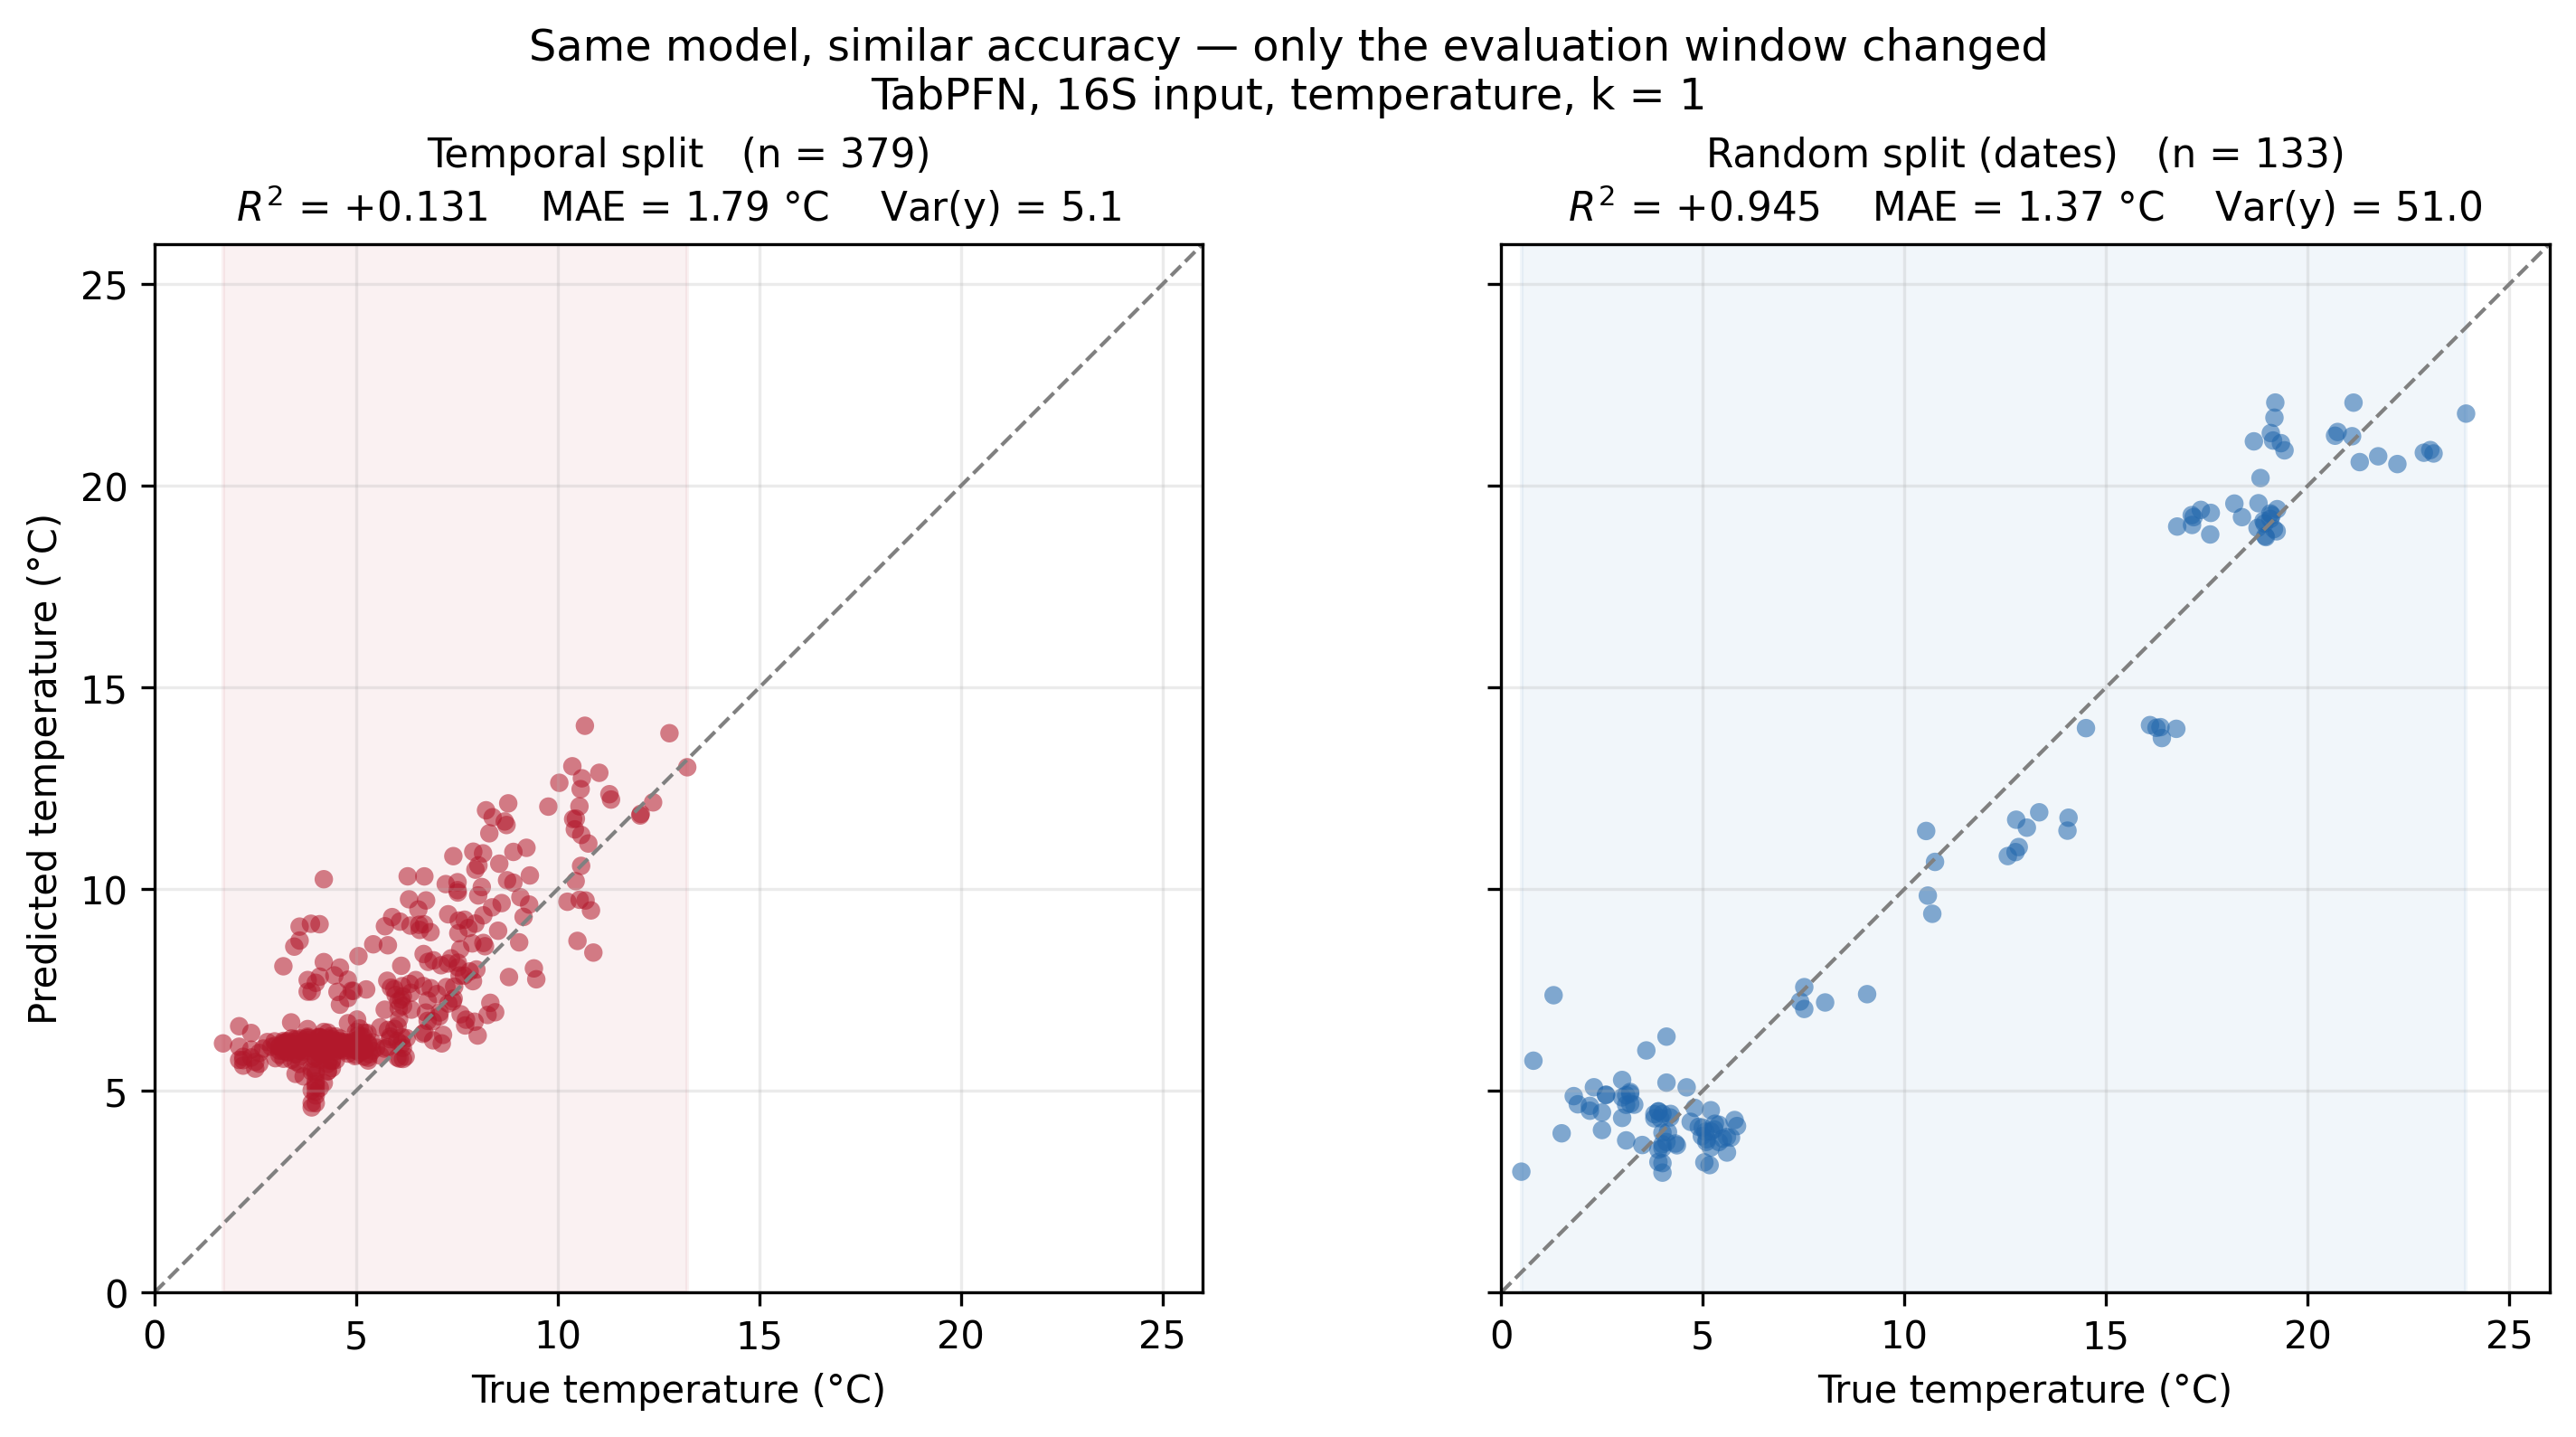

In [5]:
# === FIGURE — why temperature "fails" under the temporal split ===
import warnings; warnings.filterwarnings('ignore')
import matplotlib; matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np, pandas as pd
from pathlib import Path
from sklearn.metrics import r2_score, mean_absolute_error
from tabpfn import TabPFNRegressor
from IPython.display import Image, display

ROOT = Path('/mnt/data/home/tv2414/tabpfn_project')
PROC, R = ROOT / 'data' / 'processed', ROOT / 'results'
TGT, K, SEED, TF, MAXSTEP = 'temperature', 1, 42, 0.30, 6

meta = (pd.read_csv(PROC / 'meta_clean.csv')
          .rename(columns={'Unnamed: 0': 'sample_id'}).set_index('sample_id'))
meta['date'] = pd.to_datetime(meta['date'], errors='coerce')
otu = pd.read_csv(PROC / 'otu_16s_clean.csv', index_col=0); otu.index = meta.index

def build_pairs(k):
    out = []
    for _, g in meta.groupby('location_name'):
        g = g.sort_values('date'); pos, d = g.index.to_numpy(), g['date'].to_numpy()
        for i in range(len(pos) - k):
            if (np.diff(d[i:i+k+1]).astype('timedelta64[D]').astype(int) <= MAXSTEP).all():
                out.append((pos[i], pos[i+k]))
    return out
LAG = build_pairs(K)

ud = pd.DatetimeIndex(meta['date'].dropna().unique()).sort_values()
CUT = pd.Timestamp(ud[int(np.floor(len(ud) * (1 - TF)))])

def split_temporal():
    tr = [(f, t) for f, t in LAG if meta.loc[t, 'date'] < CUT]
    te = [(f, t) for f, t in LAG if meta.loc[t, 'date'] >= CUT and meta.loc[f, 'date'] >= CUT]
    return tr, te

def split_random(seed=0):
    rng = np.random.default_rng(seed); d = ud.to_numpy()
    perm = rng.permutation(len(d))
    tset = set(pd.Timestamp(x) for x in d[perm[:int(round(len(d) * TF))]])
    tr, te = [], []
    for f, t in LAG:
        a, b = meta.loc[f, 'date'] in tset, meta.loc[t, 'date'] in tset
        if a and b: te.append((f, t))
        elif not a and not b: tr.append((f, t))
    return tr, te

y = pd.to_numeric(meta[TGT], errors='coerce')

def run(tr, te):
    f_tr = pd.Index([f for f, _ in tr]); t_tr = pd.Index([t for _, t in tr])
    f_te = pd.Index([f for f, _ in te]); t_te = pd.Index([t for _, t in te])
    Xtr, Xte = otu.loc[f_tr].to_numpy(float), otu.loc[f_te].to_numpy(float)
    ytr, yte = y.loc[t_tr].to_numpy(float), y.loc[t_te].to_numpy(float)
    ok1 = np.isfinite(Xtr).all(1) & np.isfinite(ytr)
    ok2 = np.isfinite(Xte).all(1) & np.isfinite(yte)
    Xtr, ytr, Xte, yte = Xtr[ok1], ytr[ok1], Xte[ok2], yte[ok2]
    m = TabPFNRegressor(device='cuda', random_state=SEED,
                        ignore_pretraining_limits=True)
    m.fit(Xtr, ytr)
    return yte, m.predict(Xte)

print('running temporal ...'); yt_temp, yp_temp = run(*split_temporal())
print('running random ...');   yt_rand, yp_rand = run(*split_random(0))

fig, axes = plt.subplots(1, 2, figsize=(10.5, 5.2), sharex=True, sharey=True)
for ax, (yt, yp, name, col) in zip(axes, [
        (yt_temp, yp_temp, 'Temporal split', '#b2182b'),
        (yt_rand, yp_rand, 'Random split (dates)', '#2166ac')]):
    r2, mae, var = r2_score(yt, yp), mean_absolute_error(yt, yp), np.var(yt)
    ax.scatter(yt, yp, s=24, alpha=0.55, color=col, edgecolor='none')
    ax.plot([0, 26], [0, 26], '--', color='0.5', lw=1)
    ax.axvspan(yt.min(), yt.max(), color=col, alpha=0.06, zorder=0)
    ax.set_xlim(0, 26); ax.set_ylim(0, 26); ax.set_aspect('equal')
    ax.set_title(f'{name}   (n = {len(yt)})\n'
                 f'$R^2$ = {r2:+.3f}    MAE = {mae:.2f} °C    Var(y) = {var:.1f}',
                 fontsize=10.5)
    ax.set_xlabel('True temperature (°C)')
    ax.grid(alpha=0.25)
axes[0].set_ylabel('Predicted temperature (°C)')
fig.suptitle('Same model, similar accuracy — only the evaluation window changed\n'
             'TabPFN, 16S input, temperature, k = 1', fontsize=11.5)
fig.tight_layout()
fig.savefig(R / 'temperature_why_r2_collapses.png', dpi=300, bbox_inches='tight')
plt.close(fig)
print('saved -> temperature_why_r2_collapses.png')
display(Image(str(R / 'temperature_why_r2_collapses.png')))

In [ ]:
# === Recalculate all numbers from chapter 5 on meta clean.csv (correct file) ===
import sys, numpy as np, pandas as pd
from pathlib import Path
ROOT = Path('/mnt/data/home/tv2414/tabpfn_project'); sys.path.insert(0, str(ROOT))
from src.cv_strategies import temporal_holdout, temporal_blocked_kfold, leave_one_site_out

meta = pd.read_csv(ROOT/'data'/'processed'/'meta_clean.csv', index_col=0)
meta['date'] = pd.to_datetime(meta['date'])
print(f'modelling set: {len(meta)} rows, {meta.location_name.nunique()} stations\n')

for tgt in ['temperature', 'salinity', 'Chl_a_log1p']:
    sub = meta[meta[tgt].notna()].sort_values('date').reset_index(drop=True)
    d = pd.to_datetime(sub['date'])
    # holdout boundary
    (tr, te), = temporal_holdout(sub, test_fraction=0.2, date_col='date')
    b = d.iloc[np.asarray(te)].min()
    same = (d == b).sum(); in_te = (d.iloc[np.asarray(te)] == b).sum()
    # blocked
    sizes, shared, spans = [], [], []
    for a, bb in temporal_blocked_kfold(sub, n_folds=5, date_col='date'):
        a = np.asarray(a); bb = np.asarray(bb)
        td, rd = set(d.iloc[bb].dt.date), set(d.iloc[a].dt.date)
        sizes.append(len(bb)); shared.append(len(td & rd))
        spans.append((d.iloc[bb].max() - d.iloc[bb].min()).days)
    print(f'{tgt:14s} n={len(sub):5d} | holdout {b:%d %b %Y} ({in_te}/{same} in test)')
    print(f'{"":14s} blocks={sizes} shared={shared} spans={spans}')

# LOSO fold sizes for salinity
sal = meta[meta['salinity'].notna()].reset_index(drop=True)
sizes = [len(te) for _, te in leave_one_site_out(sal, site_col='location_name')]
print(f'\nLOSO salinity fold sizes: {min(sizes)}–{max(sizes)}  (n={len(sal)})')

# site-level mean salinity range (13 brackish)
m = sal.groupby('location_name')['salinity'].mean().sort_values()
print(f'\nMuehlendamm: {m.iloc[0]:.2f} PSU | other 13: {m.iloc[1]:.2f} to {m.iloc[-1]:.2f} PSU')

# consecutive steps for forecasting
mm = meta.sort_values(['location_name','date']).drop_duplicates(['location_name','date'])
allg = pd.concat([pd.Series(np.diff(np.sort(g['date'].unique())).astype('timedelta64[D]').astype(int))
                  for _, g in mm.groupby('location_name')])
print(f'\nconsecutive steps: {len(allg)} · unique gaps {sorted(allg.unique())} · >6 days: {(allg>6).sum()}')
print(f'unique dates: {mm["date"].nunique()} · {mm["date"].min():%d %b %Y} to {mm["date"].max():%d %b %Y}')

modelling set: 1538 rows, 14 stations

temperature    n= 1223 | holdout 23 Feb 2023 (4/14 in test)
               blocks=[245, 245, 245, 244, 244] shared=[1, 2, 2, 2, 1] spans=[108, 67, 70, 59, 63]
salinity       n= 1217 | holdout 23 Feb 2023 (2/14 in test)
               blocks=[244, 244, 243, 243, 243] shared=[0, 1, 2, 2, 1] spans=[105, 67, 70, 59, 63]
Chl_a_log1p    n= 1437 | holdout 23 Feb 2023 (2/14 in test)
               blocks=[288, 288, 287, 287, 287] shared=[1, 2, 2, 2, 1] spans=[74, 73, 88, 73, 81]

LOSO salinity fold sizes: 82–90  (n=1217)

Muehlendamm: 0.45 PSU | other 13: 9.05 to 14.85 PSU

consecutive steps: 1524 · unique gaps [np.int64(3), np.int64(4), np.int64(7), np.int64(10), np.int64(11)] · >6 days: 23
unique dates: 112 · 21 Apr 2022 to 15 May 2023


In [ ]:
# === exactly reproduces the pair-construction logic ===
import numpy as np, pandas as pd
from pathlib import Path
ROOT = Path('/mnt/data/home/tv2414/tabpfn_project')
MAX_STEP = 6

meta = pd.read_csv(ROOT/'data'/'processed'/'meta_clean.csv', index_col=0)
meta['date'] = pd.to_datetime(meta['date'])

# --- A) گام‌های متوالی روی جدول مدل‌سازی، همان‌طور که pipeline می‌بیند ---
#     pipeline: sort by site+date, drop duplicate (site,date), از خود تاریخ‌ها
mm = (meta.sort_values(['location_name','date'])
          .drop_duplicates(['location_name','date']))
steps = []
for site, g in mm.groupby('location_name'):
    d = np.sort(g['date'].unique())
    steps.append(pd.Series(np.diff(d).astype('timedelta64[D]').astype(int)))
allg = pd.concat(steps)
print('=== A) consecutive steps on the full modelling table ===')
print('  total steps :', len(allg))
print('  gap counts  :', allg.value_counts().sort_index().to_dict())
print(f'  > {MAX_STEP} days : {(allg > MAX_STEP).sum()}')

# --- B) اثر واقعی روی جفت‌سازی، به ازای هر هدف و هر افق ---
print('\n=== B) pairs kept vs discarded by the <=6-day rule, per target x horizon ===')
print(f'{"target":14s}{"k":>3s}{"candidate":>11s}{"kept":>8s}{"dropped":>9s}')
for tgt in ['temperature','salinity','Chl_a_log1p','Caffeine','Metoprolol','Atrazine']:
    if tgt not in meta.columns: 
        print(f'{tgt:14s}  -- column not in meta_clean --'); continue
    sub = meta[meta[tgt].notna()]
    sub = sub.sort_values(['location_name','date']).drop_duplicates(['location_name','date'])
    for k in (1,2,3):
        cand = kept = 0
        for site, g in sub.groupby('location_name'):
            d = np.sort(g['date'].unique())
            for i in range(len(d)-k):
                cand += 1
                st = np.diff(d[i:i+k+1]).astype('timedelta64[D]').astype(int)
                if (st <= MAX_STEP).all(): kept += 1
        print(f'{tgt:14s}{k:>3d}{cand:>11d}{kept:>8d}{cand-kept:>9d}')

=== A) consecutive steps on the full modelling table ===
  total steps : 1524
  gap counts  : {3: 745, 4: 756, 7: 20, 10: 2, 11: 1}
  > 6 days : 23

=== B) pairs kept vs discarded by the <=6-day rule, per target x horizon ===
target          k  candidate    kept  dropped
temperature     1       1209    1103      106
temperature     2       1195     986      209
temperature     3       1181     884      297
salinity        1       1203    1091      112
salinity        2       1189     974      215
salinity        3       1175     872      303
Chl_a_log1p     1       1423    1361       62
Chl_a_log1p     2       1409    1300      109
Chl_a_log1p     3       1395    1242      153
Caffeine        -- column not in meta_clean --
Metoprolol      -- column not in meta_clean --
Atrazine        -- column not in meta_clean --


In [3]:
import numpy as np, pandas as pd
from pathlib import Path
ROOT = Path('/mnt/data/home/tv2414/tabpfn_project'); MAX_STEP = 6
meta = pd.read_csv(ROOT/'data'/'processed'/'meta_clean.csv', index_col=0)
meta['date'] = pd.to_datetime(meta['date'])
mm = meta.sort_values(['location_name','date']).drop_duplicates(['location_name','date'])

print(f'{"k":>3s}{"candidate":>11s}{"kept":>8s}{"dropped":>9s}')
for k in (1,2,3):
    cand = kept = 0
    for site, g in mm.groupby('location_name'):
        d = np.sort(g['date'].unique())
        for i in range(len(d)-k):
            cand += 1
            st = np.diff(d[i:i+k+1]).astype('timedelta64[D]').astype(int)
            if (st <= MAX_STEP).all(): kept += 1
    print(f'{k:>3d}{cand:>11d}{kept:>8d}{cand-kept:>9d}')

  k  candidate    kept  dropped
  1       1524    1501       23
  2       1510    1468       42
  3       1496    1438       58


n = 1223  (expect 1223) · stations = 14


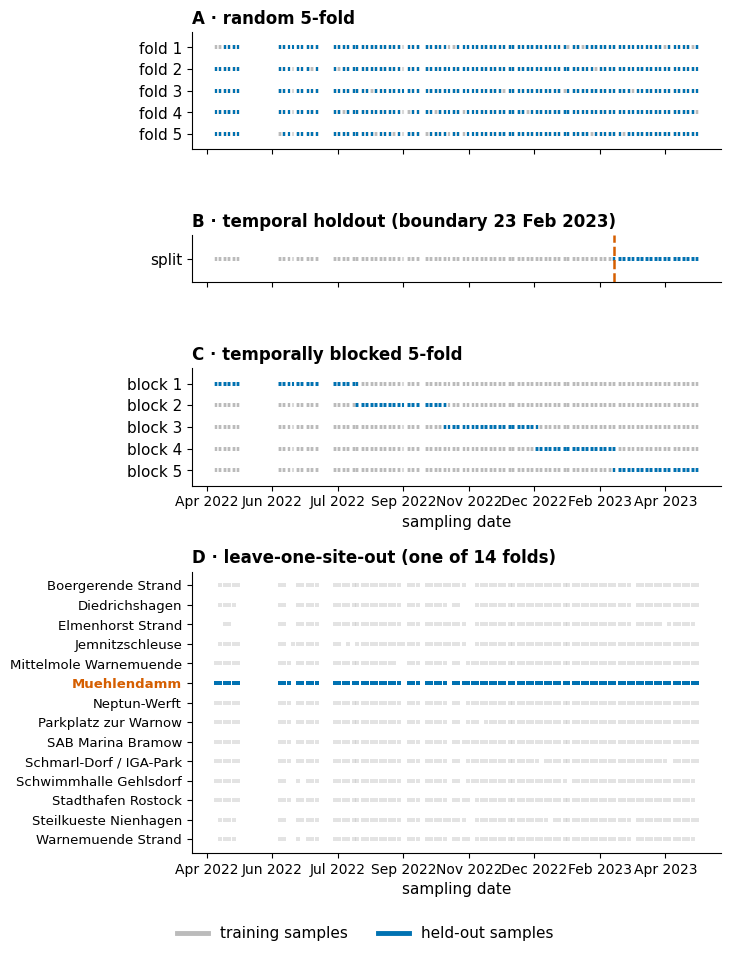

saved · n=1223 · boundary 2023-02-23 · n_train=1132 n_test=91


In [4]:
# === FIGURE 5.1 — four validation strategies (correct data + larger text) ===
import sys, numpy as np, pandas as pd
import matplotlib as mpl, matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
from pathlib import Path
from sklearn.model_selection import KFold

ROOT = Path('/mnt/data/home/tv2414/tabpfn_project'); sys.path.insert(0, str(ROOT))
R = ROOT / 'results'
from src import cv_strategies as cvs

mpl.rcParams.update({'font.size': 13, 'axes.spines.top': False, 'axes.spines.right': False})
TR, TE, CUTC = '#BBBBBB', '#0072B2', '#D55E00'

# ---- CORRECT source: meta_clean.csv (the modelling table) ----
meta = pd.read_csv(ROOT/'data'/'processed'/'meta_clean.csv', index_col=0)
meta['date'] = pd.to_datetime(meta['date'])
sub = meta[meta['temperature'].notna()].sort_values('date').reset_index(drop=True)
n = len(sub); d = pd.to_datetime(sub['date']); x = mdates.date2num(d.dt.to_pydatetime())
sites = sorted(sub['location_name'].unique()); k = len(sites)
site_row = {s: i for i, s in enumerate(sites)}
rows_all = sub['location_name'].map(site_row).to_numpy()
print(f'n = {n}  (expect 1223) · stations = {k}')

def try_call(fn, *variants):
    if fn is None: return None
    for kw in variants:
        try:
            out = fn(**kw)
            if out is not None and len(out): return list(out)
        except Exception: continue
    return None

A = try_call(getattr(cvs,'random_kfold',None), dict(n_samples=n, n_folds=5)) \
    or list(KFold(n_splits=5, shuffle=True, random_state=42).split(np.arange(n)))
B = try_call(getattr(cvs,'temporal_holdout',None), dict(meta=sub, test_fraction=0.2, date_col='date'))
C = try_call(getattr(cvs,'temporal_blocked_kfold',None), dict(meta=sub, n_folds=5, date_col='date'))
D = try_call(getattr(cvs,'leave_one_site_out',None),
             dict(meta=sub, site_col='location_name'), dict(meta=sub)) \
    or [(np.where(rows_all != r)[0], np.where(rows_all == r)[0]) for r in range(k)]

fig, axes = plt.subplots(4, 1, figsize=(7.5, 9.5),
                         gridspec_kw={'height_ratios': [1.25, 0.5, 1.25, 3.0]})

def style(ax, nrows, labels, title, fs=11):
    ax.set_yticks(range(nrows)); ax.set_yticklabels(labels, fontsize=fs)
    ax.set_ylim(-0.7, nrows-0.3); ax.invert_yaxis()
    ax.set_title(title, fontsize=12, fontweight='bold', loc='left', pad=6)
    ax.tick_params(axis='x', labelbottom=False, labelsize=11)

def strip(ax, splits):
    for row, (tr, te) in enumerate(splits):
        tr = np.asarray(tr); te = np.asarray(te)
        ax.scatter(x[tr], [row]*len(tr), s=9, color=TR, marker='|', alpha=.55)
        ax.scatter(x[te], [row]*len(te), s=9, color=TE, marker='|')

strip(axes[0], A)
style(axes[0], len(A), [f'fold {i}' for i in range(1, len(A)+1)], 'A · random 5-fold')

strip(axes[1], B)
bnd = d.iloc[np.asarray(B[0][1])].min()
axes[1].axvline(mdates.date2num(bnd), color=CUTC, ls='--', lw=1.8, zorder=3)
style(axes[1], 1, ['split'], f'B · temporal holdout (boundary {bnd:%d %b %Y})')

strip(axes[2], C)
style(axes[2], len(C), [f'block {i}' for i in range(1, len(C)+1)],
      'C · temporally blocked 5-fold')
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[2].tick_params(axis='x', labelbottom=True, labelsize=10)
axes[2].set_xlabel('sampling date', fontsize=11)

mu_name = next(s for s in sites if 'ehlendamm' in s)
mu_fold = next(i for i, (tr, te) in enumerate(D)
               if sub['location_name'].iloc[np.asarray(te)[0]] == mu_name)
tr, te = np.asarray(D[mu_fold][0]), np.asarray(D[mu_fold][1])
ax = axes[3]
ax.scatter(x[tr], rows_all[tr], s=9,  color=TR, marker='s', alpha=.40, linewidths=0)
ax.scatter(x[te], rows_all[te], s=12, color=TE, marker='s', linewidths=0)
ax.set_yticks(range(k)); ax.set_yticklabels(sites, fontsize=9.5)
ax.get_yticklabels()[site_row[mu_name]].set_color(CUTC)
ax.get_yticklabels()[site_row[mu_name]].set_fontweight('bold')
ax.set_ylim(-0.7, k-0.3); ax.invert_yaxis()
ax.set_title('D · leave-one-site-out (one of 14 folds)',
             fontsize=12, fontweight='bold', loc='left', pad=6)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.tick_params(axis='x', labelsize=10); ax.set_xlabel('sampling date', fontsize=11)

fig.legend(handles=[Line2D([0],[0], color=TR, lw=3.5, label='training samples'),
                    Line2D([0],[0], color=TE, lw=3.5, label='held-out samples')],
           loc='lower center', ncol=2, frameon=False, fontsize=11, bbox_to_anchor=(0.5,-0.015))
plt.tight_layout(rect=[0, 0.025, 1, 1])
for ext in ('png','pdf'):
    plt.savefig(R / f'fig5_1_validation_strategies.{ext}', dpi=300, bbox_inches='tight')
plt.show()
print(f'saved · n={n} · boundary {bnd:%Y-%m-%d} · n_train={len(tr)} n_test={len(te)}')

In [1]:
import pandas as pd
from pathlib import Path
R = Path('/mnt/data/home/tv2414/tabpfn_project/results')

p = pd.read_csv(R/'phase2_downstream_emb_vs_raw.csv')
p = p[p.model.str.lower()=='ridge']

# cell = one (features, strategy, target, input); score = mean over folds
cell = p.groupby(['features','strategy','target','input']).r2.mean().reset_index()

# now aggregate over the three inputs -> median per (strategy, target)
out = cell.groupby(['strategy','target','features']).r2.median().unstack()
print(out.round(3).to_string())

print('\n--- also min per (strategy,target) for context ---')
mn = cell.groupby(['strategy','target','features']).r2.min().unstack()
print(mn.round(3).to_string())

features                            embedding        raw
strategy               target                           
leave_one_site_out     Chl_a_log1p      0.416     -5.081
                       salinity       -15.137   -951.586
                       temperature      0.970     -0.995
random_kfold           Chl_a_log1p      0.789      0.628
                       salinity         0.968      0.798
                       temperature      0.985      0.801
temporal_blocked_kfold Chl_a_log1p      0.617 -13636.356
                       salinity         0.920    -52.945
                       temperature      0.557   -130.957
temporal_holdout       Chl_a_log1p      0.845     -0.542
                       salinity         0.927      0.225
                       temperature      0.599    -11.038

--- also min per (strategy,target) for context ---
features                            embedding        raw
strategy               target                           
leave_one_site_out     Chl_a_log1p  

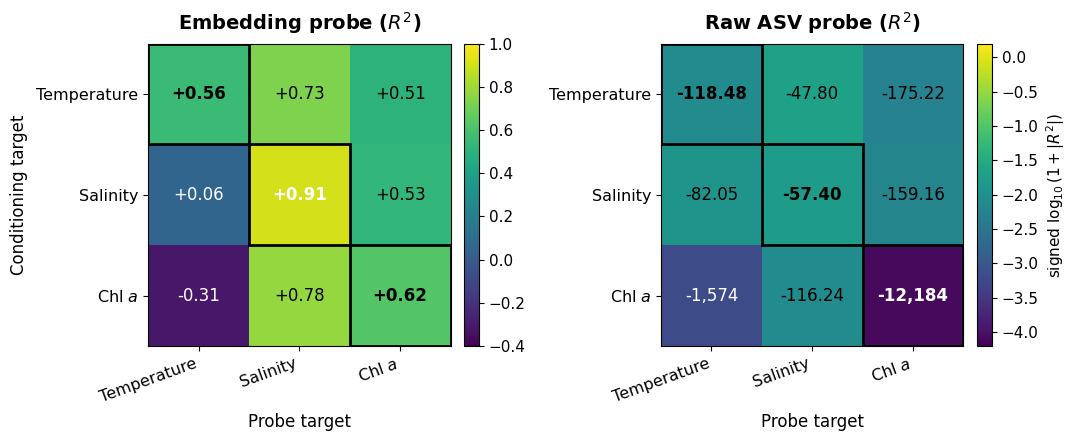

embedding:
 pred_target  temperature  salinity  Chl_a_log1p
emb_target                                     
temperature        0.556     0.728        0.507
salinity           0.056     0.908        0.528
Chl_a_log1p       -0.310     0.779        0.624

raw:
 pred_target  temperature  salinity  Chl_a_log1p
emb_target                                     
temperature      -118.48    -47.80      -175.22
salinity          -82.05    -57.40      -159.16
Chl_a_log1p     -1573.67   -116.24    -12184.41


In [3]:
# ===== Figure 7.4 : Cross-target matrices (two panels) =====
import matplotlib as mpl, matplotlib.pyplot as plt
import numpy as np, pandas as pd
from pathlib import Path

mpl.rcParams.update({'font.size': 13, 'axes.titlesize': 14, 'axes.labelsize': 12,
                     'font.family': 'DejaVu Sans', 'savefig.dpi': 300})

RES = Path('/mnt/data/home/tv2414/tabpfn_project/results')
STRATEGY = 'temporal_blocked_kfold'
NICE = {'temperature':'Temperature','salinity':'Salinity','Chl_a_log1p':'Chl $a$'}
ORDER = ['temperature','salinity','Chl_a_log1p']

d = pd.read_csv(RES/'phase2_cross_target_v2.csv')
d = d[d.strategy == STRATEGY]
emb = d.pivot_table(index='emb_target', columns='pred_target',
                    values='emb_r2', aggfunc='mean').reindex(ORDER)[ORDER]
raw = d.pivot_table(index='emb_target', columns='pred_target',
                    values='raw_r2', aggfunc='mean').reindex(ORDER)[ORDER]
labels = [NICE[t] for t in ORDER]

def draw(ax, M, title, vmin, vmax, symlog=False):
    A = M.to_numpy(float)
    plot = np.sign(A)*np.log10(1+np.abs(A)) if symlog else A
    im = ax.imshow(plot, cmap='viridis', vmin=vmin, vmax=vmax, aspect='equal')
    for i in range(3):
        for j in range(3):
            v = A[i, j]
            txt = f'{v:+.2f}' if abs(v) < 1000 else f'{v:+,.0f}'
            norm = (plot[i, j]-vmin)/(vmax-vmin+1e-12)
            ax.text(j, i, txt, ha='center', va='center', fontsize=12,
                    weight='bold' if i == j else 'normal',
                    color='white' if norm < 0.35 or norm > 0.88 else 'black')
    ax.set_xticks(range(3))
    ax.set_xticklabels(labels, fontsize=11.5, rotation=20, ha='right')
    ax.set_yticks(range(3)); ax.set_yticklabels(labels, fontsize=11.5)
    ax.set_title(title, weight='bold', pad=10)
    ax.set_xlabel('Probe target', fontsize=12, labelpad=6)
    for i in range(3):
        ax.add_patch(plt.Rectangle((i-0.5, i-0.5), 1, 1, fill=False, ec='black', lw=2))
    return im

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))

im0 = draw(axes[0], emb, 'Embedding probe ($R^2$)', -0.4, 1.0)
cb0 = plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)
cb0.ax.tick_params(labelsize=11)
axes[0].set_ylabel('Conditioning target', fontsize=12, labelpad=6)

im1 = draw(axes[1], raw, 'Raw ASV probe ($R^2$)', -4.2, 0.2, symlog=True)
cb1 = plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
cb1.set_label('signed $\\log_{10}(1+|R^2|)$', fontsize=11)
cb1.ax.tick_params(labelsize=11)

fig.tight_layout()
for ext in ['png','pdf']:
    fig.savefig(RES/f'fig_7_4_crosstarget.{ext}', bbox_inches='tight')
plt.show()

print('embedding:\n', emb.round(3))
print('\nraw:\n', raw.round(2))

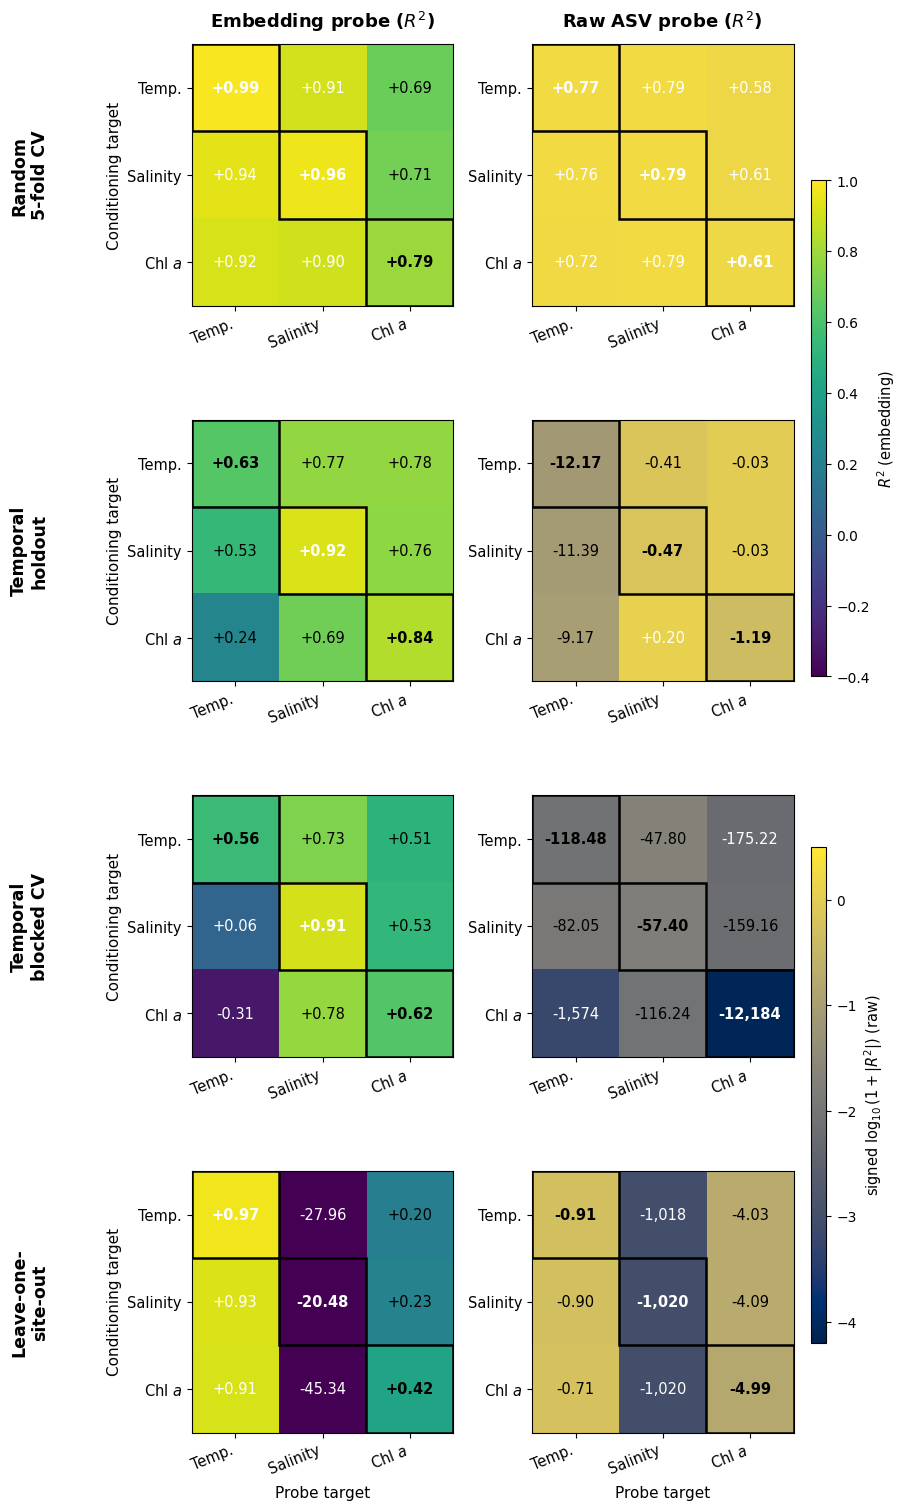

strategy
leave_one_site_out        357/378
random_kfold              133/135
temporal_blocked_kfold    135/135
temporal_holdout            27/27


In [ ]:
# Figure 7.4 
import matplotlib as mpl, matplotlib.pyplot as plt
import numpy as np, pandas as pd
from pathlib import Path

mpl.rcParams.update({'font.size': 12, 'axes.titlesize': 13,
                     'font.family': 'DejaVu Sans', 'savefig.dpi': 300})

RES = Path('/mnt/data/home/tv2414/tabpfn_project/results')
NICE  = {'temperature': 'Temp.', 'salinity': 'Salinity', 'Chl_a_log1p': 'Chl $a$'}
ORDER = ['temperature', 'salinity', 'Chl_a_log1p']
STRATS = [('random_kfold',           'Random\n5-fold CV'),
          ('temporal_holdout',       'Temporal\nholdout'),
          ('temporal_blocked_kfold', 'Temporal\nblocked CV'),
          ('leave_one_site_out',     'Leave-one-\nsite-out')]

EMB_LO, EMB_HI = -0.4, 1.0        # natural R² range
RAW_LO, RAW_HI = -4.2, 0.5        # signed log10 scale

d_all = pd.read_csv(RES / 'phase2_cross_target_v2.csv')
labels = [NICE[t] for t in ORDER]

def draw(ax, A, vmin, vmax, symlog, cmap='viridis'):
    plot = np.sign(A) * np.log10(1 + np.abs(A)) if symlog else A
    im = ax.imshow(np.clip(plot, vmin, vmax), cmap=cmap,
                   vmin=vmin, vmax=vmax, aspect='equal')
    for i in range(3):
        for j in range(3):
            v = A[i, j]
            txt = f'{v:+.2f}' if abs(v) < 1000 else f'{v:+,.0f}'
            norm = (np.clip(plot[i, j], vmin, vmax) - vmin) / (vmax - vmin + 1e-12)
            ax.text(j, i, txt, ha='center', va='center', fontsize=10.5,
                    weight='bold' if i == j else 'normal',
                    color='white' if norm < 0.42 or norm > 0.90 else 'black')
    ax.set_xticks(range(3)); ax.set_yticks(range(3))
    ax.set_xticklabels(labels, fontsize=10.5, rotation=22, ha='right')
    ax.set_yticklabels(labels, fontsize=10.5)
    for i in range(3):
        ax.add_patch(plt.Rectangle((i - .5, i - .5), 1, 1,
                                   fill=False, ec='black', lw=1.8))
    return im

fig, axes = plt.subplots(4, 2, figsize=(8.6, 15.5))

im_emb = im_raw = None
for r, (skey, sname) in enumerate(STRATS):
    d = d_all[d_all.strategy == skey]
    emb = d.pivot_table(index='emb_target', columns='pred_target',
                        values='emb_r2', aggfunc='mean').reindex(ORDER)[ORDER].to_numpy(float)
    raw = d.pivot_table(index='emb_target', columns='pred_target',
                        values='raw_r2', aggfunc='mean').reindex(ORDER)[ORDER].to_numpy(float)

    im_emb = draw(axes[r, 0], emb, EMB_LO, EMB_HI, False, cmap='viridis')
    im_raw = draw(axes[r, 1], raw, RAW_LO, RAW_HI, True,  cmap='cividis')

    axes[r, 0].set_ylabel('Conditioning target', fontsize=11)
    axes[r, 0].text(-0.62, 0.5, sname, transform=axes[r, 0].transAxes,
                    rotation=90, va='center', ha='center',
                    fontsize=12.5, weight='bold')

    if r == 0:
        axes[r, 0].set_title('Embedding probe ($R^2$)', weight='bold', pad=12)
        axes[r, 1].set_title('Raw ASV probe ($R^2$)',  weight='bold', pad=12)
    if r == 3:
        for c in range(2):
            axes[r, c].set_xlabel('Probe target', fontsize=11, labelpad=6)

fig.subplots_adjust(left=0.16, right=0.86, top=0.96, bottom=0.06,
                    hspace=0.40, wspace=0.30)

cax0 = fig.add_axes([0.88, 0.55, 0.018, 0.32])
cb0 = fig.colorbar(im_emb, cax=cax0)
cb0.set_label('$R^2$ (embedding)', fontsize=10.5)
cb0.ax.tick_params(labelsize=10)

cax1 = fig.add_axes([0.88, 0.12, 0.018, 0.32])
cb1 = fig.colorbar(im_raw, cax=cax1)
cb1.set_label('signed $\\log_{10}(1+|R^2|)$ (raw)', fontsize=10.5)
cb1.ax.tick_params(labelsize=10)

for ext in ['png', 'pdf']:
    fig.savefig(RES / f'fig_7_4_crosstarget_all.{ext}', bbox_inches='tight')
plt.show()

d_all['win'] = d_all.emb_r2 > d_all.raw_r2
print(d_all.groupby('strategy').apply(lambda g: f'{g.win.sum()}/{len(g)}').to_string())

In [ ]:
# How does the cross-target code handle missing probe labels?
import json, pandas as pd, numpy as np
from pathlib import Path

ROOT = Path('/mnt/data/home/tv2414/tabpfn_project')

# ---------- (1) find the cross-target cell in the notebook ----------
nb = json.loads((ROOT/'notebooks/11_phase2_embeddings.ipynb').read_text())
for i, c in enumerate(nb['cells']):
    s = ''.join(c.get('source', ''))
    if 'cross_target' in s and ('pred_target' in s or 'emb_target' in s):
        print(f'\n{"="*72}\nCELL {i}  exec={c.get("execution_count")}')
        print(s)
        break

# ---------- (2) infer from the output file ----------
d = pd.read_csv(ROOT/'results/phase2_cross_target_v2.csv')
print('\n' + '='*72)
print('n_test totals per (emb_target, pred_target), LOSO only')
loso = d[d.strategy == 'leave_one_site_out']
piv = loso.groupby(['emb_target','pred_target','input']).n_test.sum().unstack('input')
print(piv.to_string())

print('\nExpected sample counts: temperature=1223  salinity=1217  Chl_a_log1p=1437')
print('\n--> If n_test总 depends only on pred_target, the code masks on the')
print('    probe target. If it depends on emb_target, it does not.')


CELL 49  exec=24
import numpy as np, pandas as pd, time
from pathlib import Path
from sklearn.metrics import r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

OUT = Path('..') / 'results' / 'phase2_cross_target.csv'
STRATS = ['random_kfold', 'temporal_holdout', 'temporal_blocked_kfold', 'leave_one_site_out']
ALPHAS = np.logspace(-2, 3, 11)

def downstream(emb_tr, emb_te, y_tr, y_te):
    out = {}
    for name, est in [('ridge', RidgeCV(alphas=ALPHAS)),
                      ('knn', KNeighborsRegressor(n_neighbors=5))]:
        pipe = make_pipeline(StandardScaler(), est).fit(emb_tr, y_tr)
        out[name] = r2_score(y_te, pipe.predict(emb_te))
    return out

# resume support
done = set()
if OUT.exists():
    prev = pd.read_csv(OUT)
    done = set(map(tuple, prev[['emb_target', 'input', 'strategy', 'fold', 'pred_target', 'model']].values))
    

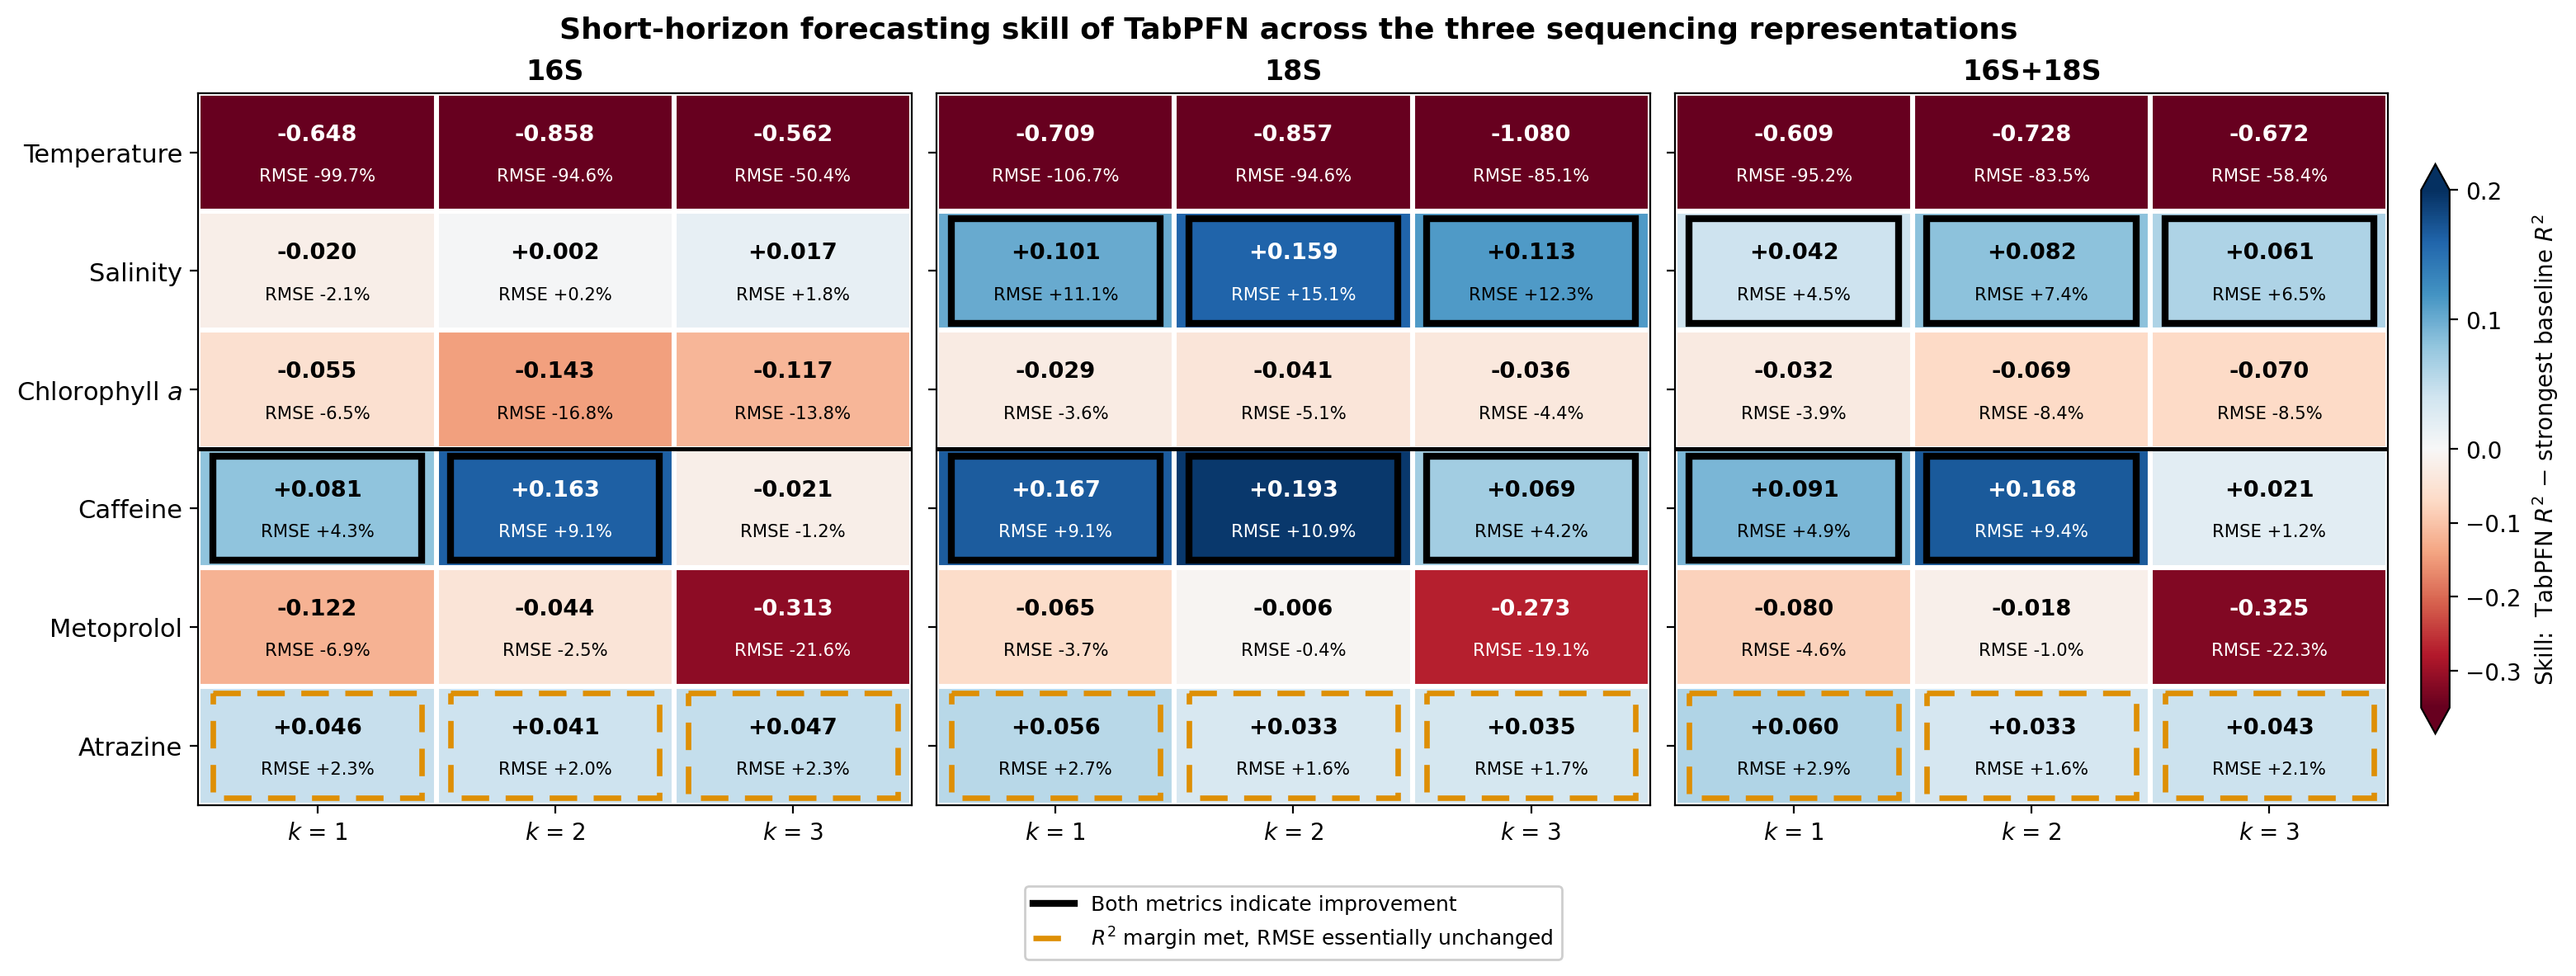

cells where both metrics indicate improvement: {'16S': 2, '18S': 6, '16S+18S': 5}


In [ ]:
# Figure 8.1 — forecasting skill for all three sequencing inputs.
import matplotlib.pyplot as plt
import numpy as np, pandas as pd
from pathlib import Path
from matplotlib.colors import TwoSlopeNorm
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D
from IPython.display import Image, display

R = Path('/mnt/data/home/tv2414/tabpfn_project/results')

base = pd.read_csv(R / 'forecasting_baseline_metrics.csv')
chem = pd.read_csv(R / 'phase3_forecasting_shared_mask_splitB_unifiedcut.csv')
env  = pd.read_csv(R / 'phase1_forecasting_shared_mask_splitB.csv')
mod  = pd.concat([chem, env], ignore_index=True)

NAME = {'temperature': 'Temperature', 'salinity': 'Salinity',
        'Chl_a': 'Chlorophyll a', 'Chl_a_log1p': 'Chlorophyll a',
        'Caffeine': 'Caffeine', 'Metoprolol': 'Metoprolol',
        'Atrazine': 'Atrazine'}
base['tgt'] = base['target'].map(NAME)
mod['tgt']  = mod['target'].map(NAME)
best = base.loc[base.groupby(['tgt', 'horizon_k'])['r2'].idxmax()] \
           .set_index(['tgt', 'horizon_k'])

T_ORDER = ['Temperature', 'Salinity', 'Chlorophyll a',
           'Caffeine', 'Metoprolol', 'Atrazine']
LBL = {'Chlorophyll a': 'Chlorophyll $a$'}
I_ORDER, H = ['16S', '18S', '16S+18S'], [1, 2, 3]

def grids(inp):
    t = mod[(mod.model == 'tabpfn') & (mod.input == inp)]
    sk = np.full((6, 3), np.nan); rm = np.full((6, 3), np.nan)
    for i, g in enumerate(T_ORDER):
        for j, k in enumerate(H):
            r = t[(t.tgt == g) & (t.horizon_k == k)]
            if not len(r):
                continue
            b = best.loc[(g, k)]
            sk[i, j] = r.r2.iloc[0] - b['r2']
            rm[i, j] = 100 * (1 - r.rmse.iloc[0] / b['rmse'])
    return sk, rm

VMIN, VMAX = -0.35, 0.20
norm = TwoSlopeNorm(vcenter=0.0, vmin=VMIN, vmax=VMAX)

fig, axes = plt.subplots(1, 3, figsize=(15.5, 5.8), sharey=True,
                         constrained_layout=True)
counts = {}
for ax, inp in zip(axes, I_ORDER):
    sk, rm = grids(inp)
    counts[inp] = int(((sk > 0.03) & (rm > 3.0)).sum())
    im = ax.imshow(np.clip(sk, VMIN, VMAX), cmap='RdBu', norm=norm,
                   aspect='auto')
    for i in range(6):
        for j in range(3):
            s, rr = sk[i, j], rm[i, j]
            lum = (np.clip(s, VMIN, VMAX) - VMIN) / (VMAX - VMIN)
            col = 'white' if (lum < 0.22 or lum > 0.86) else 'black'
            ax.text(j, i - 0.15, f'{s:+.3f}', ha='center', va='center',
                    fontsize=9.8, fontweight='bold', color=col)
            ax.text(j, i + 0.20, f'RMSE {rr:+.1f}%', ha='center',
                    va='center', fontsize=7.6, color=col)
            if s > 0.03 and rr > 3.0:
                ax.add_patch(Rectangle((j - 0.44, i - 0.44), 0.88, 0.88,
                                       fill=False, edgecolor='black',
                                       linewidth=3.0, zorder=5))
            elif s > 0.03:
                ax.add_patch(Rectangle((j - 0.44, i - 0.44), 0.88, 0.88,
                                       fill=False, edgecolor='#DE8F05',
                                       linewidth=2.4, linestyle=(0, (5, 3)),
                                       zorder=5))
    ax.set_xticks(range(3))
    ax.set_xticklabels([f'$k$ = {k}' for k in H], fontsize=10)
    ax.set_xticks(np.arange(-0.5, 3, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, 6, 1), minor=True)
    ax.grid(which='minor', color='white', linewidth=2.2)
    ax.tick_params(which='minor', length=0)
    ax.axhline(2.5, color='black', lw=1.8, zorder=6)
    ax.set_title(inp, fontsize=12, fontweight='bold')

axes[0].set_yticks(range(6))
axes[0].set_yticklabels([LBL.get(g, g) for g in T_ORDER], fontsize=11)

cb = fig.colorbar(im, ax=axes, shrink=0.80, pad=0.015, extend='both',
                  ticks=[-0.3, -0.2, -0.1, 0, 0.1, 0.2])
cb.set_label('Skill:  TabPFN $R^2$ $-$ strongest baseline $R^2$', fontsize=10)

fig.suptitle('Short-horizon forecasting skill of TabPFN across the three '
             'sequencing representations', fontsize=13, fontweight='bold')

axes[1].legend(handles=[
    Line2D([], [], color='black', lw=3.0,
           label='Both metrics indicate improvement'),
    Line2D([], [], color='#DE8F05', lw=2.4, ls=(0, (5, 3)),
           label='$R^2$ margin met, RMSE essentially unchanged')],
    fontsize=9, loc='upper center', bbox_to_anchor=(0.5, -0.10),
    framealpha=0.96)

for ext in ('png', 'pdf'):
    fig.savefig(R / f'fig_8_1_forecasting_skill_3panels.{ext}', dpi=200,
                bbox_inches='tight')
plt.close(fig)
display(Image(filename=str(R / 'fig_8_1_forecasting_skill_3panels.png')))
print('cells where both metrics indicate improvement:', counts)

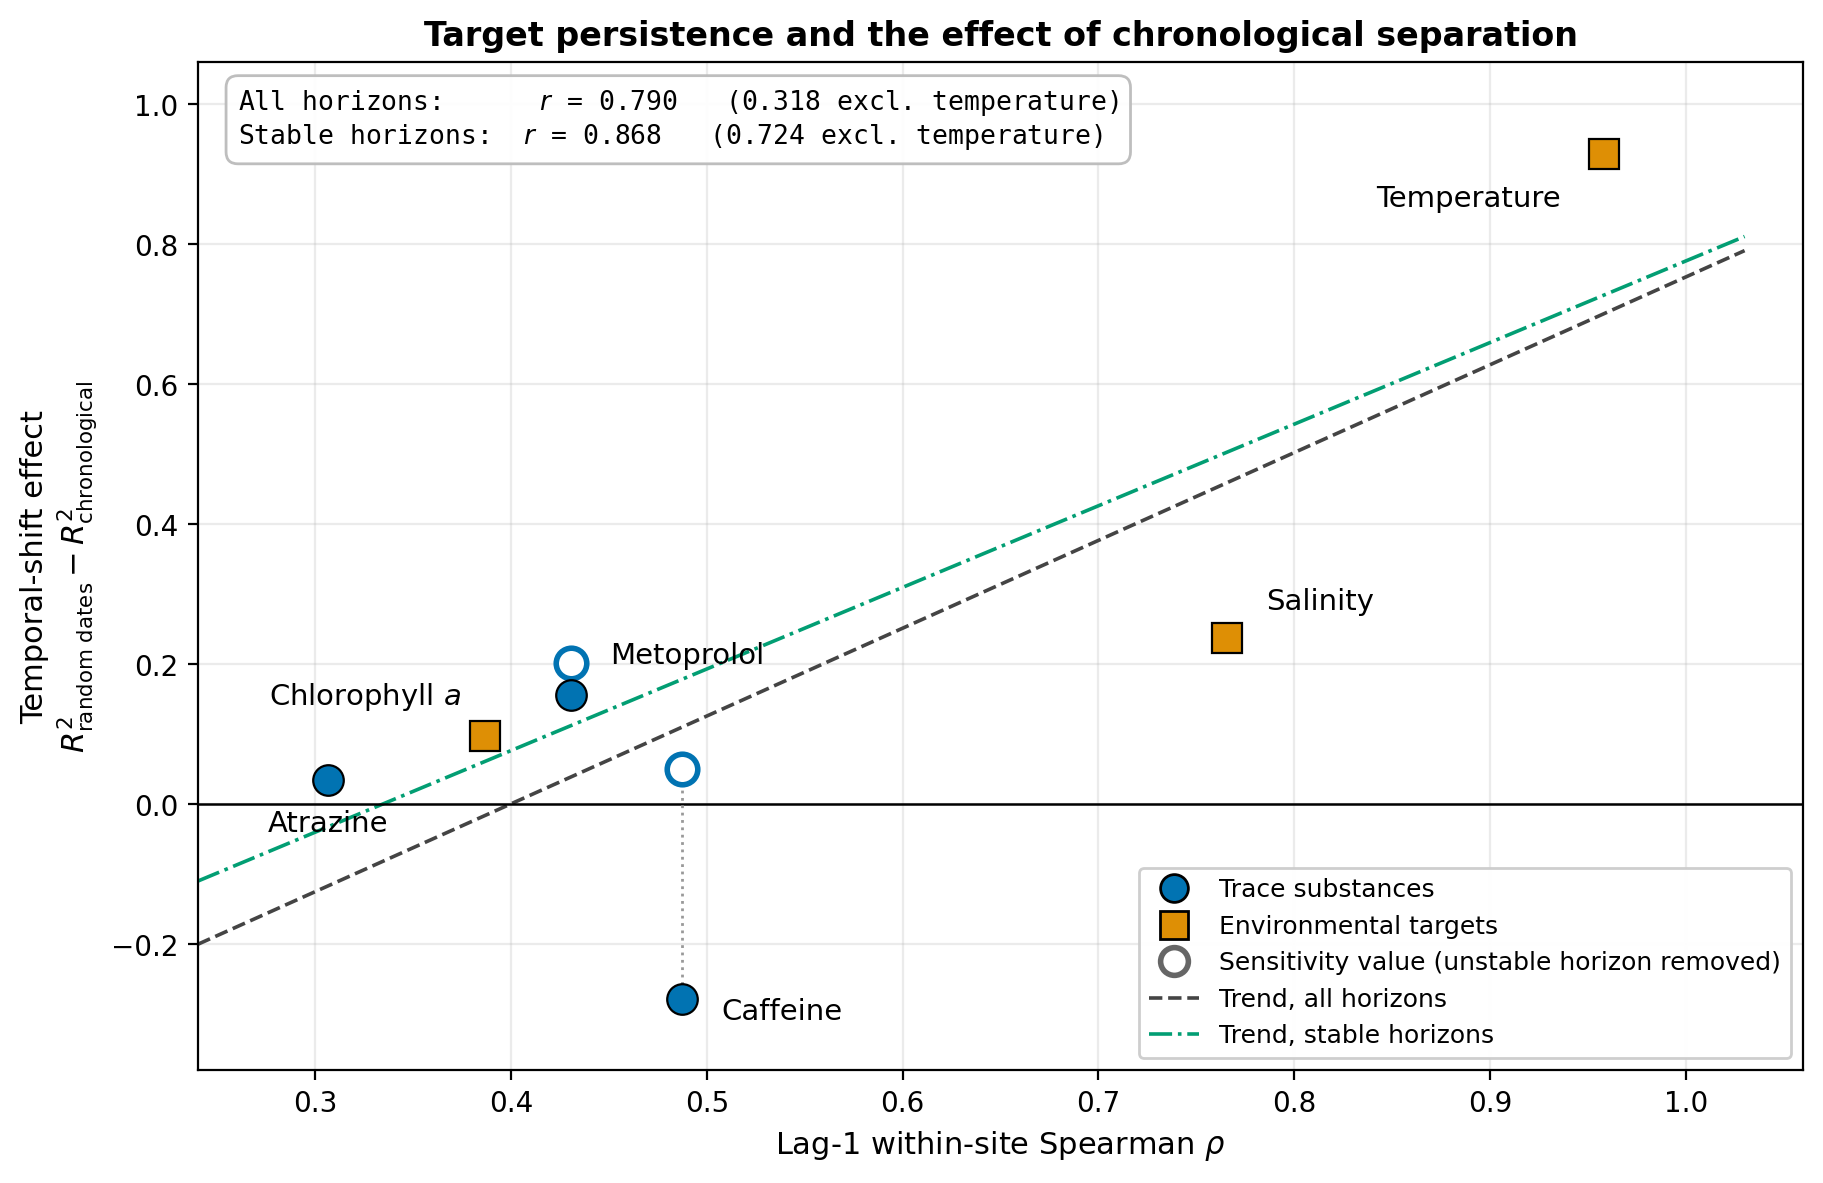

In [ ]:
# Figure 8.2 — lag-1 autocorrelation vs temporal-shift effect.
import matplotlib.pyplot as plt
import numpy as np, pandas as pd
from pathlib import Path
from scipy.stats import pearsonr
from matplotlib.lines import Line2D
from IPython.display import Image, display

R = Path('/mnt/data/home/tv2414/tabpfn_project/results')
ms = pd.read_csv(R / 'phase3_random_split_multiseed.csv')
ac = pd.read_csv(R / 'temporal_autocorr_summary.csv')

TG = ['temperature', 'salinity', 'Chl_a_log1p',
      'Caffeine', 'Metoprolol', 'Atrazine']
ACK = {'Chl_a_log1p': 'Chl_a'}
LBL = {'temperature': 'Temperature', 'salinity': 'Salinity',
       'Chl_a_log1p': 'Chlorophyll $a$', 'Caffeine': 'Caffeine',
       'Metoprolol': 'Metoprolol', 'Atrazine': 'Atrazine'}
CHEM = {'Caffeine', 'Metoprolol', 'Atrazine'}
SD_MAX = 0.30

mean = ms.groupby(['target', 'horizon_k', 'regime'])['r2'].mean().unstack('regime')
sd   = ms.groupby(['target', 'horizon_k', 'regime'])['r2'].std().unstack('regime')
shift = lambda t, k: mean.loc[(t, k), 'random_dates'] - mean.loc[(t, k), 'temporal']
rho1  = lambda t: float(ac[(ac.target == ACK.get(t, t)) & (ac.k == 1)]
                        ['spearman_med'].iloc[0])

rows = []
for t in TG:
    allk = [shift(t, k) for k in (1, 2, 3)]
    stab = [shift(t, k) for k in (1, 2, 3)
            if sd.loc[(t, k), 'random_dates'] <= SD_MAX]
    rows.append(dict(t=t, rho=rho1(t), prim=np.mean(allk),
                     sens=np.mean(stab) if stab else np.nan,
                     dropped=3 - len(stab)))
d = pd.DataFrame(rows)

r_p  = pearsonr(d['rho'].to_numpy(), d['prim'].to_numpy())
sub  = d[d['t'] != 'temperature']
r_pn = pearsonr(sub['rho'].to_numpy(), sub['prim'].to_numpy())
r_s  = pearsonr(d['rho'].to_numpy(), d['sens'].to_numpy())
r_sn = pearsonr(sub['rho'].to_numpy(), sub['sens'].to_numpy())

fig, ax = plt.subplots(figsize=(9.0, 5.8), constrained_layout=True)
ax.axhline(0, color='black', lw=0.9, zorder=2)

xs = np.linspace(0.24, 1.03, 50)
for col, key, ls, lab in [('#444444', 'prim', '--', 'Trend, all horizons'),
                          ('#029E73', 'sens', '-.', 'Trend, stable horizons')]:
    b, a = np.polyfit(d['rho'], d[key], 1)
    ax.plot(xs, a + b * xs, color=col, lw=1.3, ls=ls, zorder=1, label=lab)

for r in d.itertuples():
    c  = '#0173B2' if r.t in CHEM else '#DE8F05'
    mk = 'o' if r.t in CHEM else 's'
    if r.dropped:
        ax.plot([r.rho, r.rho], [r.prim, r.sens], color='#999999',
                lw=1.0, ls=':', zorder=3)
        ax.plot(r.rho, r.sens, mk, ms=11, color='white',
                markeredgecolor=c, markeredgewidth=2.0, zorder=4)
    ax.plot(r.rho, r.prim, mk, ms=11, color=c,
            markeredgecolor='black', markeredgewidth=0.8, zorder=5)

OFF = {'temperature': (-0.022, -0.075, 'right'),
       'salinity':    (0.020,  0.040, 'left'),
       'Chl_a_log1p': (-0.012, 0.045, 'right'),
       'Caffeine':    (0.020, -0.030, 'left'),
       'Metoprolol':  (0.020,  0.045, 'left'),
       'Atrazine':    (0.000, -0.075, 'center')}
for r in d.itertuples():
    dx, dy, ha = OFF[r.t]
    ax.annotate(LBL[r.t], (r.rho + dx, r.prim + dy), fontsize=10.5, ha=ha)

ax.text(0.025, 0.975,
        f'All horizons:      $r$ = {r_p[0]:.3f}   '
        f'({r_pn[0]:.3f} excl. temperature)\n'
        f'Stable horizons:  $r$ = {r_s[0]:.3f}   '
        f'({r_sn[0]:.3f} excl. temperature)',
        transform=ax.transAxes, fontsize=9.5, va='top', family='monospace',
        bbox=dict(boxstyle='round,pad=0.45', fc='white',
                  ec='#BBBBBB', alpha=0.95))

ax.set_xlabel('Lag-1 within-site Spearman $\\rho$', fontsize=11)
ax.set_ylabel('Temporal-shift effect\n'
              '$R^2_{\\mathrm{random\\ dates}} - R^2_{\\mathrm{chronological}}$',
              fontsize=11)
ax.set_title('Target persistence and the effect of chronological separation',
             fontsize=12, fontweight='bold')
ax.set_xlim(0.24, 1.06); ax.set_ylim(-0.38, 1.06)
ax.grid(alpha=0.25); ax.set_axisbelow(True)

ax.legend(handles=[
    Line2D([], [], marker='o', ls='', color='#0173B2', ms=10,
           markeredgecolor='black', label='Trace substances'),
    Line2D([], [], marker='s', ls='', color='#DE8F05', ms=10,
           markeredgecolor='black', label='Environmental targets'),
    Line2D([], [], marker='o', ls='', color='white', ms=10,
           markeredgecolor='#666666', markeredgewidth=2,
           label='Sensitivity value (unstable horizon removed)'),
    Line2D([], [], ls='--', color='#444444', lw=1.3,
           label='Trend, all horizons'),
    Line2D([], [], ls='-.', color='#029E73', lw=1.3,
           label='Trend, stable horizons')],
    fontsize=9, loc='lower right', framealpha=0.96)

for ext in ('png', 'pdf'):
    fig.savefig(R / f'fig_8_2_autocorr_vs_shift.{ext}', dpi=200,
                bbox_inches='tight')
plt.close(fig)
display(Image(filename=str(R / 'fig_8_2_autocorr_vs_shift.png')))

In [1]:
import numpy as np, pandas as pd
from pathlib import Path

R = Path('/mnt/data/home/tv2414/tabpfn_project/results')
base = pd.read_csv(R / 'forecasting_baseline_metrics.csv')
mod = pd.concat([pd.read_csv(R / 'phase3_forecasting_shared_mask_splitB_unifiedcut.csv'),
                 pd.read_csv(R / 'phase1_forecasting_shared_mask_splitB.csv')],
                ignore_index=True)
NAME = {'temperature':'Temperature','salinity':'Salinity','Chl_a':'Chlorophyll a',
        'Chl_a_log1p':'Chlorophyll a','Caffeine':'Caffeine',
        'Metoprolol':'Metoprolol','Atrazine':'Atrazine'}
base['tgt'] = base['target'].map(NAME); mod['tgt'] = mod['target'].map(NAME)
best = base.loc[base.groupby(['tgt','horizon_k'])['r2'].idxmax()].set_index(['tgt','horizon_k'])

rows = []
for r in mod[mod.model == 'tabpfn'].itertuples():
    b = best.loc[(r.tgt, r.horizon_k)]
    rows.append(dict(tgt=r.tgt, k=r.horizon_k, inp=r.input,
                     skill=r.r2 - b['r2'],
                     rmse_red=100*(1 - r.rmse/b['rmse'])))
d = pd.DataFrame(rows)

print('cells with R2 skill > 0.03, by input:')
print(d[d.skill > 0.03].groupby('inp').size().to_string())
print('\ncells with R2 skill > 0.03 AND RMSE reduction > 3%:')
print(d[(d.skill > 0.03) & (d.rmse_red > 3)].groupby('inp').size().to_string())
print('\nwhich cells exceed the R2 margin:')
print(d[d.skill > 0.03].sort_values(['inp','tgt','k'])
      [['inp','tgt','k','skill','rmse_red']].round(3).to_string(index=False))
print('\nmax RMSE reduction for atrazine across all inputs/horizons:',
      round(d[d.tgt == 'Atrazine'].rmse_red.max(), 2), '%')

cells with R2 skill > 0.03, by input:
inp
16S        5
16S+18S    8
18S        9

cells with R2 skill > 0.03 AND RMSE reduction > 3%:
inp
16S        2
16S+18S    5
18S        6

which cells exceed the R2 margin:
    inp      tgt  k  skill  rmse_red
    16S Atrazine  1  0.046     2.256
    16S Atrazine  2  0.041     2.018
    16S Atrazine  3  0.047     2.309
    16S Caffeine  1  0.081     4.316
    16S Caffeine  2  0.163     9.112
16S+18S Atrazine  1  0.060     2.913
16S+18S Atrazine  2  0.033     1.637
16S+18S Atrazine  3  0.043     2.087
16S+18S Caffeine  1  0.091     4.889
16S+18S Caffeine  2  0.168     9.408
16S+18S Salinity  1  0.042     4.452
16S+18S Salinity  2  0.082     7.421
16S+18S Salinity  3  0.061     6.451
    18S Atrazine  1  0.056     2.734
    18S Atrazine  2  0.033     1.589
    18S Atrazine  3  0.035     1.700
    18S Caffeine  1  0.167     9.144
    18S Caffeine  2  0.193    10.925
    18S Caffeine  3  0.069     4.161
    18S Salinity  1  0.101    11.059
    18S Sal

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd

ROOT = Path("/mnt/data/home/tv2414/tabpfn_project")
R = ROOT / "results"

TOL = 0.0015
pd.set_option("display.width", 200)

# superseded by the unified-cutoff rerun; a hit here means the thesis number
# was taken from the dead 28-July file
STALE = {"table_forecasting_best_per_cell.csv"}


# ----------------------------------------------------------------- helpers
def load(name, required=True):
    p = R / name
    if not p.exists():
        if required:
            print(f"  !! missing file: {name}")
        return None
    return pd.read_csv(p)


def col(df, *cands):
    low = {c.lower(): c for c in df.columns}
    for c in cands:
        if c.lower() in low:
            return low[c.lower()]
    return None


def verdict(label, claimed, found, extra=""):
    if found is None or (isinstance(found, float) and np.isnan(found)):
        print(f"  NOT FOUND  {label}: thesis says {claimed}{extra}")
        return
    ok = abs(found - claimed) <= TOL
    print(f"  {'PASS' if ok else 'FAIL':9s} {label}: file {found:.4f} vs "
          f"thesis {claimed:.4f}  (diff {abs(found - claimed):.4f}){extra}")


def fc_lookup(fc, target, model, horizon, inp="16S"):
    """One R2 from the Phase 3 forecasting grid."""
    t, m = col(fc, "target"), col(fc, "model")
    h = col(fc, "horizon_k", "horizon", "k")
    i = col(fc, "input", "input_config", "features")
    r = col(fc, "r2", "R2", "test_r2")
    if None in (t, m, h, r):
        return None, "missing key columns"
    sub = fc[fc[t].astype(str).str.lower().str.contains(target.lower())
             & fc[m].astype(str).str.lower().str.contains(model.lower())
             & (pd.to_numeric(fc[h], errors="coerce") == horizon)]
    if i is not None:
        sub = sub[sub[i].astype(str).str.replace(" ", "", regex=False) == inp]
    if sub.empty:
        return None, "no matching row"
    if len(sub) > 1:
        return float(pd.to_numeric(sub[r]).mean()), f"{len(sub)} rows averaged"
    return float(pd.to_numeric(sub[r]).iloc[0]), ""


# ----------------------------------------------------------------- 0. files
print("#" * 74)
print("# 0. RESULT FILES PRESENT")
print("#" * 74)
if not R.exists():
    raise SystemExit(f"results directory not found: {R}")
for f in sorted(R.glob("*.csv")):
    age = pd.Timestamp(f.stat().st_mtime, unit="s").date()
    flag = "   <-- STALE, DO NOT USE" if f.name in STALE else ""
    print(f"  {f.name:<62s} {age}{flag}")

fc = load("phase3_forecasting_shared_mask_splitB_unifiedcut.csv")
if fc is None:
    fc = load("phase3_forecasting_shared_mask_splitB.csv", required=False)
ms = load("phase3_random_split_multiseed.csv", required=False)
master = load("chapter8_master_forecasting_table.csv", required=False)

if fc is not None:
    print(f"\n  forecasting grid: {fc.shape[0]} rows")
    print(f"  columns: {list(fc.columns)}")
    for c in ("model", "input", "target", "horizon_k"):
        cc = col(fc, c)
        if cc:
            print(f"    {c:10s}: {sorted(fc[cc].unique().tolist())}")

# ------------------------------------------------- 1. the two coincidences
print("\n" + "#" * 74)
print("# 1. THE TWO REPEATED VALUES  (0.135 and 0.496)")
print("#" * 74)

if fc is not None:
    print("\n1a. 0.135 = temperature k=1 16S TabPFN  AND  caffeine k=3 16S TabPFN?")
    for tgt, k in (("temperature", 1), ("caffeine", 3)):
        v, note = fc_lookup(fc, tgt, "tabpfn", k)
        print(f"    {tgt:12s} k={k}: "
              + (f"R2 = {v:.6f}   {note}" if v is not None else f"-- {note}"))
    print("    -> printed to 6 dp deliberately. If one is 0.1352 and the other")
    print("       0.1348 they only look identical at 3 dp, which is harmless but")
    print("       worth knowing. A failed lookup means the thesis value came")
    print("       from some other file.")

    print("\n1b. 0.496 = salinity k=1 16S TabPFN  AND  salinity k=1 18S XGBoost?")
    for mdl, inp in (("tabpfn", "16S"), ("xgb", "18S")):
        v, note = fc_lookup(fc, "salinity", mdl, 1, inp)
        print(f"    {mdl:12s} {inp:7s}: "
              + (f"R2 = {v:.6f}   {note}" if v is not None else f"-- {note}"))

# ------------------------------------------------------ 2. section 9.7
print("\n" + "#" * 74)
print("# 2. SECTION 9.7 FORECASTING CLAIMS")
print("#" * 74)

if fc is not None:
    print("\n2a. salinity 18S TabPFN: 0.618 / 0.589 / 0.623 at k = 1 / 2 / 3")
    for k, claimed in zip((1, 2, 3), (0.618, 0.589, 0.623)):
        v, note = fc_lookup(fc, "salinity", "tabpfn", k, "18S")
        verdict(f"salinity 18S k={k}", claimed, v, f"  {note}")

    print("\n2b. salinity k=1, 16S -> 18S, per model")
    print("    thesis: TabPFN 0.496->0.618, RF 0.555->0.534, XGB 0.525->0.496")
    for mdl, a, b in (("tabpfn", 0.496, 0.618),
                      ("forest", 0.555, 0.534),
                      ("xgb", 0.525, 0.496)):
        for inp, claimed in (("16S", a), ("18S", b)):
            v, note = fc_lookup(fc, "salinity", mdl, 1, inp)
            verdict(f"salinity k=1 {inp:7s} {mdl:7s}", claimed, v, f"  {note}")

    print("\n2c. caffeine 16S TabPFN absolute R2 at k=1 and k=2")
    print("    cross-check against the known dead-file discrepancy:")
    print("    table_forecasting_best_per_cell.csv had 0.1361, unifiedcut 0.1235")
    for k in (1, 2):
        v, note = fc_lookup(fc, "caffeine", "tabpfn", k)
        print(f"    caffeine 16S k={k}: "
              + (f"R2 = {v:.6f}   {note}" if v is not None else f"-- {note}"))

if master is not None:
    print("\n2d. skill table (chapter8_master_forecasting_table.csv)")
    print(master.to_string(index=False))
    sk = col(master, "skill", "skill_score", "delta_r2")
    t = col(master, "target")
    h = col(master, "horizon_k", "horizon", "k")
    if sk and t and h:
        print("\n    thesis: caffeine 16S skill +0.081 at k=1, +0.163 at k=2")
        for k, claimed in ((1, 0.081), (2, 0.163)):
            sub = master[master[t].astype(str).str.lower()
                         .str.contains("caffeine")
                         & (pd.to_numeric(master[h], errors="coerce") == k)]
            v = float(pd.to_numeric(sub[sk]).iloc[0]) if len(sub) else None
            verdict(f"caffeine k={k} skill", claimed, v)

# ----------------------------------------------------- 3. between-seed SD
print("\n" + "#" * 74)
print("# 3. BETWEEN-SEED SD, caffeine k=1, random-date splitting = 2.052")
print("#" * 74)

if ms is not None:
    print(f"  columns: {list(ms.columns)}")
    t = col(ms, "target")
    h = col(ms, "horizon_k", "horizon", "k")
    r = col(ms, "r2", "R2")
    m = col(ms, "model")
    reg = col(ms, "regime", "split_regime", "split")
    if all(x is not None for x in (t, h, r)):
        sub = ms[ms[t].astype(str).str.lower().str.contains("caffeine")
                 & (pd.to_numeric(ms[h], errors="coerce") == 1)]
        if m:
            sub = sub[sub[m].astype(str).str.lower().str.contains("tabpfn")]
        if reg:
            print(f"  regimes present: {sorted(ms[reg].unique().tolist())}")
            sub = sub[sub[reg].astype(str).str.lower().str.contains("date")]
        vals = pd.to_numeric(sub[r], errors="coerce").dropna()
        if len(vals) >= 2:
            verdict("caffeine k=1 random-date SD", 2.052,
                    float(vals.std(ddof=1)),
                    f"  n={len(vals)} seeds: {[round(v, 3) for v in vals]}")
        else:
            print(f"  NOT FOUND  only {len(vals)} matching row(s). "
                  f"Print `sub` by hand and widen the filter.")
else:
    print("  phase3_random_split_multiseed.csv not found")

# ------------------------------------------- 4. anything rounding to a claim
print("\n" + "#" * 74)
print("# 4. EVERY PHASE 3 ROW THAT ROUNDS TO A CLAIMED VALUE")
print("#" * 74)

CLAIMS = [0.135, 0.496, 0.618, 0.589, 0.623, 0.555, 0.534, 0.525]
for f in sorted(R.glob("*phase3*.csv")) + sorted(R.glob("chapter8_*.csv")) \
        + sorted(R.glob("table_forecasting*.csv")):
    df = pd.read_csv(f)
    r = col(df, "r2", "R2", "test_r2")
    if r is None:
        continue
    vals = pd.to_numeric(df[r], errors="coerce")
    for claim in CLAIMS:
        for _, row in df[(vals - claim).abs() < 0.0005].iterrows():
            keys = {k: row[col(df, k)] for k in
                    ("target", "model", "input", "horizon_k", "regime")
                    if col(df, k) is not None}
            stale = "  [STALE FILE]" if f.name in STALE else ""
            print(f"  {claim} -> {row[r]:.6f}  {keys}  [{f.name}]{stale}")

print("\nDone. FAIL or NOT FOUND needs a look before submission. A hit marked")
print("STALE means that thesis number came from the superseded 28-July file")
print("and must be regenerated from the unified-cutoff results.")

##########################################################################
# 0. RESULT FILES PRESENT
##########################################################################
  appendix_A_full72_all_metrics.csv                              2026-09-01
  appendix_A_full72_all_metrics_rounded.csv                      2026-09-01
  appendix_B_forecasting_216.csv                                 2026-08-31
  appendix_C_split_regime.csv                                    2026-08-31
  baselines_modelfree_decomposition.csv                          2026-08-05
  ch6_censored_pred_probe.csv                                    2026-08-27
  ch6_full72_long.csv                                            2026-08-27
  ch6_lost_cells_probe.csv                                       2026-08-27
  ch6_perfold_metrics.csv                                        2026-08-15
  ch6_predictions.csv                                            2026-08-15
  ch6_verify_long_metrics.csv                                   

In [ ]:
from pathlib import Path

import pandas as pd

R = Path("/mnt/data/home/tv2414/tabpfn_project/results")
pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 60)

CLAIMS = {
    0.618: "salinity 18S TabPFN k=1",
    0.589: "salinity 18S TabPFN k=2",
    0.623: "salinity 18S TabPFN k=3",
    0.496: "salinity 16S TabPFN k=1  /  salinity 18S XGBoost k=1",
    0.555: "salinity 16S RandomForest k=1",
    0.534: "salinity 18S RandomForest k=1",
    0.525: "salinity 16S XGBoost k=1",
}


def score_cols(df):
    """Any column that looks like an R-squared column, superscript included."""
    out = []
    for c in df.columns:
        n = str(c).lower().replace(" ", "").replace("_", "")
        if "r2" in n or "r\u00b2" in n:
            out.append(c)
    return out


def label_cols(df):
    keep = []
    for c in df.columns:
        n = str(c).lower()
        if any(k in n for k in ("target", "model", "input", "horizon",
                                "k", "regime", "split", "strategy",
                                "marker", "verdict", "baseline")):
            keep.append(c)
    return keep[:7]


# ---------------------------------------------------------------- part 1
print("#" * 76)
print("# 1. WHICH FILES CONTAIN ENVIRONMENTAL FORECASTING AT ALL?")
print("#" * 76)
print("  (a file qualifies if it has a horizon-like column AND mentions")
print("   salinity or temperature)\n")

candidates = []
for f in sorted(R.glob("*.csv")):
    try:
        df = pd.read_csv(f)
    except Exception:
        continue
    txt = " ".join(str(v) for v in df.head(400).values.ravel()).lower()
    has_env = "salinity" in txt or "temperature" in txt
    has_h = any("horizon" in str(c).lower() or str(c).lower() in ("k", "lag")
                for c in df.columns)
    if has_env and has_h:
        candidates.append((f, df))
        print(f"  {f.name:<58s} {df.shape[0]:>4d} rows")
        print(f"      columns: {list(df.columns)}")
        for c in df.columns:
            if df[c].dtype == object and df[c].nunique() <= 12:
                print(f"        {str(c):<18s} -> "
                      f"{sorted(df[c].dropna().astype(str).unique())}")

if not candidates:
    print("  NONE. The environmental forecasting numbers are not in results/.")

# ---------------------------------------------------------------- part 2
print("\n" + "#" * 76)
print("# 2. EVERY ROW IN EVERY FILE THAT ROUNDS TO A SECTION 9.7 CLAIM")
print("#" * 76)

found = {k: 0 for k in CLAIMS}
for f in sorted(R.glob("*.csv")):
    try:
        df = pd.read_csv(f)
    except Exception:
        continue
    for sc in score_cols(df):
        vals = pd.to_numeric(df[sc], errors="coerce")
        for claim, what in CLAIMS.items():
            hit = df[(vals - claim).abs() < 0.0006]
            for _, row in hit.iterrows():
                found[claim] += 1
                lbl = {c: row[c] for c in label_cols(df)}
                print(f"\n  {claim}  ({what})")
                print(f"      value  : {float(row[sc]):.6f}   column '{sc}'")
                print(f"      labels : {lbl}")
                print(f"      file   : {f.name}")

print("\n  --- summary ---")
for claim, what in CLAIMS.items():
    mark = "OK" if found[claim] else "NOT FOUND ANYWHERE"
    print(f"  {claim}  {mark:<20s} {what}")

# ---------------------------------------------------------------- part 3
print("\n" + "#" * 76)
print("# 3. SALINITY FORECASTING ROWS, WHEREVER THEY LIVE")
print("#" * 76)

for f, df in candidates:
    tcol = next((c for c in df.columns if "target" in str(c).lower()), None)
    if tcol is None:
        continue
    sub = df[df[tcol].astype(str).str.lower().str.contains("salin")]
    if sub.empty:
        continue
    print(f"\n=== {f.name} ===")
    print(sub.to_string(index=False))

print("\nIf part 2 says NOT FOUND for 0.618 / 0.589 / 0.623, the salinity 18S")
print("sentence in section 9.7 has no source in results/ and must either be")
print("traced to a notebook output or removed.")

############################################################################
# 1. WHICH FILES CONTAIN ENVIRONMENTAL FORECASTING AT ALL?
############################################################################
  (a file qualifies if it has a horizon-like column AND mentions
   salinity or temperature)

  appendix_B_forecasting_216.csv                              216 rows
      columns: ['Target', 'k', 'Input', 'Model', 'R2', 'MAE', 'n_test', 'Baseline', 'Base_R2', 'Skill']
  appendix_C_split_regime.csv                                  18 rows
      columns: ['Target', 'k', 'Chronological', 'Random dates', 'Random pairs', 'Date increment', 'Pair increment', 'Unstable']
  baselines_modelfree_decomposition.csv                        18 rows
      columns: ['target', 'k', 'n_pairs', 'r2_persistence', 'mae_persistence', 'r2_site_mean', 'mae_site_mean', 'r2_global_mean', 'mae_global_mean', 'temporal_gain']
  chapter8_forecasting_all_metrics_54cells.csv                 54 rows
      colum

In [2]:
import glob, re
import pandas as pd, numpy as np

# ---- 1. see what's there --------------------------------------------
for f in sorted(glob.glob("**/*.csv", recursive=True)):
    try:
        d = pd.read_csv(f, nrows=3)
        print(f"{len(pd.read_csv(f)):>6} rows  {f}\n         {list(d.columns)}")
    except Exception:
        pass

In [4]:
# ---- 1. see what's there --------------------------------------------
import glob, os
import pandas as pd

EXTS = ("csv", "tsv", "parquet", "json", "jsonl", "xlsx")

def load(f):
    if f.endswith((".csv", ".txt")):   return pd.read_csv(f)
    if f.endswith(".tsv"):             return pd.read_csv(f, sep="\t")
    if f.endswith((".parquet", ".pq")):return pd.read_parquet(f)
    if f.endswith(".jsonl"):           return pd.read_json(f, lines=True)
    if f.endswith(".json"):            return pd.read_json(f)
    if f.endswith((".xlsx", ".xls")):  return pd.read_excel(f)

hits = []
for ext in EXTS:
    hits += glob.glob(f"**/*.{ext}", recursive=True)

print(f"found {len(hits)} tabular file(s) under {os.getcwd()}\n")

for f in sorted(hits):
    try:
        d = load(f)
    except Exception as e:
        print(f"  --  {f}  (unreadable: {type(e).__name__})")
        continue
    cols = list(d.columns)
    # crude relevance score for the Phase 3 grid
    low = [str(c).lower() for c in cols]
    score = sum(any(k in c for c in low) for k in
                ("target", "input", "horizon", "lag", "r2", "tabpfn", "model"))
    print(f"{score:>2}  {len(d):>7} rows  {f}")
    print(f"        {cols[:12]}{' ...' if len(cols) > 12 else ''}")

found 0 tabular file(s) under /mnt/data/home/tv2414/tabpfn_project/notebooks



In [5]:
import os; print(os.getcwd())
os.chdir("/mnt/data/home/tv2414/tabpfn_project")   # ریشه‌ی پروژه

/mnt/data/home/tv2414/tabpfn_project/notebooks


In [6]:
import os
os.chdir("/mnt/data/home/tv2414/tabpfn_project")
print(os.getcwd())
print(sorted(os.listdir()))

/mnt/data/home/tv2414/tabpfn_project
['.git', '.gitignore', 'README.md', '_all_nb.py', '_dumpall.py', 'conda_v26_freeze.txt', 'data', 'env_v26_freeze.txt', 'environment.yml', 'notebooks', 'old_scripts', 'results', 'resultscd', 'src']


In [7]:
import subprocess
out = subprocess.run(
    ["find", "/mnt/data/home/tv2414/tabpfn_project",
     "-type", "f",
     "(", "-name", "*.csv", "-o", "-name", "*.parquet",
          "-o", "-name", "*.json", "-o", "-name", "*.pkl",
          "-o", "-name", "*.npz", ")",
     "-size", "-100M"],
    capture_output=True, text=True).stdout
print(out or "nothing found")
print(len(out.splitlines()), "files")

/mnt/data/home/tv2414/tabpfn_project/data/collected_algae_data.csv
/mnt/data/home/tv2414/tabpfn_project/data/collected_bacteria_data.csv
/mnt/data/home/tv2414/tabpfn_project/data/combined_meta_data.csv
/mnt/data/home/tv2414/tabpfn_project/data/otus_16s_filtered.csv
/mnt/data/home/tv2414/tabpfn_project/data/otus_18s_filtered.csv
/mnt/data/home/tv2414/tabpfn_project/data/taxonomy_16s.csv
/mnt/data/home/tv2414/tabpfn_project/data/taxonomy_18s.csv
/mnt/data/home/tv2414/tabpfn_project/data/processed/meta_master.csv
/mnt/data/home/tv2414/tabpfn_project/data/processed/otu_16s_master.csv
/mnt/data/home/tv2414/tabpfn_project/data/processed/otu_18s_master.csv
/mnt/data/home/tv2414/tabpfn_project/data/processed/meta_clean.csv
/mnt/data/home/tv2414/tabpfn_project/data/processed/otu_16s_clean.csv
/mnt/data/home/tv2414/tabpfn_project/data/processed/otu_18s_clean.csv
/mnt/data/home/tv2414/tabpfn_project/data/hplc_submission.csv
/mnt/data/home/tv2414/tabpfn_project/results/phase1_temperature_16s_cv_re

In [8]:
import pandas as pd
import os
os.chdir("/mnt/data/home/tv2414/tabpfn_project")

FILES = [
    "results/appendix_B_forecasting_216.csv",
    "results/appendix_C_split_regime.csv",
    "results/forecasting_baseline_metrics.csv",
    "results/chapter8_forecasting_all_metrics_54cells.csv",
    "results/table_forecasting_model_summary.csv",
    "results/table_8_2_with_rmse.csv",
    "results/appendix_A_full72_all_metrics.csv",
]

for f in FILES:
    try:
        d = pd.read_csv(f)
    except Exception as e:
        print(f"\n### {f}\n    MISSING ({type(e).__name__})")
        continue
    print(f"\n### {f}   shape={d.shape}")
    print("    columns:", list(d.columns))
    print(d.head(3).to_string(max_colwidth=18))


### results/appendix_B_forecasting_216.csv   shape=(216, 10)
    columns: ['Target', 'k', 'Input', 'Model', 'R2', 'MAE', 'n_test', 'Baseline', 'Base_R2', 'Skill']
        Target  k Input          Model     R2    MAE  n_test     Baseline  Base_R2  Skill
0  Temperature  1   16S         TabPFN  0.135  1.797     373  Persistence    0.783 -0.648
1  Temperature  1   16S  Random Forest -0.348  2.259     373  Persistence    0.783 -1.131
2  Temperature  1   16S        XGBoost -0.456  2.322     373  Persistence    0.783 -1.239

### results/appendix_C_split_regime.csv   shape=(18, 8)
    columns: ['Target', 'k', 'Chronological', 'Random dates', 'Random pairs', 'Date increment', 'Pair increment', 'Unstable']
        Target  k  Chronological    Random dates    Random pairs  Date increment  Pair increment Unstable
0  Temperature  1          0.135  +0.863 ± 0.139  +0.976 ± 0.003           0.728           0.113      NaN
1  Temperature  2         -0.166  +0.936 ± 0.040  +0.977 ± 0.001           1.102 

In [9]:
import pandas as pd
b = pd.read_csv("results/appendix_B_forecasting_216.csv")
s = pd.read_csv("results/table_forecasting_model_summary.csv")
chem = b[b.Target.isin(["Caffeine","Metoprolol","Atrazine"])]
print(chem.groupby("Model").R2.agg(["min","median","max"]).round(4))
print(s)

                    min  median    max
Model                                 
Lasso         -1221.085  -0.036  0.164
Random Forest    -0.111   0.118  0.235
TabPFN           -0.003   0.072  0.259
XGBoost          -0.626   0.040  0.188
           model  runs  beats persistence  cells won     mean R²  median R²  \
0         TabPFN    27                 24          4    0.049022     0.0274   
1  Random Forest    27                 24          3    0.053459     0.0851   
2        XGBoost    27                 24          1   -0.040878     0.0200   
3          Lasso    27                 17          1 -233.801619    -0.0508   

   best R²   worst R²  median seconds  
0   0.2211    -0.0258          2.3684  
1   0.1734    -0.1310        204.4560  
2   0.1296    -0.3584         38.3787  
3   0.1536 -3214.1448        119.8753  


In [2]:
import pandas as pd
P = "/mnt/data/home/tv2414/tabpfn_project/results/"
df = pd.read_csv(P + "appendix_B_forecasting_216.csv")
df["Target"] = df["Target"].str.strip()
print(df.shape)
print(sorted(df.Model.unique()))
print(sorted(df.Target.unique()))
print(sorted(df.Input.unique()))

(216, 10)
['Lasso', 'Random Forest', 'TabPFN', 'XGBoost']
['Atrazine', 'Caffeine', 'Chlorophyll a', 'Metoprolol', 'Salinity', 'Temperature']
['16S', '16S+18S', '18S']


In [3]:
import pandas as pd
P = "/mnt/data/home/tv2414/tabpfn_project/results/"
df = pd.read_csv(P + "appendix_B_forecasting_216.csv")
df["Target"] = df["Target"].str.strip()

# --- ساختار
print("shape:", df.shape)
print(df.groupby("Model").size())          # هر کدام باید 54 باشد

# --- بررسی ۱: R² < -1
print("\n--- R2 < -1 ---")
print(df[df.R2 < -1].groupby("Model").size())
# انتظار: Lasso 30, Random Forest 6, XGBoost 5, TabPFN غایب

# --- بررسی ۲: کمینه‌ی TabPFN روی 54
print("\n--- TabPFN min ---")
tp = df[df.Model == "TabPFN"]
print("min:", round(tp.R2.min(), 3))       # انتظار: -0.526
print(tp.nsmallest(3, "R2")[["Target", "Input", "k", "R2"]])

# --- بررسی ۳: برد در 27 سلول شیمیایی
print("\n--- best per chemical cell ---")
chem = df[df.Target.isin(["Caffeine", "Metoprolol", "Atrazine"])]
wide = chem.pivot_table(index=["Target", "Input", "k"], columns="Model", values="R2")
print("cells:", len(wide))                 # انتظار: 27
print(wide.idxmax(axis=1).value_counts())
# انتظار: TabPFN 12, Random Forest 10, XGBoost 4, Lasso 1

shape: (216, 10)
Model
Lasso            54
Random Forest    54
TabPFN           54
XGBoost          54
dtype: int64

--- R2 < -1 ---
Model
Lasso            30
Random Forest     6
XGBoost           5
dtype: int64

--- TabPFN min ---
min: -0.526
         Target Input  k     R2
28  Temperature   18S  3 -0.526
12  Temperature   16S  2 -0.166
16  Temperature   18S  2 -0.165

--- best per chemical cell ---
cells: 27
TabPFN           12
Random Forest    10
XGBoost           4
Lasso             1
Name: count, dtype: int64


In [5]:
import pandas as pd, numpy as np
from pathlib import Path

R   = Path("/mnt/data/home/tv2414/tabpfn_project/results")
OUT = Path("/mnt/data/home/tv2414/tabpfn_project/tex_generated")
OUT.mkdir(exist_ok=True)

MODELS = ["Lasso", "Random Forest", "XGBoost", "TabPFN"]
ORDER  = ["Temperature", "Salinity", "Chlorophyll a",
          "Caffeine", "Metoprolol", "Atrazine"]
CHEM   = ["Caffeine", "Metoprolol", "Atrazine"]

disp = lambda t: r"Chlorophyll \textit{a}" if t == "Chlorophyll a" else t
def num(v, p=4):
    return "--" if pd.isna(v) else "$" + format(float(v), f",.{p}f").replace(",", "{,}") + "$"

b    = pd.read_csv(R / "appendix_B_forecasting_216.csv");  b["Target"] = b.Target.str.strip()
c    = pd.read_csv(R / "appendix_C_split_regime.csv");     c["Target"] = c.Target.str.strip()
base = pd.read_csv(R / "forecasting_baseline_metrics.csv")

# ---------- Table 8.1 ----------
chem = b[b.Target.isin(CHEM)]
tail = {m: int((b[b.Model == m].R2 < -1).sum()) for m in MODELS}
wide = chem.pivot_table(index=["Target","Input","k"], columns="Model", values="R2")
won  = wide.idxmax(axis=1).value_counts()
rows = []
for m in ["TabPFN", "Random Forest", "XGBoost", "Lasso"]:
    s = chem[chem.Model == m].R2
    rows.append(f"{m:<14}& {num(s.min(),3):>18} & {num(s.median(),3):>10} & "
                f"{num(s.max(),3):>10} & {tail[m]} of 54 & {int(won.get(m,0))} of 27 \\\\")
(OUT / "table_8_1_rows.tex").write_text("\n".join(rows))
print("table_8_1_rows.tex\n" + "\n".join(rows) + "\n")

# ---------- Appendix B.1 ----------
w  = b.pivot_table(index=["Target","Input","k"], columns="Model", values="R2").reset_index()
bl = b.groupby(["Target","k"]).agg(Baseline=("Baseline","first"),
                                   Base_R2=("Base_R2","first"),
                                   n=("n_test","first")).reset_index()
w  = w.merge(bl, on=["Target","k"])
w["_o"] = w.Target.map({t: i for i, t in enumerate(ORDER)})
rows = []
for _, r in w.sort_values(["_o","Input","k"]).iterrows():
    vals  = [r[m] for m in MODELS]
    bi    = int(np.nanargmax(vals))
    cells = ["\\textbf{"+num(v)+"}" if i == bi else num(v) for i, v in enumerate(vals)]
    rows.append(f"{disp(r.Target)} & {r.Input} & {int(r.k)} & {int(r.n)} & "
                + " & ".join(cells) + f" & {r.Baseline} & {num(r.Base_R2,3)} \\\\")
(OUT / "appendix_b1_rows.tex").write_text("\n".join(rows))
print(f"appendix_b1_rows.tex  ({len(rows)} rows)")

# ---------- Appendix B.2 ----------
NAME = {"temperature":"Temperature","salinity":"Salinity","chlorophyll_a":"Chlorophyll a",
        "chl_a":"Chlorophyll a","chla":"Chlorophyll a","caffeine":"Caffeine",
        "metoprolol":"Metoprolol","atrazine":"Atrazine"}
base["target"] = base.target.str.strip().str.lower()
p = base.pivot_table(index=["target","horizon_k"], columns="baseline", values="r2").reset_index()
p = p.merge(base.groupby(["target","horizon_k"]).n_test.first().reset_index(),
            on=["target","horizon_k"])
p["d"]  = p.target.map(lambda t: NAME.get(t, t.title()))
p["_o"] = p.d.map({t: i for i, t in enumerate(ORDER)})
bc = [x for x in ["persistence","site_mean","global_mean"] if x in p.columns]
rows = []
for _, r in p.sort_values(["_o","horizon_k"]).iterrows():
    vals  = [r[x] for x in bc]
    bi    = int(np.nanargmax(vals))
    cells = ["\\textbf{"+num(v,3)+"}" if i == bi else num(v,3) for i, v in enumerate(vals)]
    rows.append(f"{disp(r.d)} & {int(r.horizon_k)} & {int(r.n_test)} & "
                + " & ".join(cells) + r" \\")
(OUT / "appendix_b2_rows.tex").write_text("\n".join(rows))
print(f"appendix_b2_rows.tex  ({len(rows)} rows)")

# ---------- Appendix C ----------
c["_o"] = c.Target.map({t: i for i, t in enumerate(ORDER)})
rows = []
for _, r in c.sort_values(["_o","k"]).iterrows():
    rd = "$" + str(r["Random dates"]).replace("±", r"\pm") + "$"
    rp = "$" + str(r["Random pairs"]).replace("±", r"\pm") + "$"
    fl = "" if pd.isna(r.get("Unstable")) else r"\,$^{\dagger}$"
    rows.append(f"{disp(r.Target)} & {int(r.k)} & {num(r.Chronological,3)} & {rd} & {rp} "
                f"& ${r['Date increment']:+.3f}$ & ${r['Pair increment']:+.3f}${fl} \\\\")
(OUT / "appendix_c_rows.tex").write_text("\n".join(rows))
print(f"appendix_c_rows.tex  ({len(rows)} rows)")
print(f"\nall written to {OUT}")

table_8_1_rows.tex
TabPFN        &           $-0.003$ &    $0.072$ &    $0.259$ & 0 of 54 & 12 of 27 \\
Random Forest &           $-0.111$ &    $0.118$ &    $0.235$ & 6 of 54 & 10 of 27 \\
XGBoost       &           $-0.626$ &    $0.040$ &    $0.188$ & 5 of 54 & 4 of 27 \\
Lasso         &     $-1{,}221.085$ &   $-0.036$ &    $0.164$ & 30 of 54 & 1 of 27 \\

appendix_b1_rows.tex  (54 rows)
appendix_b2_rows.tex  (18 rows)
appendix_c_rows.tex  (18 rows)

all written to /mnt/data/home/tv2414/tabpfn_project/tex_generated


In [7]:
for f in ["appendix_b1_rows.tex", "appendix_b2_rows.tex", "appendix_c_rows.tex"]:
    print(f"\n===== {f} =====")
    print(open(OUT / f).read().split("\n")[0])
    print(open(OUT / f).read().split("\n")[-1])


===== appendix_b1_rows.tex =====
Temperature & 16S & 1 & 373 & $-845.1090$ & $-0.3480$ & $-0.4560$ & \textbf{$0.1350$} & Persistence & $0.783$ \\
Atrazine & 18S & 3 & 222 & $-0.4630$ & $-0.0530$ & $-0.1480$ & \textbf{$-0.0030$} & Global mean & $-0.038$ \\

===== appendix_b2_rows.tex =====
Temperature & 1 & 373 & \textbf{$0.783$} & $-11.540$ & $-11.584$ \\
Atrazine & 3 & 222 & $-0.691$ & $-0.078$ & \textbf{$-0.038$} \\

===== appendix_c_rows.tex =====
Temperature & 1 & $0.135$ & $+0.863 \pm 0.139$ & $+0.976 \pm 0.003$ & $+0.728$ & $+0.113$ \\
Atrazine & 3 & $0.009$ & $+0.029 \pm 0.084$ & $+0.099 \pm 0.046$ & $+0.020$ & $+0.070$ \\


In [8]:
import pandas as pd, numpy as np
from pathlib import Path

ROOT = Path("/mnt/data/home/tv2414/tabpfn_project")
R    = ROOT / "results"
OUT  = ROOT / "tex_generated"
OUT.mkdir(exist_ok=True)

MODELS = ["Lasso", "Random Forest", "XGBoost", "TabPFN"]
ORDER  = ["Temperature", "Salinity", "Chlorophyll a",
          "Caffeine", "Metoprolol", "Atrazine"]
CHEM   = ["Caffeine", "Metoprolol", "Atrazine"]
RANK   = {t: i for i, t in enumerate(ORDER)}

def disp(t):
    return r"Chlorophyll \textit{a}" if t == "Chlorophyll a" else t

def num(v, p=4, bold=False):
    """LaTeX number. Bold via \\mathbf so it works inside math mode.
    Values >= 100 in magnitude get one decimal, matching Appendix A."""
    if pd.isna(v):
        return "--"
    v = float(v)
    s = format(v, ",.1f") if abs(v) >= 100 else format(v, f",.{p}f")
    s = s.replace(",", "{,}")
    return f"$\\mathbf{{{s}}}$" if bold else f"${s}$"

b    = pd.read_csv(R / "appendix_B_forecasting_216.csv")
c    = pd.read_csv(R / "appendix_C_split_regime.csv")
base = pd.read_csv(R / "forecasting_baseline_metrics.csv")

b["Target"] = b.Target.str.strip()
c["Target"] = c.Target.str.strip()
base["target"] = base.target.str.strip().str.lower()

print("B   ", b.shape, sorted(b.Model.unique()))
print("C   ", c.shape)
print("base", base.shape, sorted(base.baseline.unique()))
print("\nsanity:", num(-845.109), num(0.135, bold=True), num(-3214.1448))

B    (216, 10) ['Lasso', 'Random Forest', 'TabPFN', 'XGBoost']
C    (18, 8)
base (54, 7) ['global_mean', 'persistence', 'site_mean']

sanity: $-845.1$ $\mathbf{0.1350}$ $-3{,}214.1$


In [9]:
chem = b[b.Target.isin(CHEM)]
tail = {m: int((b[b.Model == m].R2 < -1).sum()) for m in MODELS}
won  = (chem.pivot_table(index=["Target", "Input", "k"],
                         columns="Model", values="R2")
             .idxmax(axis=1).value_counts())

rows = []
for m in ["TabPFN", "Random Forest", "XGBoost", "Lasso"]:
    s = chem[chem.Model == m].R2
    rows.append(f"{m:<14}& {num(s.min(), 3):>20} & {num(s.median(), 3):>10} & "
                f"{num(s.max(), 3):>10} & {tail[m]} of 54 & {int(won.get(m, 0))} of 27 \\\\")

(OUT / "table_8_1_rows.tex").write_text("\n".join(rows) + "\n")
print("\n".join(rows))

TabPFN        &             $-0.003$ &    $0.072$ &    $0.259$ & 0 of 54 & 12 of 27 \\
Random Forest &             $-0.111$ &    $0.118$ &    $0.235$ & 6 of 54 & 10 of 27 \\
XGBoost       &             $-0.626$ &    $0.040$ &    $0.188$ & 5 of 54 & 4 of 27 \\
Lasso         &         $-1{,}221.1$ &   $-0.036$ &    $0.164$ & 30 of 54 & 1 of 27 \\


In [10]:
# ---------- B.1 : 54 configurations x 4 models ----------
w  = (b.pivot_table(index=["Target", "Input", "k"], columns="Model", values="R2")
        .reset_index())
bl = (b.groupby(["Target", "k"])
        .agg(Baseline=("Baseline", "first"),
             Base_R2=("Base_R2", "first"),
             n=("n_test", "first"))
        .reset_index())
w = w.merge(bl, on=["Target", "k"])
w["_o"] = w.Target.map(RANK)

rows = []
for _, r in w.sort_values(["_o", "Input", "k"]).iterrows():
    vals  = [r[m] for m in MODELS]
    bi    = int(np.nanargmax(vals))
    cells = [num(v, bold=(i == bi)) for i, v in enumerate(vals)]
    rows.append(f"{disp(r.Target)} & {r.Input} & {int(r.k)} & {int(r.n)} & "
                + " & ".join(cells)
                + f" & {r.Baseline} & {num(r.Base_R2, 3)} \\\\")
(OUT / "appendix_b1_rows.tex").write_text("\n".join(rows) + "\n")
print(f"B.1  {len(rows)} rows")
print(rows[0]); print(rows[-1])

# ---------- B.2 : model-free baselines ----------
NAME = {"temperature": "Temperature", "salinity": "Salinity",
        "chlorophyll_a": "Chlorophyll a", "chl_a": "Chlorophyll a",
        "chla": "Chlorophyll a", "caffeine": "Caffeine",
        "metoprolol": "Metoprolol", "atrazine": "Atrazine"}

p = (base.pivot_table(index=["target", "horizon_k"], columns="baseline", values="r2")
         .reset_index()
         .merge(base.groupby(["target", "horizon_k"]).n_test.first().reset_index(),
                on=["target", "horizon_k"]))
p["d"]  = p.target.map(lambda t: NAME.get(t, t.title()))
p["_o"] = p.d.map(RANK)
BCOLS = [x for x in ["persistence", "site_mean", "global_mean"] if x in p.columns]

rows = []
for _, r in p.sort_values(["_o", "horizon_k"]).iterrows():
    vals  = [r[x] for x in BCOLS]
    bi    = int(np.nanargmax(vals))
    cells = [num(v, 3, bold=(i == bi)) for i, v in enumerate(vals)]
    rows.append(f"{disp(r.d)} & {int(r.horizon_k)} & {int(r.n_test)} & "
                + " & ".join(cells) + r" \\")
(OUT / "appendix_b2_rows.tex").write_text("\n".join(rows) + "\n")
print(f"\nB.2  {len(rows)} rows   (baselines: {BCOLS})")
print(rows[0]); print(rows[-1])

B.1  54 rows
Temperature & 16S & 1 & 373 & $-845.1$ & $-0.3480$ & $-0.4560$ & $\mathbf{0.1350}$ & Persistence & $0.783$ \\
Atrazine & 18S & 3 & 222 & $-0.4630$ & $-0.0530$ & $-0.1480$ & $\mathbf{-0.0030}$ & Global mean & $-0.038$ \\

B.2  18 rows   (baselines: ['persistence', 'site_mean', 'global_mean'])
Temperature & 1 & 373 & $\mathbf{0.783}$ & $-11.540$ & $-11.584$ \\
Atrazine & 3 & 222 & $-0.691$ & $-0.078$ & $\mathbf{-0.038}$ \\


In [11]:
c["_o"] = c.Target.map(RANK)
rows = []
for _, r in c.sort_values(["_o", "k"]).iterrows():
    rd = "$" + str(r["Random dates"]).replace("±", r"\pm") + "$"
    rp = "$" + str(r["Random pairs"]).replace("±", r"\pm") + "$"
    fl = "" if pd.isna(r.get("Unstable")) else r"\,$^{\dagger}$"
    rows.append(f"{disp(r.Target)} & {int(r.k)} & {num(r.Chronological, 3)} & {rd} & {rp} "
                f"& ${r['Date increment']:+.3f}$ & ${r['Pair increment']:+.3f}${fl} \\\\")
(OUT / "appendix_c_rows.tex").write_text("\n".join(rows) + "\n")
print(f"C  {len(rows)} rows")
print(rows[0]); print(rows[1])

# final check: nothing malformed anywhere
for f in ["table_8_1_rows.tex", "appendix_b1_rows.tex",
          "appendix_b2_rows.tex", "appendix_c_rows.tex"]:
    txt = (OUT / f).read_text().strip().split("\n")
    bad = [i for i, l in enumerate(txt) if not l.rstrip().endswith(r"\\")]
    nan = sum("--" in l for l in txt)
    print(f"{f:26s} {len(txt):>3} rows | malformed {bad} | NaN cells {nan}")
print(f"\nwritten to {OUT}")

C  18 rows
Temperature & 1 & $0.135$ & $+0.863 \pm 0.139$ & $+0.976 \pm 0.003$ & $+0.728$ & $+0.113$ \\
Temperature & 2 & $-0.166$ & $+0.936 \pm 0.040$ & $+0.977 \pm 0.001$ & $+1.102$ & $+0.041$ \\
table_8_1_rows.tex           4 rows | malformed [] | NaN cells 0
appendix_b1_rows.tex        54 rows | malformed [] | NaN cells 0
appendix_b2_rows.tex        18 rows | malformed [] | NaN cells 0
appendix_c_rows.tex         18 rows | malformed [] | NaN cells 0

written to /mnt/data/home/tv2414/tabpfn_project/tex_generated


In [12]:
rows = []
for m in ["TabPFN", "Random Forest", "XGBoost", "Lasso"]:
    s = chem[chem.Model == m].R2
    f = lambda v: "$" + format(float(v), ",.3f").replace(",", "{,}") + "$"
    rows.append(f"{m:<14}& {f(s.min()):>20} & {f(s.median()):>10} & "
                f"{f(s.max()):>10} & {tail[m]} of 54 & {int(won.get(m,0))} of 27 \\\\")
(OUT / "table_8_1_rows.tex").write_text("\n".join(rows) + "\n")
print("\n".join(rows))

TabPFN        &             $-0.003$ &    $0.072$ &    $0.259$ & 0 of 54 & 12 of 27 \\
Random Forest &             $-0.111$ &    $0.118$ &    $0.235$ & 6 of 54 & 10 of 27 \\
XGBoost       &             $-0.626$ &    $0.040$ &    $0.188$ & 5 of 54 & 4 of 27 \\
Lasso         &       $-1{,}221.085$ &   $-0.036$ &    $0.164$ & 30 of 54 & 1 of 27 \\


In [13]:
for f in ["table_8_1_rows.tex", "appendix_b1_rows.tex",
          "appendix_b2_rows.tex", "appendix_c_rows.tex"]:
    print(f"\n{'='*20} {f} {'='*20}")
    print((OUT / f).read_text())


==================== table_8_1_rows.tex ====================
TabPFN        &             $-0.003$ &    $0.072$ &    $0.259$ & 0 of 54 & 12 of 27 \\
Random Forest &             $-0.111$ &    $0.118$ &    $0.235$ & 6 of 54 & 10 of 27 \\
XGBoost       &             $-0.626$ &    $0.040$ &    $0.188$ & 5 of 54 & 4 of 27 \\
Lasso         &       $-1{,}221.085$ &   $-0.036$ &    $0.164$ & 30 of 54 & 1 of 27 \\


==================== appendix_b1_rows.tex ====================
Temperature & 16S & 1 & 373 & $-845.1$ & $-0.3480$ & $-0.4560$ & $\mathbf{0.1350}$ & Persistence & $0.783$ \\
Temperature & 16S & 2 & 357 & $-6.2810$ & $-0.5940$ & $-1.6210$ & $\mathbf{-0.1660}$ & Persistence & $0.692$ \\
Temperature & 16S & 3 & 341 & $-5.2280$ & $-0.3230$ & $-0.9850$ & $\mathbf{-0.0070}$ & Persistence & $0.555$ \\
Temperature & 16S+18S & 1 & 373 & $-5.4870$ & $-1.5050$ & $-0.8830$ & $\mathbf{0.1740}$ & Persistence & $0.783$ \\
Temperature & 16S+18S & 2 & 357 & $-38.2260$ & $-1.7340$ & $-2.2660$ & $\math

In [1]:
# ── Cell ─ site-level salinity LOSO for TabPFN (Phase 1), brackish-only summary ──
import sys
from pathlib import Path
import numpy as np
import pandas as pd

ROOT = Path("/mnt/data/home/tv2414/tabpfn_project")
sys.path.insert(0, str(ROOT / "src"))
from cv_strategies import leave_one_site_out
from tabpfn_evaluator import run_tabpfn_with_splits

meta_all = pd.read_csv(ROOT / "data/processed/meta_clean.csv", index_col=0)
otu_16s  = pd.read_csv(ROOT / "data/processed/otu_16s_clean.csv", index_col=0)
assert meta_all.index.equals(otu_16s.index), "meta / otu not aligned!"

TARGET = "salinity"
mask = meta_all[TARGET].notna()
meta = meta_all.loc[mask].reset_index(drop=True)
otu  = otu_16s.loc[mask].reset_index(drop=True)
print(f"n = {len(meta)} (expected 1217)")

splits = leave_one_site_out(meta)
res = run_tabpfn_with_splits(
    target_name=TARGET, meta=meta, otu=otu, splits=splits,
    strategy_name="leave_one_site_out", input_name="16S",
    log_target=False, random_seed=42, verbose=False)

sites = [meta.iloc[te]["location_name"].unique()[0] for _, te in splits]
df = pd.DataFrame({
    "fold": range(len(splits)),
    "site": sites,
    "n_test": [len(te) for _, te in splits],
    "median_salinity": [meta.iloc[te][TARGET].median() for _, te in splits],
    "r2": res["fold_r2"],
}).sort_values("r2")

print("\n=== site-level TabPFN R2, salinity x 16S x LOSO ===")
print(df.round(3).to_string(index=False))

# provenance check against the stored aggregate in Appendix A
print(f"\nfourteen-site mean = {np.mean(res['fold_r2']):.4f}   (Appendix A: -8.2956)")

MUEHL = "Muehlendamm"      # adjust if location_name differs in the metadata
mask_m = df.site.str.lower().str.startswith(("muehl", "mühl"))
assert mask_m.sum() == 1, f"Muehlendamm not uniquely identified: {df.site.tolist()}"
br = df[~mask_m]

print("\n=== brackish-only (Muehlendamm excluded) ===")
print(f"  n sites            : {len(br)}")
print(f"  median R2          : {br.r2.median():+.3f}")
print(f"  mean R2            : {br.r2.mean():+.3f}")
print(f"  range              : {br.r2.min():+.3f} to {br.r2.max():+.3f}")
print(f"  sites with R2 > 0  : {(br.r2 > 0).sum()} / {len(br)}")
print(f"\nMuehlendamm fold R2  : {df[mask_m].r2.iloc[0]:,.1f}")

df.to_csv(ROOT / "results/ch6_salinity_loso_sitelevel.csv", index=False)
print("\nsaved -> results/ch6_salinity_loso_sitelevel.csv")

n = 1217 (expected 1217)

=== site-level TabPFN R2, salinity x 16S x LOSO ===
 fold                    site  n_test  median_salinity       r2
    5             Muehlendamm      90            0.578 -128.299
    4  Mittelmole Warnemuende      88           14.587    0.690
    3         Jemnitzschleuse      88           14.874    0.911
    8       SAB Marina Bramow      90           12.554    0.916
   11      Stadthafen Rostock      89            7.827    0.942
    9 Schmarl-Dorf / IGA-Park      87           12.900    0.950
    6            Neptun-Werft      89           13.500    0.954
   13      Warnemuende Strand      84           14.809    0.965
    2       Elmenhorst Strand      82           14.884    0.969
    0      Boergerende Strand      87           15.100    0.970
    1          Diedrichshagen      84           14.944    0.971
   12   Steilkueste Nienhagen      85           15.000    0.972
    7    Parkplatz zur Warnow      88           11.685    0.973
   10  Schwimmhalle Gehlsd